# VSE Simulation — standalone notebook

This notebook reproduces the **Voter Satisfaction Efficiency (VSE)** simulation methodology from the [`vse-sim`](https://github.com/electionscience/vse-sim) project for five voting systems — Plurality, Approval, IRV, STAR, and Condorcet (Schulze only; Ranked Pairs is dropped) — and extends it with three new sources of realistic voter degradation (epistemic noise, unfamiliarity, and ballot fatigue) and two new top-2 runoff hybrid methods (Approval Top-2 and Plurality Top-2).

**Standalone:** no dependency on the `vse-sim` package — every voter model, ballot rule, and the VSE formula itself are vendored directly into this notebook's own cells (Section 1), unmodified from the original project's code. Only `numpy`, `scipy`, and `matplotlib` are required.


## How this notebook is organized

The notebook proceeds in four parts: **(1)** a vendored, unmodified copy of the `vse-sim` methodology and the five baseline voting methods (Section 1); **(2)** the three new degradation mechanisms — epistemic noise and participation friction (unfamiliarity + ballot fatigue) — plus the two new top-2 runoff hybrid methods (Approval Top-2 and Plurality Top-2, each simulated with a Groggy and a Clear-Eyed runoff variant); **(3)** the simulation loop, baseline results, and a sanity check against `vse-sim`'s own published numbers; **(4)** the sweeps and diagnostics that produce this notebook's findings — individual and joint parameter sweeps, the runoff information-quality sweep, and the per-election runoff-betrayal diagnostic.

> **Note on this notebook.** The simulations are not run here. They are run by
> `python -m vse_sim.run` and stored in `vse_sim/results/` as raw `(count, sum, sum_of_squares)`
> accumulators -- the sufficient statistics for a mean and its confidence interval, so any
> confidence level can be derived from them without re-running anything. This notebook loads
> those and draws. Changing a chart takes seconds instead of the ~40 minutes the whole
> simulation costs.
>
> The original single-file notebook is still here as
> [`vse_simulation.ipynb`](vse_simulation.ipynb), unchanged.


## 1. The simulation code

Everything that runs an election lives in **[`vse_sim/`](vse_sim/)**, next to this notebook,
rather than in the notebook itself. It is plain Python you can read, grep, diff and run:

| | |
|---|---|
| [`vse_sim/vendored/`](vse_sim/vendored/) | an unmodified copy of the [`vse-sim`](https://github.com/electionscience/vse-sim) methodology from the Center for Election Science: the `Method` base class and VSE formula, the "kitchen sink" (`KSModel`) electorate model, the choosers, and the five baseline methods. One module per upstream file. |
| [`vse_sim/noise.py`](vse_sim/noise.py) | epistemic noise (section 2) |
| [`vse_sim/top2.py`](vse_sim/top2.py) | the Top-2 hybrid methods (section 3) |
| [`vse_sim/friction.py`](vse_sim/friction.py) | participation friction (section 4) |
| [`vse_sim/config.py`](vse_sim/config.py) | every parameter, in one place (section 5) |
| [`vse_sim/condorcet.py`](vse_sim/condorcet.py) | ground-truth Condorcet detection (section 7) |
| [`vse_sim/engine.py`](vse_sim/engine.py) | the per-election simulation loop (section 8) |
| [`vse_sim/sweeps.py`](vse_sim/sweeps.py) | the drivers that run it across a parameter grid |
| [`vse_sim/stages.py`](vse_sim/stages.py) | the eight expensive runs, each independently reproducible |
| [`vse_sim/render/`](vse_sim/render/) | the tables and charts below |

### Reproducing this

```
    cd assets/jupyter
    pip install -r ../../requirements.txt
    python -m vse_sim.run --stage all      # recompute everything from the seed
    python -m vse_sim.run --verify         # check it reproduces what is committed
```

`--verify` re-runs every stage and compares content hashes against `vse_sim/results/`.
Each stage is seeded from the single `SEED` in `config.py` and depends on no other stage,
so you should get the same numbers, bit for bit. If you don't, that is a bug worth
reporting.

### Checking it

    python -m pytest vse_sim/tests/

`tests/test_parity.py` and `tests/test_sweeps_parity.py` run the original
[`vse_simulation.ipynb`](vse_simulation.ipynb) -- which is still in this repository,
unchanged -- side by side with this package over identical electorates and require every
number to match exactly. `tests/test_sanity.py` carries the mechanism checks that used to
sit inline in sections 2, 3 and 4.


In [1]:
# Everything below reads results that were computed once and stored. No election is
# simulated here: `context.load()` reads `vse_sim/results/*.json`, checks each one against
# the parameters in `vse_sim/config.py`, and raises if they no longer match -- so this
# notebook can never render numbers from before a parameter changed.
#
# To (re)compute the results, from `assets/jupyter/`:
#     python -m vse_sim.run --stage all      # the canonical run
#     python -m vse_sim.run --verify         # re-run and check it reproduces exactly
#     python -m vse_sim.run --list           # what is stored, and whether it is current
import pathlib
import sys

_here = next(p for p in (pathlib.Path.cwd(), pathlib.Path.cwd() / "assets/jupyter",
                         pathlib.Path.cwd().parent.parent)
             if (p / "vse_sim").is_dir())
sys.path.insert(0, str(_here))

import math
import re
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Markdown, display

from vse_sim import artifacts, config, stages
from vse_sim.config import *
from vse_sim.engine import (reduce_betrayal_summary, reduce_coma_summary,
                            reduce_primary_corruption_summary, reduce_primary_cost_summary,
                            reduce_to_ce, reduce_to_mean_ci, relative_ce)
from vse_sim.render import context
from vse_sim.vendored.simulation import baseRuns
from vse_sim.render.charts import *
from vse_sim.render.diagnostics import *
from vse_sim.render.labels import *
from vse_sim.render.projection import *
from vse_sim.render.robustness import *
from vse_sim.render.significance import *
from vse_sim.render.tables import *
from vse_sim.render.theme import *

_notebook_start = time.time()
R = context.load()
_scenario_names = R.scenario_names

display(Markdown(
    "| Stage | Section | Elections | Ran in |\n|---|---|---:|---:|\n"
    + "\n".join(
        f"| `{name}` | {stages.STAGES[name].section} | "
        f"{getattr(R, name if name != 'ideal' else 'ideal')['meta'].get('elections', 0):,} | "
        f"{getattr(R, name)['meta'].get('seconds', 0) / 60:.1f} min |"
        for name in stages.ORDER)
    + f"\n\n**{R.total_elections:,} elections** in "
      f"**{R.total_seconds / 60:.1f} minutes** of simulation, all of it already done. "
      f"Seed `{config.SEED!r}`, model `{config.MODEL}`, "
      f"{config.NVOT} voters and {config.NCAND} candidates per election."
))

| Stage | Section | Elections | Ran in |
|---|---|---:|---:|
| `ideal` | 9 | 2,000 | 1.6 min |
| `sweeps` | 13 | 15,000 | 2.7 min |
| `joint` | 16 | 18,000 | 4.9 min |
| `plurality_ideal` | 24 | 6,000 | 0.3 min |
| `runoff_rho` | 21 | 0 | 1.8 min |
| `runoff_learn` | 21 | 0 | 4.2 min |
| `ncand` | 25 | 28,800 | 4.0 min |

**69,800 elections** in **19.5 minutes** of simulation, all of it already done. Seed `'VSE2026'`, model `KSModel_1.5_1_3_1.5_3_3_1.5`, 101 voters and 6 candidates per election.

## 5. Parameters

The knobs you'll most likely change. Defaults reproduce the **published reference
configuration** for the electorate (101 voters, 6 candidates, the "kitchen sink" hierarchical
-cluster model, fuzzy media noise) with `EPISTEMIC_RHO=1.0` (no epistemic noise) — except `NITER`,
which starts small here for a fast sanity check rather than a publication-grade run.

- `MODEL` is swappable for any other electorate factory defined above, e.g. `RandomModel()` for
  the "Impartial Culture" model, or a different `KSModel(...)` parameterization.
- `EPISTEMIC_RHO` controls epistemic noise (Section 2): 1.0 = perfect knowledge, lower = noisier.
- `AWARENESS_ALPHA`/`FATIGUE_BETA` control participation friction (Section 4): 1.0 = no friction on
  either mechanism, lower = more voters end up not genuinely evaluating some candidates.
- Every other section's own election count (`SWEEP_NITER`, `JOINT_NITER`, `RUNOFF_RHO_SWEEP_NITER`,
  `RUNOFF_SWEEP_NITER`, `SECONDARY_SWEEP_NITER`, `BETRAYAL_NITER`, `NCAND_SWEEP_NITER`) is set
  here too, not in its own section, so there's one place to look when trading precision off
  against runtime.

In [2]:
# The knobs, read back from vse_sim/config.py -- edit them there, not here. Changing any
# of them invalidates the stored results for every stage that depended on it, and this
# notebook will say so by name rather than rendering stale numbers.
display(Markdown(
    "| Parameter | Value |\n|---|---|\n"
    + "\n".join(f"| `{name}` | {getattr(config, name)!r} |" for name in [
        "NITER", "SEED", "EPISTEMIC_RHO", "AWARENESS_ALPHA", "FATIGUE_BETA",
        "GAP_THRESHOLD_PP", "SWEEP_NITER", "SWEEP_VALUES", "JOINT_NITER",
        "RUNOFF_RHO_SWEEP_NITER", "RUNOFF_SWEEP_NITER", "SECONDARY_SWEEP_NITER",
        "NCAND_SWEEP_NITER"])
    + f"\n| `MODEL` | {config.MODEL} |"
))

| Parameter | Value |
|---|---|
| `NITER` | 2000 |
| `SEED` | 'VSE2026' |
| `EPISTEMIC_RHO` | 1.0 |
| `AWARENESS_ALPHA` | 1.0 |
| `FATIGUE_BETA` | 1.0 |
| `GAP_THRESHOLD_PP` | 1.0 |
| `SWEEP_NITER` | 1000 |
| `SWEEP_VALUES` | [0.3, 0.5, 0.7, 0.8, 0.9, 1.0] |
| `JOINT_NITER` | 6000 |
| `RUNOFF_RHO_SWEEP_NITER` | 1000 |
| `RUNOFF_SWEEP_NITER` | 3500 |
| `SECONDARY_SWEEP_NITER` | 100 |
| `NCAND_SWEEP_NITER` | 1200 |
| `MODEL` | KSModel_1.5_1_3_1.5_3_3_1.5 |

## 2. Epistemic noise (new)

Voters cast ballots on a *perceived* utility, not necessarily their true one -- modeling the idea
that voters may be uncertain about their own preferences, or misinformed about candidates.

$$u'_i(c) = rho \cdot u_i(c) + \sqrt{1 - rho^2} \cdot \sigma_i \cdot \epsilon_{i,c}$$

where `sigma_i` is voter *i*'s own true-utility standard deviation across candidates in this
election (so noise is scaled to that voter's natural spread, not an arbitrary fixed unit -- this
stays correct regardless of which electorate model is in use, since `KSModel` utilities aren't
unit-variance or symmetric to begin with), and $\epsilon_{i,c} \sim N(0,1)$ iid, independent of true
utility.

`rho` is *exactly* the Pearson correlation between perceived and true utility, by construction:
`rho=1` is perfect knowledge (no noise is even drawn -- a `rho=1` run is bit-for-bit identical to the
no-noise case), `rho=0` is pure noise (still scaled to each voter's own spread, rather than an
arbitrary fixed scale).

Every ballot rule used here (Score/STAR's per-voter min-max normalization; Plurality/IRV/
Schulze's rank order) is translation-invariant per voter, so not re-centering the noise on each
voter's own mean utility doesn't change any ballot outcome -- only the *scale* of the noise
(`sigma_i`) matters, not where it's centered.

**This is distinct from, and composes cleanly with, the existing "media" noise
(`fuzzyMediaFor` above):** epistemic noise is about a voter's uncertainty about their *own*
preferences (feeds both honest and strategic ballots below); media noise is about the
electorate's collective uncertainty about *polling/viability* (feeds only the strategic
-targeting step, downstream of ballot tabulation). Both can be active at once -- they model
different things.


## 3. Top-2 hybrid methods (new)

**Plurality Top-2** and **Approval Top-2**: run the named method as a primary among all
candidates, take the top-2 finishers, then decide the winner with a pairwise comparison between
just those two -- modeled on the one existing runoff pattern in the vendored library above,
`Srv0to.results()` (STAR's built-in top-2 runoff). There is no equivalent of this in the original
`vse_sim` project.

**The runoff needs electorate access, not just ballots.** Plurality and Approval ballots aren't
cardinal across arbitrary candidate pairs, so the pairwise runoff can't be derived from the
primary ballots the way `Srv0to.results()` does -- it needs the electorate's utility vectors
directly. `Top2Base` below provides this by overriding `resultsFor` to stash the electorate.

**Three runoff information assumptions**, all defined on `Top2Base` and named in the blog post as
Coma, Groggy, and Clear-Eyed. All three act on the exact same underlying voters for a given
election (`self._scoring_voters`, the same true electorate shared by every method scored that
election) -- they never swap in a different population. What differs is only the noise/awareness
level used to (re)construct each of those same voters' runoff ballots:
- `runoff_coma=True` -- **Coma**: the runoff reuses the SAME epistemic-noise level and awareness
  as the primary -- a voter who gets no new information between the primary and the runoff, but
  still casts a fresh runoff ballot.
- `runoff_rho=None` (default), `runoff_awareness_alpha=1.0` (default) -- **Groggy**: the runoff
  reuses the primary's own (possibly noisy) epistemic-noise level, but assumes full awareness of
  both finalists by runoff time. This is the baseline "Approval Top-2"/"Plurality Top-2" registered
  below.
- `runoff_rho=1.0` -- **Clear-Eyed**: the runoff re-derives each of those SAME voters' ballots at
  knowledge level `rho=1.0`. Since `rho=1.0` zeroes out `make_perceived_electorate`'s noise term (see
  Section 2), this collapses exactly to those voters' true utilities -- no new randomness, no
  different voters, just this election's real electorate instead of a noisy perception of it.
  `runoff_rho` generalizes to any value strictly between the primary's own noise level and 1.0 in
  Section 21's runoff epistemic-noise sweep.

The true electorate is available as `self._scoring_voters` (stashed by `resultsTable`/`vseOn`
above) whenever the simulation loop passes `scoring_voters=`, which it always does.

## 4. Participation friction (new)

In the methodology above, every voter effectively knows their own utility for *every* candidate.
In practice, many voters know a name or two, are guessing at their middle choices (epistemic
noise, Section 2, already covers "guessing"), or simply give up partway down a long ballot. This
section adds two independent, composable mechanisms for that: **alpha (α)** for
awareness/prominence, **ell (ℓ)** for fatigue.

**Unfamiliarity** -- a voter never researched some candidates at all. Modeled via candidate
*prominence*: an independent per-election ranking (drawn once, shared by every voter, standing in
for real-world media coverage/name recognition), deliberately **not** derived from the true
electorate's social utility -- a real front-runner's fame doesn't guarantee they're the best
choice for the whole electorate, so prominence here is independent of quality. The most prominent
candidate (rank 0) is *always* known; awareness of less-prominent candidates decays geometrically
at rate α (code: `AWARENESS_ALPHA`):

$$P_{\text{aware}}(c) = \alpha^{\,\text{prominence\_rank}(c)}$$

**Ballot fatigue** -- a voter gives up partway through the ballot, independent of any candidate's
merit or fame (closer to real down-ballot roll-off, where *position* matters more than quality).
Modeled with each voter drawing their own independent random processing order (representing
ballot-order rotation) and a matching geometric decay by *position* in that random order, at rate
ℓ (code: `FATIGUE_BETA`):

$$P_{\text{not fatigued}}(voter, c) = \ell^{\,\text{fatigue\_position}(voter,\ c)}$$

A candidate needs to survive **both** lotteries to get a genuine, differentiated rating from a
given voter: $P_{\text{genuine}} = P_{\text{aware}} \times P_{\text{not fatigued}}$, one
Bernoulli draw per (voter, candidate). Both parameters default to `1.0` (no friction). The single
candidate with the highest `P_genuine` for a given voter is always treated as known, guaranteeing
every voter ends up with at least one genuinely-evaluated candidate.

**Unaware/fatigued-out treatment**: this models a voter literally leaving those candidates'
bubbles blank, following the standard convention real Condorcet methods use for truncated
ballots -- every genuinely-evaluated candidate is strictly preferred to every floored one, and
floored candidates are indifferent to *each other* (this is also the Schulze method's own
documented handling of incomplete rankings -- see
[electowiki](https://electowiki.org/wiki/Schulze_method)). `Irv` can't represent a tie in its
rank-vector ballot format at all, so it gets different, also-standard treatment: floored
candidates are left off the honest ballot entirely (`Irv.honBallotFor`, Section 1) -- true ballot
*exhaustion*, matching how real ranked-choice election administrations handle a ballot that runs
out of ranked, non-eliminated candidates.

This composes for free with the Top-2 methods' `runoff_rho` parameter from Section 3: at
`runoff_rho=1.0` (Clear-Eyed), the runoff's pairwise/Schulze comparison already switches to the
*true* electorate, which is friction-free by construction.

In [3]:
# Display a 6x6 table representing the probability a voter can vote for each candidate, given the prominence/fatigue draws and the awareness/fatigue parameters. function of alpha and beta
# row = prominence rank, column = fatigue position, cell = p_vote
def display_friction_table(alpha, beta, ncand=6):
    table_lines = []
    header = "| Prominence rank \\ Fatigue position | " + " | ".join(str(i) for i in range(ncand)) + " |"
    table_lines.append(header)
    table_lines.append("|---" * (ncand + 1) + "|")
    for prominence_rank in range(ncand):
        row = [f"| {prominence_rank} |"]
        for fatigue_position in range(ncand):
            p_aware = alpha ** prominence_rank
            p_not_fatigued = beta ** fatigue_position
            p_vote = p_aware * p_not_fatigued
            row.append(f" {p_vote:.1%} |")
        table_lines.append("".join(row))
    display(Markdown("\n".join(table_lines)))
    
# do tables for alpha=beta=0.9, 0.8, and 0.7
display(Markdown("### Probability table for mild friction (alpha=0.9, beta=0.9)"))
display_friction_table(0.9, 0.9)
display(Markdown("### Probability table for moderate friction (alpha=0.8, beta=0.8)"))
display_friction_table(0.8, 0.8)
display(Markdown("### Probability table for heavy friction (alpha=0.7, beta=0.7)"))
display_friction_table(0.7, 0.7)

### Probability table for mild friction (alpha=0.9, beta=0.9)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 90.0% | 81.0% | 72.9% | 65.6% | 59.0% |
| 1 | 90.0% | 81.0% | 72.9% | 65.6% | 59.0% | 53.1% |
| 2 | 81.0% | 72.9% | 65.6% | 59.0% | 53.1% | 47.8% |
| 3 | 72.9% | 65.6% | 59.0% | 53.1% | 47.8% | 43.0% |
| 4 | 65.6% | 59.0% | 53.1% | 47.8% | 43.0% | 38.7% |
| 5 | 59.0% | 53.1% | 47.8% | 43.0% | 38.7% | 34.9% |

### Probability table for moderate friction (alpha=0.8, beta=0.8)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 80.0% | 64.0% | 51.2% | 41.0% | 32.8% |
| 1 | 80.0% | 64.0% | 51.2% | 41.0% | 32.8% | 26.2% |
| 2 | 64.0% | 51.2% | 41.0% | 32.8% | 26.2% | 21.0% |
| 3 | 51.2% | 41.0% | 32.8% | 26.2% | 21.0% | 16.8% |
| 4 | 41.0% | 32.8% | 26.2% | 21.0% | 16.8% | 13.4% |
| 5 | 32.8% | 26.2% | 21.0% | 16.8% | 13.4% | 10.7% |

### Probability table for heavy friction (alpha=0.7, beta=0.7)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 70.0% | 49.0% | 34.3% | 24.0% | 16.8% |
| 1 | 70.0% | 49.0% | 34.3% | 24.0% | 16.8% | 11.8% |
| 2 | 49.0% | 34.3% | 24.0% | 16.8% | 11.8% | 8.2% |
| 3 | 34.3% | 24.0% | 16.8% | 11.8% | 8.2% | 5.8% |
| 4 | 24.0% | 16.8% | 11.8% | 8.2% | 5.8% | 4.0% |
| 5 | 16.8% | 11.8% | 8.2% | 5.8% | 4.0% | 2.8% |

## 5. Parameters

The knobs you'll most likely change. Defaults reproduce the **published reference
configuration** for the electorate (101 voters, 6 candidates, the "kitchen sink" hierarchical
-cluster model, fuzzy media noise) with `EPISTEMIC_RHO=1.0` (no epistemic noise) — except `NITER`,
which starts small here for a fast sanity check rather than a publication-grade run.

- `MODEL` is swappable for any other electorate factory defined above, e.g. `RandomModel()` for
  the "Impartial Culture" model, or a different `KSModel(...)` parameterization.
- `EPISTEMIC_RHO` controls epistemic noise (Section 2): 1.0 = perfect knowledge, lower = noisier.
- `AWARENESS_ALPHA`/`FATIGUE_BETA` control participation friction (Section 4): 1.0 = no friction on
  either mechanism, lower = more voters end up not genuinely evaluating some candidates.
- Every other section's own election count (`SWEEP_NITER`, `JOINT_NITER`, `RUNOFF_RHO_SWEEP_NITER`,
  `RUNOFF_SWEEP_NITER`, `SECONDARY_SWEEP_NITER`, `BETRAYAL_NITER`, `NCAND_SWEEP_NITER`) is set
  here too, not in its own section, so there's one place to look when trading precision off
  against runtime.

## 6. Methods

One `(label, method instance)` pair per system. Condorcet is represented by Schulze only (Ranked
Pairs dropped -- see the intro). STAR is `Srv(topRank=5)` (0-5 star ballots, matching deployed
STAR Voting elections). There is no "Approval" class -- approval voting is `Score(1)` (a 0/1 score
scale), which the class itself labels `"IdealApproval"`. `Score5` is `Score(topRank=5)` --
the exact same ballots STAR uses, with the runoff step switched off -- added in Section 22
to isolate the runoff's own net effect from everything else STAR does.

The 4 Top-2 entries (Section 3) are new: each primary method
gets a `runoff_rho=None` (runoff reuses the primary's own, possibly noisy, electorate) and a
`runoff_rho=1.0` (true utilities in the runoff only, labeled "Clear-Eyed") instance, run
side by side. `runoff_rho` generalizes further in Section 21, which isn't in `METHODS` -- it
builds its own method instances at a range of `runoff_rho` values instead.


## 7. Condorcet efficiency (new)

Alongside VSE, this section tracks **Condorcet efficiency (CE)**: does a method's declared
winner actually match the *true* Condorcet winner (CW), in elections where one exists?

$$\text{raw CE(method)} = P(\text{method elects the CW} \mid \text{CW exists})$$

$$\text{relative CE(method)} = \frac{\text{raw CE(method)}}{\text{raw CE(Schulze)}}$$

Relative CE asks whether a method out- or under-performs Schulze -- the method literally
designed to elect the Condorcet winner -- at actually doing so, under the same conditions.

**Ground truth, not a method's own opinion:** whether a CW exists (and which candidate it is)
is computed directly from the *true* electorate's utilities, independent of any method,
chooser, epistemic noise, or participation friction. This is deliberately *not* the same thing
as Schulze-the-method's own internal cycle detection (used for its own `extraEvents`
classification below) -- that runs on whichever, possibly-noisy, ballots a given chooser
produced, not on ground truth. An exact pairwise tie counts as neither candidate beating the
other (unlike Schulze's own tiebreak, which exists only to force a total order when *picking* a
winner, not to decide whether an undisputed one *exists*).

## 8. Simulation loop

For each election: build the *true* electorate from `MODEL`, derive a *perceived* electorate at
the configured `EPISTEMIC_RHO` (Section 2), then apply participation friction at the configured
`AWARENESS_ALPHA`/`FATIGUE_BETA` (Section 4) to get the electorate voters actually form ballots from. For
each method, `method.resultsTable(...)` generates ballots from that final electorate but VSE is
always scored against the true electorate (`scoring_voters=true_electorate`). We only accumulate
`count`, `sum(vse)`, and `sum(vse**2)` per `(method, chooser)` — not the raw per-election rows —
so this scales to large `NITER` without holding everything in memory.

Deliberately single-threaded/no multiprocessing: parallelizing would need worker functions
importable from a real module, which fights notebook-defined functions, especially on Windows.


## 9. Run

This is the slow cell. Progress isn't streamed (kept simple/transparent) — if `NITER` is large,
expect it to just take a while before printing the elapsed time below.


In [4]:
display(Markdown(
    f"**Ran {NITER} elections x {len(METHODS)} methods in {R.ideal['meta']['seconds']:.1f}s** "
    f"({len(R.ideal['raw_summary'])} (method, chooser) combinations, "
    f"{R.ideal['meta']['seconds'] / NITER * 1000:.1f} ms/election-across-all-methods, "
    f"{R.ideal['raw_ce'][0]} of which had a true Condorcet winner)"
))

**Ran 2000 elections x 12 methods in 98.5s** (96 (method, chooser) combinations, 49.2 ms/election-across-all-methods, 1984 of which had a true Condorcet winner)

## 10. Results by method and chooser

`chooser` names are generated at runtime (e.g. `OssChooser`/`ProbChooser` compose sub-chooser names into strings like `"Oss.hon_Prob.strat50_hon50.."`), so results are labeled with a best-effort human-readable name; unrecognized strings still show up under their raw internal name.


In [5]:
import re

CHOOSER_LABELS = {
    "honBallot": "100% honest",
    "stratBallot": "100% strategic",
    "Oss.hon_strat.": "100% one-sided strategic",
    "smartOss": "smart one-sided strategic",
}


def label_for(chooser):
    if chooser in CHOOSER_LABELS:
        return CHOOSER_LABELS[chooser]
    m = re.match(r"^Prob\.strat(\d+)_hon\d+\.$", chooser)
    if m:
        return f"{m.group(1)}% strategic"
    m = re.match(r"^Oss\.hon_Prob\.strat(\d+)_hon\d+\.\.$", chooser)
    if m:
        return f"{m.group(1)}% one-sided strategic"
    return chooser  # fall back to the raw internal name: still shown, not dropped


rows_by_method = defaultdict(list)
for (label, chooser), (mean_, ci) in R.results.items():
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the redundant clear-eyed-runoff variants -- they are identical to their base method at rho=1.0/beta=1.0
    rows_by_method[label].append((label_for(chooser), mean_, ci))

for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the redundant clear-eyed-runoff variants -- they are identical to their base method at rho=1.0/beta=1.0
    display(Markdown(f"**{label}**"))
    lines = ["| Chooser | VSE | 95% CI |", "|---|---|---|"]
    for chooser_label, mean_, ci in sorted(rows_by_method[label], key=lambda r: -r[1]):
        lines.append(f"| {chooser_label} | {mean_ * 100:.2f}% | +/-{ci * 100:.2f} |")
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lines.append(f"| **range** | {min(vses) * 100:.2f}% - {max(vses) * 100:.2f}% | |")
    display(Markdown("\n".join(lines)))

**Plurality**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 81.35% | +/-1.64 |
| 75% strategic | 80.61% | +/-1.69 |
| 50% strategic | 78.05% | +/-1.84 |
| 25% strategic | 73.32% | +/-2.19 |
| 50% one-sided strategic | 66.42% | +/-2.65 |
| smart one-sided strategic | 62.75% | +/-2.75 |
| 100% honest | 62.66% | +/-2.77 |
| 100% one-sided strategic | 57.97% | +/-3.04 |
| **range** | 57.97% - 81.35% | |

**Approval**

| Chooser | VSE | 95% CI |
|---|---|---|
| 75% strategic | 95.09% | +/-0.58 |
| 50% strategic | 94.76% | +/-0.54 |
| 100% strategic | 94.57% | +/-0.64 |
| 25% strategic | 93.13% | +/-0.64 |
| 100% honest | 89.21% | +/-0.83 |
| smart one-sided strategic | 88.37% | +/-0.89 |
| 50% one-sided strategic | 88.36% | +/-0.88 |
| 100% one-sided strategic | 83.15% | +/-1.05 |
| **range** | 83.15% - 95.09% | |

**RCV (IRV)**

...

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% honest | 98.57% | +/-0.39 |
| 25% strategic | 97.47% | +/-0.46 |
| 50% strategic | 95.55% | +/-0.62 |
| 75% strategic | 93.65% | +/-0.73 |
| 100% strategic | 91.81% | +/-0.86 |
| 50% one-sided strategic | 91.61% | +/-0.85 |
| smart one-sided strategic | 84.58% | +/-1.15 |
| 100% one-sided strategic | 84.01% | +/-1.14 |
| **range** | 84.01% - 98.57% | |

**Plurality Top-2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 87.56% | +/-1.17 |
| 75% strategic | 87.26% | +/-1.24 |
| 50% strategic | 86.90% | +/-1.32 |
| 25% strategic | 86.64% | +/-1.46 |
| 50% one-sided strategic | 86.14% | +/-1.37 |
| 100% one-sided strategic | 85.33% | +/-1.38 |
| 100% honest | 84.75% | +/-1.60 |
| smart one-sided strategic | 84.11% | +/-1.52 |
| **range** | 84.11% - 87.56% | |

**Approval Top-2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 50% strategic | 97.64% | +/-0.42 |
| 75% strategic | 97.63% | +/-0.43 |
| 100% strategic | 97.33% | +/-0.48 |
| 25% strategic | 97.19% | +/-0.43 |
| 100% honest | 95.95% | +/-0.54 |
| 50% one-sided strategic | 95.15% | +/-0.63 |
| smart one-sided strategic | 93.79% | +/-0.72 |
| 100% one-sided strategic | 91.63% | +/-0.85 |
| **range** | 91.63% - 97.64% | |

## 11. Sanity check against published/documented values

From the original project's `docs/VSEbasic.md` (approximate ranges). Exact match isn't expected
here — these are documented ranges, not a single reproducible number, and this notebook's
defaults (small `NITER`, a different seed) trade precision for speed.


In [6]:
KNOWN_RANGES = {
    "Plurality": "~75%",
    "Approval": "89-95%",
    "STAR": "91-98%",
    "Condorcet (Schulze)": "86-98%",
    "RCV (IRV)": "up to 87%",
    "Score5": "84-96%"
}

_known_range_lines = ["| Method | Computed | Documented |", "|---|---|---|"]
for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the clear-eyed-runoff variants -- they are mathematically identical to their base method at rho=1.0/beta=1.0, so no new range info is added
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    known_str = KNOWN_RANGES.get(label, "(no documented range on file)")
    _known_range_lines.append(f"| {label} | {lo:.2f}% - {hi:.2f}% | {known_str} |")
display(Markdown("\n".join(_known_range_lines)))

| Method | Computed | Documented |
|---|---|---|
| Plurality | 57.97% - 81.35% | ~75% |
| Approval | 83.15% - 95.09% | 89-95% |
| RCV (IRV) | 77.67% - 88.15% | up to 87% |
| STAR | 89.24% - 97.78% | 91-98% |
| Score5 | 82.92% - 96.92% | 84-96% |
| Condorcet (Schulze) | 84.01% - 98.57% | 86-98% |
| Plurality Top-2 | 84.11% - 87.56% | (no documented range on file) |
| Approval Top-2 | 91.63% - 97.64% | (no documented range on file) |

In [7]:
# a table of just our computed ranges for the systems poposed by equal vote:
# condorcet, approval, star, approval top-2
# as well as plurality and RCV
evc_table_lines = ["| Method | Computed | Honest VSE |", "|---|---|---|"]
# sort by honest VSE lowest to highest
sorted_labels = sorted(
    ["Plurality", "Plurality Top-2", "RCV (IRV)", "Condorcet (Schulze)", "Approval", "STAR", "Approval Top-2"],
    key=lambda label: next(mean_ for chooser_label, mean_, _ in rows_by_method[label] if chooser_label == "100% honest"),
    reverse=False
)
for label in sorted_labels:
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    honest_vse = next(mean_ for chooser_label, mean_, _ in rows_by_method[label] if chooser_label == "100% honest")
    evc_table_lines.append(f"| {label} | {lo:.2f}% - {hi:.2f}% | {honest_vse * 100:.2f}% |")
display(Markdown("\n".join(evc_table_lines)))

| Method | Computed | Honest VSE |
|---|---|---|
| Plurality | 57.97% - 81.35% | 62.66% |
| Plurality Top-2 | 84.11% - 87.56% | 84.75% |
| RCV (IRV) | 77.67% - 88.15% | 88.15% |
| Approval | 83.15% - 95.09% | 89.21% |
| Approval Top-2 | 91.63% - 97.64% | 95.95% |
| STAR | 89.24% - 97.78% | 97.78% |
| Condorcet (Schulze) | 84.01% - 98.57% | 98.57% |

### Condorcet efficiency at these (ideal-by-default) conditions

Raw CE: of the elections with a true Condorcet winner, how often did each method elect them
(honest ballots)? Relative CE: that, divided by Schulze's own raw CE at the same conditions.

In [8]:
_ce_lines = ["| Method | Raw CE (honest) | Relative to Schulze |", "|---|---|---|"]
# sort by honest CE highest to lowest
METHODS.sort(key=lambda x: R.ce_results.get((x[0], "honBallot")) or 0, reverse=True)
for label, _ in METHODS:
    if "Clear-Eyed" in label or "Coma" in label:
        continue  # skip the clear-eyed-runoff variants -- they are mathematically identical to their base method at rho=1.0/beta=1.0, so no new CE info is added
    raw = R.ce_results.get((label, "honBallot"))
    rel = R.rel_ce_results.get((label, "honBallot"))
    raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
    rel_str = "n/a" if rel is None else f"{rel:.2f}x"
    _ce_lines.append(f"| {label} | {raw_str} | {rel_str} |")
display(Markdown("\n".join(_ce_lines)))

| Method | Raw CE (honest) | Relative to Schulze |
|---|---|---|
| Condorcet (Schulze) | 100.0% | 1.00x |
| Approval Top-2 | 83.3% | 0.83x |
| STAR | 80.7% | 0.81x |
| Score5 | 71.4% | 0.71x |
| Plurality Top-2 | 66.0% | 0.66x |
| RCV (IRV) | 63.0% | 0.63x |
| Approval | 57.9% | 0.58x |
| Plurality | 43.2% | 0.43x |

## 12. Chart: VSE by strategy level

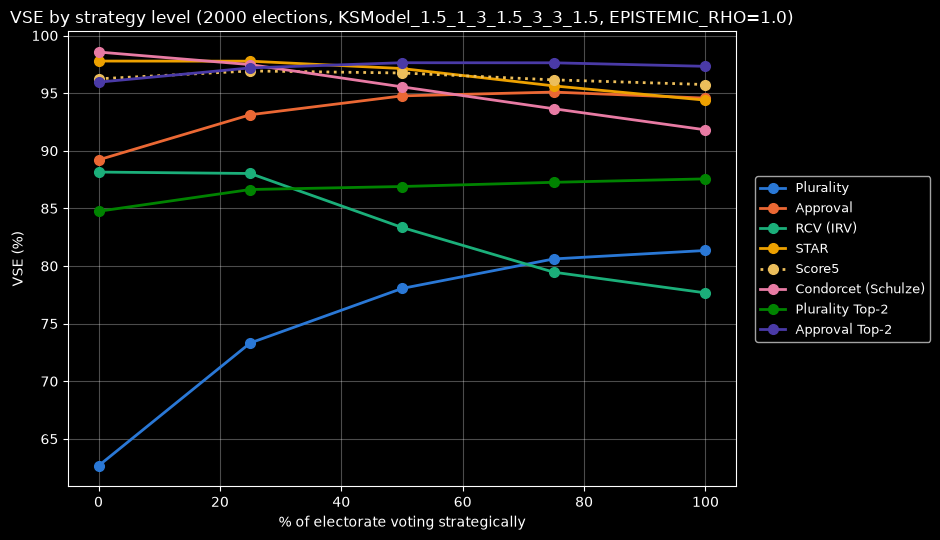

In [9]:
STRATEGY_AXIS = {
    "100% honest": 0,
    "25% strategic": 25,
    "50% strategic": 50,
    "75% strategic": 75,
    "100% strategic": 100,
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _ in PRE_NOISE_METHODS:
    points = sorted(
        (STRATEGY_AXIS[chooser_label], mean_)
        for chooser_label, mean_, _ in rows_by_method[label]
        if chooser_label in STRATEGY_AXIS
    )
    if not points:
        continue
    xs, ys = zip(*points)
    ax.plot(xs, [y * 100 for y in ys], marker="o", markersize=7, linewidth=2,
            color=METHOD_COLORS[label], linestyle=METHOD_LINESTYLES[label], label=label)

ax.set_xlabel("% of electorate voting strategically")
ax.set_ylabel("VSE (%)")
ax.set_title(f"VSE by strategy level ({NITER} elections, {MODEL}, EPISTEMIC_RHO={EPISTEMIC_RHO})")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

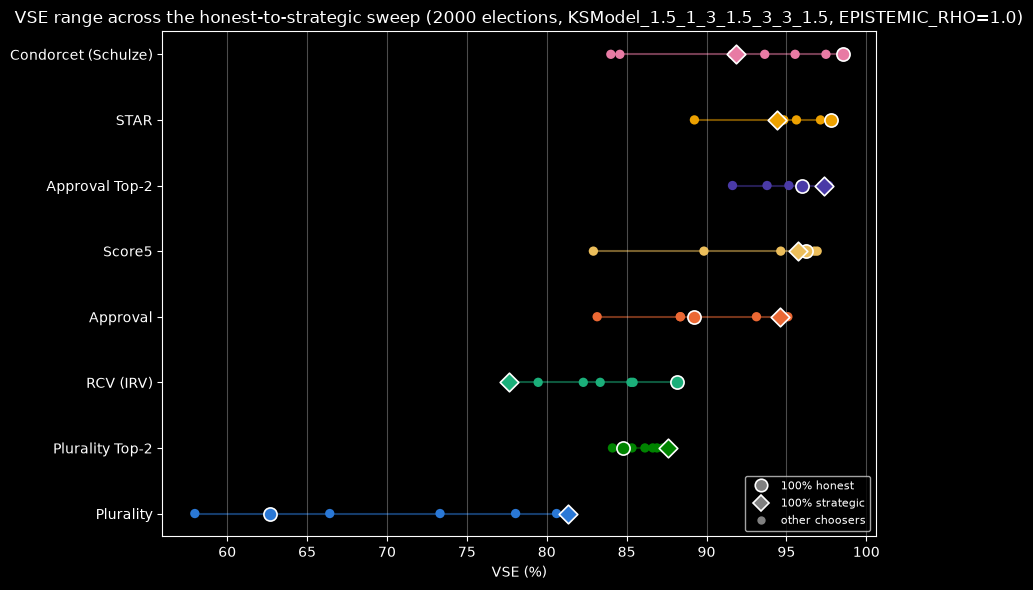

In [10]:
# sort methods by their max VSE across any chooser, so the worst method is at the bottom of the y-axis and the best method is at the top. 
_sorted_labels = sorted(
    (label for label, _ in PRE_NOISE_METHODS if rows_by_method[label]),
    key=lambda label: max(mean_ for _, mean_, _ in rows_by_method[label])
)

fig, ax = plt.subplots(figsize=(9, 6))
# _sorted_labels is ascending by max VSE across any chooser; plotting in that order puts the
# worst method at row 0 (the bottom of a matplotlib y-axis) and the best method at the top row,
# as intended.
for row_i, label in enumerate(_sorted_labels):
    vses = [mean_ * 100 for _, mean_, _ in rows_by_method[label]]
    color = METHOD_COLORS[label]
    ax.plot([min(vses), max(vses)], [row_i, row_i], color=color, linewidth=1.5, alpha=0.5, zorder=1)
    for chooser_label, mean_, _ in rows_by_method[label]:
        is_honest = chooser_label == "100% honest"
        is_strategic = chooser_label == "100% strategic"
        ax.scatter(mean_ * 100, row_i,
                   marker="D" if is_strategic else "o",
                   s=90 if (is_honest or is_strategic) else 45,
                   color=color,
                   edgecolors=FG_COLOR if (is_honest or is_strategic) else "none",
                   linewidths=1.2 if (is_honest or is_strategic) else 0,
                   zorder=3 if (is_honest or is_strategic) else 2)

ax.set_yticks(range(len(_sorted_labels)))
ax.set_yticklabels(_sorted_labels)
ax.set_xlabel("VSE (%)")
ax.set_title(f"VSE range across the honest-to-strategic sweep ({NITER} elections, "
             f"{MODEL}, EPISTEMIC_RHO={EPISTEMIC_RHO})")
_marker_legend = [
    Line2D([0], [0], marker="o", linestyle="none", markersize=9,
           markerfacecolor="gray", markeredgecolor=FG_COLOR, markeredgewidth=1.2, label="100% honest"),
    Line2D([0], [0], marker="D", linestyle="none", markersize=8,
           markerfacecolor="gray", markeredgecolor=FG_COLOR, markeredgewidth=1.2, label="100% strategic"),
    Line2D([0], [0], marker="o", linestyle="none", markersize=6,
           markerfacecolor="gray", markeredgecolor="none", label="other choosers"),
]
ax.legend(handles=_marker_legend, fontsize=8, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Sweeping all three degradation parameters: VSE vs. voter information

`EPISTEMIC_RHO`, `AWARENESS_ALPHA`, and `FATIGUE_BETA` each get swept independently (the other two held at
their ideal value of `1.0`), across every method for which the sweep is meaningful, honest ballots
only -- Section 9/10/12's baseline run is the one place this notebook studies strategic voting.
`AWARENESS_ALPHA`/`FATIGUE_BETA` sweeps are restricted to `PRE_NOISE_METHODS`: a
Clear-Eyed runoff variant is only ever different from its base method when the *primary's* own
epistemic noise varies -- the runoff already assumes full awareness by default regardless of the
primary's friction -- so simulating it under `AWARENESS_ALPHA`/`FATIGUE_BETA` would just be a wasted,
functionally-identical copy of its base method's row.

The reusable sweep tooling defined below (`sweep_methods`, `comparison_table`, `comparison_chart`)
is also what Section 14 and later sections use for smaller, focused comparisons.

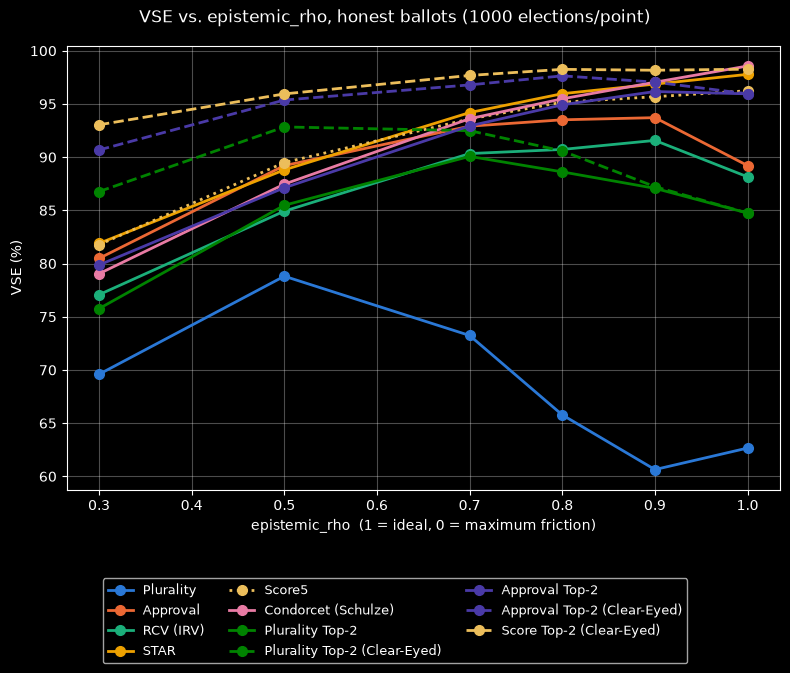

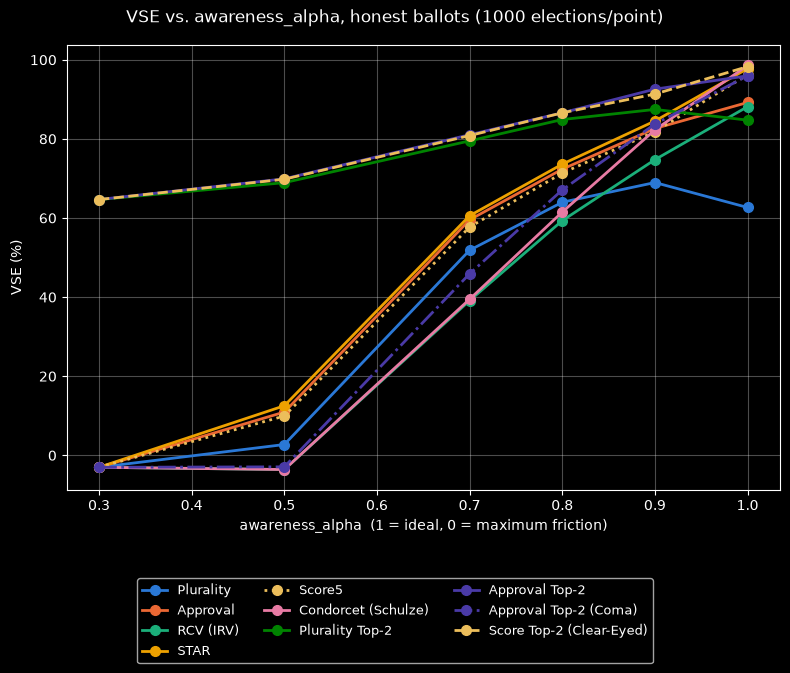

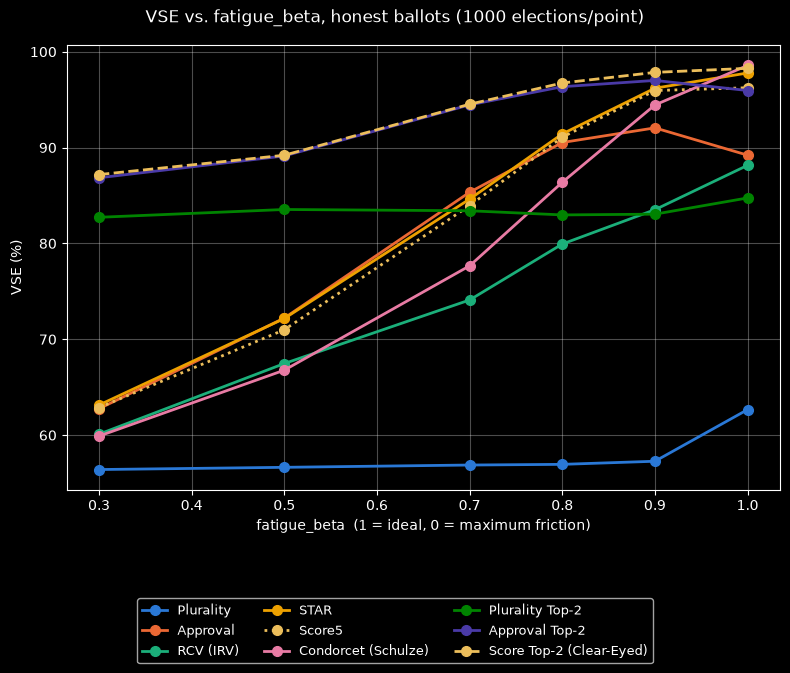

In [11]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _by_value = R.sweep_results_by_param[sweep_param]
    _values = sorted(_by_value)
    fig, ax_hon = plt.subplots(figsize=(8, 5.5))
    for label, _ in param_methods:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES[label]
        hon_vses = [_by_value[v][(label, "honBallot")][0] * 100 for v in _values]
        ax_hon.plot(_values, hon_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
    ax_hon.set_xlabel(f"{sweep_param}  (1 = ideal, 0 = maximum friction)")
    ax_hon.grid(True, alpha=0.3)
    ax_hon.set_ylabel("VSE (%)")
    handles, labels_ = ax_hon.get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
    fig.suptitle(f"VSE vs. {sweep_param}, honest ballots ({SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()

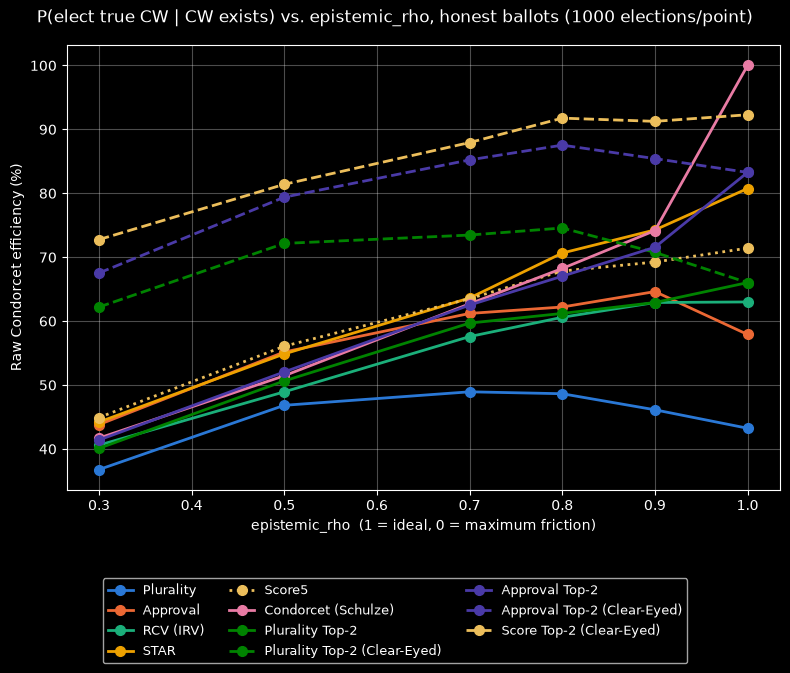

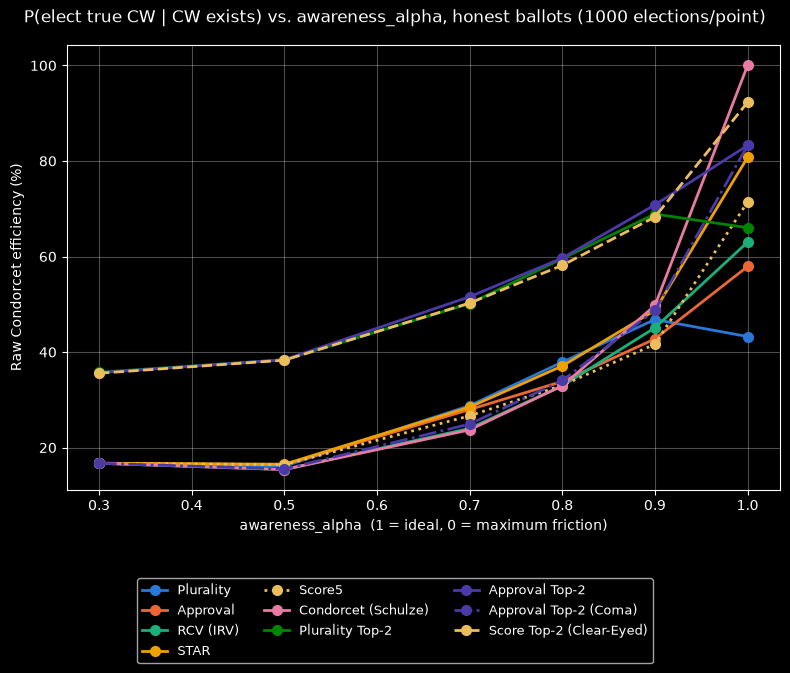

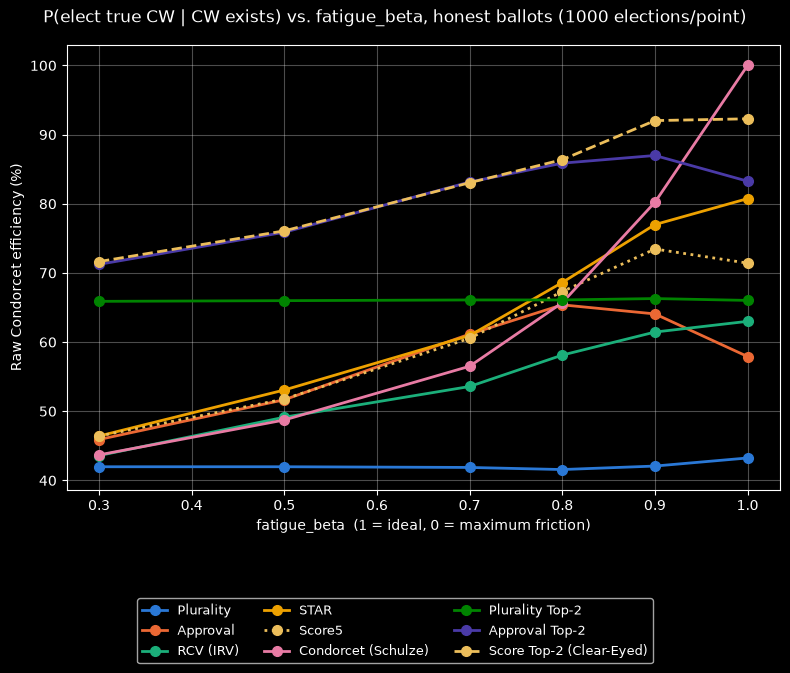

In [12]:
for sweep_param, param_methods in SWEEP_PARAMS:
    _ce_by_value = R.sweep_ce_by_param[sweep_param]
    _values = sorted(_ce_by_value)
    fig, ax_hon = plt.subplots(figsize=(8, 5.5))
    for label, _ in param_methods:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES[label]
        hon_ces = [_ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in _values]
        ax_hon.plot(_values, hon_ces, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)
    ax_hon.set_xlabel(f"{sweep_param}  (1 = ideal, 0 = maximum friction)")
    ax_hon.grid(True, alpha=0.3)
    ax_hon.set_ylabel("Raw Condorcet efficiency (%)")
    handles, labels_ = ax_hon.get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
    fig.suptitle(f"P(elect true CW | CW exists) vs. {sweep_param}, honest ballots ({SWEEP_NITER} elections/point)")
    plt.tight_layout()
    plt.show()

## 14. Approval's flavors vs. STAR/Schulze, across noise and both friction mechanisms

The motivating question: Approval Top-2 (a coarse 0/1 ballot, decided over two rounds) is the
flavor of Approval actually being adopted (e.g. St. Louis). STAR and Schulze both let voters
express far more information in a single round. Does STAR/Schulze's honest-VSE edge over Approval
hold up once that richer signal degrades -- and does Approval Top-2's *delayed, two-candidate*
runoff let voters recover some of that edge, on the theory that deciding between just two finalists
is easy to get right even if the crowded primary wasn't?

Same `baseline_label="STAR"` framing, for all three parameters in turn -- `EPISTEMIC_RHO`,
`AWARENESS_ALPHA`, `FATIGUE_BETA` -- each swept alone with the other two held at `1.0`. `COMPARE_LABELS`
below is Approval's three flavors (base, Groggy Top-2, Clear-Eyed Top-2), STAR, Schulze, and
`Score5` -- Plurality and RCV are covered in Section 13's full sweep above if you want their
numbers. `Score5` (`Score(STAR_TOP_RANK)`, Section 7) is STAR's own ballots with the runoff
switched off; it rides along here as a free no-runoff reference line on every chart below.

In [13]:
# No new simulation here -- Section 13 already swept every method (epistemic_rho) or every
# PRE_NOISE_METHODS method (awareness_alpha/fatigue_beta) across all three parameters; this just
# filters those already-computed R.results down to COMPARE_LABELS (defined in Section 9, above --
# hoisted there so Section 9's own baseline run can build its paired-comparison lists from it
# too). "Approval Top-2 (clear-eyed runoff)" is simply absent from the awareness_alpha/fatigue_beta
# dicts (Section 13 never simulated it there), not filtered out here -- see Section 13's markdown
# for why. "Score5" is included so it rides along as a no-runoff reference line on every chart
# below; Section 22 reuses this same compare_by_param (and the R.joint_results built from
# COMPARE_LABELS further down) instead of running its own separate STAR-vs-Score5 simulation.
compare_by_param = {
    param: {value: {k: v for k, v in by_value.items() if k[0] in COMPARE_LABELS}
            for value, by_value in R.sweep_results_by_param[param].items()}
    for param, _ in SWEEP_PARAMS
}
compare_ce_by_param = {
    param: {value: {k: v for k, v in by_value.items() if k[0] in COMPARE_LABELS}
            for value, by_value in R.sweep_ce_by_param[param].items()}
    for param, _ in SWEEP_PARAMS
}

#### Epistemic noise (EPISTEMIC_RHO)

| Method | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.80 | epistemic_rho=0.90 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 69.6% (+/-2.9) | 78.8% (+/-2.7) | 73.2% (+/-3.4) | 65.8% (+/-4.2) | 60.6% (+/-4.5) | 62.7% (+/-2.8) |
| Plurality Top-2 | 75.8% (+/-2.2) | 85.5% (+/-1.6) | 90.1% (+/-1.3) | 88.6% (+/-1.8) | 87.1% (+/-2.0) | 84.7% (+/-1.6) |
| Plurality Top-2 (Clear-Eyed) | 86.8% (+/-1.8) | 92.8% (+/-1.1) | 92.5% (+/-1.3) | 90.6% (+/-1.6) | 87.2% (+/-2.3) | 84.7% (+/-1.6) |
| RCV (IRV) | 77.1% (+/-2.1) | 84.9% (+/-1.7) | 90.3% (+/-1.3) | 90.7% (+/-1.4) | 91.6% (+/-1.2) | 88.2% (+/-1.2) |
| Approval | 80.5% (+/-1.9) | 89.2% (+/-1.2) | 92.9% (+/-0.9) | 93.5% (+/-0.8) | 93.7% (+/-0.8) | 89.2% (+/-0.8) |
| Approval Top-2 | 79.9% (+/-1.9) | 87.1% (+/-1.4) | 92.9% (+/-0.9) | 94.9% (+/-0.7) | 96.2% (+/-0.6) | 96.0% (+/-0.5) |
| Approval Top-2 (Clear-Eyed) | 90.7% (+/-1.4) | 95.4% (+/-0.8) | 96.8% (+/-0.6) | 97.6% (+/-0.5) | 97.1% (+/-0.6) | 96.0% (+/-0.5) |
| STAR | 81.9% (+/-1.8) | 88.8% (+/-1.3) | 94.2% (+/-0.8) | 96.0% (+/-0.6) | 96.9% (+/-0.5) | 97.8% (+/-0.4) |
| Score5 | 81.8% (+/-1.8) | 89.5% (+/-1.2) | 93.6% (+/-0.9) | 95.2% (+/-0.7) | 95.7% (+/-0.6) | 96.2% (+/-0.4) |
| Score Top-2 (Clear-Eyed) | 93.0% (+/-1.1) | 95.9% (+/-0.7) | 97.7% (+/-0.5) | 98.3% (+/-0.4) | 98.2% (+/-0.4) | 98.3% (+/-0.4) |
| Condorcet (Schulze) | 79.0% (+/-2.0) | 87.5% (+/-1.4) | 93.6% (+/-0.8) | 95.5% (+/-0.7) | 97.0% (+/-0.5) | 98.6% (+/-0.4) |

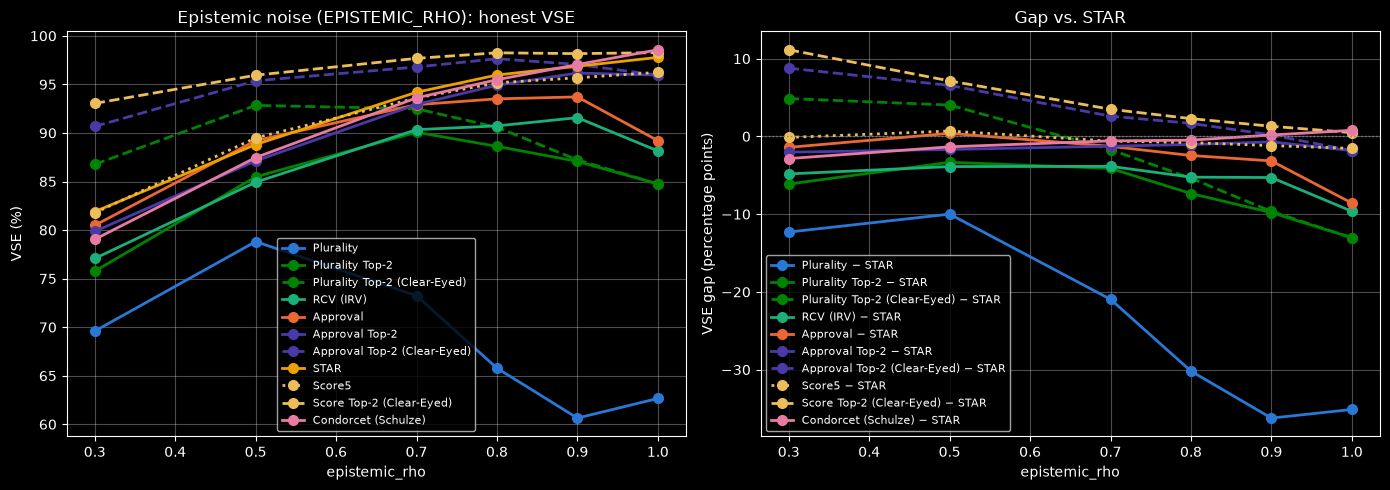

#### Unfamiliarity (AWARENESS_ALPHA)

| Method | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.80 | awareness_alpha=0.90 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality | -3.0% (+/-6.8) | 2.7% (+/-6.4) | 51.9% (+/-4.2) | 64.0% (+/-3.6) | 69.0% (+/-3.6) | 62.7% (+/-2.8) |
| Plurality Top-2 | 64.7% (+/-3.0) | 68.9% (+/-2.7) | 79.5% (+/-2.2) | 84.9% (+/-1.9) | 87.5% (+/-1.9) | 84.7% (+/-1.6) |
| RCV (IRV) | -3.0% (+/-6.8) | -3.6% (+/-6.6) | 39.1% (+/-4.8) | 59.3% (+/-3.6) | 74.8% (+/-2.7) | 88.2% (+/-1.2) |
| Approval | -3.0% (+/-6.8) | 10.9% (+/-5.8) | 59.5% (+/-3.2) | 72.3% (+/-2.2) | 82.6% (+/-1.6) | 89.2% (+/-0.8) |
| Approval Top-2 (Coma) | -3.0% (+/-6.8) | -2.9% (+/-6.6) | 45.9% (+/-4.2) | 67.1% (+/-2.8) | 83.8% (+/-1.7) | 96.0% (+/-0.5) |
| Approval Top-2 | 64.7% (+/-3.0) | 69.9% (+/-2.6) | 81.1% (+/-2.0) | 86.6% (+/-1.6) | 92.6% (+/-1.1) | 96.0% (+/-0.5) |
| STAR | -3.0% (+/-6.8) | 12.5% (+/-5.8) | 60.6% (+/-3.1) | 73.6% (+/-2.3) | 84.5% (+/-1.6) | 97.8% (+/-0.4) |
| Score5 | -3.0% (+/-6.8) | 9.9% (+/-5.9) | 57.7% (+/-3.2) | 71.4% (+/-2.2) | 81.8% (+/-1.6) | 96.2% (+/-0.4) |
| Score Top-2 (Clear-Eyed) | 64.7% (+/-3.0) | 69.8% (+/-2.6) | 80.8% (+/-2.0) | 86.6% (+/-1.5) | 91.3% (+/-1.2) | 98.3% (+/-0.4) |
| Condorcet (Schulze) | -3.0% (+/-6.8) | -3.6% (+/-6.6) | 39.5% (+/-4.7) | 61.5% (+/-3.3) | 82.3% (+/-1.9) | 98.6% (+/-0.4) |

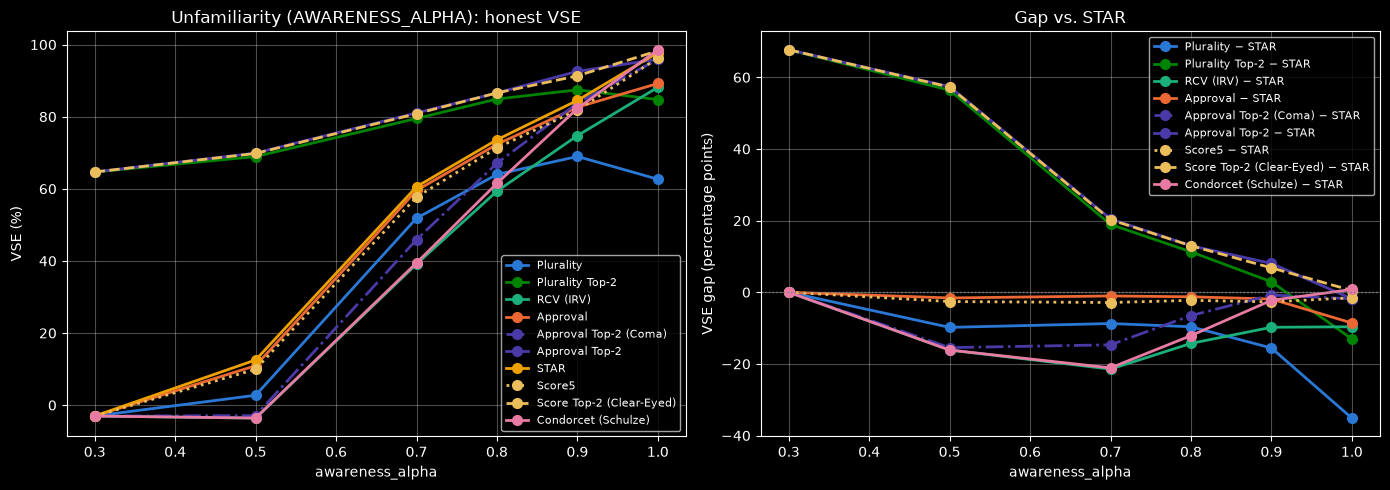

#### Ballot fatigue (FATIGUE_BETA)

| Method | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.80 | fatigue_beta=0.90 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 56.4% (+/-4.3) | 56.6% (+/-4.2) | 56.9% (+/-4.2) | 57.0% (+/-4.2) | 57.3% (+/-4.2) | 62.7% (+/-2.8) |
| Plurality Top-2 | 82.7% (+/-2.5) | 83.5% (+/-2.3) | 83.4% (+/-2.3) | 83.0% (+/-2.5) | 83.1% (+/-2.5) | 84.7% (+/-1.6) |
| RCV (IRV) | 60.1% (+/-4.1) | 67.5% (+/-3.6) | 74.1% (+/-3.1) | 79.9% (+/-2.6) | 83.5% (+/-2.2) | 88.2% (+/-1.2) |
| Approval | 62.8% (+/-4.0) | 72.2% (+/-3.4) | 85.3% (+/-2.1) | 90.5% (+/-1.5) | 92.1% (+/-1.1) | 89.2% (+/-0.8) |
| Approval Top-2 | 86.8% (+/-2.0) | 89.1% (+/-1.9) | 94.5% (+/-1.2) | 96.3% (+/-0.9) | 97.0% (+/-0.7) | 96.0% (+/-0.5) |
| STAR | 63.1% (+/-4.0) | 72.2% (+/-3.4) | 84.6% (+/-2.2) | 91.4% (+/-1.3) | 96.2% (+/-0.9) | 97.8% (+/-0.4) |
| Score5 | 62.9% (+/-4.0) | 71.0% (+/-3.5) | 84.0% (+/-2.2) | 91.1% (+/-1.5) | 95.9% (+/-0.8) | 96.2% (+/-0.4) |
| Score Top-2 (Clear-Eyed) | 87.2% (+/-2.0) | 89.2% (+/-1.9) | 94.5% (+/-1.2) | 96.7% (+/-0.8) | 97.8% (+/-0.6) | 98.3% (+/-0.4) |
| Condorcet (Schulze) | 59.9% (+/-4.1) | 66.8% (+/-3.7) | 77.7% (+/-2.9) | 86.4% (+/-2.2) | 94.4% (+/-1.1) | 98.6% (+/-0.4) |

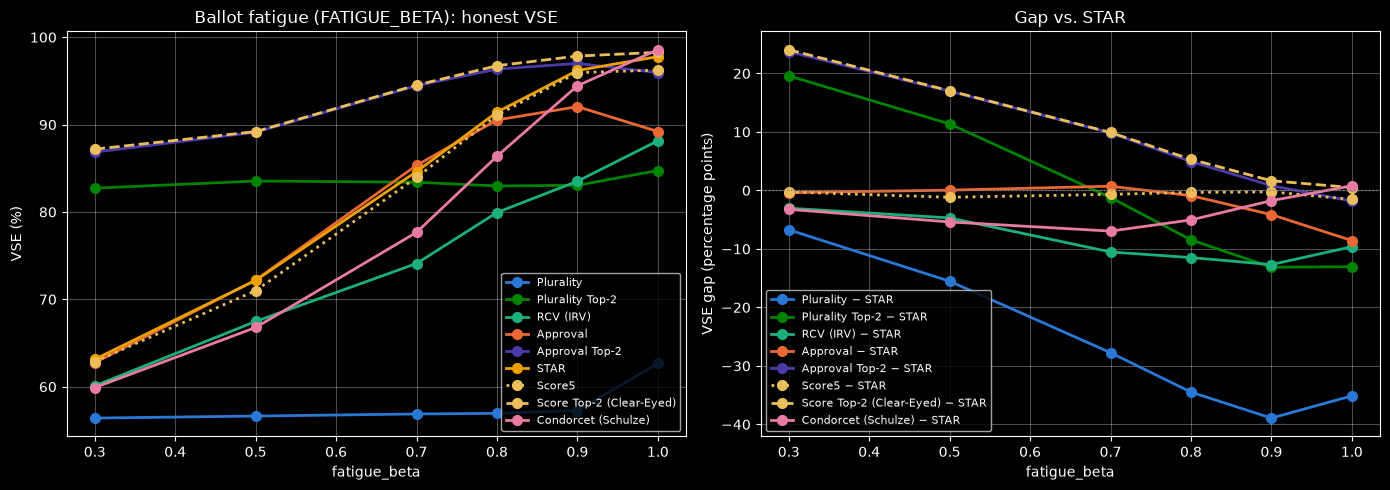

In [14]:
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise (EPISTEMIC_RHO)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_beta", "Ballot fatigue (FATIGUE_BETA)"),
]:
    display(Markdown(f"#### {param_title}"))
    # Derived from what's actually present rather than a hardcoded exclusion: "Approval Top-2
    # (Clear-Eyed)" is only in compare_by_param["epistemic_rho"] (see the cell above), so it
    # naturally drops out of the other two params' tables/charts here without special-casing.
    _some_value = next(iter(compare_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    comparison_table(compare_by_param[sweep_param], _compare_labels_here, sweep_param)
    comparison_chart(compare_by_param[sweep_param], _compare_labels_here, sweep_param,
                      baseline_label="STAR", title=f"{param_title}: honest VSE")

#### Epistemic noise (EPISTEMIC_RHO) (baseline: Approval Top-2)

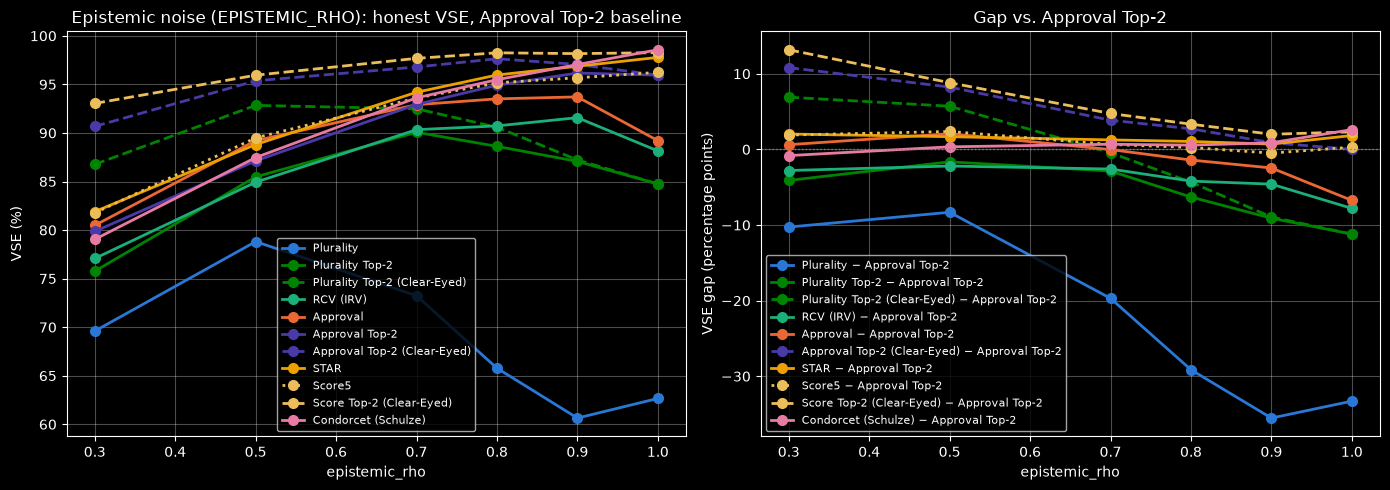

#### Unfamiliarity (AWARENESS_ALPHA) (baseline: Approval Top-2)

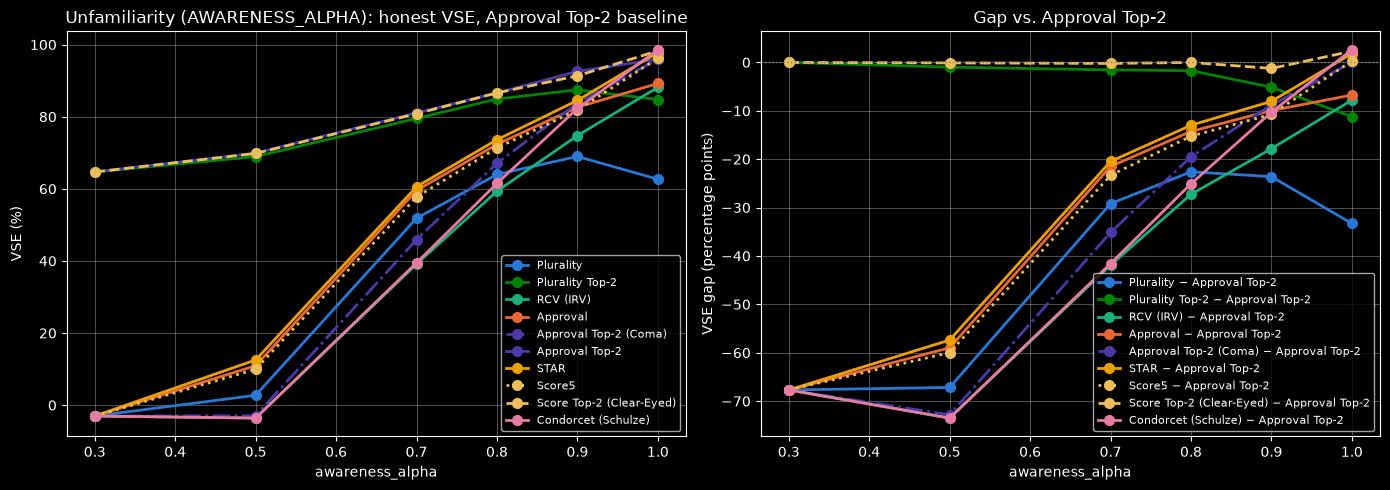

#### Ballot fatigue (FATIGUE_BETA) (baseline: Approval Top-2)

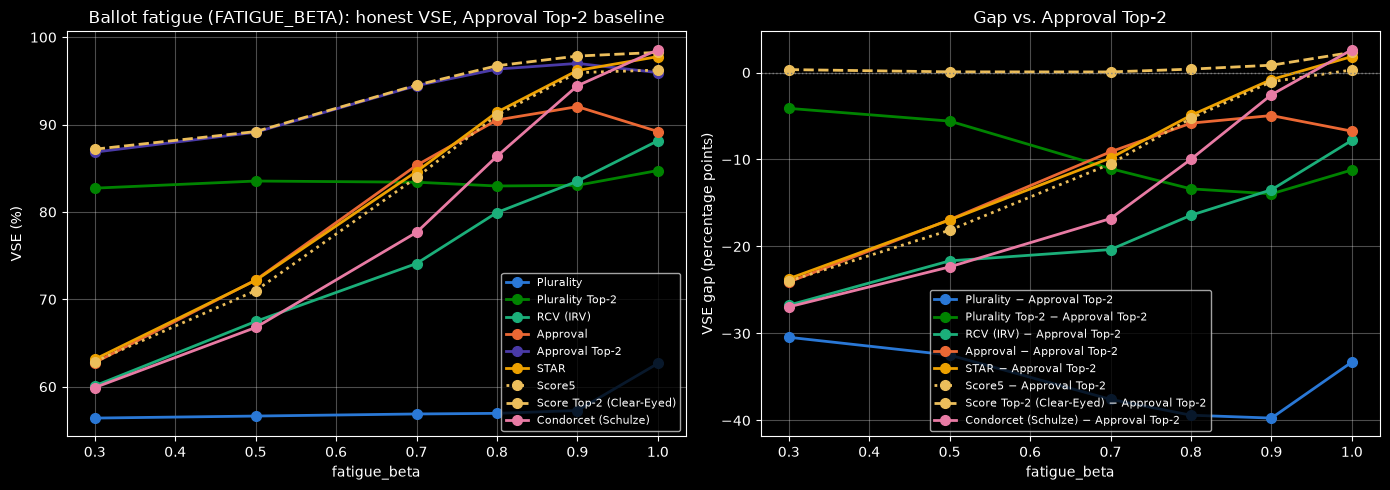

In [15]:
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise (EPISTEMIC_RHO)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_beta", "Ballot fatigue (FATIGUE_BETA)"),
]:
    display(Markdown(f"#### {param_title} (baseline: Approval Top-2)"))
    _some_value = next(iter(compare_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    comparison_chart(compare_by_param[sweep_param], _compare_labels_here, sweep_param,
                      baseline_label="Approval Top-2",
                      title=f"{param_title}: honest VSE, Approval Top-2 baseline")

## 15. Condorcet Efficiency Under Sweeps

#### Epistemic noise (EPISTEMIC_RHO): raw Condorcet efficiency

| Method | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.80 | epistemic_rho=0.90 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 36.8% | 46.8% | 48.9% | 48.6% | 46.1% | 43.2% |
| Plurality Top-2 | 40.1% | 50.7% | 59.7% | 61.2% | 62.9% | 66.0% |
| Plurality Top-2 (Clear-Eyed) | 62.2% | 72.2% | 73.5% | 74.6% | 70.8% | 66.0% |
| RCV (IRV) | 40.6% | 48.9% | 57.6% | 60.6% | 62.9% | 63.0% |
| Approval | 43.8% | 55.2% | 61.2% | 62.2% | 64.6% | 57.9% |
| Approval Top-2 | 41.4% | 52.1% | 62.5% | 67.0% | 71.6% | 83.3% |
| Approval Top-2 (Clear-Eyed) | 67.5% | 79.4% | 85.2% | 87.5% | 85.4% | 83.3% |
| STAR | 44.2% | 54.9% | 63.6% | 70.7% | 74.3% | 80.7% |
| Score5 | 44.9% | 56.1% | 63.5% | 67.8% | 69.2% | 71.4% |
| Score Top-2 (Clear-Eyed) | 72.8% | 81.4% | 87.9% | 91.8% | 91.3% | 92.3% |
| Condorcet (Schulze) | 41.7% | 51.5% | 62.7% | 68.2% | 74.2% | 100.0% |

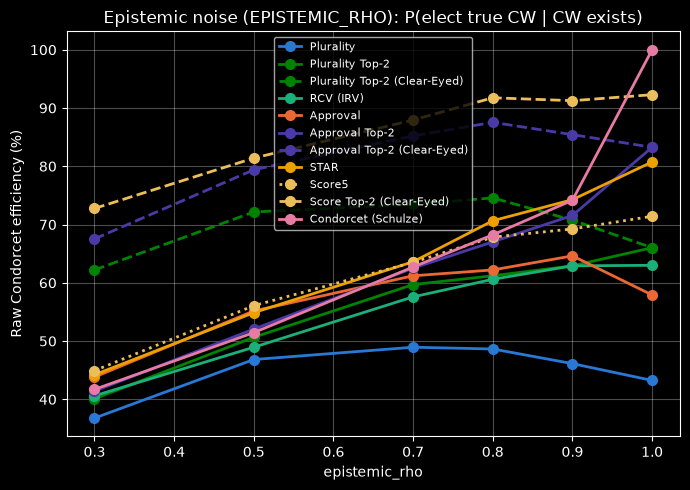

#### Unfamiliarity (AWARENESS_ALPHA): raw Condorcet efficiency

| Method | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.80 | awareness_alpha=0.90 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 16.7% | 16.1% | 28.8% | 37.9% | 46.8% | 43.2% |
| Plurality Top-2 | 35.8% | 38.4% | 50.2% | 59.6% | 68.9% | 66.0% |
| RCV (IRV) | 16.7% | 15.4% | 24.0% | 32.9% | 45.1% | 63.0% |
| Approval | 16.7% | 16.4% | 28.0% | 33.8% | 42.8% | 57.9% |
| Approval Top-2 (Coma) | 16.7% | 15.5% | 24.9% | 34.0% | 48.7% | 83.3% |
| Approval Top-2 | 35.7% | 38.4% | 51.6% | 59.7% | 70.8% | 83.3% |
| STAR | 16.7% | 16.5% | 28.5% | 37.1% | 48.7% | 80.7% |
| Score5 | 16.7% | 16.4% | 26.6% | 33.0% | 41.6% | 71.4% |
| Score Top-2 (Clear-Eyed) | 35.6% | 38.3% | 50.3% | 58.2% | 68.3% | 92.3% |
| Condorcet (Schulze) | 16.7% | 15.4% | 23.7% | 32.9% | 49.7% | 100.0% |

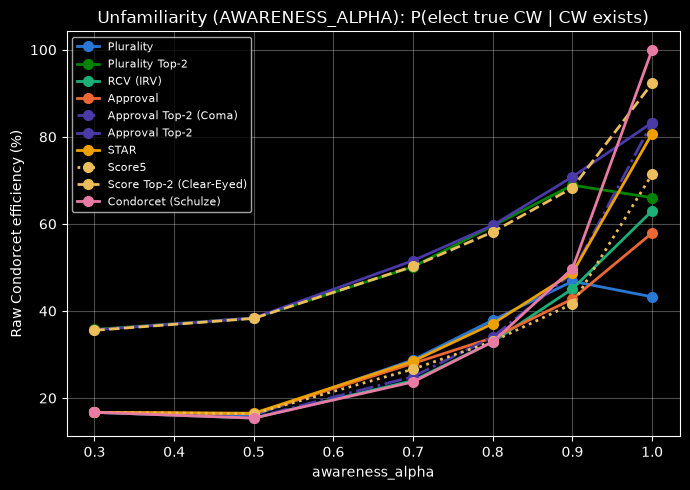

#### Ballot fatigue (FATIGUE_BETA): raw Condorcet efficiency

| Method | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.80 | fatigue_beta=0.90 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 42.0% | 42.0% | 41.9% | 41.6% | 42.1% | 43.2% |
| Plurality Top-2 | 65.9% | 66.0% | 66.1% | 66.1% | 66.3% | 66.0% |
| RCV (IRV) | 43.6% | 49.1% | 53.6% | 58.1% | 61.5% | 63.0% |
| Approval | 45.9% | 51.7% | 61.2% | 65.4% | 64.1% | 57.9% |
| Approval Top-2 | 71.2% | 75.9% | 83.1% | 85.9% | 87.0% | 83.3% |
| STAR | 46.4% | 53.1% | 60.9% | 68.6% | 77.0% | 80.7% |
| Score5 | 46.4% | 51.8% | 60.5% | 67.3% | 73.5% | 71.4% |
| Score Top-2 (Clear-Eyed) | 71.6% | 76.1% | 83.0% | 86.4% | 92.0% | 92.3% |
| Condorcet (Schulze) | 43.7% | 48.7% | 56.5% | 65.7% | 80.2% | 100.0% |

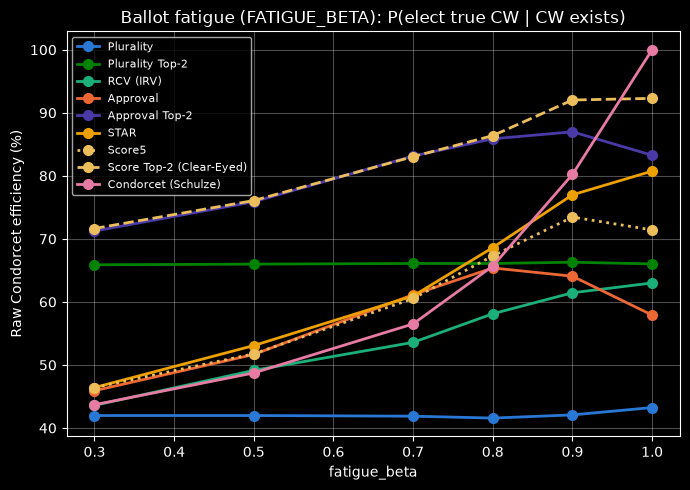

In [16]:
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise (EPISTEMIC_RHO)"),
    ("awareness_alpha", "Unfamiliarity (AWARENESS_ALPHA)"),
    ("fatigue_beta", "Ballot fatigue (FATIGUE_BETA)"),
]:
    display(Markdown(f"#### {param_title}: raw Condorcet efficiency"))
    _some_value = next(iter(compare_ce_by_param[sweep_param]))
    _present_labels = {k[0] for k in compare_ce_by_param[sweep_param][_some_value]}
    _compare_labels_here = [l for l in COMPARE_LABELS if l in _present_labels]
    ce_by_value = compare_ce_by_param[sweep_param]
    values = sorted(ce_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in _compare_labels_here:
        row = [label]
        for v in values:
            ce = ce_by_value[v].get((label, "honBallot"))
            row.append("n/a" if ce is None or ce != ce else f"{ce * 100:.1f}%")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))

    fig, ax = plt.subplots(figsize=(7, 5))
    for label in _compare_labels_here:
        ces = [ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in values]
        ax.plot(values, ces, marker="o", markersize=7, linewidth=2,
                color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"), label=label)
    ax.set_xlabel(sweep_param)
    ax.set_ylabel("Raw Condorcet efficiency (%)")
    ax.set_title(f"{param_title}: P(elect true CW | CW exists)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [17]:
# Plain-language readout: does each Approval flavor's gap to STAR shrink, hold, or reverse?
_narrowing_lines = [
    "| Method | Parameter | STAR VSE - method VSE (ideal) | STAR VSE - method VSE (min value) | STAR-lead change (pp) | Direction |",
    "|---|---|---|---|---|---|",
]

_target_methods = ["Approval", "Approval Top-2", "Approval Top-2 (Clear-Eyed)"]
_sweeps = [
    ("epistemic_rho", "Epistemic noise"),
    ("awareness_alpha", "Unfamiliarity"),
    ("fatigue_beta", "Ballot fatigue"),
]

for label in _target_methods:  # group by method first
    for sweep_param, param_title in _sweeps:
        results_by_value = compare_by_param[sweep_param]
        _values = sorted(results_by_value)
        _ideal_v = max(_values)
        _max_friction_v = min(_values)

        _ideal_results = results_by_value[_ideal_v]
        _max_results = results_by_value[_max_friction_v]

        if ("STAR", "honBallot") not in _ideal_results or (label, "honBallot") not in _ideal_results:
            continue

        star_ideal = _ideal_results[("STAR", "honBallot")][0] * 100
        meth_ideal = _ideal_results[(label, "honBallot")][0] * 100
        star_max = _max_results[("STAR", "honBallot")][0] * 100
        meth_max = _max_results[(label, "honBallot")][0] * 100

        lead_ideal = star_ideal - meth_ideal
        lead_max = star_max - meth_max
        lead_delta = lead_max - lead_ideal

        if lead_max < lead_ideal:
            direction = "narrowed"
        elif lead_max > lead_ideal:
            direction = "widened"
        else:
            direction = "unchanged"

        if (lead_ideal > 0 and lead_max < 0) or (lead_ideal < 0 and lead_max > 0):
            direction += " (reversed sign)"

        ideal_cell = f"{star_ideal:.1f}-{meth_ideal:.1f}<br>[{lead_ideal:+.1f} pp]"
        max_cell = f"{star_max:.1f}-{meth_max:.1f}<br>[{lead_max:+.1f} pp]"

        _narrowing_lines.append(
            f"| {label} | {param_title} | {ideal_cell} | {max_cell} | "
            f"{lead_ideal:+.1f} → {lead_max:+.1f} ({lead_delta:+.1f}) | {direction} |"
        )
display(Markdown("\n".join(_narrowing_lines)))

| Method | Parameter | STAR VSE - method VSE (ideal) | STAR VSE - method VSE (min value) | STAR-lead change (pp) | Direction |
|---|---|---|---|---|---|
| Approval | Epistemic noise | 97.8-89.2<br>[+8.6 pp] | 81.9-80.5<br>[+1.4 pp] | +8.6 → +1.4 (-7.2) | narrowed |
| Approval | Unfamiliarity | 97.8-89.2<br>[+8.6 pp] | -3.0--3.0<br>[+0.0 pp] | +8.6 → +0.0 (-8.6) | narrowed |
| Approval | Ballot fatigue | 97.8-89.2<br>[+8.6 pp] | 63.1-62.8<br>[+0.4 pp] | +8.6 → +0.4 (-8.2) | narrowed |
| Approval Top-2 | Epistemic noise | 97.8-96.0<br>[+1.8 pp] | 81.9-79.9<br>[+2.0 pp] | +1.8 → +2.0 (+0.2) | widened |
| Approval Top-2 | Unfamiliarity | 97.8-96.0<br>[+1.8 pp] | -3.0-64.7<br>[-67.7 pp] | +1.8 → -67.7 (-69.5) | narrowed (reversed sign) |
| Approval Top-2 | Ballot fatigue | 97.8-96.0<br>[+1.8 pp] | 63.1-86.8<br>[-23.7 pp] | +1.8 → -23.7 (-25.5) | narrowed (reversed sign) |
| Approval Top-2 (Clear-Eyed) | Epistemic noise | 97.8-96.0<br>[+1.8 pp] | 81.9-90.7<br>[-8.8 pp] | +1.8 → -8.8 (-10.6) | narrowed (reversed sign) |

## 16. Joint "realistic conditions": all three degradation parameters at once

Every sweep above holds two of `EPISTEMIC_RHO`/`AWARENESS_ALPHA`/`FATIGUE_BETA` at their ideal value (`1.0`)
while moving the third. That isolates each mechanism cleanly, but no real election holds two of
the three perfectly -- voters are simultaneously somewhat uncertain about their own preferences,
somewhat unfamiliar with minor candidates, and somewhat prone to not finishing a long ballot. STAR
and Schulze's honest-VSE edge over Approval's flavors was built entirely on the assumption that all
three hold at once (Section 8's main run: `EPISTEMIC_RHO=AWARENESS_ALPHA=FATIGUE_BETA=1.0`). This section
asks what's left of that edge once none of the three ideal assumptions hold simultaneously, and
puts a number on it rather than reading it off three separate charts.

Four fixed scenarios (not swept, all three parameters move together), same `COMPARE_LABELS` as
above, honest ballots only:

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| Plurality Top-2 | 84.7% (+/-1.6) | 88.4% (+/-0.7) | 81.5% (+/-0.8) | 73.0% (+/-1.0) |
| Plurality Top-2 (Clear-Eyed) | 84.7% (+/-1.6) | 89.2% (+/-0.7) | 82.4% (+/-0.8) | 74.7% (+/-1.0) |
| RCV (IRV) | 88.2% (+/-1.2) | 74.4% (+/-1.1) | 50.7% (+/-1.6) | 29.8% (+/-2.1) |
| Approval | 89.2% (+/-0.8) | 83.3% (+/-0.7) | 65.2% (+/-1.2) | 45.1% (+/-1.7) |
| Approval Top-2 (Coma) | 96.0% (+/-0.5) | 81.8% (+/-0.7) | 57.1% (+/-1.4) | 32.4% (+/-2.0) |
| Approval Top-2 | 96.0% (+/-0.5) | 92.3% (+/-0.4) | 82.1% (+/-0.8) | 73.2% (+/-1.0) |
| Approval Top-2 (Clear-Eyed) | 96.0% (+/-0.5) | 93.2% (+/-0.4) | 83.3% (+/-0.8) | 75.4% (+/-1.0) |
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |
| Score5 | 96.2% (+/-0.4) | 82.3% (+/-0.7) | 64.0% (+/-1.2) | 44.6% (+/-1.7) |
| Score Top-2 (Clear-Eyed) | 98.3% (+/-0.4) | 93.1% (+/-0.4) | 83.1% (+/-0.8) | 75.4% (+/-1.0) |
| Condorcet (Schulze) | 98.6% (+/-0.4) | 76.4% (+/-1.0) | 49.8% (+/-1.7) | 29.3% (+/-2.1) |

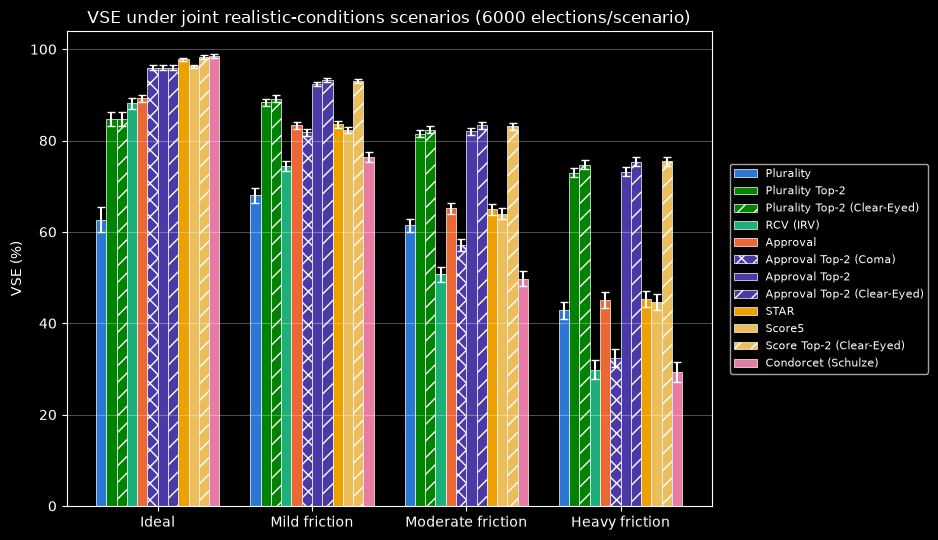

In [18]:
def scenario_table_and_plot(method_labels):
    # Table: rows = method, columns = scenario, cell = VSE% (+/-CI)
    _joint_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                        "|---|" + "---|" * len(_scenario_names)]
    for label in method_labels:
        row = [label]
        for name in _scenario_names:
            mean_, ci = R.joint_results[name][(label, "honBallot")]
            row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
        _joint_table_lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(_joint_table_lines)))

    # Grouped bar chart: one group per scenario, one bar per method.
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    _n_labels = len(method_labels)
    _bar_width = 0.8 / _n_labels
    _x = np.arange(len(_scenario_names))
    for i, label in enumerate(method_labels):
        vses = [R.joint_results[name][(label, "honBallot")][0] * 100 for name in _scenario_names]
        cis = [R.joint_results[name][(label, "honBallot")][1] * 100 for name in _scenario_names]
        hatch = "//" if "Clear-Eyed" in label else ("xx" if "Coma" in label else None)
        ax.bar(_x + i * _bar_width, vses, _bar_width, yerr=cis, capsize=3,
            color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor=FG_COLOR, linewidth=0.5,
            error_kw=dict(ecolor=FG_COLOR))
    ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
    ax.set_xticklabels(_scenario_names)
    ax.set_ylabel("VSE (%)")
    ax.set_title(f"VSE under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

scenario_table_and_plot(COMPARE_LABELS)

## 17. Specific Method Groups in Joint Scenarios

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| Plurality Top-2 | 84.7% (+/-1.6) | 88.4% (+/-0.7) | 81.5% (+/-0.8) | 73.0% (+/-1.0) |
| Plurality Top-2 (Clear-Eyed) | 84.7% (+/-1.6) | 89.2% (+/-0.7) | 82.4% (+/-0.8) | 74.7% (+/-1.0) |
| Approval Top-2 (Clear-Eyed) | 96.0% (+/-0.5) | 93.2% (+/-0.4) | 83.3% (+/-0.8) | 75.4% (+/-1.0) |

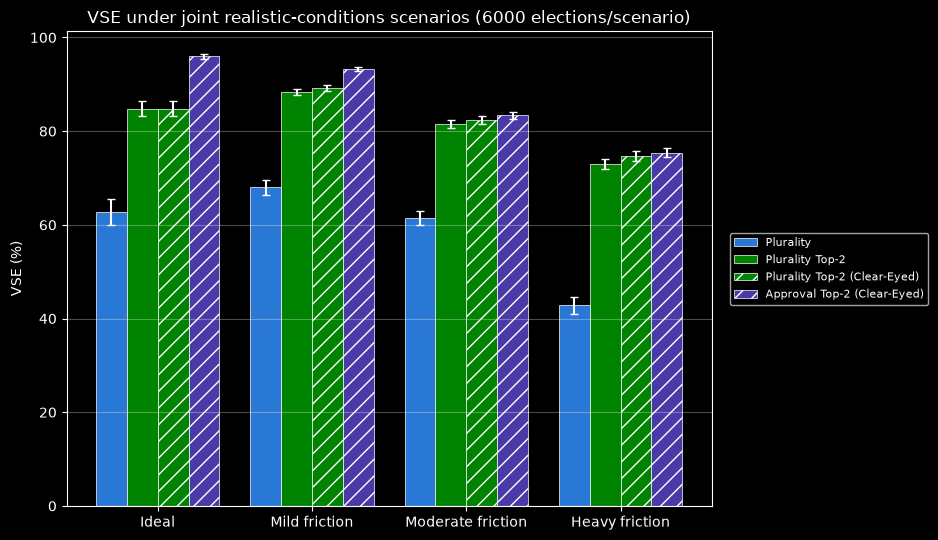

In [19]:
# Plot and table of JUST the plurality-based methods (Plurality, Plurality Top-2, Plurality Top-2 Clear-Eyed) across the joint scenarios
plurality_labels = [l for l in COMPARE_LABELS if "Plurality" in l]
# add clear-eyed AT2 for reference
plurality_labels.append("Approval Top-2 (Clear-Eyed)")
scenario_table_and_plot(plurality_labels)

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| Approval | 89.2% (+/-0.8) | 83.3% (+/-0.7) | 65.2% (+/-1.2) | 45.1% (+/-1.7) |

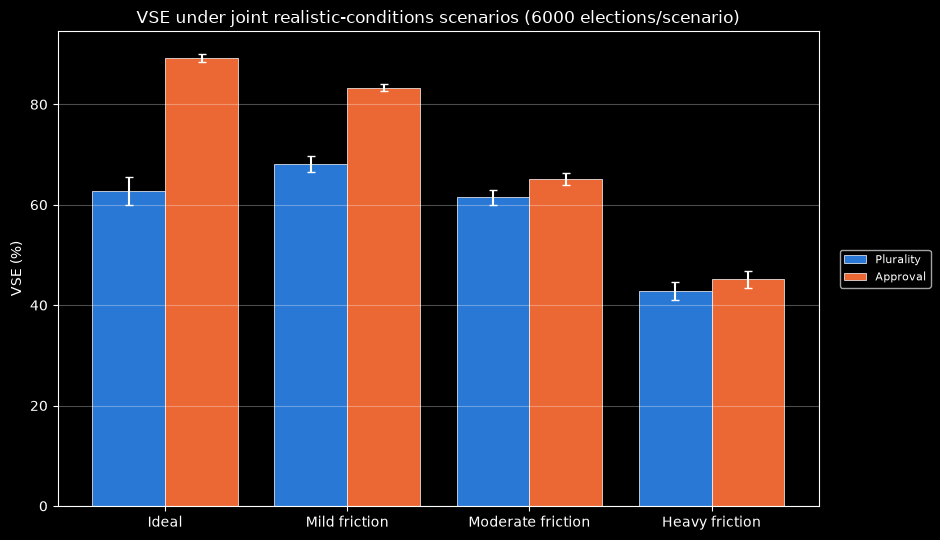

In [20]:
# just single round plurality and approval
simple_labels = ["Plurality", "Approval"]
scenario_table_and_plot(simple_labels)

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| RCV (IRV) | 88.2% (+/-1.2) | 74.4% (+/-1.1) | 50.7% (+/-1.6) | 29.8% (+/-2.1) |
| Condorcet (Schulze) | 98.6% (+/-0.4) | 76.4% (+/-1.0) | 49.8% (+/-1.7) | 29.3% (+/-2.1) |
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |
| Approval Top-2 | 96.0% (+/-0.5) | 92.3% (+/-0.4) | 82.1% (+/-0.8) | 73.2% (+/-1.0) |

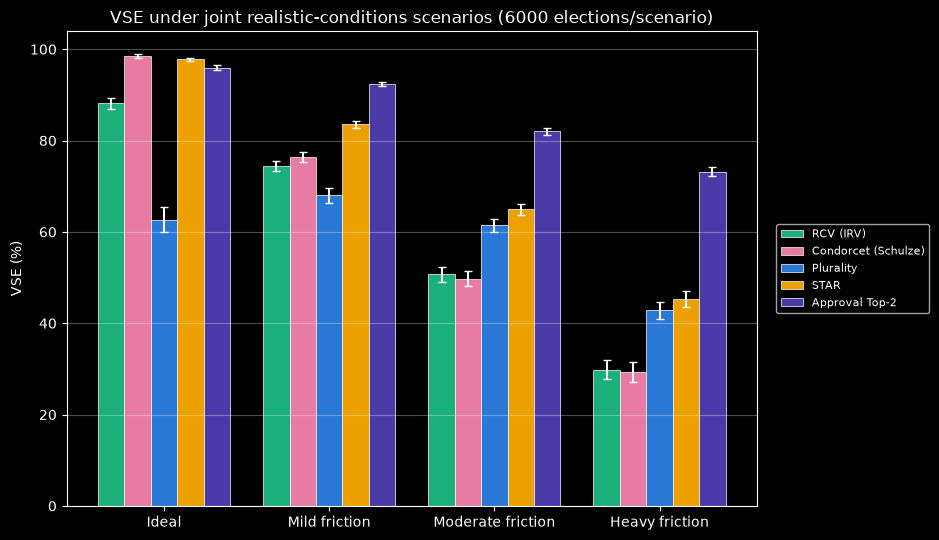

In [21]:
# ranked methods only (RCV, Condorcet) across the joint scenarios
ranked_labels = [l for l in COMPARE_LABELS if l in ("RCV (IRV)", "Condorcet (Schulze)")]
# add for context: approval top-2, plurality, and STAR
ranked_labels.append("Plurality")
ranked_labels.append("STAR")
ranked_labels.append("Approval Top-2")
scenario_table_and_plot(ranked_labels)

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| Approval | 89.2% (+/-0.8) | 83.3% (+/-0.7) | 65.2% (+/-1.2) | 45.1% (+/-1.7) |
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |
| Plurality Top-2 | 84.7% (+/-1.6) | 88.4% (+/-0.7) | 81.5% (+/-0.8) | 73.0% (+/-1.0) |
| Approval Top-2 | 96.0% (+/-0.5) | 92.3% (+/-0.4) | 82.1% (+/-0.8) | 73.2% (+/-1.0) |

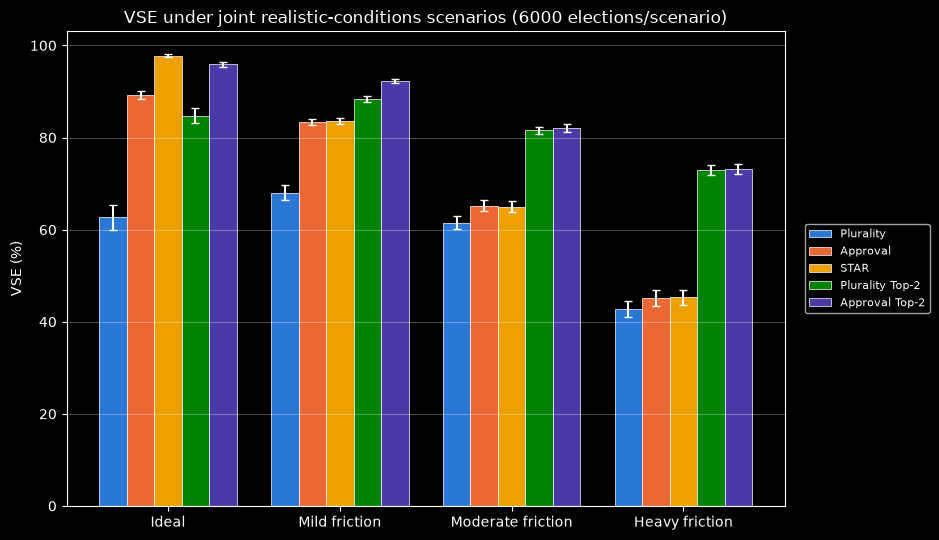

In [22]:
# plurality, approval, star, plus top-2 variants
part_1_systems = ["Plurality", "Approval", "STAR", "Plurality Top-2", "Approval Top-2"]
scenario_table_and_plot(part_1_systems)

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |
| Approval | 89.2% (+/-0.8) | 83.3% (+/-0.7) | 65.2% (+/-1.2) | 45.1% (+/-1.7) |
| Approval Top-2 (Coma) | 96.0% (+/-0.5) | 81.8% (+/-0.7) | 57.1% (+/-1.4) | 32.4% (+/-2.0) |
| Approval Top-2 | 96.0% (+/-0.5) | 92.3% (+/-0.4) | 82.1% (+/-0.8) | 73.2% (+/-1.0) |

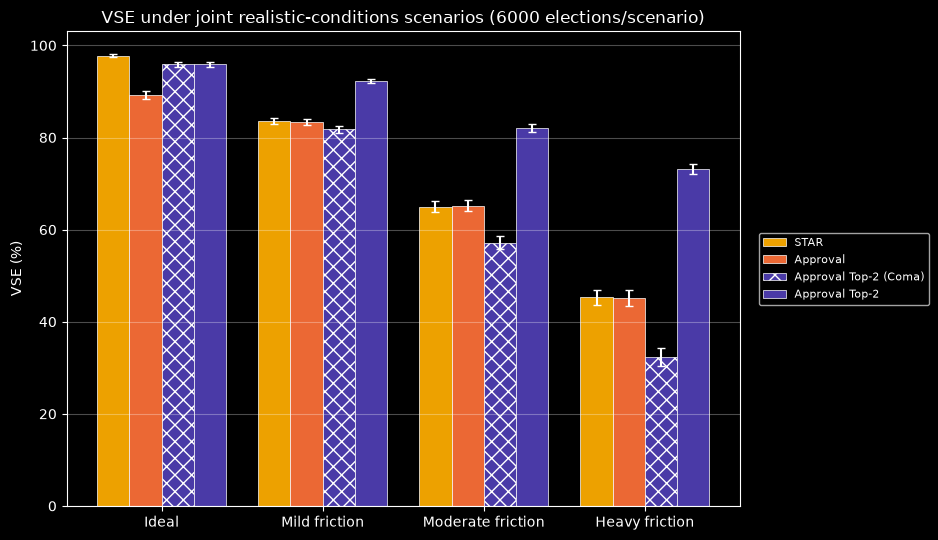

In [23]:
## AT2 Coma vs Approval
coma_single_round_labels = ["STAR", "Approval", "Approval Top-2 (Coma)", "Approval Top-2"]
scenario_table_and_plot(coma_single_round_labels)

## 18. Quantifying the swing

For each Approval flavor, its gap to STAR (percentage points) at
`Ideal` vs. at `Heavy friction`, and how much that gap moved -- same signed-gap convention as the
per-parameter readout above (a positive swing means STAR's lead shrank, possibly past zero).

### Approval/Runoffs vs STAR

In [24]:
_joint_quant_lines = []
_focus_labels = ("Approval", "Approval Top-2 (Coma)", "Approval Top-2", "Approval Top-2 (Clear-Eyed)", "Plurality Top-2", "Plurality Top-2 (Clear-Eyed)", "Plurality")

# keep track of method/scenario pairs that have a STAR VSE gap that is statistically indistinguishable from 0 (i.e., the 95% CI contains 0)
contains_zero_pairs = set()
# also keep track of method/scenario pairs where STAR beats the method, and where the method beats STAR
STAR_wins_pairs = set()
STAR_loses_pairs = set()

# Single unified loop over every scenario (including Ideal, now that R.paired_diff_by_scenario has
# a real "Ideal" entry -- see Section 9/16's merge step) instead of a hand-split Ideal-block +
# per-non-ideal-scenario block.
for scenario in _scenario_names:
    if _joint_quant_lines:
        _joint_quant_lines.append("")
    _joint_quant_lines.extend([
        f"#### {scenario}: Approval-flavor gaps vs STAR (honest ballots)",
        "",
        "| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |",
        "|---|---|---|---|---|---|",
    ])
    star_vse = R.joint_results[scenario][("STAR", "honBallot")][0] * 100
    # sort by VSE gap ascending
    sorted_focus_labels = sorted(_focus_labels, key=lambda label: R.joint_results[scenario][(label, "honBallot")][0] * 100 - star_vse)
    for label in sorted_focus_labels:
        if label not in COMPARE_LABELS:
            continue
        # at Ideal, Coma/Clear-Eyed runoff variants are mathematically identical to their base
        # method (see Section 9's _IDENTICAL_AT_IDEAL aliasing) -- skip the redundant duplicate rows
        if scenario == "Ideal" and ("Coma" in label or "Clear-Eyed" in label):
            continue
        method_vse = R.joint_results[scenario][(label, "honBallot")][0] * 100
        gap_vs_star = method_vse - star_vse
        _paired_ci = R.paired_diff_by_scenario[scenario][(label, "STAR")][1] * 100
        _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
        R.significance.register(f"Approval-flavor gaps vs STAR: {scenario}", label, gap_vs_star, _paired_ci,
                                label, "STAR", spotlight=(label in ("Approval Top-2", "Plurality Top-2")))
        _, sig = _verdict_text(gap_vs_star, _paired_ci, label, "STAR")
        if gap_vs_star - _paired_ci <= 0 <= gap_vs_star + _paired_ci:
            contains_zero_pairs.add((label, scenario))
        elif gap_vs_star > 0:
            STAR_loses_pairs.add((label, scenario))
        else:
            STAR_wins_pairs.add((label, scenario))
        _joint_quant_lines.append(
            f"| {label} | {method_vse:.1f} | {star_vse:.1f} | {gap_vs_star:+.1f} | {_ci_interval_str} | {sig} |"
        )
display(Markdown("\n".join(_joint_quant_lines)))

#### Ideal: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Plurality | 62.7 | 97.8 | -35.1 | [-37.9, -32.3] | Decisive (STAR better) |
| Plurality Top-2 | 84.7 | 97.8 | -13.0 | [-14.7, -11.4] | Decisive (STAR better) |
| Approval | 89.2 | 97.8 | -8.6 | [-9.4, -7.7] | Decisive (STAR better) |
| Approval Top-2 | 96.0 | 97.8 | -1.8 | [-2.4, -1.3] | Decisive (STAR better) |

#### Mild friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Plurality | 68.0 | 83.5 | -15.5 | [-17.1, -13.9] | Decisive (STAR better) |
| Approval Top-2 (Coma) | 81.8 | 83.5 | -1.7 | [-2.2, -1.2] | Decisive (STAR better) |
| Approval | 83.3 | 83.5 | -0.3 | [-0.8, +0.3] | Indistinguishable |
| Plurality Top-2 | 88.4 | 83.5 | +4.8 | [+4.0, +5.7] | Decisive (Plurality Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | 89.2 | 83.5 | +5.7 | [+4.8, +6.5] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | 92.3 | 83.5 | +8.8 | [+8.2, +9.4] | Decisive (Approval Top-2 better) |
| Approval Top-2 (Clear-Eyed) | 93.2 | 83.5 | +9.7 | [+9.1, +10.3] | Decisive (Approval Top-2 (Clear-Eyed) better) |

#### Moderate friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Coma) | 57.1 | 65.0 | -7.8 | [-8.8, -6.9] | Decisive (STAR better) |
| Plurality | 61.5 | 65.0 | -3.5 | [-4.5, -2.5] | Decisive (STAR better) |
| Approval | 65.2 | 65.0 | +0.3 | [-0.3, +0.8] | Indistinguishable |
| Plurality Top-2 | 81.5 | 65.0 | +16.6 | [+15.6, +17.6] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | 82.1 | 65.0 | +17.1 | [+16.1, +18.1] | Decisive (Approval Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | 82.4 | 65.0 | +17.5 | [+16.4, +18.5] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | 83.3 | 65.0 | +18.4 | [+17.4, +19.4] | Decisive (Approval Top-2 (Clear-Eyed) better) |

#### Heavy friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Coma) | 32.4 | 45.3 | -12.9 | [-14.2, -11.6] | Decisive (STAR better) |
| Plurality | 42.8 | 45.3 | -2.5 | [-3.3, -1.7] | Decisive (STAR better) |
| Approval | 45.1 | 45.3 | -0.1 | [-0.7, +0.4] | Indistinguishable |
| Plurality Top-2 | 73.0 | 45.3 | +27.7 | [+26.2, +29.2] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | 73.2 | 45.3 | +27.9 | [+26.4, +29.4] | Decisive (Approval Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | 74.7 | 45.3 | +29.5 | [+28.0, +30.9] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | 75.4 | 45.3 | +30.1 | [+28.7, +31.5] | Decisive (Approval Top-2 (Clear-Eyed) better) |

In [25]:
_scenario_order = {name: i for i, name in enumerate(_scenario_names)}

def _scenario_then_label(item):
    # sort by scenario, then VSE gap
    label, scenario = item
    return (_scenario_order.get(scenario, len(_scenario_order)), R.joint_results[scenario][(label, "honBallot")][0] * 100 - R.joint_results[scenario][("STAR", "honBallot")][0] * 100)

# first display the method/scenario pairs that have a paired CI where STAR wins
_joint_quant_lines_star_wins = [
    "### Method/scenario pairs where STAR's VSE is significantly higher than the method's (95% CI does NOT contain 0)",
    "",
    "| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |",
    "|---|---|---|---|---|",
]
for label, scenario in sorted(STAR_wins_pairs, key=_scenario_then_label):
    method_vse = R.joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = R.joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    if scenario != "Ideal":
        _paired_ci = R.paired_diff_by_scenario[scenario][(label, "STAR")][1] * 100
    else:
        _paired_ci = R.ideal_paired_diff[(label, "STAR")][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    _bucket, sig = _verdict_text(gap_vs_star, _paired_ci, label, "STAR")
    assert gap_vs_star < 0 and _bucket in ("DECISIVE", "NARROW_EDGE", "AMBIGUOUS_EDGE"), (
        f"STAR wins but gap is {gap_vs_star:+.1f} pp (bucket={_bucket})"
    )
    _joint_quant_lines_star_wins.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} | {sig} |"
    )
display(Markdown("\n".join(_joint_quant_lines_star_wins)))

# display all method/scenario pairs that have a paired CI that includes 0
_joint_quant_lines_with_zero = [
    "### Method/scenario pairs with STAR VSE gap that is statistically indistinguishable from 0 (95% CI contains 0)",
    "",
    "| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |",
    "|---|---|---|---|---|",
]
for label, scenario in sorted(contains_zero_pairs, key=_scenario_then_label):
    method_vse = R.joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = R.joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    if scenario != "Ideal":
        _paired_ci = R.paired_diff_by_scenario[scenario][(label, "STAR")][1] * 100
    else:
        _paired_ci = R.ideal_paired_diff[(label, "STAR")][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    _bucket, sig = _verdict_text(gap_vs_star, _paired_ci, label, "STAR")
    assert _bucket in ("INDISTINGUISHABLE", "INCONCLUSIVE"), (
        f"CI does not contain 0 but gap is {gap_vs_star:+.1f} pp "
        f"with CI [{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}] (bucket={_bucket})"
    )
    _joint_quant_lines_with_zero.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} | {sig} |"
    )
display(Markdown("\n".join(_joint_quant_lines_with_zero)))

# finally display the method/scenario pairs where STAR loses
_joint_quant_lines_star_loses = [
    "### Method/scenario pairs where STAR's VSE is significantly lower than the method's (95% CI does NOT contain 0)",
    "",
    "| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |",
    "|---|---|---|---|---|",
]
for label, scenario in sorted(STAR_loses_pairs, key=_scenario_then_label):
    method_vse = R.joint_results[scenario][(label, "honBallot")][0] * 100
    star_vse = R.joint_results[scenario][("STAR", "honBallot")][0] * 100
    gap_vs_star = method_vse - star_vse
    if scenario != "Ideal":
        _paired_ci = R.paired_diff_by_scenario[scenario][(label, "STAR")][1] * 100
    else:
        _paired_ci = R.ideal_paired_diff[(label, "STAR")][1] * 100
    _ci_interval_str = f"[{gap_vs_star - _paired_ci:+.1f}, {gap_vs_star + _paired_ci:+.1f}]"
    _bucket, sig = _verdict_text(gap_vs_star, _paired_ci, label, "STAR")
    assert gap_vs_star > 0 and _bucket in ("DECISIVE", "NARROW_EDGE", "AMBIGUOUS_EDGE"), (
        f"STAR loses but gap is {gap_vs_star:+.1f} pp (bucket={_bucket})"
    )
    _joint_quant_lines_star_loses.append(
        f"| {label} | {scenario} | {gap_vs_star:+.1f} | {_ci_interval_str} | {sig} |"
    )
display(Markdown("\n".join(_joint_quant_lines_star_loses)))

### Method/scenario pairs where STAR's VSE is significantly higher than the method's (95% CI does NOT contain 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Plurality | Ideal | -35.1 | [-37.9, -32.3] | Decisive (STAR better) |
| Plurality Top-2 | Ideal | -13.0 | [-14.7, -11.4] | Decisive (STAR better) |
| Approval | Ideal | -8.6 | [-9.4, -7.7] | Decisive (STAR better) |
| Approval Top-2 | Ideal | -1.8 | [-2.4, -1.3] | Decisive (STAR better) |
| Plurality | Mild friction | -15.5 | [-17.1, -13.9] | Decisive (STAR better) |
| Approval Top-2 (Coma) | Mild friction | -1.7 | [-2.2, -1.2] | Decisive (STAR better) |
| Approval Top-2 (Coma) | Moderate friction | -7.8 | [-8.8, -6.9] | Decisive (STAR better) |
| Plurality | Moderate friction | -3.5 | [-4.5, -2.5] | Decisive (STAR better) |
| Approval Top-2 (Coma) | Heavy friction | -12.9 | [-14.2, -11.6] | Decisive (STAR better) |
| Plurality | Heavy friction | -2.5 | [-3.3, -1.7] | Decisive (STAR better) |

### Method/scenario pairs with STAR VSE gap that is statistically indistinguishable from 0 (95% CI contains 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Approval | Mild friction | -0.3 | [-0.8, +0.3] | Indistinguishable |
| Approval | Moderate friction | +0.3 | [-0.3, +0.8] | Indistinguishable |
| Approval | Heavy friction | -0.1 | [-0.7, +0.4] | Indistinguishable |

### Method/scenario pairs where STAR's VSE is significantly lower than the method's (95% CI does NOT contain 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Plurality Top-2 | Mild friction | +4.8 | [+4.0, +5.7] | Decisive (Plurality Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | Mild friction | +5.7 | [+4.8, +6.5] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | Mild friction | +8.8 | [+8.2, +9.4] | Decisive (Approval Top-2 better) |
| Approval Top-2 (Clear-Eyed) | Mild friction | +9.7 | [+9.1, +10.3] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Plurality Top-2 | Moderate friction | +16.6 | [+15.6, +17.6] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | Moderate friction | +17.1 | [+16.1, +18.1] | Decisive (Approval Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | Moderate friction | +17.5 | [+16.4, +18.5] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | Moderate friction | +18.4 | [+17.4, +19.4] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Plurality Top-2 | Heavy friction | +27.7 | [+26.2, +29.2] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | Heavy friction | +27.9 | [+26.4, +29.4] | Decisive (Approval Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | Heavy friction | +29.5 | [+28.0, +30.9] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | Heavy friction | +30.1 | [+28.7, +31.5] | Decisive (Approval Top-2 (Clear-Eyed) better) |

### Paired VSE gap: RCV (IRV) vs Condorcet (Schulze)

Both methods are already registered `METHODS`/`METHODS_LOOKUP` entries and already run on the shared `_joint_electorate_pool` (Sections 13/16) -- this reads directly off the main joint-scenario run above (Section 16), which already folds an RCV-vs-Schulze paired diff into the SAME simulation pass -- no separate re-run needed. Scoped to the 3 friction scenarios, matching the existing precedent that `paired_diff_by_scenario` already excludes "Ideal" (its electorate pool was never captured as a reusable variable).

In [26]:
display_paired_gap_table("RCV (IRV)", "Condorcet (Schulze)", label_short="RCV", baseline_short="Schulze")

#### RCV (IRV) vs Condorcet (Schulze): paired VSE gap by joint-friction scenario

| Scenario | RCV VSE (%) | Schulze VSE (%) | Gap vs Schulze (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 88.2 | 98.6 | -10.4 | [-11.6, -9.2] | Decisive (Schulze better) |
| Mild friction | 74.4 | 76.4 | -2.0 | [-2.6, -1.3] | Decisive (Schulze better) |
| Moderate friction | 50.7 | 49.8 | +1.0 | [+0.4, +1.5] | Ambiguous edge (RCV better) |
| Heavy friction | 29.8 | 29.3 | +0.5 | [-0.1, +1.0] | Inconclusive |

### Paired VSE gap: Approval Top-2 vs Plurality Top-2

Reads directly off the main joint-scenario run above, which folds an Approval-Top-2-vs-Plurality-Top-2 (Groggy, the default runoff config and then Clear-Eyed) paired diff into the same simulation pass -- quantifies how close the two Top-2 hybrids' baseline configurations actually are, rather than just eyeballing the joint-scenario bar chart. Scoped to the 3 friction scenarios, same "Ideal" exclusion as above.

In [27]:
display_paired_gap_table("Approval Top-2", "Plurality Top-2", label_short="AT2", baseline_short="PT2", spotlight=True)
display_paired_gap_table("Approval Top-2 (Clear-Eyed)", "Plurality Top-2 (Clear-Eyed)", label_short="AT2", baseline_short="PT2", spotlight=True)

#### Approval Top-2 vs Plurality Top-2: paired VSE gap by joint-friction scenario

| Scenario | AT2 VSE (%) | PT2 VSE (%) | Gap vs PT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 96.0 | 84.7 | +11.2 | [+9.5, +12.9] | Decisive (AT2 better) |
| Mild friction | 92.3 | 88.4 | +4.0 | [+3.2, +4.7] | Decisive (AT2 better) |
| Moderate friction | 82.1 | 81.5 | +0.5 | [-0.1, +1.1] | Inconclusive |
| Heavy friction | 73.2 | 73.0 | +0.2 | [-0.3, +0.7] | Indistinguishable |

#### Approval Top-2 (Clear-Eyed) vs Plurality Top-2 (Clear-Eyed): paired VSE gap by joint-friction scenario

| Scenario | AT2 VSE (%) | PT2 VSE (%) | Gap vs PT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 96.0 | 84.7 | +11.2 | [+9.6, +12.9] | Decisive (AT2 better) |
| Mild friction | 93.2 | 89.2 | +4.0 | [+3.3, +4.7] | Decisive (AT2 better) |
| Moderate friction | 83.3 | 82.4 | +0.9 | [+0.3, +1.5] | Ambiguous edge (AT2 better) |
| Heavy friction | 75.4 | 74.7 | +0.6 | [+0.1, +1.1] | Ambiguous edge (AT2 better) |

### Paired VSE gap: Approval vs Plurality

Reads directly off the main joint-scenario run above, which folds an Approval-vs-Plurality paired diff into the same simulation pass -- quantifies how close the two base (non-runoff) methods actually are. Scoped to the 3 friction scenarios, same "Ideal" exclusion as above.

In [28]:
display_paired_gap_table("Approval", "Plurality", spotlight=True)

#### Approval vs Plurality: paired VSE gap by joint-friction scenario

| Scenario | Approval VSE (%) | Plurality VSE (%) | Gap vs Plurality (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 89.2 | 62.7 | +26.5 | [+23.6, +29.5] | Decisive (Approval better) |
| Mild friction | 83.3 | 68.0 | +15.3 | [+13.7, +16.8] | Decisive (Approval better) |
| Moderate friction | 65.2 | 61.5 | +3.7 | [+2.7, +4.8] | Decisive (Approval better) |
| Heavy friction | 45.1 | 42.8 | +2.3 | [+1.5, +3.2] | Decisive (Approval better) |

### Paired VSE Gap: Approval vs Approval Top-2 (Coma)

In [29]:
display_paired_gap_table("Approval Top-2 (Coma)", "Approval", label_short="AT2 (Coma)", baseline_short="Approval")

#### Approval Top-2 (Coma) vs Approval: paired VSE gap by joint-friction scenario

| Scenario | AT2 (Coma) VSE (%) | Approval VSE (%) | Gap vs Approval (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 96.0 | 89.2 | +6.7 | [+6.0, +7.5] | Decisive (AT2 (Coma) better) |
| Mild friction | 81.8 | 83.3 | -1.5 | [-2.1, -0.9] | Ambiguous edge (Approval better) |
| Moderate friction | 57.1 | 65.2 | -8.1 | [-9.1, -7.1] | Decisive (Approval better) |
| Heavy friction | 32.4 | 45.1 | -12.8 | [-14.1, -11.5] | Decisive (Approval better) |

## 19. Condorcet efficiency under the same joint realistic-conditions scenarios

This is the comparison the whole Condorcet-efficiency section was really built for: as noise,
unfamiliarity, and ballot fatigue all degrade *together*, does each method's ability to actually
elect the true Condorcet winner hold up -- and how does that compare to Schulze, the method
literally designed to find it?

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 43.2% (0.43x Schulze) | 45.2% (1.07x Schulze) | 32.7% (1.19x Schulze) | 24.5% (1.15x Schulze) |
| Plurality Top-2 | 66.0% (0.66x Schulze) | 60.5% (1.43x Schulze) | 47.8% (1.74x Schulze) | 37.9% (1.77x Schulze) |
| Plurality Top-2 (Clear-Eyed) | 66.0% (0.66x Schulze) | 68.7% (1.62x Schulze) | 54.2% (1.98x Schulze) | 43.9% (2.05x Schulze) |
| RCV (IRV) | 63.0% (0.63x Schulze) | 42.2% (0.99x Schulze) | 27.7% (1.01x Schulze) | 21.4% (1.00x Schulze) |
| Approval | 57.9% (0.58x Schulze) | 45.5% (1.07x Schulze) | 32.3% (1.18x Schulze) | 24.6% (1.15x Schulze) |
| Approval Top-2 (Coma) | 83.3% (0.83x Schulze) | 44.8% (1.06x Schulze) | 28.6% (1.04x Schulze) | 21.0% (0.98x Schulze) |
| Approval Top-2 | 83.3% (0.83x Schulze) | 62.1% (1.46x Schulze) | 46.9% (1.71x Schulze) | 38.3% (1.79x Schulze) |
| Approval Top-2 (Clear-Eyed) | 83.3% (0.83x Schulze) | 71.9% (1.70x Schulze) | 54.0% (1.97x Schulze) | 44.6% (2.08x Schulze) |
| STAR | 80.7% (0.81x Schulze) | 47.1% (1.11x Schulze) | 32.4% (1.18x Schulze) | 24.7% (1.16x Schulze) |
| Score5 | 71.4% (0.71x Schulze) | 44.8% (1.06x Schulze) | 31.7% (1.15x Schulze) | 24.7% (1.15x Schulze) |
| Score Top-2 (Clear-Eyed) | 92.3% (0.92x Schulze) | 71.1% (1.68x Schulze) | 53.6% (1.96x Schulze) | 44.3% (2.07x Schulze) |
| Condorcet (Schulze) | 100.0% (1.00x Schulze) | 42.4% (1.00x Schulze) | 27.4% (1.00x Schulze) | 21.4% (1.00x Schulze) |

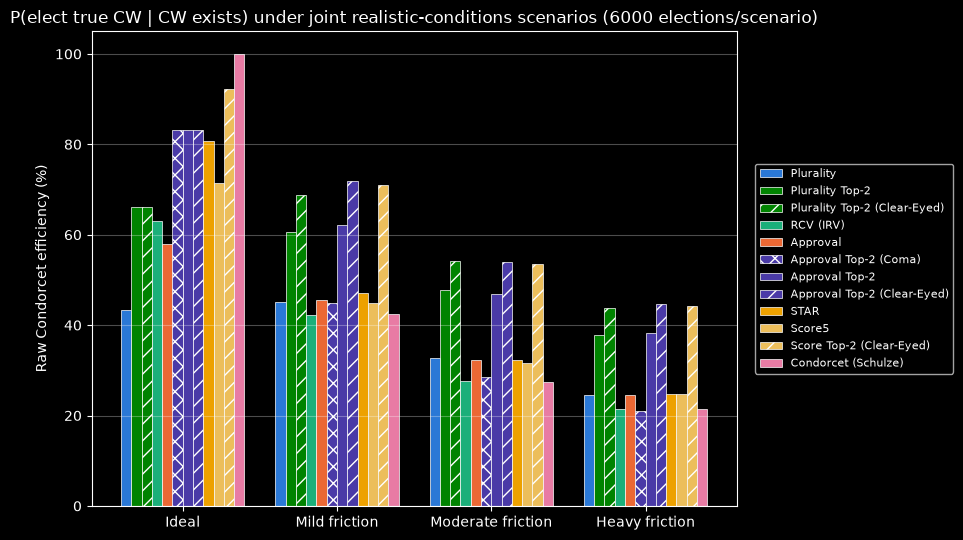

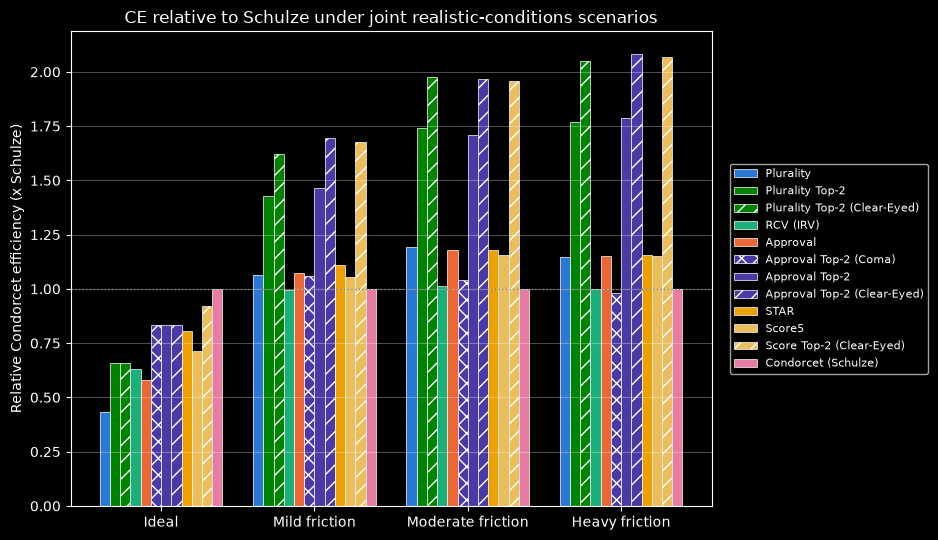

In [30]:
_joint_ce_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                         "|---|" + "---|" * len(_scenario_names)]
for label in COMPARE_LABELS:
    row = [label]
    for name in _scenario_names:
        raw = R.joint_ce_results[name].get((label, "honBallot"))
        rel = relative_ce(R.joint_ce_results[name]).get((label, "honBallot"))
        raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
        rel_str = "" if rel is None else f" ({rel:.2f}x Schulze)"
        row.append(raw_str + rel_str)
    _joint_ce_table_lines.append("| " + " | ".join(row) + " |")
display(Markdown("\n".join(_joint_ce_table_lines)))

# Grouped bar chart: one group per scenario, one bar per method -- same layout as the VSE
# version above, but raw Condorcet efficiency instead of VSE (no error bars: CE has no CI
# computed here, unlike the VSE accumulator's mean/variance tracking).
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    ces = [
        (R.joint_ce_results[name].get((label, "honBallot")) or float("nan")) * 100
        for name in _scenario_names
    ]
    hatch = "//" if "Clear-Eyed" in label else ("xx" if "Coma" in label else None)
    _n_labels = len(COMPARE_LABELS)
    _bar_width = 0.8 / _n_labels
    _x = np.arange(len(_scenario_names))
    ax.bar(_x + i * _bar_width, ces, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor=FG_COLOR, linewidth=0.5)
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Raw Condorcet efficiency (%)")
ax.set_title(f"P(elect true CW | CW exists) under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Same layout as the raw-CE chart above, but relative to Schulze's own CE at each scenario --
# computed once here and reused, rather than recomputing relative_ce(...) per method per scenario.
joint_rel_ce_results = {name: relative_ce(R.joint_ce_results[name]) for name in _scenario_names}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    rels = [
        joint_rel_ce_results[name].get((label, "honBallot"), float("nan"))
        for name in _scenario_names
    ]
    hatch = "//" if "Clear-Eyed" in label else ("xx" if "Coma" in label else None)
    ax.bar(_x + i * _bar_width, rels, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor=FG_COLOR, linewidth=0.5)
ax.axhline(1.0, color="gray", linewidth=1, linestyle=":")  # "same as Schulze"
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Relative Condorcet efficiency (x Schulze)")
ax.set_title("CE relative to Schulze under joint realistic-conditions scenarios")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Condorcet efficiency: paired gap vs Schulze by joint-friction scenario

Reads directly off the main joint-scenario run above, which folds a paired CW-selection-rate diff
for every method vs Schulze into the same simulation pass (same design as the VSE-gap tables
elsewhere in this section) -- quantifies whether the raw-%/relative-to-Schulze numbers above are
actually significant, not just visually different. Scoped to the 3 friction scenarios (Mild/
Moderate/Heavy) -- "Ideal" excluded from paired comparisons throughout this section, same
precedent as every other paired-diff table here.

In [31]:
_ce_gap_lines = []
for name in _scenario_names:
    _ce_gap_lines.extend([
        f"#### {name}: paired Condorcet-efficiency gap vs Schulze (pp)",
        "",
        "| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |",
        "|---|---|---|---|",
    ])
    # sort the labels by the gap (descending) so that the most positive gaps (methods that beat Schulze) are at the top of the table, and the most negative gaps (methods that lose to Schulze) are at the bottom
    sorted_labels = sorted(COMPARE_LABELS, key=lambda label: R.paired_ce_by_scenario[name].get((label, "Condorcet (Schulze)"), (0, 0))[0], reverse=True)
    for label in sorted_labels:
        if label == "Condorcet (Schulze)":
            continue
        if ('Coma' in label or 'Clear-Eyed' in label) and name == "Ideal":
            # skip Coma/Clear-Eyed variants at Ideal, since they are mathematically identical to their base method (see Section 9's _IDENTICAL_AT_IDEAL aliasing)
            continue
        gap, ci = R.paired_ce_by_scenario[name][(label, "Condorcet (Schulze)")]
        gap *= 100
        ci *= 100
        R.significance.register(f"CE gap vs Schulze: {name}", label, gap, ci, label, "Condorcet (Schulze)", spotlight=True)
        _, sig = _verdict_text(gap, ci, label, "Condorcet (Schulze)")
        _ce_gap_lines.append(f"| {label} | {gap:+.1f}% | [{gap-ci:+.1f}%, {gap+ci:+.1f}%] | {sig} |")
    _ce_gap_lines.append("")
display(Markdown("\n".join(_ce_gap_lines)))

#### Ideal: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top-2 | -16.7% | [-18.4%, -15.1%] | Decisive (Condorcet (Schulze) better) |
| STAR | -19.3% | [-21.0%, -17.5%] | Decisive (Condorcet (Schulze) better) |
| Score5 | -28.6% | [-30.6%, -26.6%] | Decisive (Condorcet (Schulze) better) |
| Plurality Top-2 | -34.0% | [-36.1%, -31.9%] | Decisive (Condorcet (Schulze) better) |
| RCV (IRV) | -37.0% | [-39.1%, -34.9%] | Decisive (Condorcet (Schulze) better) |
| Approval | -42.1% | [-44.3%, -39.9%] | Decisive (Condorcet (Schulze) better) |
| Plurality | -56.8% | [-58.9%, -54.6%] | Decisive (Condorcet (Schulze) better) |

#### Mild friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | +29.5% | [+28.3%, +30.7%] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +28.6% | [+27.5%, +29.8%] | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 (Clear-Eyed) | +26.3% | [+25.0%, +27.6%] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | +19.7% | [+18.4%, +21.0%] | Decisive (Approval Top-2 better) |
| Plurality Top-2 | +18.1% | [+16.8%, +19.4%] | Decisive (Plurality Top-2 better) |
| STAR | +4.7% | [+4.0%, +5.4%] | Decisive (STAR better) |
| Approval | +3.1% | [+2.2%, +4.0%] | Decisive (Approval better) |
| Plurality | +2.8% | [+1.7%, +3.9%] | Decisive (Plurality better) |
| Approval Top-2 (Coma) | +2.4% | [+1.7%, +3.2%] | Decisive (Approval Top-2 (Coma) better) |
| Score5 | +2.4% | [+1.6%, +3.2%] | Decisive (Score5 better) |
| RCV (IRV) | -0.2% | [-0.7%, +0.3%] | Indistinguishable |

#### Moderate friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | +26.7% | [+25.6%, +27.9%] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | +26.6% | [+25.4%, +27.7%] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +26.2% | [+25.1%, +27.3%] | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 | +20.3% | [+19.1%, +21.6%] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +19.4% | [+18.2%, +20.7%] | Decisive (Approval Top-2 better) |
| Plurality | +5.3% | [+4.6%, +6.0%] | Decisive (Plurality better) |
| STAR | +4.9% | [+4.4%, +5.5%] | Decisive (STAR better) |
| Approval | +4.9% | [+4.3%, +5.5%] | Decisive (Approval better) |
| Score5 | +4.2% | [+3.7%, +4.8%] | Decisive (Score5 better) |
| Approval Top-2 (Coma) | +1.2% | [+0.7%, +1.7%] | Ambiguous edge (Approval Top-2 (Coma) better) |
| RCV (IRV) | +0.3% | [+0.1%, +0.5%] | Narrow edge (RCV (IRV) better) |

#### Heavy friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | +23.2% | [+22.1%, +24.2%] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +22.9% | [+21.8%, +23.9%] | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 (Clear-Eyed) | +22.5% | [+21.4%, +23.5%] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | +16.8% | [+15.7%, +18.0%] | Decisive (Approval Top-2 better) |
| Plurality Top-2 | +16.5% | [+15.4%, +17.6%] | Decisive (Plurality Top-2 better) |
| STAR | +3.3% | [+2.9%, +3.8%] | Decisive (STAR better) |
| Score5 | +3.2% | [+2.8%, +3.7%] | Decisive (Score5 better) |
| Approval | +3.2% | [+2.7%, +3.7%] | Decisive (Approval better) |
| Plurality | +3.1% | [+2.6%, +3.6%] | Decisive (Plurality better) |
| RCV (IRV) | -0.0% | [-0.2%, +0.2%] | Indistinguishable |
| Approval Top-2 (Coma) | -0.4% | [-0.7%, -0.0%] | Narrow edge (Condorcet (Schulze) better) |


## 20. Method Robustness Rankings

In [32]:
ideal_labels = [l for l in COMPARE_LABELS if 'Coma' not in l and 'Clear-Eyed' not in l]
_ideal_scores_by_method = {
    label: [v for (l, c), v in R.results.items() if l == label]
    for label in ideal_labels
}
display_rankings("Ideal: robustness across strategy levels", _ideal_scores_by_method and
                  compute_robustness_rankings(_ideal_scores_by_method))

other_labels = [l for l in COMPARE_LABELS if 'Score Top' not in l]
# --- 2. Friction only: Mild / Moderate / Heavy (honest ballots) ---
_friction_scenarios = ["Mild friction", "Moderate friction", "Heavy friction"]
_friction_scores_by_method = {
    label: [R.joint_results[name][(label, "honBallot")] for name in _friction_scenarios]
    for label in other_labels
}
display_rankings("Friction only (Mild/Moderate/Heavy)", compute_robustness_rankings(_friction_scores_by_method))

# --- 3. Holistic: Ideal + Mild + Moderate + Heavy (honest ballots) ---
_all_scenarios = list(JOINT_SCENARIOS)
_holistic_scores_by_method = {
    label: [R.joint_results[name][(label, "honBallot")] for name in _all_scenarios]
    for label in other_labels
}
display_rankings("Holistic (Ideal + all friction scenarios)", compute_robustness_rankings(_holistic_scores_by_method))

### Ideal: robustness across strategy levels

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 | 95.8% |
| 2 | STAR | 95.2% |
| 3 | Score5 | 93.7% |
| 4 | Condorcet (Schulze) | 92.2% |
| 5 | Approval | 90.8% |
| 6 | Plurality Top-2 | 86.1% |
| 7 | RCV (IRV) | 83.7% |
| 8 | Plurality | 70.4% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 | 90.8% |
| 2 | STAR | 88.4% |
| 3 | Condorcet (Schulze) | 82.9% |
| 4 | Plurality Top-2 | 82.6% |
| 5 | Approval | 82.1% |
| 6 | Score5 | 81.9% |
| 7 | RCV (IRV) | 75.7% |
| 8 | Plurality | 54.9% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 | 0.5% |
| 2 | STAR | 1.1% |
| 3 | Score5 | 2.6% |
| 4 | Condorcet (Schulze) | 4.1% |
| 5 | Approval | 5.5% |
| 6 | Plurality Top-2 | 10.2% |
| 7 | RCV (IRV) | 12.6% |
| 8 | Plurality | 25.9% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 | 1.88 |
| 2 | STAR | 2.25 |
| 3 | Score5 | 3.12 |
| 4 | Condorcet (Schulze) | 3.75 |
| 5 | Approval | 4.50 |
| 6 | Plurality Top-2 | 6.00 |
| 7 | RCV (IRV) | 6.75 |
| 8 | Plurality | 7.75 |


### Friction only (Mild/Moderate/Heavy)

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 84.0% |
| 2 | Approval Top-2 | 82.5% |
| 3 | Plurality Top-2 (Clear-Eyed) | 82.1% |
| 4 | Plurality Top-2 | 81.0% |
| 5 | STAR | 64.6% |
| 6 | Approval | 64.5% |
| 7 | Score5 | 63.7% |
| 8 | Plurality | 57.4% |
| 9 | Approval Top-2 (Coma) | 57.1% |
| 10 | Condorcet (Schulze) | 51.8% |
| 11 | RCV (IRV) | 51.7% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 74.4% |
| 2 | Plurality Top-2 (Clear-Eyed) | 73.7% |
| 3 | Approval Top-2 | 72.2% |
| 4 | Plurality Top-2 | 72.0% |
| 5 | STAR | 43.6% |
| 6 | Approval | 43.4% |
| 7 | Score5 | 42.9% |
| 8 | Plurality | 41.0% |
| 9 | Approval Top-2 (Coma) | 30.4% |
| 10 | RCV (IRV) | 27.7% |
| 11 | Condorcet (Schulze) | 27.2% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 0.0% |
| 2 | Approval Top-2 | 1.5% |
| 3 | Plurality Top-2 (Clear-Eyed) | 1.9% |
| 4 | Plurality Top-2 | 3.0% |
| 5 | STAR | 19.4% |
| 6 | Approval | 19.4% |
| 7 | Score5 | 20.3% |
| 8 | Plurality | 26.5% |
| 9 | Approval Top-2 (Coma) | 26.9% |
| 10 | Condorcet (Schulze) | 32.1% |
| 11 | RCV (IRV) | 32.3% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 1.00 |
| 2 | Plurality Top-2 (Clear-Eyed) | 2.33 |
| 3 | Approval Top-2 | 2.67 |
| 4 | Plurality Top-2 | 4.00 |
| 5 | STAR | 5.33 |
| 6 | Approval | 5.67 |
| 7 | Score5 | 7.00 |
| 8 | Approval Top-2 (Coma) | 8.67 |
| 9 | Plurality | 9.00 |
| 10 | RCV (IRV) | 10.00 |
| 11 | Condorcet (Schulze) | 10.33 |


### Holistic (Ideal + all friction scenarios)

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 87.0% |
| 2 | Approval Top-2 | 85.9% |
| 3 | Plurality Top-2 (Clear-Eyed) | 82.8% |
| 4 | Plurality Top-2 | 81.9% |
| 5 | STAR | 72.9% |
| 6 | Score5 | 71.8% |
| 7 | Approval | 70.7% |
| 8 | Approval Top-2 (Coma) | 66.8% |
| 9 | Condorcet (Schulze) | 63.5% |
| 10 | RCV (IRV) | 60.8% |
| 11 | Plurality | 58.7% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 74.4% |
| 2 | Plurality Top-2 (Clear-Eyed) | 73.7% |
| 3 | Approval Top-2 | 72.2% |
| 4 | Plurality Top-2 | 72.0% |
| 5 | STAR | 43.6% |
| 6 | Approval | 43.4% |
| 7 | Score5 | 42.9% |
| 8 | Plurality | 41.0% |
| 9 | Approval Top-2 (Coma) | 30.4% |
| 10 | RCV (IRV) | 27.7% |
| 11 | Condorcet (Schulze) | 27.2% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 0.7% |
| 2 | Approval Top-2 | 1.7% |
| 3 | Plurality Top-2 (Clear-Eyed) | 4.9% |
| 4 | Plurality Top-2 | 5.7% |
| 5 | STAR | 14.7% |
| 6 | Score5 | 15.8% |
| 7 | Approval | 16.9% |
| 8 | Approval Top-2 (Coma) | 20.8% |
| 9 | Condorcet (Schulze) | 24.1% |
| 10 | RCV (IRV) | 26.8% |
| 11 | Plurality | 28.9% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 2.25 |
| 2 | Approval Top-2 | 3.25 |
| 3 | Plurality Top-2 (Clear-Eyed) | 4.25 |
| 4 | STAR | 4.50 |
| 5 | Plurality Top-2 | 5.25 |
| 6 | Approval | 6.00 |
| 7 | Score5 | 6.00 |
| 8 | Approval Top-2 (Coma) | 7.50 |
| 9 | Condorcet (Schulze) | 8.00 |
| 10 | Plurality | 9.50 |
| 11 | RCV (IRV) | 9.50 |


## 21. Runoff epistemic-noise sweep: how much does a cleaner delayed runoff improve Approval Top-2?

`Top2Base` takes a continuous `runoff_rho` instead of a binary Coma toggle -- `runoff_rho=None`
reuses the primary's own (possibly noisy) epistemic-noise level for the runoff, but NOT its
participation friction (`runoff_awareness_alpha` defaults to `1.0`, full awareness, independently
of `runoff_rho`); `runoff_rho=1.0` uses the *true* electorate (Clear-Eyed); and any value in between
draws a **fresh, independent** perceived electorate from the *true* electorate at that knowledge
level -- never further noise stacked on the primary's own already-noisy perception, since `rho` is
defined as correlation with *true* utility.

This section asks: if the primary happens under realistic friction, how much does Approval Top-2's outcome recover as the *runoff's own* information quality improves from "no better than the
primary" up to "perfect"? Honest ballots throughout, isolating one question: does a well-informed
delayed runoff rescue a poorly-informed primary?

Two primary-friction baselines, reusing the `JOINT_SCENARIOS` presets from Section 16 directly,
with Schulze's own VSE at those same presets shown as a reference line. STAR's own runoff isn't
modeled here as a hypothetical delayed runoff -- STAR's actual, automatic, same-ballot runoff is
measured directly in Sections 22-23 below.

**Fatigue vs. awareness in the runoff -- two different kinds of assumption.** Fatigue is always
pinned at 1.0 for the runoff, unconditionally: the fatigue mechanism models giving up partway
down a *long* ballot, and 2 named finalists isn't a long ballot to get tired scanning through.

Awareness is a genuinely different, more contestable assumption, and it turns out to matter a
lot more than epistemic noise does (see the results below) -- so rather than assert one answer,
this section runs the sweep under **two**:
- **Awareness resets to 1.0**: voters become aware of all the finalists by runoff time --
  justified by real two-round elections concentrating media coverage and debates on whoever's
  left, which plausibly restores awareness even for a candidate nobody noticed in a crowded
  primary. Brackets the Groggy/Clear-Eyed models, so this is the mode computed at full precision
  below.
- **Awareness carries over from the primary** (the baseline's own `awareness_alpha`, e.g. 0.8 for
  "Moderate friction"): voters who didn't know a finalist during the primary still don't by the
  runoff -- the more conservative assumption. Doesn't bracket a named model, so it's computed
  separately at reduced precision in the secondary section further down instead of doubling this
  section's main runtime.

Each panel also marks `runoff_rho=None` (an "x") -- the plain registered "Approval Top-2" method
(Groggy), which reuses the primary's epistemic-noise level for the runoff. The gap from it to the
first swept point isolates how much of the recovery comes from having any dedicated runoff step
at all, before epistemic knowledge itself improves.

**Common random numbers:** `sweep_runoff_rho` draws each election's true/primary electorate once
and reuses it across every `(method, runoff_rho)` combination for that election, the same
paired-comparison principle `run_vse_simulation` already applies across the `METHODS` list --
sharing randomness between the things being compared cancels most of it out of the comparison,
and cuts total simulation cost too.

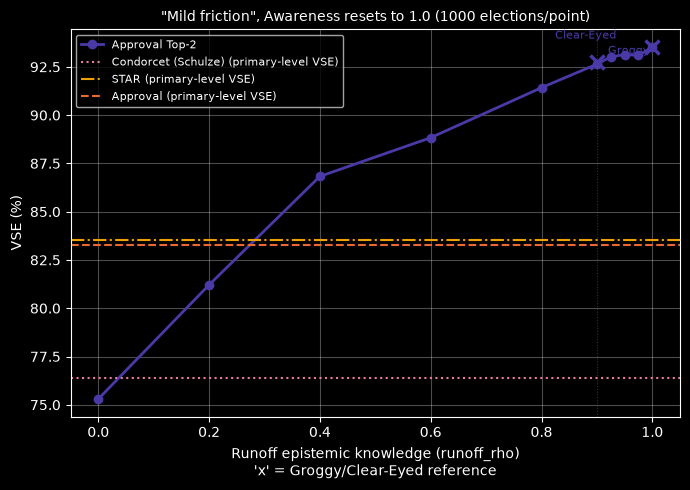

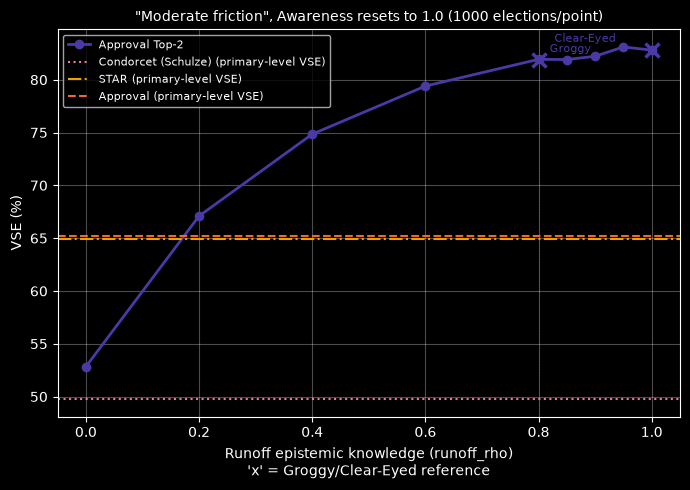

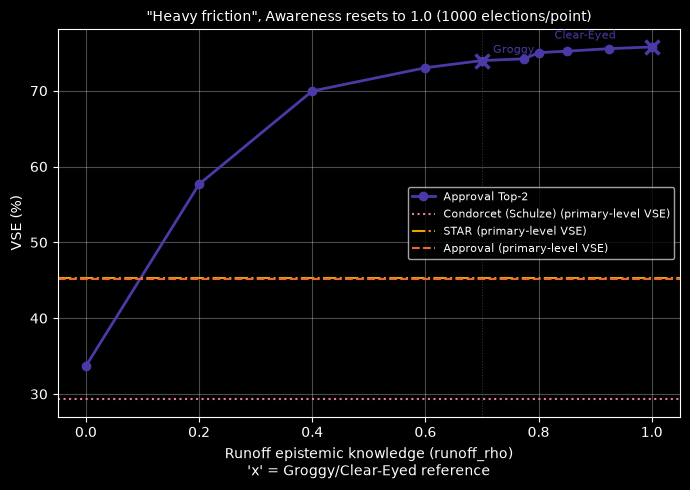

In [33]:
_mode_name = "Awareness resets to 1.0"
for _baseline in RUNOFF_BASELINE_NAMES:
    fig, ax = plt.subplots(figsize=(7, 5))
    results_by_rt = R.runoff_sweep_results[_baseline][_mode_name]
    rho_numeric = sorted(rt for rt in results_by_rt if rt is not None)
    _baseline_rho = JOINT_SCENARIOS[_baseline]["epistemic_rho"]
    for label in RUNOFF_METHOD_FACTORIES:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES.get(label, "-")
        vses = [results_by_rt[rt][(label, "honBallot")][0] * 100 for rt in rho_numeric]
        ax.plot(rho_numeric, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
        # runoff_rho=None (Groggy) plotted AT rho=_baseline_rho, not offset to the side -- with the
        # paired noise in sweep_runoff_rho, a fresh runoff_rho=_baseline_rho draw should land on (or
        # very near) this same point: a real sanity check, not just a visual approximation.
        # runoff_rho=1.0 (the curve's own right endpoint) is EXACTLY Clear-Eyed in this mode
        # (runoff_awareness_alpha=1.0 throughout) -- no separate computation needed.
        none_vse = results_by_rt[None][(label, "honBallot")][0] * 100
        ax.plot([_baseline_rho], [none_vse], marker="x", markersize=10, markeredgewidth=2.5, color=color, zorder=5)
        ax.annotate("Groggy", (_baseline_rho, none_vse), textcoords="offset points", xytext=(8, 6), fontsize=8, color=color)
        ax.plot([rho_numeric[-1]], [vses[-1]], marker="x", markersize=10, markeredgewidth=2.5, color=color, zorder=5)
        ax.annotate("Clear-Eyed", (rho_numeric[-1], vses[-1]), textcoords="offset points", xytext=(-70, 6), fontsize=8, color=color)
    for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-."), ("Approval", "--")]:
        _ref_vse = R.joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
        ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                   label=f"{_ref_label} (primary-level VSE)")
    ax.axvline(_baseline_rho, color="gray", linewidth=0.75, alpha=0.4, linestyle=":")
    #ax.set_xticks(rho_numeric)
    #ax.set_xticklabels([f"{rho:.2f}" for rho in rho_numeric])
    ax.set_xlabel("Runoff epistemic knowledge (runoff_rho)\n'x' = Groggy/Clear-Eyed reference")
    ax.set_ylabel("VSE (%)")
    ax.set_title(f'"{_baseline}", {_mode_name} ({RUNOFF_RHO_SWEEP_NITER} elections/point)', fontsize=10)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [34]:
for _baseline in RUNOFF_BASELINE_NAMES:
    for _mode in R.runoff_sweep_results[_baseline]:
        display(Markdown(f"#### {_baseline}, {_mode.lower()}: VSE by runoff_rho (honest ballots)"))
        results_by_rt = R.runoff_sweep_results[_baseline][_mode]
        rho_numeric = sorted(rt for rt in results_by_rt if rt is not None)
        header = ["Method", "None (=primary reused)"] + [f"rho={rho:.2f}" for rho in rho_numeric]
        lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
        for label in RUNOFF_METHOD_FACTORIES:
            row = [label]
            none_mean, none_ci = results_by_rt[None][(label, "honBallot")]
            row.append(f"{none_mean * 100:.1f}% (+/-{none_ci * 100:.1f})")
            for rt in rho_numeric:
                mean_, ci = results_by_rt[rt][(label, "honBallot")]
                row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
            lines.append("| " + " | ".join(row) + " |")
        display(Markdown("\n".join(lines)))

#### Mild friction, awareness resets to 1.0: VSE by runoff_rho (honest ballots)

| Method | None (=primary reused) | rho=0.00 | rho=0.20 | rho=0.40 | rho=0.60 | rho=0.80 | rho=0.90 | rho=0.93 | rho=0.95 | rho=0.97 | rho=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top-2 | 92.7% (+/-1.0) | 75.3% (+/-2.0) | 81.2% (+/-1.8) | 86.8% (+/-1.4) | 88.8% (+/-1.3) | 91.4% (+/-1.1) | 92.6% (+/-1.0) | 93.0% (+/-1.0) | 93.1% (+/-1.0) | 93.1% (+/-1.1) | 93.5% (+/-1.0) |

#### Moderate friction, awareness resets to 1.0: VSE by runoff_rho (honest ballots)

| Method | None (=primary reused) | rho=0.00 | rho=0.20 | rho=0.40 | rho=0.60 | rho=0.80 | rho=0.85 | rho=0.90 | rho=0.95 | rho=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top-2 | 81.8% (+/-1.9) | 52.8% (+/-3.5) | 67.1% (+/-2.8) | 74.8% (+/-2.4) | 79.4% (+/-2.1) | 81.9% (+/-1.9) | 81.9% (+/-2.0) | 82.2% (+/-2.0) | 83.1% (+/-1.9) | 82.8% (+/-2.0) |

#### Heavy friction, awareness resets to 1.0: VSE by runoff_rho (honest ballots)

| Method | None (=primary reused) | rho=0.00 | rho=0.20 | rho=0.40 | rho=0.60 | rho=0.70 | rho=0.77 | rho=0.80 | rho=0.85 | rho=0.93 | rho=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top-2 | 73.9% (+/-2.4) | 33.7% (+/-4.9) | 57.7% (+/-3.5) | 70.0% (+/-2.6) | 73.0% (+/-2.4) | 74.0% (+/-2.4) | 74.2% (+/-2.4) | 75.0% (+/-2.3) | 75.2% (+/-2.4) | 75.5% (+/-2.4) | 75.8% (+/-2.4) |

### Isolating awareness alone: a genuine "chance to learn" sweep

The sweep above varies the runoff's epistemic knowledge (`runoff_rho`) under two different
assumptions about how much awareness the runoff carries in -- but never holds epistemic
knowledge FIXED and varies awareness on its own, in a way that's actually a clean "chance to
learn" story. This sweep does that directly, using `Top2Base`'s `runoff_kappa` mode: a voter
unaware of a given finalist in the primary gets one independent `Bernoulli(runoff_kappa)` roll
to become aware of that specific finalist by runoff day; a voter already aware stays aware, no
regression. `runoff_kappa=0.0` is an exact match for the Coma model -- no possible roll can
succeed; `runoff_kappa=1.0` is an exact match for the default Groggy model -- every roll is
certain to succeed. Everything in between is a genuine, monotonic interpolation: VSE can only
move in one direction as `runoff_kappa` rises, unlike the `runoff_awareness_alpha`-driven
sweep this replaces, which re-drew awareness fresh at every point.

`runoff_kappa` is swept from `0.0` to `1.0` (same range across all three friction baselines
below -- unlike `runoff_rho`, its meaning doesn't depend on the primary's own `AWARENESS_ALPHA`),
with `runoff_rho` pinned FIXED at one of two values: `None` (the runoff reuses the primary's own
already-noisy information -- no epistemic improvement, only learning) or `1.0` (the runoff has
perfect epistemic information regardless of learning). Only the `None` variant runs here at full
precision (`RUNOFF_SWEEP_NITER` elections/point) -- it's the one that brackets both the Coma
(`p=0`) and Groggy (`p=1`) models. The `runoff_rho=1.0` variant only brackets Clear-Eyed at its
`p=1` endpoint, so it's relegated to the secondary, lower-precision section further down instead
of doubling this section's runtime. Both reuse the same per-baseline electorate pool
(`RUNOFF_ELECTORATE_POOLS`, defined above) the `runoff_rho` sweep already drew, across all three
friction baselines. STAR and Schulze are shown as the same fixed reference lines as the sweep above.


### Sweeping the learn rate

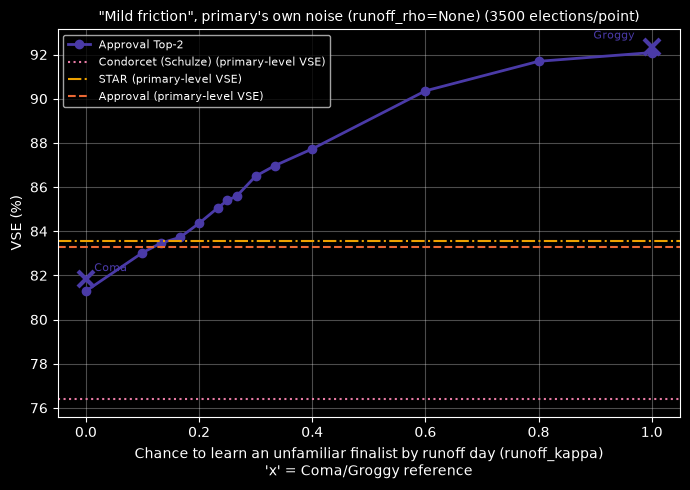

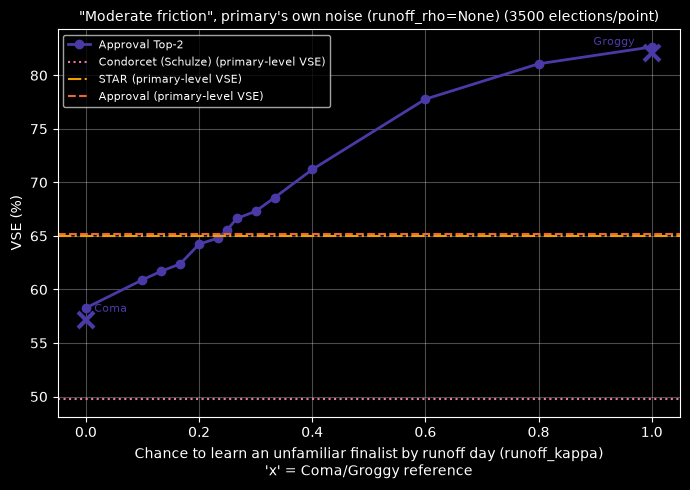

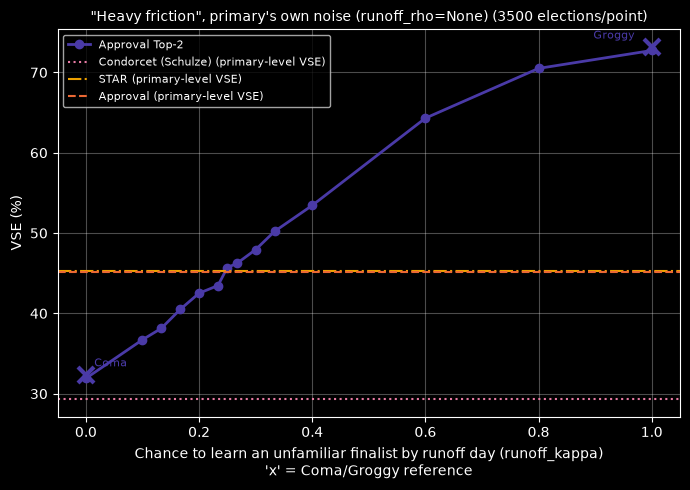

In [35]:
_variant_name = "primary's own noise (runoff_rho=None)"
_rt_fixed = RUNOFF_T_FIXED_VARIANTS[_variant_name]
for _baseline in RUNOFF_BASELINE_NAMES:
    fig, ax = plt.subplots(figsize=(7, 5))
    results_by_kappa = R.learn_sweep_results[_baseline][_variant_name]
    kappa_values = sorted(results_by_kappa)
    for label in RUNOFF_LEARN_METHOD_FACTORIES:
        color = METHOD_COLORS[label]
        style = METHOD_LINESTYLES.get(label, "-")
        vses = [results_by_kappa[kappa][(label, "honBallot")][0] * 100 for kappa in kappa_values]
        ax.plot(kappa_values, vses, marker="o", markersize=6, linewidth=2, color=color, linestyle=style, label=label)
        # kappa=0 is an EXACT match for "<label> (Coma)"; kappa=1 an EXACT match for plain
        # "<label>" (Groggy, the default) -- see RUNOFF_LEARN_METHOD_FACTORIES above.
        _coma_vse = R.joint_results[_baseline][(f"{label} (Coma)", "honBallot")][0] * 100
        ax.plot([0], [_coma_vse], marker="x", markersize=12, markeredgewidth=3, color=color, zorder=5)
        ax.annotate("Coma", (0, _coma_vse), textcoords="offset points", xytext=(6, 6), fontsize=8, color=color)
        _groggy_vse = R.joint_results[_baseline][(label, "honBallot")][0] * 100
        ax.plot([1], [_groggy_vse], marker="x", markersize=12, markeredgewidth=3, color=color, zorder=5)
        ax.annotate("Groggy", (1, _groggy_vse), textcoords="offset points", xytext=(-42, 6), fontsize=8, color=color)
    for _ref_label, _ref_style in [("Condorcet (Schulze)", ":"), ("STAR", "-."), ("Approval", "--")]:
        _ref_vse = R.joint_results[_baseline][(_ref_label, "honBallot")][0] * 100
        ax.axhline(_ref_vse, color=METHOD_COLORS[_ref_label], linewidth=1.5, linestyle=_ref_style,
                   label=f"{_ref_label} (primary-level VSE)")
    ax.set_xlabel("Chance to learn an unfamiliar finalist by runoff day (runoff_kappa)\n'x' = Coma/Groggy reference")
    ax.set_ylabel("VSE (%)")
    ax.set_title(f'"{_baseline}", {_variant_name} ({RUNOFF_SWEEP_NITER} elections/point)', fontsize=10)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [36]:
_variant_name = "primary's own noise (runoff_rho=None)"
display(Markdown("### kappa threshold for AT2 VSE > STAR VSE (95% confidence, paired)\n"))
for _baseline in RUNOFF_BASELINE_NAMES:
    results_by_kappa = R.learn_sweep_results[_baseline][_variant_name]
    paired_diff_by_kappa = R.learn_sweep_paired_diff[_baseline][_variant_name]
    star_mean, star_ci = R.learn_sweep_baseline[_baseline][_variant_name]
    kappa_values = sorted(results_by_kappa)

    lines = [
        f"#### {_baseline}",
        "",
        "| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |",
        "|---|---|---|---|---|---|",
    ]
    threshold_kappa = None
    for kappa in kappa_values:
        at2_mean, _ = results_by_kappa[kappa][("Approval Top-2", "honBallot")]
        gap_mean, ci = paired_diff_by_kappa[kappa]
        gap, ci = gap_mean * 100, ci * 100
        R.significance.register(f"kappa threshold: {_baseline}", f"kappa={kappa:.2f}", gap, ci, "Approval Top-2", "STAR", spotlight=True)
        _bucket, sig = _verdict_text(gap, ci, "Approval Top-2", "STAR")
        if gap > 0 and _bucket not in ("INDISTINGUISHABLE", "INCONCLUSIVE") and threshold_kappa is None:
            threshold_kappa = kappa
        lines.append(
            f"| {kappa:.2f} | {at2_mean*100:.1f} | {star_mean*100:.1f} (+/-{star_ci*100:.1f}) | "
            f"{gap:+.1f} | [{gap-ci:+.1f}, {gap+ci:+.1f}] | {sig} |"
        )
    display(Markdown("\n".join(lines)))
    if threshold_kappa is not None:
        display(Markdown(
            f"**-> First kappa where AT2 is significantly better than STAR in {_baseline} (95% CI gap > 0): `kappa ~ {threshold_kappa:.2f}`**\n"
        ))
    else:
        display(Markdown("**-> AT2 does not significantly exceed STAR at any tested kappa value.**\n"))

### kappa threshold for AT2 VSE > STAR VSE (95% confidence, paired)


#### Mild friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 81.3 | 84.0 (+/-0.9) | -2.7 | [-3.4, -1.9] | Decisive (STAR better) |
| 0.10 | 83.0 | 84.0 (+/-0.9) | -0.9 | [-1.6, -0.3] | Ambiguous edge (STAR better) |
| 0.13 | 83.5 | 84.0 (+/-0.9) | -0.5 | [-1.2, +0.2] | Inconclusive |
| 0.17 | 83.7 | 84.0 (+/-0.9) | -0.2 | [-1.0, +0.5] | Indistinguishable |
| 0.20 | 84.4 | 84.0 (+/-0.9) | +0.4 | [-0.3, +1.1] | Inconclusive |
| 0.23 | 85.1 | 84.0 (+/-0.9) | +1.1 | [+0.4, +1.8] | Ambiguous edge (Approval Top-2 better) |
| 0.25 | 85.4 | 84.0 (+/-0.9) | +1.4 | [+0.7, +2.1] | Ambiguous edge (Approval Top-2 better) |
| 0.27 | 85.6 | 84.0 (+/-0.9) | +1.6 | [+0.9, +2.3] | Ambiguous edge (Approval Top-2 better) |
| 0.30 | 86.5 | 84.0 (+/-0.9) | +2.5 | [+1.8, +3.2] | Decisive (Approval Top-2 better) |
| 0.33 | 87.0 | 84.0 (+/-0.9) | +3.0 | [+2.3, +3.7] | Decisive (Approval Top-2 better) |
| 0.40 | 87.7 | 84.0 (+/-0.9) | +3.8 | [+3.1, +4.5] | Decisive (Approval Top-2 better) |
| 0.60 | 90.4 | 84.0 (+/-0.9) | +6.4 | [+5.7, +7.1] | Decisive (Approval Top-2 better) |
| 0.80 | 91.7 | 84.0 (+/-0.9) | +7.7 | [+6.9, +8.5] | Decisive (Approval Top-2 better) |
| 1.00 | 92.1 | 84.0 (+/-0.9) | +8.1 | [+7.3, +8.9] | Decisive (Approval Top-2 better) |

**-> First kappa where AT2 is significantly better than STAR in Mild friction (95% CI gap > 0): `kappa ~ 0.23`**


#### Moderate friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 58.3 | 66.0 (+/-1.6) | -7.7 | [-8.8, -6.6] | Decisive (STAR better) |
| 0.10 | 60.9 | 66.0 (+/-1.6) | -5.1 | [-6.1, -4.0] | Decisive (STAR better) |
| 0.13 | 61.7 | 66.0 (+/-1.6) | -4.3 | [-5.3, -3.2] | Decisive (STAR better) |
| 0.17 | 62.4 | 66.0 (+/-1.6) | -3.6 | [-4.6, -2.5] | Decisive (STAR better) |
| 0.20 | 64.2 | 66.0 (+/-1.6) | -1.7 | [-2.8, -0.7] | Ambiguous edge (STAR better) |
| 0.23 | 64.8 | 66.0 (+/-1.6) | -1.2 | [-2.2, -0.1] | Ambiguous edge (STAR better) |
| 0.25 | 65.6 | 66.0 (+/-1.6) | -0.4 | [-1.4, +0.6] | Inconclusive |
| 0.27 | 66.6 | 66.0 (+/-1.6) | +0.7 | [-0.4, +1.7] | Inconclusive |
| 0.30 | 67.3 | 66.0 (+/-1.6) | +1.3 | [+0.3, +2.4] | Ambiguous edge (Approval Top-2 better) |
| 0.33 | 68.6 | 66.0 (+/-1.6) | +2.6 | [+1.6, +3.6] | Decisive (Approval Top-2 better) |
| 0.40 | 71.2 | 66.0 (+/-1.6) | +5.2 | [+4.1, +6.4] | Decisive (Approval Top-2 better) |
| 0.60 | 77.8 | 66.0 (+/-1.6) | +11.8 | [+10.6, +13.0] | Decisive (Approval Top-2 better) |
| 0.80 | 81.1 | 66.0 (+/-1.6) | +15.1 | [+13.8, +16.4] | Decisive (Approval Top-2 better) |
| 1.00 | 82.6 | 66.0 (+/-1.6) | +16.7 | [+15.3, +18.0] | Decisive (Approval Top-2 better) |

**-> First kappa where AT2 is significantly better than STAR in Moderate friction (95% CI gap > 0): `kappa ~ 0.30`**


#### Heavy friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 31.9 | 44.9 (+/-2.2) | -13.0 | [-14.7, -11.3] | Decisive (STAR better) |
| 0.10 | 36.7 | 44.9 (+/-2.2) | -8.2 | [-9.7, -6.7] | Decisive (STAR better) |
| 0.13 | 38.1 | 44.9 (+/-2.2) | -6.8 | [-8.3, -5.3] | Decisive (STAR better) |
| 0.17 | 40.5 | 44.9 (+/-2.2) | -4.4 | [-5.7, -3.1] | Decisive (STAR better) |
| 0.20 | 42.5 | 44.9 (+/-2.2) | -2.4 | [-3.8, -1.0] | Decisive (STAR better) |
| 0.23 | 43.5 | 44.9 (+/-2.2) | -1.4 | [-2.8, -0.1] | Ambiguous edge (STAR better) |
| 0.25 | 45.7 | 44.9 (+/-2.2) | +0.8 | [-0.5, +2.1] | Inconclusive |
| 0.27 | 46.2 | 44.9 (+/-2.2) | +1.3 | [-0.0, +2.6] | Inconclusive |
| 0.30 | 47.9 | 44.9 (+/-2.2) | +3.0 | [+1.6, +4.4] | Decisive (Approval Top-2 better) |
| 0.33 | 50.2 | 44.9 (+/-2.2) | +5.3 | [+4.0, +6.6] | Decisive (Approval Top-2 better) |
| 0.40 | 53.4 | 44.9 (+/-2.2) | +8.5 | [+7.1, +10.0] | Decisive (Approval Top-2 better) |
| 0.60 | 64.3 | 44.9 (+/-2.2) | +19.4 | [+17.7, +21.1] | Decisive (Approval Top-2 better) |
| 0.80 | 70.5 | 44.9 (+/-2.2) | +25.6 | [+23.8, +27.4] | Decisive (Approval Top-2 better) |
| 1.00 | 72.7 | 44.9 (+/-2.2) | +27.8 | [+26.0, +29.7] | Decisive (Approval Top-2 better) |

**-> First kappa where AT2 is significantly better than STAR in Heavy friction (95% CI gap > 0): `kappa ~ 0.30`**


The following plots don't really capture a sweep between runoff models, but we measure the difference when noise or awareness is fixed, and we vary the other. Since neither variant brackets a named model, both sweeps are rerun separately here at a much smaller `SECONDARY_SWEEP_NITER` (100 elections/point, vs. the main sections' 2000) rather than paying full precision for a curiosity.

In [37]:
for _baseline in RUNOFF_BASELINE_NAMES:
    for _variant_name in R.learn_sweep_results[_baseline]:
        display(Markdown(f"#### {_baseline}, runoff learning swept, {_variant_name}: VSE by runoff_kappa (honest ballots)"))
        results_by_kappa = R.learn_sweep_results[_baseline][_variant_name]
        kappa_values = sorted(results_by_kappa)
        header = ["Method"] + [f"kappa={kappa:.2f}" for kappa in kappa_values]
        lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
        for label in RUNOFF_LEARN_METHOD_FACTORIES:
            row = [label]
            for kappa in kappa_values:
                mean_, ci = results_by_kappa[kappa][(label, "honBallot")]
                row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
            lines.append("| " + " | ".join(row) + " |")
        display(Markdown("\n".join(lines)))

#### Mild friction, runoff learning swept, primary's own noise (runoff_rho=None): VSE by runoff_kappa (honest ballots)

| Method | kappa=0.00 | kappa=0.10 | kappa=0.13 | kappa=0.17 | kappa=0.20 | kappa=0.23 | kappa=0.25 | kappa=0.27 | kappa=0.30 | kappa=0.33 | kappa=0.40 | kappa=0.60 | kappa=0.80 | kappa=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top-2 | 81.3% (+/-1.0) | 83.0% (+/-1.0) | 83.5% (+/-1.0) | 83.7% (+/-1.0) | 84.4% (+/-0.9) | 85.1% (+/-0.9) | 85.4% (+/-0.9) | 85.6% (+/-0.9) | 86.5% (+/-0.8) | 87.0% (+/-0.8) | 87.7% (+/-0.8) | 90.4% (+/-0.7) | 91.7% (+/-0.6) | 92.1% (+/-0.6) |

#### Moderate friction, runoff learning swept, primary's own noise (runoff_rho=None): VSE by runoff_kappa (honest ballots)

| Method | kappa=0.00 | kappa=0.10 | kappa=0.13 | kappa=0.17 | kappa=0.20 | kappa=0.23 | kappa=0.25 | kappa=0.27 | kappa=0.30 | kappa=0.33 | kappa=0.40 | kappa=0.60 | kappa=0.80 | kappa=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top-2 | 58.3% (+/-1.7) | 60.9% (+/-1.7) | 61.7% (+/-1.7) | 62.4% (+/-1.6) | 64.2% (+/-1.6) | 64.8% (+/-1.6) | 65.6% (+/-1.5) | 66.6% (+/-1.5) | 67.3% (+/-1.5) | 68.6% (+/-1.5) | 71.2% (+/-1.4) | 77.8% (+/-1.1) | 81.1% (+/-1.0) | 82.6% (+/-1.0) |

#### Heavy friction, runoff learning swept, primary's own noise (runoff_rho=None): VSE by runoff_kappa (honest ballots)

| Method | kappa=0.00 | kappa=0.10 | kappa=0.13 | kappa=0.17 | kappa=0.20 | kappa=0.23 | kappa=0.25 | kappa=0.27 | kappa=0.30 | kappa=0.33 | kappa=0.40 | kappa=0.60 | kappa=0.80 | kappa=1.00 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Approval Top-2 | 31.9% (+/-2.6) | 36.7% (+/-2.4) | 38.1% (+/-2.4) | 40.5% (+/-2.3) | 42.5% (+/-2.3) | 43.5% (+/-2.2) | 45.7% (+/-2.2) | 46.2% (+/-2.2) | 47.9% (+/-2.1) | 50.2% (+/-2.1) | 53.4% (+/-2.0) | 64.3% (+/-1.6) | 70.5% (+/-1.4) | 72.7% (+/-1.3) |

## 22. STAR vs. plain Score: isolating the runoff step's own effect

`Srv(STAR_TOP_RANK)` ("STAR") and `Score(STAR_TOP_RANK)` ("Score5") share IDENTICAL ballots --
`Srv0to` subclasses `Score0to` and never overrides `honBallot`, so both methods score the exact
same 0..5 ratings from the exact same voters (see Section 7's `METHODS` registration and Section
1's `Srv`/`Score` definitions). The ONLY difference between them is STAR's automatic pairwise
runoff between the top two. That makes any VSE gap between "STAR" and "Score5" a clean, direct
measurement of the runoff step's own net marginal effect.

The hypothesis under test: if the runoff step helps when ballots are honest and reasonably clean
(STAR > Score5), does that advantage shrink, vanish, or reverse (STAR < Score5) as `epistemic_rho`,
`awareness_alpha`, or `fatigue_beta` degrade the ballots the runoff has to work with? `Score5` is
already one of `COMPARE_LABELS` (Section 14), so this reuses that section's `compare_by_param`
(individual-parameter sweeps, `SWEEP_NITER=250`) and `joint_results` (the four friction scenarios,
`JOINT_NITER=3000`) directly.

#### STAR vs. Score5 by `epistemic_rho`

| Method | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.80 | epistemic_rho=0.90 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 81.8% (+/-1.8) | 89.5% (+/-1.2) | 93.6% (+/-0.9) | 95.2% (+/-0.7) | 95.7% (+/-0.6) | 96.2% (+/-0.4) |
| STAR | 81.9% (+/-1.8) | 88.8% (+/-1.3) | 94.2% (+/-0.8) | 96.0% (+/-0.6) | 96.9% (+/-0.5) | 97.8% (+/-0.4) |

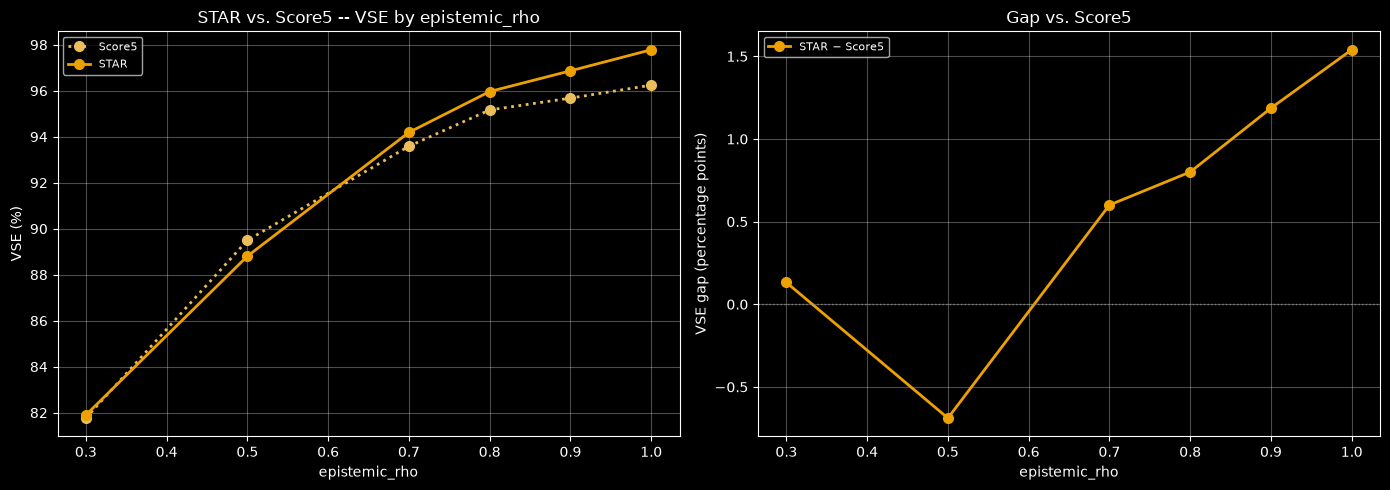

#### STAR vs. Score5 by `awareness_alpha`

| Method | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.80 | awareness_alpha=0.90 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Score5 | -3.0% (+/-6.8) | 9.9% (+/-5.9) | 57.7% (+/-3.2) | 71.4% (+/-2.2) | 81.8% (+/-1.6) | 96.2% (+/-0.4) |
| STAR | -3.0% (+/-6.8) | 12.5% (+/-5.8) | 60.6% (+/-3.1) | 73.6% (+/-2.3) | 84.5% (+/-1.6) | 97.8% (+/-0.4) |

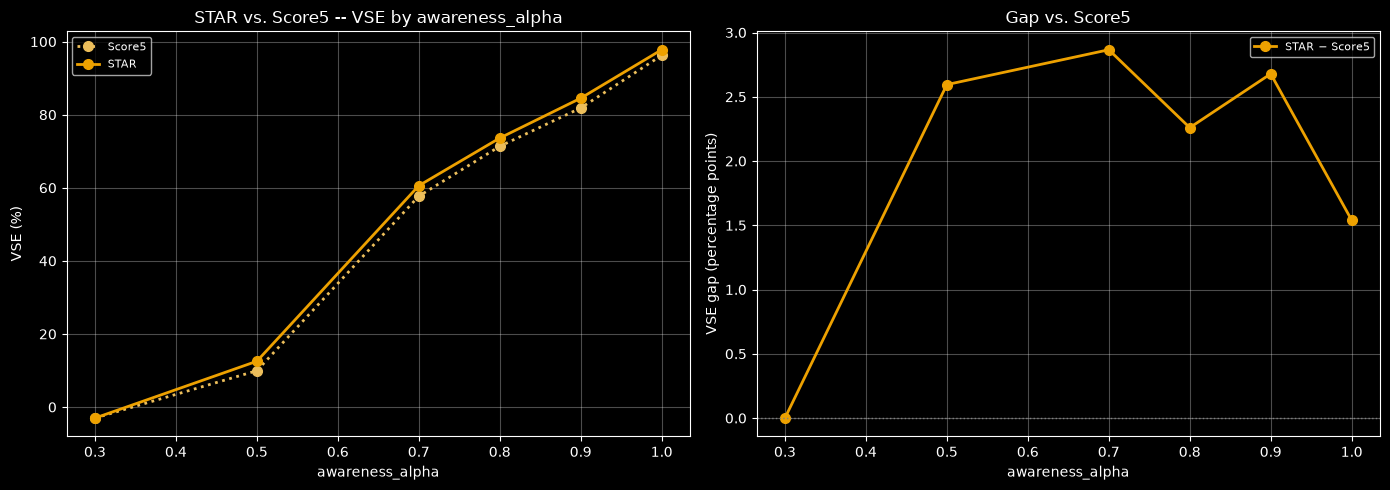

#### STAR vs. Score5 by `fatigue_beta`

| Method | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.80 | fatigue_beta=0.90 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 62.9% (+/-4.0) | 71.0% (+/-3.5) | 84.0% (+/-2.2) | 91.1% (+/-1.5) | 95.9% (+/-0.8) | 96.2% (+/-0.4) |
| STAR | 63.1% (+/-4.0) | 72.2% (+/-3.4) | 84.6% (+/-2.2) | 91.4% (+/-1.3) | 96.2% (+/-0.9) | 97.8% (+/-0.4) |

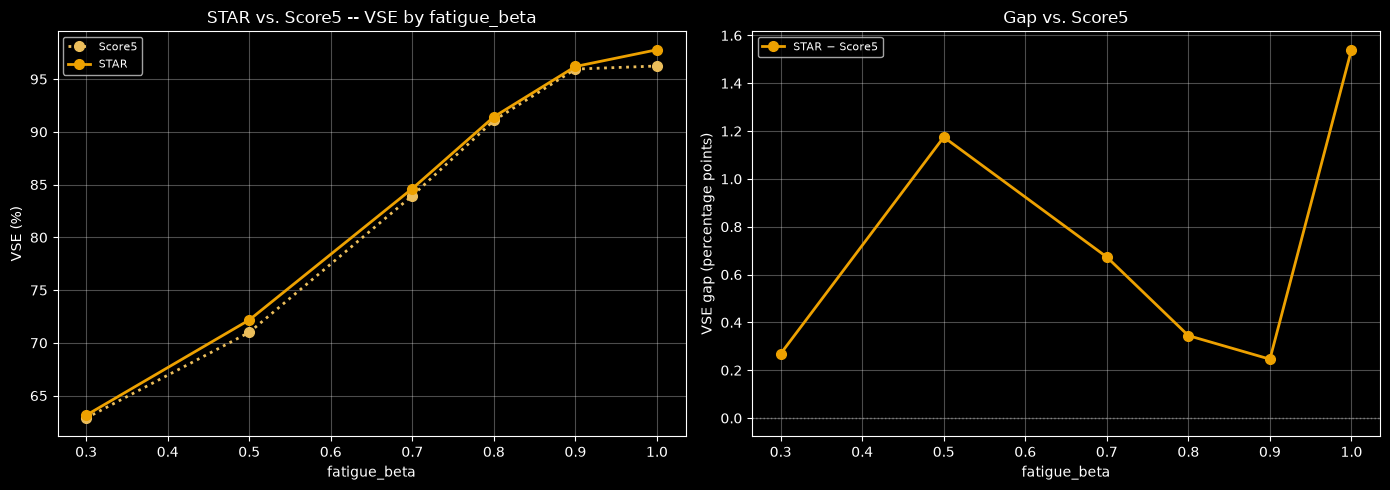

In [38]:
STAR_SCORE_LABELS = ["Score5", "STAR"]

for _param in ["epistemic_rho", "awareness_alpha", "fatigue_beta"]:
    display(Markdown(f"#### STAR vs. Score5 by `{_param}`"))
    comparison_table(compare_by_param[_param], STAR_SCORE_LABELS, _param)
    comparison_chart(compare_by_param[_param], STAR_SCORE_LABELS, _param, baseline_label="Score5",
                      title=f"STAR vs. Score5 -- VSE by {_param}")

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Score5 | 96.2% (+/-0.4) | 82.3% (+/-0.7) | 64.0% (+/-1.2) | 44.6% (+/-1.7) |
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |

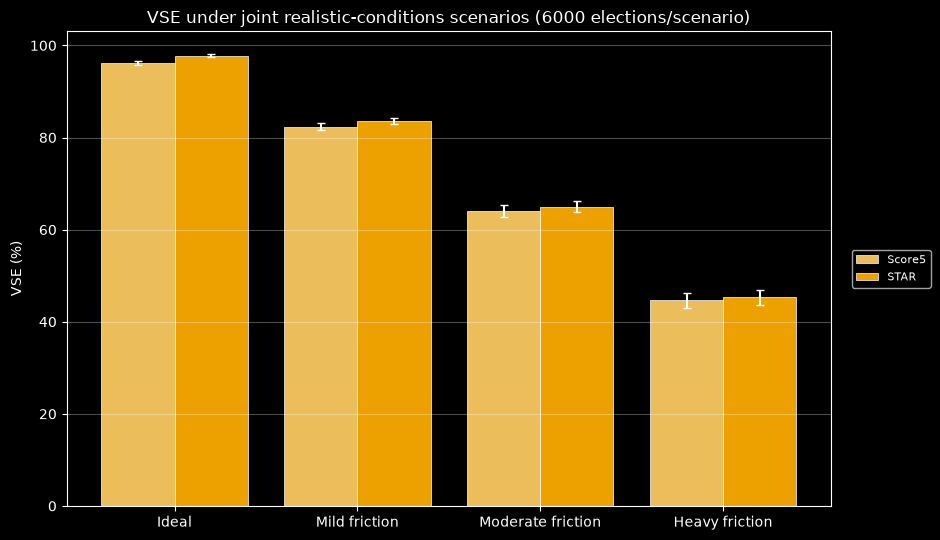

#### Score5 vs STAR: paired VSE gap by joint-friction scenario

| Scenario | Score VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 96.2 | 97.8 | -1.5 | [-2.0, -1.1] | Decisive (STAR better) |
| Mild friction | 82.3 | 83.5 | -1.2 | [-1.6, -0.8] | Ambiguous edge (STAR better) |
| Moderate friction | 64.0 | 65.0 | -0.9 | [-1.4, -0.5] | Ambiguous edge (STAR better) |
| Heavy friction | 44.6 | 45.3 | -0.6 | [-1.1, -0.2] | Ambiguous edge (STAR better) |

In [39]:
# Score5 and STAR
score5_star_labels = ["Score5", "STAR"]
scenario_table_and_plot(score5_star_labels)
display_paired_gap_table("Score5", "STAR", label_short="Score", baseline_short="STAR")

In [40]:
_collapse_rows = []
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise"),
    ("awareness_alpha", "Unfamiliarity"),
    ("fatigue_beta", "Ballot fatigue"),
]:
    results_by_value = compare_by_param[sweep_param]
    _values = sorted(results_by_value)
    _ideal_v, _heavy_v = max(_values), 0.7
    _ideal, _heavy = results_by_value[_ideal_v], results_by_value[_heavy_v]
    star_drop = (_ideal[("STAR", "honBallot")][0] - _heavy[("STAR", "honBallot")][0]) * 100
    score5_drop = (_ideal[("Score5", "honBallot")][0] - _heavy[("Score5", "honBallot")][0]) * 100
    _collapse_rows.append((sweep_param, param_title, star_drop, score5_drop, (star_drop + score5_drop) / 2))

_collapse_rows.sort(key=lambda r: -r[4])
_lines = [
    "#### Which friction parameter drives the shared STAR/Score5 collapse most?",
    "",
    "| Rank | Parameter | STAR VSE drop, ideal to heaviest tested friction (pp) | Score5 VSE drop (pp) | Avg drop (pp) |",
    "|---|---|---|---|---|",
]
for i, (param, title, star_drop, score5_drop, avg) in enumerate(_collapse_rows, start=1):
    _lines.append(f"| {i} | {title} (`{param}`) | {star_drop:+.1f} | {score5_drop:+.1f} | {avg:+.1f} |")
display(Markdown("\n".join(_lines)))

#### Which friction parameter drives the shared STAR/Score5 collapse most?

| Rank | Parameter | STAR VSE drop, ideal to heaviest tested friction (pp) | Score5 VSE drop (pp) | Avg drop (pp) |
|---|---|---|---|---|
| 1 | Unfamiliarity (`awareness_alpha`) | +37.2 | +38.5 | +37.9 |
| 2 | Ballot fatigue (`fatigue_beta`) | +13.2 | +12.3 | +12.7 |
| 3 | Epistemic noise (`epistemic_rho`) | +3.6 | +2.7 | +3.1 |

## 23. Per-election "runoff betrayal" diagnostic



### Does the runoff help or hurt, relative to no runoff at all?

Before digging into STAR's own automatic-runoff betrayal rate below, a more basic question: for
Approval Top-2 and Plurality Top-2, does adding a delayed runoff on top of the base (non-runoff)
method actually help, across each of the three runoff-information assumptions? Reads directly off
the main joint-scenario run (Section 16) -- `Approval Top-2 (Coma/Groggy/Clear-Eyed)` and
`Plurality Top-2 (Groggy/Clear-Eyed)` are each paired against their own family's base method
(`Approval`/`Plurality`), same paired-CI/significance convention as every other gap table in this
notebook.

In [41]:
display_paired_gap_matrix(
    ["Approval Top-2 (Coma)", "Approval Top-2", "Approval Top-2 (Clear-Eyed)"], "Approval",
    title="Does the runoff help or hurt Approval?",
)
display_paired_gap_matrix(
    ["Plurality Top-2", "Plurality Top-2 (Clear-Eyed)"], "Plurality",
    title="Does the runoff help or hurt Plurality?",
)

### Does the runoff help or hurt Approval?

#### Ideal

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 | 89.2 | 96.0 | +6.7 | [+6.0, +7.5] | Decisive (runoff better) |

#### Mild friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | 83.3 | 93.2 | +9.9 | [+9.3, +10.5] | Decisive (runoff better) |
| Approval Top-2 | 83.3 | 92.3 | +9.0 | [+8.4, +9.7] | Decisive (runoff better) |
| Approval Top-2 (Coma) | 83.3 | 81.8 | -1.5 | [-2.1, -0.9] | Ambiguous edge (no runoff better) |

#### Moderate friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | 65.2 | 83.3 | +18.1 | [+17.1, +19.2] | Decisive (runoff better) |
| Approval Top-2 | 65.2 | 82.1 | +16.8 | [+15.8, +17.9] | Decisive (runoff better) |
| Approval Top-2 (Coma) | 65.2 | 57.1 | -8.1 | [-9.1, -7.1] | Decisive (no runoff better) |

#### Heavy friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | 45.1 | 75.4 | +30.2 | [+28.8, +31.7] | Decisive (runoff better) |
| Approval Top-2 | 45.1 | 73.2 | +28.0 | [+26.6, +29.5] | Decisive (runoff better) |
| Approval Top-2 (Coma) | 45.1 | 32.4 | -12.8 | [-14.1, -11.5] | Decisive (no runoff better) |


### Does the runoff help or hurt Plurality?

#### Ideal

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top-2 | 62.7 | 84.7 | +22.1 | [+19.7, +24.5] | Decisive (runoff better) |

#### Mild friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | 68.0 | 89.2 | +21.2 | [+19.7, +22.6] | Decisive (runoff better) |
| Plurality Top-2 | 68.0 | 88.4 | +20.3 | [+18.9, +21.8] | Decisive (runoff better) |

#### Moderate friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | 61.5 | 82.4 | +20.9 | [+19.7, +22.2] | Decisive (runoff better) |
| Plurality Top-2 | 61.5 | 81.5 | +20.1 | [+18.8, +21.3] | Decisive (runoff better) |

#### Heavy friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | 42.8 | 74.7 | +31.9 | [+30.4, +33.5] | Decisive (runoff better) |
| Plurality Top-2 | 42.8 | 73.0 | +30.2 | [+28.6, +31.7] | Decisive (runoff better) |


### Sanity check, then: why does Coma underperform?

The table above shows Coma AT2 scoring *below* plain Approval -- before trusting an explanation
for that, a sanity check: Coma, Groggy (the default `Approval Top-2`), and Clear-Eyed all collapse
to the exact same code path at zero friction (`epistemic_rho=awareness_alpha=fatigue_beta=1.0` --
`_perceived_voters` equals true utilities and `aware_sets` covers everyone regardless of which
runoff mode is active). Their VSE at Ideal must therefore be bit-for-bit identical; a mismatch
would mean a real implementation bug, not a friction effect.

In [42]:
_coma_ideal = R.results[("Approval Top-2 (Coma)", "honBallot")]
_groggy_ideal = R.results[("Approval Top-2", "honBallot")]
_ce_ideal = R.results[("Approval Top-2 (Clear-Eyed)", "honBallot")]
_sanity_ok = _coma_ideal == _groggy_ideal == _ce_ideal
display(Markdown(
    f"**Sanity check -- Coma/Groggy/Clear-Eyed AT2 at Ideal (should be identical):** "
    f"Coma={_coma_ideal[0]*100:.4f}%, Groggy={_groggy_ideal[0]*100:.4f}%, "
    f"Clear-Eyed={_ce_ideal[0]*100:.4f}% -- "
    + ("**MATCH** (no implementation bug at this boundary)." if _sanity_ok
       else "**MISMATCH -- this is a real bug, investigate before trusting the decomposition below.**")
))
assert _sanity_ok, "Coma/Groggy/Clear-Eyed AT2 must be identical at Ideal (same code path) -- mismatch means a bug, not friction."

**Sanity check -- Coma/Groggy/Clear-Eyed AT2 at Ideal (should be identical):** Coma=95.9513%, Groggy=95.9513%, Clear-Eyed=95.9513% -- **MATCH** (no implementation bug at this boundary).

In [43]:
# Reads the Coma-corruption accumulator folded into the main joint-scenario run above (Section
# 16, betrayal_targets/coma_targets on run_vse_simulation) instead of re-simulating its own
# separate AT2_COMA_NITER-election batch per scenario.
at2_coma_stats_by_scenario = {
    name: reduce_coma_summary(R.joint['coma'][name]["Approval Top-2 (Coma)"])
    for name in JOINT_SCENARIOS
}
star_coma_stats_by_scenario = {
    name: reduce_coma_summary(R.joint['coma'][name]["STAR"])
    for name in JOINT_SCENARIOS
}
at2_primary_cost_stats_by_scenario = {
    name: reduce_primary_cost_summary(R.joint['primary_cost'][name]["Approval Top-2"])
    for name in JOINT_SCENARIOS
}

In [44]:
_coma_lines = [
    "#### Coma AT2: why voters end up voting against their own pairwise interest",
    "",
    "| Scenario | Aligned | Awareness-attributable | Noise-unfixable (even if Groggy) |",
    "|---|---|---|---|",
]
for name, stats in at2_coma_stats_by_scenario.items():
    _coma_lines.append(
        f"| {name} | {stats['aligned'] * 100:.1f}% | {stats['awareness_attributable'] * 100:.1f}% | "
        f"{stats['noise_unfixable'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_coma_lines)))

_coma_detail_lines = [
    "#### Coma AT2: detailed breakdown",
    "",
    "| Scenario | Wrong (awareness-fixable) | Wrong (noise-unfixable) | Abstained (awareness-fixable) | Abstained (noise-unfixable) |",
    "|---|---|---|---|---|",
]
for name, stats in at2_coma_stats_by_scenario.items():
    _coma_detail_lines.append(
        f"| {name} | {stats['wrong_awareness_fixable'] * 100:.1f}% | {stats['wrong_noise_unfixable'] * 100:.1f}% | "
        f"{stats['abstained_awareness_fixable'] * 100:.1f}% | {stats['abstained_noise_unfixable'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_coma_detail_lines)))

#### Coma AT2: why voters end up voting against their own pairwise interest

| Scenario | Aligned | Awareness-attributable | Noise-unfixable (even if Groggy) |
|---|---|---|---|
| Ideal | 100.0% | 0.0% | 0.0% |
| Mild friction | 71.2% | 10.9% | 17.9% |
| Moderate friction | 66.3% | 14.5% | 19.2% |
| Heavy friction | 63.3% | 15.8% | 20.8% |

#### Coma AT2: detailed breakdown

| Scenario | Wrong (awareness-fixable) | Wrong (noise-unfixable) | Abstained (awareness-fixable) | Abstained (noise-unfixable) |
|---|---|---|---|---|
| Ideal | 0.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 9.8% | 17.6% | 1.1% | 0.3% |
| Moderate friction | 13.1% | 18.8% | 1.4% | 0.5% |
| Heavy friction | 15.1% | 20.5% | 0.7% | 0.3% |

In [45]:
_election_lines = [
    "#### Coma vs Groggy: election-level aggregate-sign accuracy (does the runoff decision match the true preference?)",
    "",
    "| Scenario | Coma correct | Groggy correct | Both correct | Coma-only correct | Groggy-only correct | Both wrong |",
    "|---|---|---|---|---|---|---|",
]
for name, stats in at2_coma_stats_by_scenario.items():
    _election_lines.append(
        f"| {name} | {stats['coma_accuracy_rate'] * 100:.1f}% | {stats['groggy_accuracy_rate'] * 100:.1f}% | "
        f"{stats['both_correct_rate'] * 100:.1f}% | {stats['coma_only_correct_rate'] * 100:.1f}% | "
        f"{stats['groggy_only_correct_rate'] * 100:.1f}% | {stats['both_wrong_rate'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_election_lines)))
display(Markdown(
    "An election's outcome depends on the aggregate runoff decision, not per-voter accuracy. "
    "That is the metric driving the VSE gap. \"Groggy-only correct\" elections are ones where "
    "fixing awareness alone flips the aggregate decision from wrong to right, even though the "
    "per-voter `awareness_attributable` rate above is modest."
))

#### Coma vs Groggy: election-level aggregate-sign accuracy (does the runoff decision match the true preference?)

| Scenario | Coma correct | Groggy correct | Both correct | Coma-only correct | Groggy-only correct | Both wrong |
|---|---|---|---|---|---|---|
| Ideal | 100.0% | 100.0% | 100.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 61.8% | 85.9% | 55.2% | 6.5% | 30.7% | 7.6% |
| Moderate friction | 51.5% | 85.8% | 44.3% | 7.2% | 41.4% | 7.0% |
| Heavy friction | 46.5% | 85.5% | 38.9% | 7.6% | 46.6% | 6.9% |

An election's outcome depends on the aggregate runoff decision, not per-voter accuracy. That is the metric driving the VSE gap. "Groggy-only correct" elections are ones where fixing awareness alone flips the aggregate decision from wrong to right, even though the per-voter `awareness_attributable` rate above is modest.

In [46]:
display(Markdown(
    "#### Approval Top-2's own runoff-noise VSE cost: Groggy and Coma vs. Clear-Eyed\n\n"
    "Same fixed two finalists as the accuracy table above. \"True\" is Approval Top-2 "
    "(Clear-Eyed)'s own decision, not a re-simulation -- Clear-Eyed's runoff electorate is the "
    "true electorate itself. Coma vs. Groggy is a single net cost, not bucketed: once both "
    "sides are corrupted relative to true, there is no one primary leader to flip away from or "
    "lock in on."
))
_at2_runoff_cost_table(at2_coma_stats_by_scenario, "Scenario")

#### Approval Top-2's own runoff-noise VSE cost: Groggy and Coma vs. Clear-Eyed

Same fixed two finalists as the accuracy table above. "True" is Approval Top-2 (Clear-Eyed)'s own decision, not a re-simulation -- Clear-Eyed's runoff electorate is the true electorate itself. Coma vs. Groggy is a single net cost, not bucketed: once both sides are corrupted relative to true, there is no one primary leader to flip away from or lock in on.

| Scenario | Groggy: bad flip (pp) | Groggy: silent lock-in (pp) | Coma: bad flip (pp) | Coma: silent lock-in (pp) | Coma vs Groggy (pp) |
|---|---|---|---|---|---|
| Ideal | +0.00 | +0.00 | +0.00 | +0.00 | +0.00 |
| Mild friction | +0.49 | +0.32 | +3.54 | +6.97 | +9.70 |
| Moderate friction | +0.69 | +0.57 | +8.47 | +16.51 | +23.74 |
| Heavy friction | +1.04 | +0.84 | +13.22 | +27.49 | +38.84 |

In [47]:
display(Markdown(
    "#### How much does primary noise alone cost Approval Top-2?\n\n"
    "Holds the runoff information level fixed at Groggy. Compares the real (noisy-primary) "
    "Groggy winner against a counterfactual Groggy winner between the finalists an honest "
    "primary would have picked instead -- isolating the primary tally's own noise from the "
    "runoff's information level."
))
_primary_noise_cost_table(at2_primary_cost_stats_by_scenario, "Scenario")

#### How much does primary noise alone cost Approval Top-2?

Holds the runoff information level fixed at Groggy. Compares the real (noisy-primary) Groggy winner against a counterfactual Groggy winner between the finalists an honest primary would have picked instead -- isolating the primary tally's own noise from the runoff's information level.

| Scenario | Primary-noise VSE cost (pp) | Finalist set changed |
|---|---|---|
| Ideal | +0.00 | 0.0% |
| Mild friction | +1.31 | 63.5% |
| Moderate friction | +9.36 | 81.8% |
| Heavy friction | +16.85 | 88.0% |

In [48]:
# Reads the betrayal/flip accumulator folded into the main joint-scenario run above (Section 16,
# betrayal_targets on run_vse_simulation) instead of re-simulating its own separate
# BETRAYAL_NITER-election batch per scenario -- same JOINT_NITER-election precision as every
# other joint-scenario number in this notebook.
betrayal_by_scenario = {
    name: reduce_betrayal_summary(R.joint['betrayal'][name]["STAR"])
    for name in JOINT_SCENARIOS
}

In [49]:
# Reads the betrayal accumulator folded into Section 13's epistemic_rho sweep (see cell 53) --
# reuses SWEEP_VALUES directly (Section 5) rather than its own copy, since that's what
# actually populated R.sweeps['betrayal']['epistemic_rho']; not re-simulated here.
betrayal_by_epistemic_rho = {
    rho: reduce_betrayal_summary(R.sweeps['betrayal']['epistemic_rho'][rho]["STAR"])
    for rho in SWEEP_VALUES
}

### STAR Betrayal Rate

**This measures something different from Section 22, not the same thing on a different scale.**
Section 22 asks whether STAR's runoff changes the winner away from Score5's raw top-score pick at
all -- it rarely does, so that aggregate gap is a wash. This section asks a broader question:
independent of whether the runoff visibly changes anything, does the pairwise decision it actually
makes for this specific pair of finalists agree with what the SAME voters' honest, uncorrupted
preferences would have decided? That also catches cases where the runoff keeps Score5's raw pick,
but that shared pick is itself wrong relative to honest preferences -- and it turns out to be
violated far more often than the runoff visibly flips anything, as the flip-rate section below
shows.

`voter_corruption_rate` is the more granular signal: among individual voters with a genuine
(nonzero) honest preference between the two finalists, how often does their ACTUAL (noisy/
friction-affected) ballot disagree in sign with it. `betrayal_rate` aggregates this to the level of
the runoff DECISION itself: among elections where both the actual and honest signals are decisive,
how often does STAR's automatic runoff produce the OPPOSITE outcome from what a perfectly-informed,
delayed runoff would have produced for that same pair.

The table reports three VSE numbers on the same 0-100(ish) scale as everywhere else in this
notebook: **VSE (STAR's actual runoff)** is STAR's already-known aggregate VSE at that scenario;
**VSE (honest/delayed-perfect runoff)** is the counterfactual if this specific runoff pair had
always used honest preferences instead; and **VSE (AT2 Clear-Eyed runoff)** is "Approval Top-2
(Clear-Eyed)"'s own aggregate VSE at the same scenario -- a real method combining a coarser
Approval primary with a perfect delayed runoff, for direct comparison.

This diagnostic (folded into `run_vse_simulation`'s `betrayal_targets` accumulator -- Section 8)
compares the pairwise upset sign from actual (noisy/friction-affected) ballots against the SAME
sign computed from HONEST ballots on the TRUE electorate -- both cast the same way (same
`honBallot` floor-to-`0..topRank` discretization), rather than against raw continuous utilities,
so a small honest margin that floors to a tie doesn't get counted as noise's fault.

In [50]:
display(Markdown("#### Runoff betrayal rate by joint-friction scenario"))
_betrayal_table(betrayal_by_scenario, "Scenario",
                 star_vse_lookup=lambda name: R.joint_results[name][("STAR", "honBallot")][0],
                 at2_vse_lookup=lambda name: R.joint_results[name][("Approval Top-2 (Clear-Eyed)", "honBallot")][0])

#### Runoff betrayal rate by joint-friction scenario

| Scenario | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE (AT2 Clear-Eyed runoff) |
|---|---|---|---|---|---|
| Ideal | 0.0% | 0.00% | 97.8% | 97.8% (+0.0 pts over actual) | 96.0% (-1.8 pts over STAR) |
| Mild friction | 33.0% | 35.80% | 83.5% | 91.0% (+7.5 pts over actual) | 93.2% (+9.7 pts over STAR) |
| Moderate friction | 39.4% | 45.16% | 65.0% | 81.0% (+16.0 pts over actual) | 83.3% (+18.4 pts over STAR) |
| Heavy friction | 43.7% | 48.85% | 45.3% | 71.4% (+26.2 pts over actual) | 75.4% (+30.1 pts over STAR) |

In [51]:
_star_coma_lines = [
    "#### STAR: why the automatic runoff ends up voting against voters' own pairwise interest",
    "",
    "| Scenario | Aligned | Awareness-attributable | Noise-unfixable (even if fully aware) |",
    "|---|---|---|---|",
]
for name, stats in star_coma_stats_by_scenario.items():
    _star_coma_lines.append(
        f"| {name} | {stats['aligned'] * 100:.1f}% | {stats['awareness_attributable'] * 100:.1f}% | "
        f"{stats['noise_unfixable'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_star_coma_lines)))

_star_coma_detail_lines = [
    "#### STAR: detailed breakdown",
    "",
    "| Scenario | Wrong (awareness-fixable) | Wrong (noise-unfixable) | Abstained (awareness-fixable) | Abstained (noise-unfixable) |",
    "|---|---|---|---|---|",
]
for name, stats in star_coma_stats_by_scenario.items():
    _star_coma_detail_lines.append(
        f"| {name} | {stats['wrong_awareness_fixable'] * 100:.1f}% | {stats['wrong_noise_unfixable'] * 100:.1f}% | "
        f"{stats['abstained_awareness_fixable'] * 100:.1f}% | {stats['abstained_noise_unfixable'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_star_coma_detail_lines)))

_star_vs_aware_lines = [
    "#### STAR's actual automatic runoff vs a fully-aware counterfactual: election-level aggregate-sign accuracy",
    "",
    "| Scenario | STAR (actual) correct | Fully-aware counterfactual correct | Both correct | STAR-only correct | Counterfactual-only correct | Both wrong |",
    "|---|---|---|---|---|---|---|",
]
for name, stats in star_coma_stats_by_scenario.items():
    _star_vs_aware_lines.append(
        f"| {name} | {stats['coma_accuracy_rate'] * 100:.1f}% | {stats['groggy_accuracy_rate'] * 100:.1f}% | "
        f"{stats['both_correct_rate'] * 100:.1f}% | {stats['coma_only_correct_rate'] * 100:.1f}% | "
        f"{stats['groggy_only_correct_rate'] * 100:.1f}% | {stats['both_wrong_rate'] * 100:.1f}% |"
    )
display(Markdown("\n".join(_star_vs_aware_lines)))
display(Markdown(
    "An election's outcome depends on the aggregate runoff decision, not per-voter accuracy. "
    "\"Counterfactual-only correct\" elections are ones where removing unawareness and fatigue "
    "alone, holding epistemic noise fixed, flips the automatic runoff's aggregate decision from "
    "wrong to right, even though the per-voter `awareness_attributable` rate above is modest."
))

#### STAR: why the automatic runoff ends up voting against voters' own pairwise interest

| Scenario | Aligned | Awareness-attributable | Noise-unfixable (even if fully aware) |
|---|---|---|---|
| Ideal | 100.0% | 0.0% | 0.0% |
| Mild friction | 71.9% | 10.6% | 17.4% |
| Moderate friction | 66.6% | 14.3% | 19.1% |
| Heavy friction | 63.5% | 15.7% | 20.8% |

#### STAR: detailed breakdown

| Scenario | Wrong (awareness-fixable) | Wrong (noise-unfixable) | Abstained (awareness-fixable) | Abstained (noise-unfixable) |
|---|---|---|---|---|
| Ideal | 0.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 9.6% | 17.2% | 1.0% | 0.3% |
| Moderate friction | 13.0% | 18.7% | 1.3% | 0.4% |
| Heavy friction | 15.0% | 20.5% | 0.7% | 0.3% |

#### STAR's actual automatic runoff vs a fully-aware counterfactual: election-level aggregate-sign accuracy

| Scenario | STAR (actual) correct | Fully-aware counterfactual correct | Both correct | STAR-only correct | Counterfactual-only correct | Both wrong |
|---|---|---|---|---|---|---|
| Ideal | 100.0% | 100.0% | 100.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 62.5% | 86.4% | 56.2% | 6.3% | 30.1% | 7.3% |
| Moderate friction | 52.0% | 86.1% | 44.9% | 7.1% | 41.2% | 6.8% |
| Heavy friction | 47.0% | 85.5% | 39.3% | 7.7% | 46.2% | 6.8% |

An election's outcome depends on the aggregate runoff decision, not per-voter accuracy. "Counterfactual-only correct" elections are ones where removing unawareness and fatigue alone, holding epistemic noise fixed, flips the automatic runoff's aggregate decision from wrong to right, even though the per-voter `awareness_attributable` rate above is modest.

### Paired VSE gap: Score Top-2 (Clear-Eyed) vs Approval Top-2 (Clear-Eyed)

"Score Top-2 (Clear-Eyed)" (Section 6) is now a real registered method -- a Score(STAR_TOP_RANK)
primary with an idealized/delayed clear-eyed runoff, the Top2Base analogue of "Approval Top-2
(Clear-Eyed)" but with STAR's finer 0..5 ballot instead of Approval's 0/1 ballot. It rides the same
`_joint_electorate_pool` simulation pass as every other `COMPARE_LABELS` method (Section 16), so
this reads directly off `paired_diff_by_scenario` -- no separate re-simulation, unlike the old
bespoke "theoretical SCORE Top-2" computation this replaces. Directly answers whether a coarse
(Approval) ballot is actually more effective than a fine-grained (0..5 Score) ballot once both get
an idealized/delayed runoff to correct their pick.

In [52]:
display_paired_gap_table("Score Top-2 (Clear-Eyed)", "Approval Top-2 (Clear-Eyed)", label_short="Score Top-2", baseline_short="AT2", spotlight=True)

#### Score Top-2 (Clear-Eyed) vs Approval Top-2 (Clear-Eyed): paired VSE gap by joint-friction scenario

| Scenario | Score Top-2 VSE (%) | AT2 VSE (%) | Gap vs AT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 98.3 | 96.0 | +2.3 | [+1.8, +2.8] | Decisive (Score Top-2 better) |
| Mild friction | 93.1 | 93.2 | -0.1 | [-0.4, +0.1] | Indistinguishable |
| Moderate friction | 83.1 | 83.3 | -0.2 | [-0.6, +0.2] | Indistinguishable |
| Heavy friction | 75.4 | 75.4 | +0.1 | [-0.3, +0.4] | Indistinguishable |

In [53]:
display_paired_gap_table("Score Top-2 (Clear-Eyed)", "STAR", label_short="Score Top-2", baseline_short="STAR")

#### Score Top-2 (Clear-Eyed) vs STAR: paired VSE gap by joint-friction scenario

| Scenario | Score Top-2 VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 98.3 | 97.8 | +0.5 | [+0.3, +0.7] | Narrow edge (Score Top-2 better) |
| Mild friction | 93.1 | 83.5 | +9.6 | [+9.0, +10.2] | Decisive (Score Top-2 better) |
| Moderate friction | 83.1 | 65.0 | +18.2 | [+17.2, +19.2] | Decisive (Score Top-2 better) |
| Heavy friction | 75.4 | 45.3 | +30.2 | [+28.8, +31.6] | Decisive (Score Top-2 better) |

In [54]:
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise"),
    ("awareness_alpha", "Unfamiliarity"),
    ("fatigue_beta", "Ballot fatigue"),
]:
    display_paired_gap_by_sweep_value(
        "Score Top-2 (Clear-Eyed)", "STAR", sweep_param,
        R.sweep_results_by_param[sweep_param], R.sweep_paired_diff_by_param[sweep_param],
        label_short="Score Top-2", baseline_short="STAR",
        title=f"Score Top-2 (Clear-Eyed) vs STAR ({param_title})",
    )

#### Score Top-2 (Clear-Eyed) vs STAR (Epistemic noise): paired VSE gap by `epistemic_rho`

| epistemic_rho | Score Top-2 VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| 0.30 | 93.0 | 81.9 | +11.1 | [+9.6, +12.7] | Decisive (Score Top-2 better) |
| 0.50 | 95.9 | 88.8 | +7.1 | [+5.9, +8.4] | Decisive (Score Top-2 better) |
| 0.70 | 97.7 | 94.2 | +3.5 | [+2.8, +4.2] | Decisive (Score Top-2 better) |
| 0.80 | 98.3 | 96.0 | +2.3 | [+1.7, +2.9] | Decisive (Score Top-2 better) |
| 0.90 | 98.2 | 96.9 | +1.3 | [+0.9, +1.7] | Ambiguous edge (Score Top-2 better) |
| 1.00 | 98.3 | 97.8 | +0.5 | [+0.3, +0.7] | Narrow edge (Score Top-2 better) |

#### Score Top-2 (Clear-Eyed) vs STAR (Unfamiliarity): paired VSE gap by `awareness_alpha`

| awareness_alpha | Score Top-2 VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| 0.30 | 64.7 | -3.0 | +67.7 | [+61.3, +74.1] | Decisive (Score Top-2 better) |
| 0.50 | 69.8 | 12.5 | +57.3 | [+51.9, +62.7] | Decisive (Score Top-2 better) |
| 0.70 | 80.8 | 60.6 | +20.3 | [+17.8, +22.8] | Decisive (Score Top-2 better) |
| 0.80 | 86.6 | 73.6 | +13.0 | [+11.1, +14.8] | Decisive (Score Top-2 better) |
| 0.90 | 91.3 | 84.5 | +6.8 | [+5.5, +8.1] | Decisive (Score Top-2 better) |
| 1.00 | 98.3 | 97.8 | +0.5 | [+0.3, +0.7] | Narrow edge (Score Top-2 better) |

#### Score Top-2 (Clear-Eyed) vs STAR (Ballot fatigue): paired VSE gap by `fatigue_beta`

| fatigue_beta | Score Top-2 VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| 0.30 | 87.2 | 63.1 | +24.0 | [+20.7, +27.4] | Decisive (Score Top-2 better) |
| 0.50 | 89.2 | 72.2 | +17.0 | [+14.3, +19.8] | Decisive (Score Top-2 better) |
| 0.70 | 94.5 | 84.6 | +9.9 | [+8.0, +11.8] | Decisive (Score Top-2 better) |
| 0.80 | 96.7 | 91.4 | +5.3 | [+4.2, +6.4] | Decisive (Score Top-2 better) |
| 0.90 | 97.8 | 96.2 | +1.6 | [+0.9, +2.4] | Ambiguous edge (Score Top-2 better) |
| 1.00 | 98.3 | 97.8 | +0.5 | [+0.3, +0.7] | Narrow edge (Score Top-2 better) |

In [55]:
_gap_rows = []
for sweep_param, param_title in [
    ("epistemic_rho", "Epistemic noise"),
    ("awareness_alpha", "Unfamiliarity"),
    ("fatigue_beta", "Ballot fatigue"),
]:
    _by_value = R.sweep_results_by_param[sweep_param]
    star_heavy = _by_value[0.7][("STAR", "honBallot")][0] * 100
    ce_heavy = _by_value[0.7][("Score Top-2 (Clear-Eyed)", "honBallot")][0] * 100
    _gap_rows.append((sweep_param, param_title, ce_heavy - star_heavy))

_gap_rows.sort(key=lambda r: -abs(r[2]))
_lines = [
    "#### Which parameter drives the STAR vs. Score Top-2 (Clear-Eyed) gap most?",
    "",
    "| Rank | Parameter | Gap at heaviest tested friction (Score Top-2 CE minus STAR, pp) |",
    "|---|---|---|",
]
for i, (param, title, gap) in enumerate(_gap_rows, start=1):
    _lines.append(f"| {i} | {title} (`{param}`) | {gap:+.1f} |")
display(Markdown("\n".join(_lines)))

#### Which parameter drives the STAR vs. Score Top-2 (Clear-Eyed) gap most?

| Rank | Parameter | Gap at heaviest tested friction (Score Top-2 CE minus STAR, pp) |
|---|---|---|
| 1 | Unfamiliarity (`awareness_alpha`) | +20.3 |
| 2 | Ballot fatigue (`fatigue_beta`) | +9.9 |
| 3 | Epistemic noise (`epistemic_rho`) | +3.5 |

In [56]:
display(Markdown("#### Runoff betrayal rate by `epistemic_rho` alone (`awareness_alpha=fatigue_beta=1.0`)"))
_betrayal_table(betrayal_by_epistemic_rho, "epistemic_rho",
                 star_vse_lookup=lambda rho: R.sweep_results_by_param["epistemic_rho"][rho][("STAR", "honBallot")][0],
                 at2_vse_lookup=lambda rho: R.sweep_results_by_param["epistemic_rho"][rho][("Approval Top-2 (Clear-Eyed)", "honBallot")][0],
                 key_fmt=lambda rho: f"{rho:.2f}")

#### Runoff betrayal rate by `epistemic_rho` alone (`awareness_alpha=fatigue_beta=1.0`)

| epistemic_rho | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE (AT2 Clear-Eyed runoff) |
|---|---|---|---|---|---|
| 0.30 | 38.6% | 49.17% | 81.9% | 91.7% (+9.8 pts over actual) | 90.7% (+8.8 pts over STAR) |
| 0.50 | 32.2% | 43.78% | 88.8% | 94.5% (+5.7 pts over actual) | 95.4% (+6.6 pts over STAR) |
| 0.70 | 27.4% | 37.50% | 94.2% | 96.8% (+2.6 pts over actual) | 96.8% (+2.6 pts over STAR) |
| 0.80 | 23.1% | 32.72% | 96.0% | 97.5% (+1.5 pts over actual) | 97.6% (+1.7 pts over STAR) |
| 0.90 | 19.4% | 26.65% | 96.9% | 97.3% (+0.4 pts over actual) | 97.1% (+0.2 pts over STAR) |
| 1.00 | 0.0% | 0.00% | 97.8% | 97.8% (+0.0 pts over actual) | 96.0% (-1.8 pts over STAR) |

### Why does a near-zero aggregate gap coexist with a much higher betrayal rate? The flip rate.

Section 22's STAR-minus-Score5 gap is a wash because the runoff rarely changes the winner away
from Score5's naive top-score pick at all -- and when it does, roughly as many of those flips are
"good" (agree with what honest ballots would have decided) as "bad" (betrayals, per the diagnostic
above), canceling out in the aggregate VSE average. That cancellation is real, but it's the wrong
comfort for a one-shot election: it says the runoff's mistakes average out across many
*hypothetical* elections, not that any *given* election's flip is safe. The table below reports,
per scenario: how often the runoff changes the winner away from Score5's pick at all (the
"flip rate"), and -- of those flips -- what fraction are good vs. bad. This reuses the exact same
noisy/honest upset signs the betrayal diagnostic above already computed (see run_vse_simulation's
betrayal_targets docstring) -- just a different bucketing of the same per-election values, not a
separate computation.


In [57]:
# Flip stats are bucketed from the exact same noisy/honest upset signs the betrayal diagnostic
# above already computed, in the same run_vse_simulation pass -- reduce_betrayal_summary returns
# both sets of fields together, so this is literally the same reduced dict, not a new computation.
flip_by_scenario = betrayal_by_scenario

In [58]:
_flip_lines = ["#### Runoff flip rate by joint-friction scenario",
               "",
                "| Scenario | Flip rate (of all elections) | Good flips | Bad flips (betrayals) | Honest-tied |",
               "|---|---|---|---|---|"]
for name, stats in flip_by_scenario.items():
    _flip_lines.append(
        f"| {name} | {stats['flip_rate'] * 100:.1f}% ({stats['n_flips']}/{stats['n_elections']}) | "
        f"{stats['good_flip_rate'] * 100:.1f}% | "
        f"{stats['bad_flip_rate'] * 100:.1f}% | "
        f"{stats['n_honest_tied_flips']} |"
    )
display(Markdown("\n".join(_flip_lines)))

#### Runoff flip rate by joint-friction scenario

| Scenario | Flip rate (of all elections) | Good flips | Bad flips (betrayals) | Honest-tied |
|---|---|---|---|---|
| Ideal | 11.8% (237/2000) | 100.0% | 0.0% | 0 |
| Mild friction | 8.6% (514/6000) | 68.7% | 29.2% | 11 |
| Moderate friction | 3.9% (234/6000) | 64.5% | 34.2% | 3 |
| Heavy friction | 1.5% (90/6000) | 67.8% | 32.2% | 0 |

In [59]:
display(Markdown(
    "#### Garbage in, garbage out? Splitting betrayals into active bad flips vs. silent lock-in\n\n"
    "\"Bad flip\" is the runoff actively overturning the noisy primary's leader in the wrong "
    "direction. \"Silent lock-in\" is the runoff doing nothing: the noisy primary's leader is "
    "confirmed by default, but that leader was already the honestly-wrong choice. The automatic "
    "runoff has no independent source of information, so a primary corrupted by "
    "epistemic_rho/awareness_alpha/fatigue_beta gets rubber-stamped rather than corrected. The "
    "runoff itself rarely breaks something that wasn't already broken."
))
_betrayal_breakdown_table(betrayal_by_scenario, "Scenario")

#### Garbage in, garbage out? Splitting betrayals into active bad flips vs. silent lock-in

"Bad flip" is the runoff actively overturning the noisy primary's leader in the wrong direction. "Silent lock-in" is the runoff doing nothing: the noisy primary's leader is confirmed by default, but that leader was already the honestly-wrong choice. The automatic runoff has no independent source of information, so a primary corrupted by epistemic_rho/awareness_alpha/fatigue_beta gets rubber-stamped rather than corrected. The runoff itself rarely breaks something that wasn't already broken.

| Scenario | Aligned | Bad flip (betrayal) | Silent lock-in (betrayal) | Good flip | Other | VSE cost: bad flips (pp) | VSE cost: silent lock-in (pp) |
|---|---|---|---|---|---|---|---|
| Ideal | 85.8% | 0.0% | 0.0% | 11.8% | 2.4% | +0.00 | +0.00 |
| Mild friction | 57.8% | 2.5% | 28.9% | 5.9% | 5.0% | +0.96 | +6.54 |
| Moderate friction | 55.8% | 1.3% | 36.5% | 2.5% | 3.8% | +0.87 | +15.17 |
| Heavy friction | 53.6% | 0.5% | 41.9% | 1.0% | 3.0% | +0.60 | +25.56 |

In [60]:
display(Markdown("#### Betrayal breakdown by `epistemic_rho` alone (`awareness_alpha=fatigue_beta=1.0`)"))
_betrayal_breakdown_table(betrayal_by_epistemic_rho, "epistemic_rho", key_fmt=lambda rho: f"{rho:.2f}")

#### Betrayal breakdown by `epistemic_rho` alone (`awareness_alpha=fatigue_beta=1.0`)

| epistemic_rho | Aligned | Bad flip (betrayal) | Silent lock-in (betrayal) | Good flip | Other | VSE cost: bad flips (pp) | VSE cost: silent lock-in (pp) |
|---|---|---|---|---|---|---|---|
| 0.30 | 48.0% | 9.0% | 26.7% | 8.9% | 7.4% | +2.79 | +6.98 |
| 0.50 | 54.9% | 7.6% | 21.9% | 7.2% | 8.4% | +1.88 | +3.78 |
| 0.70 | 60.8% | 6.6% | 18.9% | 6.8% | 6.9% | +0.76 | +1.84 |
| 0.80 | 64.0% | 4.1% | 17.3% | 7.4% | 7.2% | +0.29 | +1.20 |
| 0.90 | 69.1% | 3.6% | 14.6% | 6.6% | 6.1% | +0.15 | +0.27 |
| 1.00 | 85.8% | 0.0% | 0.0% | 11.8% | 2.4% | +0.00 | +0.00 |

In [61]:
# Reuses SWEEP_VALUES directly (Section 5) rather than its own copy -- see 9b7c68d0 above.
betrayal_by_awareness_alpha = {a: reduce_betrayal_summary(R.sweeps['betrayal']['awareness_alpha'][a]["STAR"]) for a in SWEEP_VALUES}
betrayal_by_fatigue_beta = {b: reduce_betrayal_summary(R.sweeps['betrayal']['fatigue_beta'][b]["STAR"]) for b in SWEEP_VALUES}

display(Markdown("#### Betrayal breakdown by `awareness_alpha` alone (`epistemic_rho=fatigue_beta=1.0`)"))
_betrayal_breakdown_table(betrayal_by_awareness_alpha, "awareness_alpha", key_fmt=lambda a: f"{a:.2f}")

display(Markdown("#### Betrayal breakdown by `fatigue_beta` alone (`epistemic_rho=awareness_alpha=1.0`)"))
_betrayal_breakdown_table(betrayal_by_fatigue_beta, "fatigue_beta", key_fmt=lambda b: f"{b:.2f}")

#### Betrayal breakdown by `awareness_alpha` alone (`epistemic_rho=fatigue_beta=1.0`)

| awareness_alpha | Aligned | Bad flip (betrayal) | Silent lock-in (betrayal) | Good flip | Other | VSE cost: bad flips (pp) | VSE cost: silent lock-in (pp) |
|---|---|---|---|---|---|---|---|
| 0.30 | 44.5% | 0.0% | 54.2% | 0.0% | 1.3% | +0.00 | +71.63 |
| 0.50 | 41.1% | 0.0% | 55.3% | 1.8% | 1.8% | +0.00 | +49.58 |
| 0.70 | 52.8% | 0.7% | 38.4% | 5.3% | 2.8% | +0.71 | +18.87 |
| 0.80 | 55.8% | 1.6% | 32.0% | 7.5% | 3.1% | +1.01 | +11.23 |
| 0.90 | 56.7% | 3.4% | 20.4% | 14.9% | 4.6% | +1.37 | +4.19 |
| 1.00 | 85.8% | 0.0% | 0.0% | 11.8% | 2.4% | +0.00 | +0.00 |

#### Betrayal breakdown by `fatigue_beta` alone (`epistemic_rho=awareness_alpha=1.0`)

| fatigue_beta | Aligned | Bad flip (betrayal) | Silent lock-in (betrayal) | Good flip | Other | VSE cost: bad flips (pp) | VSE cost: silent lock-in (pp) |
|---|---|---|---|---|---|---|---|
| 0.30 | 56.3% | 1.0% | 36.1% | 1.9% | 4.7% | +0.91 | +17.01 |
| 0.50 | 57.8% | 2.2% | 32.1% | 3.1% | 4.8% | +0.93 | +11.74 |
| 0.70 | 60.2% | 3.5% | 25.7% | 5.1% | 5.5% | +1.38 | +4.99 |
| 0.80 | 63.7% | 4.2% | 19.6% | 7.0% | 5.5% | +1.00 | +2.49 |
| 0.90 | 70.3% | 3.7% | 10.2% | 9.5% | 6.3% | +0.71 | +0.43 |
| 1.00 | 85.8% | 0.0% | 0.0% | 11.8% | 2.4% | +0.00 | +0.00 |

In [62]:
# Invariant checks -- see reduce_betrayal_summary's docstring. A failure here means a bug in the
# silent-lock-in split, not a property of the data.
for _acc_source in [betrayal_by_scenario, betrayal_by_epistemic_rho, betrayal_by_awareness_alpha, betrayal_by_fatigue_beta]:
    for _key, _stats in _acc_source.items():
        assert _stats["n_betrayals"] == _stats["n_bad_flips"] + _stats["n_silent_lockin"], (_acc_source, _key)
        _share_sum = (_stats["aligned_share"] + _stats["silent_lockin_share"] + _stats["bad_flip_share"]
                      + _stats["good_flip_share"] + _stats["other_share"])
        assert math.isclose(_share_sum, 1.0, abs_tol=1e-9), (_acc_source, _key, _share_sum)
        if _stats["n_decisive"]:
            _cost_sum = _stats["bad_flip_vse_cost"] + _stats["silent_lockin_vse_cost"]
            assert math.isclose(_cost_sum, _stats["population_vse_cost"], abs_tol=1e-9), (_acc_source, _key, _cost_sum, _stats["population_vse_cost"])
print("Invariant checks passed: n_betrayals == n_bad_flips + n_silent_lockin, the five shares "
      "sum to 1.0, and the VSE-cost split sums to population_vse_cost, for every scenario/value.")

# AT2 runoff-noise / primary-noise cost invariants (NEW): at "Ideal" (no noise, no friction),
# Groggy/Coma/true must all agree exactly -- cell 130's own sanity check already verifies
# this via raw VSE -- so every new cost field here must be exactly zero at that scenario.
_at2_cost_keys = ["groggy_bad_flip_vse_cost", "groggy_silent_lockin_vse_cost",
                  "coma_bad_flip_vse_cost", "coma_silent_lockin_vse_cost", "coma_vs_groggy_vse_cost"]
for _acc_source in [at2_coma_stats_by_scenario, star_coma_stats_by_scenario]:
    for _key in _at2_cost_keys:
        assert _acc_source["Ideal"][_key] == 0.0, (_acc_source["Ideal"], _key)
assert at2_primary_cost_stats_by_scenario["Ideal"]["primary_noise_vse_cost"] == 0.0
assert at2_primary_cost_stats_by_scenario["Ideal"]["finalist_set_changed_rate"] == 0.0
print("AT2 cost invariants passed: Groggy/Coma/true runoff-noise costs and primary-noise cost "
      "are all exactly zero at the Ideal scenario, matching cell 130's own Coma/Groggy/Clear-Eyed "
      "VSE sanity check at that same boundary.")

Invariant checks passed: n_betrayals == n_bad_flips + n_silent_lockin, the five shares sum to 1.0, and the VSE-cost split sums to population_vse_cost, for every scenario/value.
AT2 cost invariants passed: Groggy/Coma/true runoff-noise costs and primary-noise cost are all exactly zero at the Ideal scenario, matching cell 130's own Coma/Groggy/Clear-Eyed VSE sanity check at that same boundary.


## 24. Diagnosing the Plurality Bump

Under friction, Plurality and Plurality Top-2's VSE goes *up*, not down -- the companion post's
own "Appendix: The Plurality Bump" already works out why `fatigue_beta` can't be the cause (see
Section 4's `apply_participation_friction` sanity check, which now includes a direct proof:
`aware_sets` come out bit-identical across `fatigue_beta` values under a restored RNG state), but
leaves the `epistemic_rho` effect as "no robust explanation ... requires further investigation."
This section builds two more diagnostics to dig into that.

1. **Which parameter actually corrupts the primary vote most.** For every voter, every election:
   is their vote (`favorite_known` -- the max-perceived-utility candidate among their *aware* set)
   their true favorite? If not, would full awareness alone have fixed it (their perception was
   fine, they just didn't know about their favorite), or would even full awareness not have been
   enough (their own perceived-utility noise misranks their favorite)? This is the single-round,
   N-way generalization of the existing Coma diagnostic's `wrong_awareness_fixable`/
   `wrong_noise_unfixable` pairwise split.
2. **A paired, per-election Ideal-vs-friction comparison** for Plurality/Plurality Top-2/Plurality
   Top-2 (Clear-Eyed), made possible because the joint scenarios already share one true-electorate
   pool (`_joint_electorate_pool`) -- and because Ideal itself draws zero randomness at
   `epistemic_rho=awareness_alpha=fatigue_beta=1.0`, a small dedicated run on that same pool gives
   a properly index-aligned Ideal point to pair against, rather than reusing Section 9's
   differently-sized, differently-sourced baseline run.

In [63]:
for _param in ["epistemic_rho", "awareness_alpha", "fatigue_beta"]:
    _corruption_by_param_table(R.primary_corruption_by_value_by_param[_param], _param)

#### Primary-vote corruption by `epistemic_rho`

| `epistemic_rho` | Aligned | Awareness-caused | Noise-caused | Total corruption |
|---|---|---|---|---|
| 0.30 | 27.8% | 0.0% | 72.2% | 72.2% |
| 0.50 | 37.0% | 0.0% | 63.0% | 63.0% |
| 0.70 | 48.4% | 0.0% | 51.6% | 51.6% |
| 0.80 | 55.5% | 0.0% | 44.5% | 44.5% |
| 0.90 | 65.4% | 0.0% | 34.6% | 34.6% |
| 1.00 | 100.0% | 0.0% | 0.0% | 0.0% |

#### Primary-vote corruption by `awareness_alpha`

| `awareness_alpha` | Aligned | Awareness-caused | Noise-caused | Total corruption |
|---|---|---|---|---|
| 0.30 | 23.2% | 76.8% | 0.0% | 76.8% |
| 0.50 | 33.0% | 67.0% | 0.0% | 67.0% |
| 0.70 | 48.8% | 51.2% | 0.0% | 51.2% |
| 0.80 | 61.4% | 38.6% | 0.0% | 38.6% |
| 0.90 | 77.8% | 22.2% | 0.0% | 22.2% |
| 1.00 | 100.0% | 0.0% | 0.0% | 0.0% |

#### Primary-vote corruption by `fatigue_beta`

| `fatigue_beta` | Aligned | Awareness-caused | Noise-caused | Total corruption |
|---|---|---|---|---|
| 0.30 | 100.0% | 0.0% | 0.0% | 0.0% |
| 0.50 | 100.0% | 0.0% | 0.0% | 0.0% |
| 0.70 | 100.0% | 0.0% | 0.0% | 0.0% |
| 0.80 | 100.0% | 0.0% | 0.0% | 0.0% |
| 0.90 | 100.0% | 0.0% | 0.0% | 0.0% |
| 1.00 | 100.0% | 0.0% | 0.0% | 0.0% |

In [64]:
_heaviest = min(v for v in SWEEP_VALUES if v != 1.0)  # heaviest tested friction
_ranking = sorted(
    ["epistemic_rho", "awareness_alpha", "fatigue_beta"],
    key=lambda p: reduce_primary_corruption_summary(R.primary_corruption_by_value_by_param[p][_heaviest])["corruption_rate"],
    reverse=True,
)
_lines = [
    f"#### Which parameter corrupts the primary vote most, at `{_heaviest:.2f}` (heaviest tested friction)?",
    "",
    "| Rank | Parameter | Corruption rate | Awareness-caused | Noise-caused |",
    "|---|---|---|---|---|",
]
for _i, _p in enumerate(_ranking, 1):
    _r = reduce_primary_corruption_summary(R.primary_corruption_by_value_by_param[_p][_heaviest])
    _lines.append(
        f"| {_i} | `{_p}` | {_r['corruption_rate']*100:.1f}% | {_r['awareness_caused_rate']*100:.1f}% | "
        f"{_r['noise_caused_rate']*100:.1f}% |"
    )
display(Markdown("\n".join(_lines)))

#### Which parameter corrupts the primary vote most, at `0.30` (heaviest tested friction)?

| Rank | Parameter | Corruption rate | Awareness-caused | Noise-caused |
|---|---|---|---|---|
| 1 | `awareness_alpha` | 76.8% | 76.8% | 0.0% |
| 2 | `epistemic_rho` | 72.2% | 0.0% | 72.2% |
| 3 | `fatigue_beta` | 0.0% | 0.0% | 0.0% |

In [65]:
_lines = [
    "#### Primary-vote corruption by joint-friction scenario",
    "",
    "| Scenario | Aligned | Awareness-caused | Noise-caused | Total corruption |",
    "|---|---|---|---|---|",
]
for _name in ["Ideal", "Mild friction", "Moderate friction", "Heavy friction"]:
    _r = reduce_primary_corruption_summary(R.joint['primary_corruption'][_name])
    _lines.append(
        f"| {_name} | {_r['aligned_rate']*100:.1f}% | {_r['awareness_caused_rate']*100:.1f}% | "
        f"{_r['noise_caused_rate']*100:.1f}% | {_r['corruption_rate']*100:.1f}% |"
    )
display(Markdown("\n".join(_lines)))

#### Primary-vote corruption by joint-friction scenario

| Scenario | Aligned | Awareness-caused | Noise-caused | Total corruption |
|---|---|---|---|---|
| Ideal | 100.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 55.7% | 14.4% | 29.9% | 44.3% |
| Moderate friction | 41.8% | 21.4% | 36.8% | 58.2% |
| Heavy friction | 33.2% | 24.5% | 42.3% | 66.8% |

In [66]:
for _sink_by_value in R.primary_corruption_by_value_by_param.values():
    for _acc in _sink_by_value.values():
        assert _acc["aligned"] + _acc["awareness_caused"] + _acc["noise_caused"] == _acc["n_voters"], (
            "primary_corruption accumulator invariant broken (sweep)"
        )
for _acc in R.joint['primary_corruption'].values():
    assert _acc["aligned"] + _acc["awareness_caused"] + _acc["noise_caused"] == _acc["n_voters"], (
        "primary_corruption accumulator invariant broken (joint scenario)"
    )
print("Invariant check passed: aligned + awareness_caused + noise_caused == n_voters, "
      "for every swept parameter value and every joint scenario.")

Invariant check passed: aligned + awareness_caused + noise_caused == n_voters, for every swept parameter value and every joint scenario.


In [67]:
_lines = [
    "#### Plurality family: per-election VSE change, Ideal to friction (paired, same elections)",
    "",
    "| Method | Scenario | Improved | Worsened | Unchanged | Mean delta (pp) | 95% CI |",
    "|---|---|---|---|---|---|---|",
]
for _label in stages.PLURALITY_FAMILY:
    _ideal_list = R.plurality_ideal['raw_vse'][(_label, "honBallot")]
    for _scenario in ["Mild friction", "Moderate friction", "Heavy friction"]:
        _friction_list = R.joint_raw_vse_by_scenario[_scenario][(_label, "honBallot")]
        assert len(_ideal_list) == len(_friction_list), (
            f"{_label}/{_scenario}: Ideal list has {len(_ideal_list)} elections, "
            f"friction list has {len(_friction_list)} -- pools have drifted out of sync"
        )
        _deltas = [f - i for i, f in zip(_ideal_list, _friction_list)]
        _n = len(_deltas)
        _improved = sum(1 for d in _deltas if d > 1e-12)
        _worsened = sum(1 for d in _deltas if d < -1e-12)
        _unchanged = _n - _improved - _worsened
        _mean_delta = sum(_deltas) / _n * 100
        _var = sum((d * 100 - _mean_delta) ** 2 for d in _deltas) / (_n - 1) if _n > 1 else 0.0
        _ci = 1.96 * (_var / _n) ** 0.5
        _lines.append(
            f"| {_label} | {_scenario} | {_improved/_n*100:.1f}% | {_worsened/_n*100:.1f}% | "
            f"{_unchanged/_n*100:.1f}% | {_mean_delta:+.2f} | [{_mean_delta-_ci:+.2f}, {_mean_delta+_ci:+.2f}] |"
        )
display(Markdown("\n".join(_lines)))

#### Plurality family: per-election VSE change, Ideal to friction (paired, same elections)

| Method | Scenario | Improved | Worsened | Unchanged | Mean delta (pp) | 95% CI |
|---|---|---|---|---|---|---|
| Plurality | Mild friction | 27.7% | 21.0% | 51.3% | +7.89 | [+6.11, +9.66] |
| Plurality | Moderate friction | 31.4% | 37.7% | 30.9% | +1.32 | [-0.66, +3.29] |
| Plurality | Heavy friction | 27.6% | 48.8% | 23.6% | -17.36 | [-19.69, -15.02] |
| Plurality Top-2 | Mild friction | 20.8% | 20.8% | 58.4% | +5.22 | [+4.20, +6.24] |
| Plurality Top-2 | Moderate friction | 22.1% | 35.3% | 42.6% | -1.62 | [-2.83, -0.42] |
| Plurality Top-2 | Heavy friction | 19.9% | 45.9% | 34.2% | -10.18 | [-11.56, -8.81] |
| Plurality Top-2 (Clear-Eyed) | Mild friction | 20.9% | 15.8% | 63.3% | +5.98 | [+4.97, +6.98] |
| Plurality Top-2 (Clear-Eyed) | Moderate friction | 22.4% | 31.4% | 46.2% | -0.82 | [-2.03, +0.39] |
| Plurality Top-2 (Clear-Eyed) | Heavy friction | 21.3% | 41.6% | 37.1% | -8.49 | [-9.88, -7.10] |

## 25. AT2 vs PT2 as a function of candidates

#### Ideal: VSE by candidate count (NCAND)

| ncand | Approval Top-2 VSE (%) | Plurality Top-2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 96.9% (+/-1.0) | 87.6% (+/-2.1) | +9.3 |
| 5 | 96.6% (+/-0.6) | 85.4% (+/-2.2) | +11.2 |
| 6 | 95.5% (+/-0.7) | 84.2% (+/-2.2) | +11.3 |
| 8 | 94.1% (+/-0.8) | 79.9% (+/-2.4) | +14.2 |
| 10 | 92.9% (+/-0.8) | 79.6% (+/-2.4) | +13.3 |
| 15 | 88.7% (+/-1.1) | 73.2% (+/-2.5) | +15.4 |

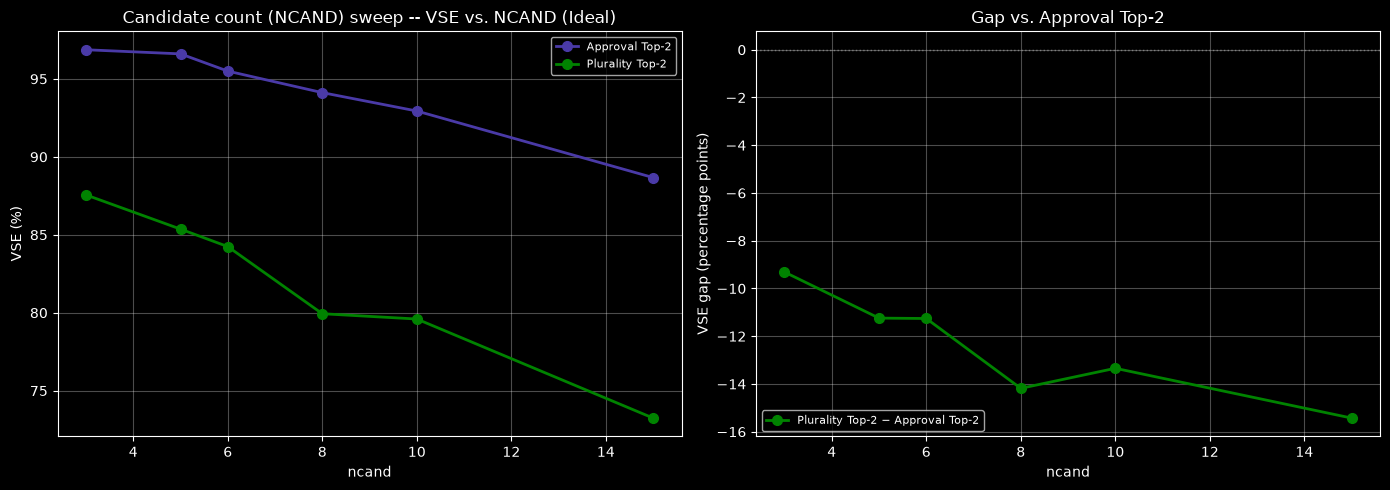

#### Mild friction: VSE by candidate count (NCAND)

| ncand | Approval Top-2 VSE (%) | Plurality Top-2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 95.1% (+/-1.3) | 90.3% (+/-1.9) | +4.8 |
| 5 | 94.1% (+/-0.8) | 90.4% (+/-1.5) | +3.7 |
| 6 | 92.3% (+/-0.9) | 89.1% (+/-1.5) | +3.2 |
| 8 | 88.3% (+/-1.1) | 84.7% (+/-1.9) | +3.6 |
| 10 | 87.9% (+/-1.1) | 84.8% (+/-1.6) | +3.1 |
| 15 | 85.0% (+/-1.2) | 81.3% (+/-1.7) | +3.7 |

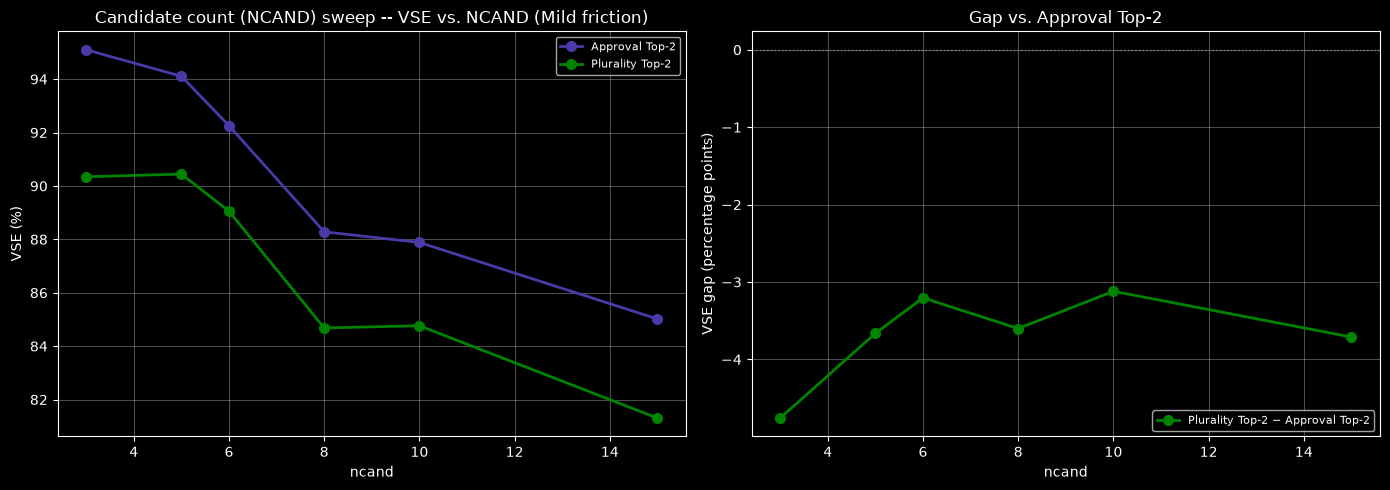

#### Moderate friction: VSE by candidate count (NCAND)

| ncand | Approval Top-2 VSE (%) | Plurality Top-2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 91.4% (+/-1.7) | 89.3% (+/-1.8) | +2.1 |
| 5 | 85.3% (+/-1.7) | 84.6% (+/-1.7) | +0.7 |
| 6 | 82.8% (+/-1.7) | 83.0% (+/-1.7) | -0.3 |
| 8 | 78.7% (+/-1.7) | 78.2% (+/-1.8) | +0.5 |
| 10 | 78.1% (+/-1.6) | 77.5% (+/-1.7) | +0.6 |
| 15 | 75.3% (+/-1.8) | 76.5% (+/-1.7) | -1.2 |

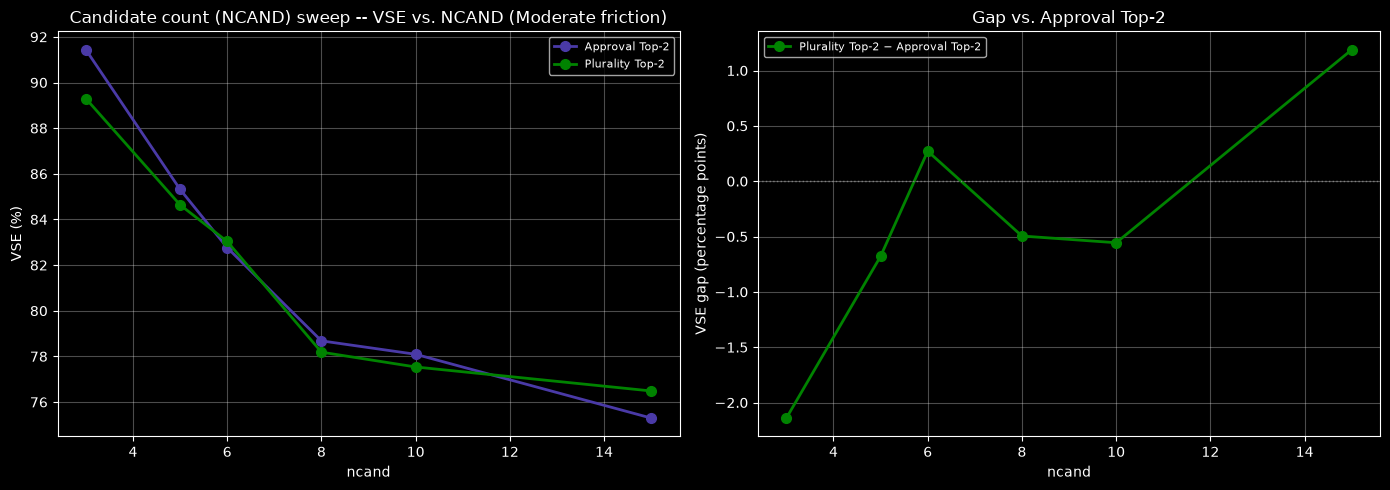

#### Heavy friction: VSE by candidate count (NCAND)

| ncand | Approval Top-2 VSE (%) | Plurality Top-2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 83.4% (+/-2.4) | 83.8% (+/-2.3) | -0.5 |
| 5 | 77.6% (+/-2.2) | 78.9% (+/-2.1) | -1.3 |
| 6 | 70.7% (+/-2.4) | 70.1% (+/-2.4) | +0.6 |
| 8 | 70.2% (+/-2.3) | 70.5% (+/-2.2) | -0.3 |
| 10 | 69.2% (+/-2.2) | 68.8% (+/-2.3) | +0.5 |
| 15 | 68.4% (+/-2.2) | 68.6% (+/-2.2) | -0.1 |

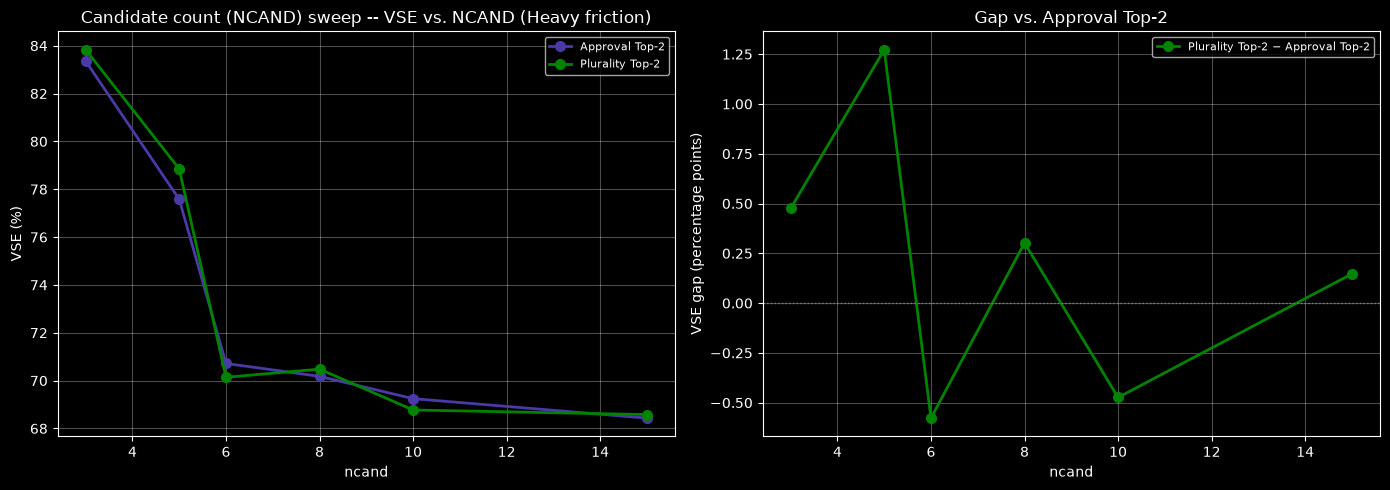

In [68]:
for scenario_name, ncand_results in R.results_by_scenario_ncand.items():
    plot_title = f"Candidate count (NCAND) sweep -- VSE vs. NCAND ({scenario_name})"
    display(Markdown(f"#### {scenario_name}: VSE by candidate count (NCAND)"))
    candidate_comparison_table(ncand_results, NCAND_SWEEP_LABELS, "ncand")
    comparison_chart(ncand_results, NCAND_SWEEP_LABELS, "ncand",
                  baseline_label="Approval Top-2", title=plot_title)

In [69]:
# Per-scenario NCAND tables: AT2 vs PT2 with a genuine paired 95% CI on the VSE gap. Both methods
# already run on the SAME per-election data (electorates_by_ncand is shared), and the gap itself
# is now accumulated per election via run_vse_simulation's paired_diff_pairs -- not approximated
# afterward from the two methods' independent CIs the way this cell used to. Gap is (AT2 - PT2),
# in percentage points, matching Section 18's convention.

for scenario_name, ncand_results in R.results_by_scenario_ncand.items():
    lines = [
        f"#### {scenario_name}",
        "",
        "| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |",
        "|---:|---:|---:|---:|---:|---:|",
    ]

    for ncand in sorted(ncand_results):
        pt2_mean, _ = ncand_results[ncand][("Plurality Top-2", "honBallot")]
        at2_mean, _ = ncand_results[ncand][("Approval Top-2", "honBallot")]

        gap_pp = (at2_mean - pt2_mean) * 100
        gap_ci_pp = R.paired_diff_by_scenario_ncand[scenario_name][ncand][("Approval Top-2", "Plurality Top-2")][1] * 100
        R.significance.register(f"AT2 vs PT2 by candidate count: {scenario_name}", f"NCAND={ncand}", gap_pp, gap_ci_pp, "Approval Top-2", "Plurality Top-2", spotlight=True)
        _, sig = _verdict_text(gap_pp, gap_ci_pp, "Approval Top-2", "Plurality Top-2")
        lo = gap_pp - gap_ci_pp
        hi = gap_pp + gap_ci_pp
        lines.append(
            f"| {ncand} | {at2_mean * 100:.2f}% | {pt2_mean * 100:.2f}% | {gap_pp:+.2f} | [{lo:+.2f}, {hi:+.2f}] | {sig} |"
        )

    display(Markdown("\n".join(lines)))

#### Ideal

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 96.87% | 87.56% | +9.31 | [+7.40, +11.23] | Decisive (Approval Top-2 better) |
| 5 | 96.61% | 85.37% | +11.24 | [+8.99, +13.50] | Decisive (Approval Top-2 better) |
| 6 | 95.50% | 84.24% | +11.26 | [+8.99, +13.52] | Decisive (Approval Top-2 better) |
| 8 | 94.12% | 79.94% | +14.18 | [+11.63, +16.73] | Decisive (Approval Top-2 better) |
| 10 | 92.94% | 79.60% | +13.34 | [+10.73, +15.96] | Decisive (Approval Top-2 better) |
| 15 | 88.67% | 73.24% | +15.43 | [+12.61, +18.25] | Decisive (Approval Top-2 better) |

#### Mild friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 95.10% | 90.34% | +4.76 | [+3.18, +6.34] | Decisive (Approval Top-2 better) |
| 5 | 94.11% | 90.45% | +3.66 | [+2.24, +5.09] | Decisive (Approval Top-2 better) |
| 6 | 92.26% | 89.05% | +3.20 | [+1.72, +4.69] | Decisive (Approval Top-2 better) |
| 8 | 88.28% | 84.68% | +3.60 | [+1.79, +5.41] | Decisive (Approval Top-2 better) |
| 10 | 87.88% | 84.77% | +3.12 | [+1.60, +4.64] | Decisive (Approval Top-2 better) |
| 15 | 85.02% | 81.31% | +3.71 | [+2.03, +5.39] | Decisive (Approval Top-2 better) |

#### Moderate friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 91.44% | 89.30% | +2.14 | [+0.76, +3.52] | Ambiguous edge (Approval Top-2 better) |
| 5 | 85.32% | 84.64% | +0.68 | [-0.85, +2.21] | Inconclusive |
| 6 | 82.76% | 83.03% | -0.27 | [-1.37, +0.82] | Inconclusive |
| 8 | 78.68% | 78.19% | +0.50 | [-0.64, +1.63] | Inconclusive |
| 10 | 78.09% | 77.54% | +0.56 | [-0.59, +1.70] | Inconclusive |
| 15 | 75.30% | 76.49% | -1.19 | [-2.13, -0.25] | Ambiguous edge (Plurality Top-2 better) |

#### Heavy friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 83.36% | 83.83% | -0.48 | [-1.76, +0.81] | Inconclusive |
| 5 | 77.58% | 78.85% | -1.27 | [-2.64, +0.09] | Inconclusive |
| 6 | 70.72% | 70.14% | +0.58 | [-0.66, +1.81] | Inconclusive |
| 8 | 70.18% | 70.48% | -0.30 | [-1.34, +0.74] | Inconclusive |
| 10 | 69.25% | 68.77% | +0.47 | [-0.67, +1.62] | Inconclusive |
| 15 | 68.43% | 68.58% | -0.15 | [-0.99, +0.70] | Indistinguishable |

## 26. Per-election VSE spread: what's behind the average

Every VSE number reported above is a mean over hundreds of individual elections, each
contributing exactly one value of `(u(winner) - mean(u(c))) / (max(u(c)) - mean(u(c)))`. A bar
chart with a 95% CI whisker summarizes that distribution but doesn't show its shape. This section
histograms the per-election values directly -- honest ballots only, for the six methods that
matter most to the Approval-vs-STAR-vs-Schulze comparisons above (STAR, Approval, Approval Top-2,
Plurality, Plurality Top-2, Condorcet (Schulze)) -- across the same four joint-friction scenarios
as Section 16, with a dashed line at the mean already reported there.

No new simulation: `ideal_raw_vse` (Section 9) and `joint_raw_vse_by_scenario` (Section 16, via
`run_vse_simulation`'s `raw_vse_sink`) capture every election's `vse` value as it's computed,
instead of only the running sums `reduce_to_mean_ci` needs -- so the dashed mean line below is
computed from, and therefore matches exactly, the number already shown in Section 16's table and
bar chart for that method and scenario.

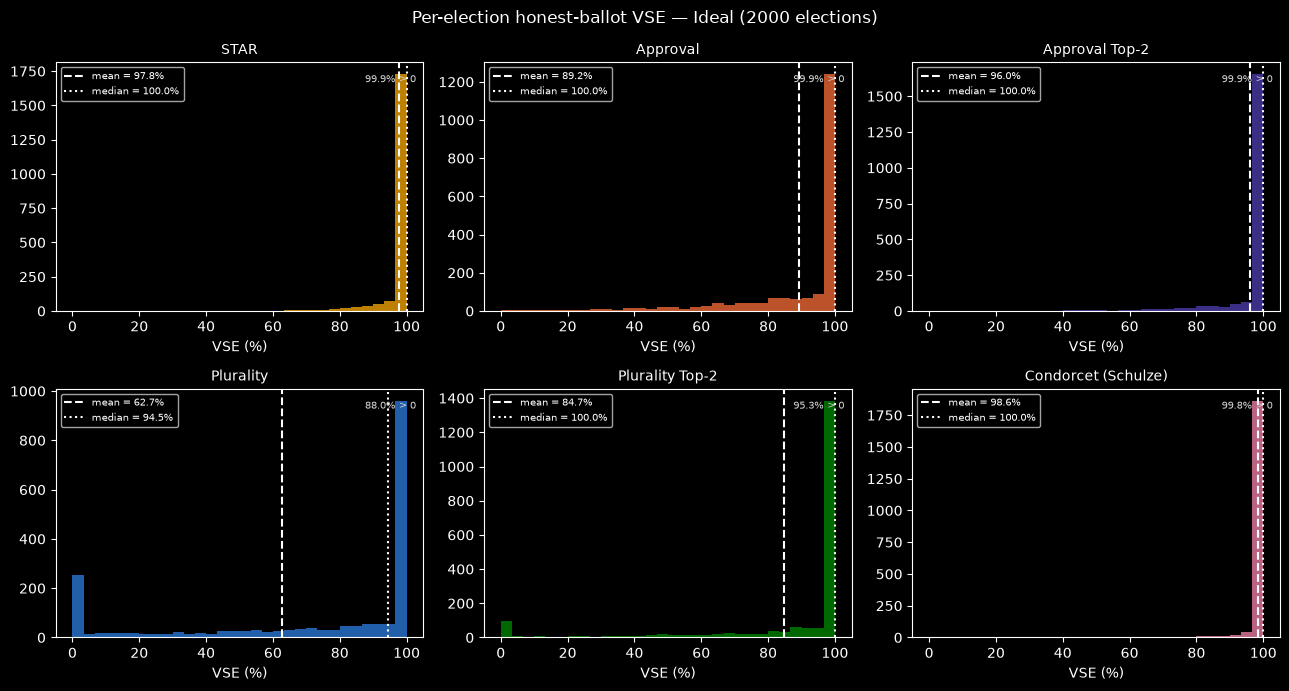

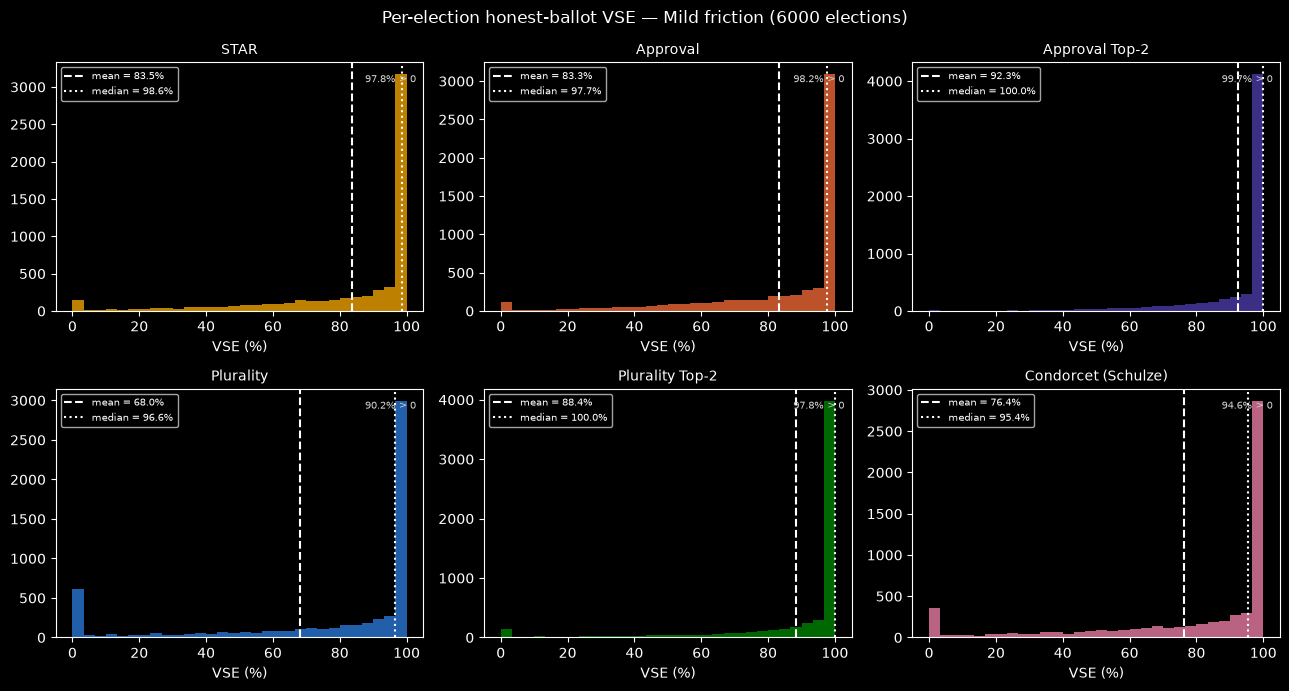

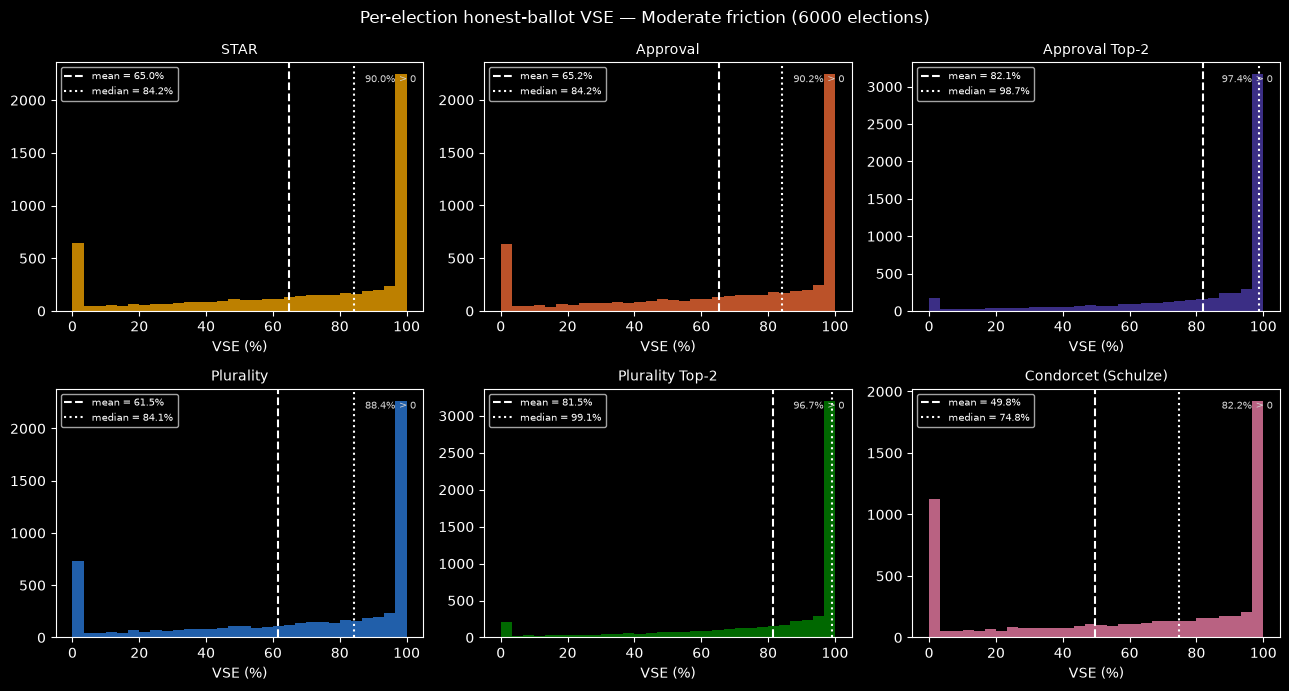

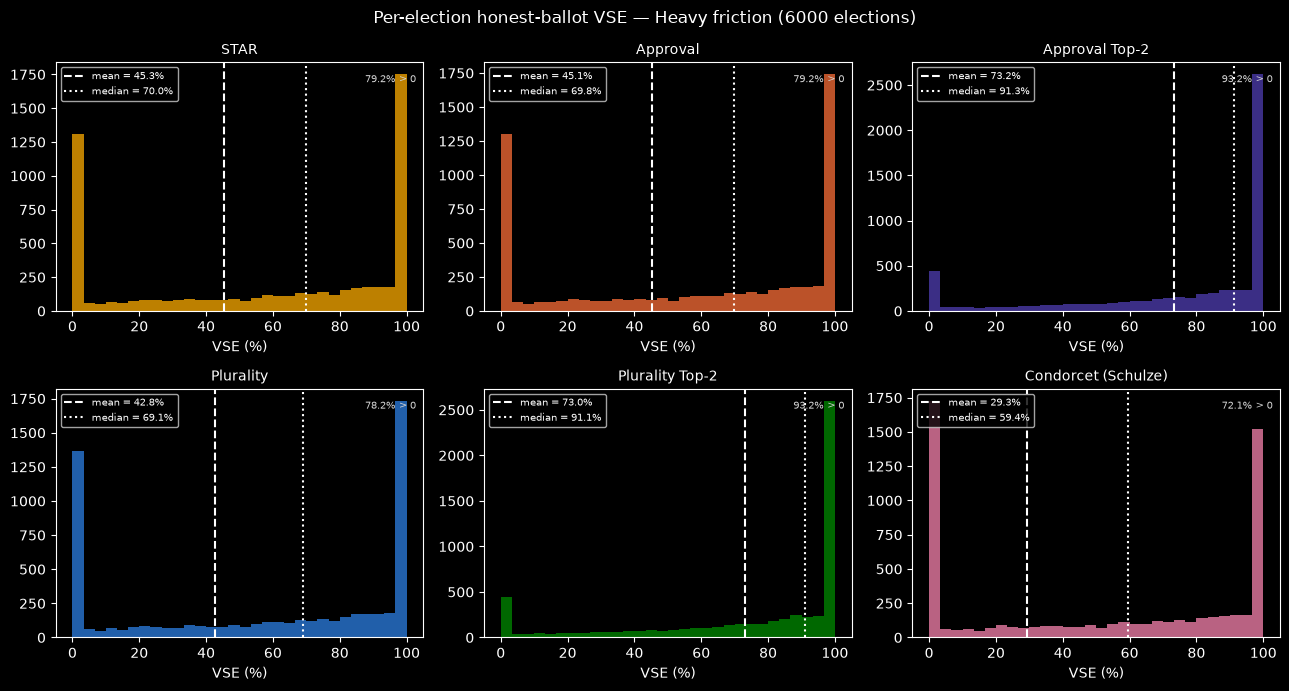

In [70]:
HIST_LABELS = ["STAR", "Approval", "Approval Top-2", "Plurality", "Plurality Top-2", "Condorcet (Schulze)"]
_scenario_names = list(JOINT_SCENARIOS)  # Ideal, Mild friction, Moderate friction, Heavy friction

CLAMP_NEGATIVE_VALUES = True  # True: collapse every VSE < 0 into the single leftmost bucket (at
                               # 0%) instead of stretching the x-axis to fit an absurdly long,
                               # sparse negative tail that hides the shape of the real (mostly
                               # positive) distribution. Flip to False to see the true unclamped
                               # tail, with an x=0 reference line instead.

# Shared x-range per method (pooled across all 4 scenarios) so the four separate figures below
# are visually comparable panel-to-panel for a given method -- the whole point is spotting
# whether Ideal is tighter than Heavy friction, which a per-figure autoscaled axis would hide.
_hist_range = {}
for _label in HIST_LABELS:
    _all_vals = [v for _name in _scenario_names for v in R.joint_raw_vse_by_scenario[_name][(_label, "honBallot")]]
    _lo = 0.0 if CLAMP_NEGATIVE_VALUES else min(_all_vals)
    _hist_range[_label] = (_lo, max(_all_vals))

for _name in _scenario_names:
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    for ax, _label in zip(axes.flat, HIST_LABELS):
        raw_vals = R.joint_raw_vse_by_scenario[_name][(_label, "honBallot")]
        frac_positive = np.mean([v > 0 for v in raw_vals]) * 100
        vals = [(max(v, 0.0) if CLAMP_NEGATIVE_VALUES else v) * 100 for v in raw_vals]
        mean_, _ci = R.joint_results[_name][(_label, "honBallot")]
        median_ = np.median(raw_vals)
        lo, hi = _hist_range[_label]
        ax.hist(vals, bins=30, range=(lo * 100, hi * 100), color=METHOD_COLORS[_label], alpha=0.8)
        ax.axvline(mean_ * 100, color=FG_COLOR, ls="--", lw=1.5, label=f"mean = {mean_ * 100:.1f}%")
        ax.axvline(median_ * 100, color=FG_COLOR, ls=":", lw=1.5, label=f"median = {median_ * 100:.1f}%")
        if not CLAMP_NEGATIVE_VALUES:
            ax.axvline(0, color="red", ls="-", lw=1, alpha=0.6, label="0%")
        ax.set_title(_label, fontsize=10)
        ax.set_xlabel("VSE (%)")
        ax.legend(fontsize=7, loc="upper left")
        ax.text(0.98, 0.95, f"{frac_positive:.1f}% > 0", transform=ax.transAxes, fontsize=7,
                 ha="right", va="top", color=MUTED_COLOR)
    fig.suptitle(f"Per-election honest-ballot VSE \u2014 {_name} ({JOINT_NITER if _name != 'Ideal' else NITER} elections)")
    plt.tight_layout()
    plt.show()

In [71]:
## Check if the mode of all of these histograms is at 100%
# Check histogram modes allowing either scale:
# - raw fraction scale (mode ~= 1.0)
# - percent scale (mode ~= 100.0)
_mode_check_lines = [
    "| Scenario | Method | Inferred scale | Mode (raw) | Mode (%) | Count at mode | N | Mode is 1.0/100%? |",
    "|---|---|---|---:|---:|---:|---:|---|",
]

_mode_failures = []

for _name in _scenario_names:
    for _label in HIST_LABELS:
        _vals = np.asarray(R.joint_raw_vse_by_scenario[_name][(_label, "honBallot")], dtype=float)
        _vals = _vals[np.isfinite(_vals)]
        if _vals.size == 0:
            _mode_failures.append((_name, _label, "empty"))
            _mode_check_lines.append(f"| {_name} | {_label} | n/a | n/a | n/a | 0 | 0 | No |")
            continue

        # Empirical mode on raw values.
        _raw_rounded = np.round(_vals, 6)
        _raw_uniq, _raw_counts = np.unique(_raw_rounded, return_counts=True)
        _mode_raw = float(_raw_uniq[np.argmax(_raw_counts)])
        _mode_count = int(_raw_counts.max())

        # Convert to percent for display/comparison.
        _mode_pct = _mode_raw * 100.0

        # Infer likely storage scale for readability only.
        _scale = "percent-like" if np.nanmax(np.abs(_vals)) > 2 else "fraction-like"

        # Accept either canonical representation.
        _ok = np.isclose(_mode_raw, 1.0, atol=1e-6) or np.isclose(_mode_pct, 100.0, atol=1e-4)
        if not _ok:
            _mode_failures.append((_name, _label, _mode_raw, _mode_pct, _mode_count, len(_vals)))

        _mode_check_lines.append(
            f"| {_name} | {_label} | {_scale} | {_mode_raw:.6g} | {_mode_pct:.6g} | {_mode_count} | {len(_vals)} | {'Yes' if _ok else 'No'} |"
        )

display(Markdown("\n".join(_mode_check_lines)))

if _mode_failures:
    raise AssertionError(
        "Mode is neither 1.0 nor 100% for: "
        + ", ".join(
            f"{s}/{m} (raw={r:.6g}, pct={p:.6g})"
            for s, m, r, p, *_ in _mode_failures
            if len(_) >= 0
        )
    )
    
## Check if any systems have negative values occur more often than 1.0 or 100%. This is actually possible
for _name in _scenario_names:
    for _label in HIST_LABELS:
        _vals = np.asarray(R.joint_raw_vse_by_scenario[_name][(_label, "honBallot")], dtype=float)
        _vals = _vals[np.isfinite(_vals)]
        if _vals.size == 0:
            continue

        _neg_count = np.sum(_vals < 0)
        _neg_frac = _neg_count / len(_vals)
        hundred_pct_count = np.sum(np.isclose(_vals, 1.0, atol=1e-6) | np.isclose(_vals, 100.0, atol=1e-4))
        if _neg_frac > hundred_pct_count / len(_vals):
            print(f"{_name}/{_label} has more negative values ({_neg_count}/{len(_vals)} = {_neg_frac:.4f}) than count of 1.0/100% values ({hundred_pct_count}/{len(_vals)} = {hundred_pct_count/len(_vals):.4f})")

| Scenario | Method | Inferred scale | Mode (raw) | Mode (%) | Count at mode | N | Mode is 1.0/100%? |
|---|---|---|---:|---:|---:|---:|---|
| Ideal | STAR | fraction-like | 1 | 100 | 1569 | 2000 | Yes |
| Ideal | Approval | fraction-like | 1 | 100 | 1128 | 2000 | Yes |
| Ideal | Approval Top-2 | fraction-like | 1 | 100 | 1539 | 2000 | Yes |
| Ideal | Plurality | percent-like | 1 | 100 | 873 | 2000 | Yes |
| Ideal | Plurality Top-2 | percent-like | 1 | 100 | 1262 | 2000 | Yes |
| Ideal | Condorcet (Schulze) | fraction-like | 1 | 100 | 1775 | 2000 | Yes |
| Mild friction | STAR | percent-like | 1 | 100 | 2826 | 6000 | Yes |
| Mild friction | Approval | percent-like | 1 | 100 | 2737 | 6000 | Yes |
| Mild friction | Approval Top-2 | fraction-like | 1 | 100 | 3734 | 6000 | Yes |
| Mild friction | Plurality | percent-like | 1 | 100 | 2683 | 6000 | Yes |
| Mild friction | Plurality Top-2 | percent-like | 1 | 100 | 3618 | 6000 | Yes |
| Mild friction | Condorcet (Schulze) | percent-like | 1 | 100 | 2535 | 6000 | Yes |
| Moderate friction | STAR | percent-like | 1 | 100 | 1946 | 6000 | Yes |
| Moderate friction | Approval | percent-like | 1 | 100 | 1945 | 6000 | Yes |
| Moderate friction | Approval Top-2 | percent-like | 1 | 100 | 2828 | 6000 | Yes |
| Moderate friction | Plurality | percent-like | 1 | 100 | 1977 | 6000 | Yes |
| Moderate friction | Plurality Top-2 | percent-like | 1 | 100 | 2864 | 6000 | Yes |
| Moderate friction | Condorcet (Schulze) | percent-like | 1 | 100 | 1663 | 6000 | Yes |
| Heavy friction | STAR | percent-like | 1 | 100 | 1501 | 6000 | Yes |
| Heavy friction | Approval | percent-like | 1 | 100 | 1494 | 6000 | Yes |
| Heavy friction | Approval Top-2 | percent-like | 1 | 100 | 2271 | 6000 | Yes |
| Heavy friction | Plurality | percent-like | 1 | 100 | 1492 | 6000 | Yes |
| Heavy friction | Plurality Top-2 | percent-like | 1 | 100 | 2250 | 6000 | Yes |
| Heavy friction | Condorcet (Schulze) | percent-like | 1 | 100 | 1302 | 6000 | Yes |

Heavy friction/Condorcet (Schulze) has more negative values (1673/6000 = 0.2788) than count of 1.0/100% values (1302/6000 = 0.2170)


## 27. Results Under a 99% Confidence Bar

Every paired-gap "Significant?" verdict earlier in this notebook uses a 95% CI (`Z_95 =
1.96`). This section re-checks those same gaps against a stricter 99% CI (`Z_99 ~= 2.576`).
A CI's half-width scales linearly with z for a fixed standard error, so this is arithmetic on
the stored 95% half-widths (`SIGNIFICANCE_LOG`, populated as each table above renders), not a
re-run of anything.

**Run this after a full Restart & Run All, not standalone.** Same caveat as the Claims
Dashboard below: this section only reads globals computed earlier in the notebook.

Two tables. First, every row that was significant at 95% but loses that status at 99%. A 99%
CI is strictly wider than a 95% one, so a result can only move from significant to
not-significant here, never the reverse; this table is expected to stay short. Second, a
spotlight on specific headline claims marked at their own call site with `spotlight=True`:
Groggy AT2/PT2 vs STAR, the kappa threshold, Condorcet efficiency vs Schulze, and Approval vs
Plurality across every flavor (single-round, Groggy/Clear-Eyed Top-2, and the candidate-count
sweep).

In [72]:
_PART2_TABLE_KEYWORDS = ("Schulze", "Condorcet", "CE gap")

_not_sig_bullets = []
for _table_title, _rows in R.significance.items():
    if any(_kw in _table_title for _kw in _PART2_TABLE_KEYWORDS):
        continue
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _spotlight in _rows:
        _ci99 = _ci95 * (Z_99 / Z_95)
        _bucket_95, _ = _verdict_text(_gap, _ci95, _pos_name, _neg_name)
        _bucket_99, _ = _verdict_text(_gap, _ci99, _pos_name, _neg_name)
        _sig_95 = _bucket_95 not in ("INDISTINGUISHABLE", "INCONCLUSIVE")
        _sig_99 = _bucket_99 not in ("INDISTINGUISHABLE", "INCONCLUSIVE")
        if _sig_95 and not _sig_99:
            _better, _worse = (_pos_name, _neg_name) if _gap > 0 else (_neg_name, _pos_name)
            _not_sig_bullets.append(
                f"- **{_table_title} / {_row_label}**: at 95% confidence, **{_better}** appeared "
                f"better than **{_worse}** by {abs(_gap):.1f}pp ({TAXONOMY_LABELS[_bucket_95]}, 95% CI "
                f"[{_gap-_ci95:+.1f}, {_gap+_ci95:+.1f}]). At 99% confidence that edge is no "
                f"longer significant ({TAXONOMY_LABELS[_bucket_99]}, 99% CI "
                f"[{_gap-_ci99:+.1f}, {_gap+_ci99:+.1f}], which contains 0)."
            )
display(Markdown(f"### {len(_not_sig_bullets)} result(s) lose significance at 99% confidence\n"))
if _not_sig_bullets:
    display(Markdown("\n".join(_not_sig_bullets)))
else:
    display(Markdown("None. Every 95%-significant result in this post's scope also holds at 99%."))

### 5 result(s) lose significance at 99% confidence


- **Approval Top-2 (Clear-Eyed) vs Plurality Top-2 (Clear-Eyed) / Heavy friction**: at 95% confidence, **AT2** appeared better than **PT2** by 0.6pp (Ambiguous edge, 95% CI [+0.1, +1.1]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-0.0, +1.3], which contains 0).
- **kappa threshold: Moderate friction / kappa=0.23**: at 95% confidence, **STAR** appeared better than **Approval Top-2** by 1.2pp (Ambiguous edge, 95% CI [-2.2, -0.1]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-2.5, +0.2], which contains 0).
- **kappa threshold: Moderate friction / kappa=0.30**: at 95% confidence, **Approval Top-2** appeared better than **STAR** by 1.3pp (Ambiguous edge, 95% CI [+0.3, +2.4]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-0.0, +2.7], which contains 0).
- **kappa threshold: Heavy friction / kappa=0.23**: at 95% confidence, **STAR** appeared better than **Approval Top-2** by 1.4pp (Ambiguous edge, 95% CI [-2.8, -0.1]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-3.2, +0.4], which contains 0).
- **AT2 vs PT2 by candidate count: Moderate friction / NCAND=15**: at 95% confidence, **Plurality Top-2** appeared better than **Approval Top-2** by 1.2pp (Ambiguous edge, 95% CI [-2.1, -0.2]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-2.4, +0.0], which contains 0).

In [73]:
_PART2_TABLE_KEYWORDS = ("Schulze", "Condorcet", "CE gap")

display(Markdown("### Spotlight: does each headline claim hold up at 99% confidence?\n"))
for _table_title, _rows in R.significance.items():
    if any(_kw in _table_title for _kw in _PART2_TABLE_KEYWORDS):
        continue
    _spotlight_rows = [r for r in _rows if r[5]]
    if not _spotlight_rows:
        continue
    _lines = [
        f"#### {_table_title}",
        "",
        "| Row | Gap (pp) | 95% verdict | 99% verdict |",
        "|---|---|---|---|",
    ]
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _ in _spotlight_rows:
        _ci99 = _ci95 * (Z_99 / Z_95)
        _bucket_95, _verdict_95 = _verdict_text(_gap, _ci95, _pos_name, _neg_name)
        _bucket_99, _verdict_99 = _verdict_text(_gap, _ci99, _pos_name, _neg_name)
        if _bucket_95 != _bucket_99:
            _verdict_99 = f"**{_verdict_99}**"
        _lines.append(f"| {_row_label} | {_gap:+.1f} | {_verdict_95} | {_verdict_99} |")
    display(Markdown("\n".join(_lines)))

### Spotlight: does each headline claim hold up at 99% confidence?


#### Approval-flavor gaps vs STAR: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 | -13.0 | Decisive (STAR better) | Decisive (STAR better) |
| Approval Top-2 | -1.8 | Decisive (STAR better) | Decisive (STAR better) |

#### Approval-flavor gaps vs STAR: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 | +4.8 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +8.8 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

#### Approval-flavor gaps vs STAR: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 | +16.6 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +17.1 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

#### Approval-flavor gaps vs STAR: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 | +27.7 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +27.9 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

...

#### Score Top-2 (Clear-Eyed) vs Approval Top-2 (Clear-Eyed)

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Ideal | +2.3 | Decisive (Score Top-2 better) | Decisive (Score Top-2 better) |
| Mild friction | -0.1 | Indistinguishable | Indistinguishable |
| Moderate friction | -0.2 | Indistinguishable | Indistinguishable |
| Heavy friction | +0.1 | Indistinguishable | Indistinguishable |

#### AT2 vs PT2 by candidate count: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +9.3 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=5 | +11.2 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=6 | +11.3 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=8 | +14.2 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=10 | +13.3 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=15 | +15.4 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

#### AT2 vs PT2 by candidate count: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +4.8 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=5 | +3.7 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=6 | +3.2 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=8 | +3.6 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=10 | +3.1 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=15 | +3.7 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

#### AT2 vs PT2 by candidate count: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +2.1 | Ambiguous edge (Approval Top-2 better) | Ambiguous edge (Approval Top-2 better) |
| NCAND=5 | +0.7 | Inconclusive | Inconclusive |
| NCAND=6 | -0.3 | Inconclusive | Inconclusive |
| NCAND=8 | +0.5 | Inconclusive | Inconclusive |
| NCAND=10 | +0.6 | Inconclusive | Inconclusive |
| NCAND=15 | -1.2 | Ambiguous edge (Plurality Top-2 better) | **Inconclusive** |

#### AT2 vs PT2 by candidate count: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | -0.5 | Inconclusive | Inconclusive |
| NCAND=5 | -1.3 | Inconclusive | Inconclusive |
| NCAND=6 | +0.6 | Inconclusive | Inconclusive |
| NCAND=8 | -0.3 | Inconclusive | Inconclusive |
| NCAND=10 | +0.5 | Inconclusive | Inconclusive |
| NCAND=15 | -0.1 | Indistinguishable | **Inconclusive** |

In [74]:
_PART2_TABLE_KEYWORDS = ("Schulze", "Condorcet", "CE gap")

_not_sig_bullets = []
for _table_title, _rows in R.significance.items():
    if not any(_kw in _table_title for _kw in _PART2_TABLE_KEYWORDS):
        continue
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _spotlight in _rows:
        _ci99 = _ci95 * (Z_99 / Z_95)
        _bucket_95, _ = _verdict_text(_gap, _ci95, _pos_name, _neg_name)
        _bucket_99, _ = _verdict_text(_gap, _ci99, _pos_name, _neg_name)
        _sig_95 = _bucket_95 not in ("INDISTINGUISHABLE", "INCONCLUSIVE")
        _sig_99 = _bucket_99 not in ("INDISTINGUISHABLE", "INCONCLUSIVE")
        if _sig_95 and not _sig_99:
            _better, _worse = (_pos_name, _neg_name) if _gap > 0 else (_neg_name, _pos_name)
            _not_sig_bullets.append(
                f"- **{_table_title} -- {_row_label}**: at 95% confidence, **{_better}** appeared "
                f"better than **{_worse}** by {abs(_gap):.1f}pp ({TAXONOMY_LABELS[_bucket_95]}, 95% CI "
                f"[{_gap-_ci95:+.1f}, {_gap+_ci95:+.1f}]) -- but at 99% confidence that edge is no "
                f"longer significant ({TAXONOMY_LABELS[_bucket_99]}, 99% CI "
                f"[{_gap-_ci99:+.1f}, {_gap+_ci99:+.1f}], which contains 0)."
            )
display(Markdown(f"### {len(_not_sig_bullets)} result(s) lose significance at 99% confidence\n"))
if _not_sig_bullets:
    display(Markdown("\n".join(_not_sig_bullets)))
else:
    display(Markdown("None -- every 95%-significant result in this post's scope also holds at 99%."))

### 2 result(s) lose significance at 99% confidence


- **CE gap vs Schulze: Moderate friction -- RCV (IRV)**: at 95% confidence, **RCV (IRV)** appeared better than **Condorcet (Schulze)** by 0.3pp (Narrow edge, 95% CI [+0.1, +0.5]) -- but at 99% confidence that edge is no longer significant (Indistinguishable, 99% CI [-0.0, +0.6], which contains 0).
- **CE gap vs Schulze: Heavy friction -- Approval Top-2 (Coma)**: at 95% confidence, **Condorcet (Schulze)** appeared better than **Approval Top-2 (Coma)** by 0.4pp (Narrow edge, 95% CI [-0.7, -0.0]) -- but at 99% confidence that edge is no longer significant (Indistinguishable, 99% CI [-0.8, +0.1], which contains 0).

In [75]:
_PART2_TABLE_KEYWORDS = ("Schulze", "Condorcet", "CE gap")

display(Markdown("### Spotlight: does each headline claim hold up at 99% confidence?\n"))
for _table_title, _rows in R.significance.items():
    if not any(_kw in _table_title for _kw in _PART2_TABLE_KEYWORDS):
        continue
    _spotlight_rows = [r for r in _rows if r[5]]
    if not _spotlight_rows:
        continue
    _lines = [
        f"#### {_table_title}",
        "",
        "| Row | Gap (pp) | 95% verdict | 99% verdict |",
        "|---|---|---|---|",
    ]
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _ in _spotlight_rows:
        _ci99 = _ci95 * (Z_99 / Z_95)
        _bucket_95, _verdict_95 = _verdict_text(_gap, _ci95, _pos_name, _neg_name)
        _bucket_99, _verdict_99 = _verdict_text(_gap, _ci99, _pos_name, _neg_name)
        if _bucket_95 != _bucket_99:
            _verdict_99 = f"**{_verdict_99}**"
        _lines.append(f"| {_row_label} | {_gap:+.1f} | {_verdict_95} | {_verdict_99} |")
    display(Markdown("\n".join(_lines)))

### Spotlight: does each headline claim hold up at 99% confidence?


#### CE gap vs Schulze: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top-2 | -16.7 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| STAR | -19.3 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| Score5 | -28.6 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| Plurality Top-2 | -34.0 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| RCV (IRV) | -37.0 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| Approval | -42.1 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| Plurality | -56.8 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |

#### CE gap vs Schulze: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | +29.5 | Decisive (Approval Top-2 (Clear-Eyed) better) | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +28.6 | Decisive (Score Top-2 (Clear-Eyed) better) | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 (Clear-Eyed) | +26.3 | Decisive (Plurality Top-2 (Clear-Eyed) better) | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | +19.7 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| Plurality Top-2 | +18.1 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| STAR | +4.7 | Decisive (STAR better) | Decisive (STAR better) |
| Approval | +3.1 | Decisive (Approval better) | Decisive (Approval better) |
| Plurality | +2.8 | Decisive (Plurality better) | Decisive (Plurality better) |
| Approval Top-2 (Coma) | +2.4 | Decisive (Approval Top-2 (Coma) better) | Decisive (Approval Top-2 (Coma) better) |
| Score5 | +2.4 | Decisive (Score5 better) | Decisive (Score5 better) |
| RCV (IRV) | -0.2 | Indistinguishable | Indistinguishable |

#### CE gap vs Schulze: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | +26.7 | Decisive (Plurality Top-2 (Clear-Eyed) better) | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | +26.6 | Decisive (Approval Top-2 (Clear-Eyed) better) | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +26.2 | Decisive (Score Top-2 (Clear-Eyed) better) | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 | +20.3 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +19.4 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| Plurality | +5.3 | Decisive (Plurality better) | Decisive (Plurality better) |
| STAR | +4.9 | Decisive (STAR better) | Decisive (STAR better) |
| Approval | +4.9 | Decisive (Approval better) | Decisive (Approval better) |
| Score5 | +4.2 | Decisive (Score5 better) | Decisive (Score5 better) |
| Approval Top-2 (Coma) | +1.2 | Ambiguous edge (Approval Top-2 (Coma) better) | Ambiguous edge (Approval Top-2 (Coma) better) |
| RCV (IRV) | +0.3 | Narrow edge (RCV (IRV) better) | **Indistinguishable** |

#### CE gap vs Schulze: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | +23.2 | Decisive (Approval Top-2 (Clear-Eyed) better) | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +22.9 | Decisive (Score Top-2 (Clear-Eyed) better) | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 (Clear-Eyed) | +22.5 | Decisive (Plurality Top-2 (Clear-Eyed) better) | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | +16.8 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| Plurality Top-2 | +16.5 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| STAR | +3.3 | Decisive (STAR better) | Decisive (STAR better) |
| Score5 | +3.2 | Decisive (Score5 better) | Decisive (Score5 better) |
| Approval | +3.2 | Decisive (Approval better) | Decisive (Approval better) |
| Plurality | +3.1 | Decisive (Plurality better) | Decisive (Plurality better) |
| RCV (IRV) | -0.0 | Indistinguishable | Indistinguishable |
| Approval Top-2 (Coma) | -0.4 | Narrow edge (Condorcet (Schulze) better) | **Indistinguishable** |

# Claims Dashboard

## Part 1

Every `jupyter_cell_embed` the companion blog post
(`_previews/2026-07-24-runoff-accuracy.md`) embeds from this notebook, re-displayed here in one
place, in the same order the post reads them. After changing a parameter (`NITER`, a friction
value, ...) and re-running, scroll through this one section to see at a glance whether any of
the numbers/tables/charts the post relies on have moved -- instead of hunting back through each
individual section.

**Run this after a full Restart & Run All, not standalone.** Every cell below only reads globals
already computed earlier in the notebook (`joint_results`, `paired_diff_by_scenario`,
`betrayal_by_scenario`, `results_by_scenario_ncand`, ...) -- it runs no new simulation of its own.

Each group's code cell below calls `replay("tag-name")` (defined just below), which re-reads this
notebook's own saved `.ipynb` file, finds the cell tagged `"tag-name"`, and `exec`s its current
source in place -- so it's always the SAME code as the original tagged cell, not a copy that can
drift out of sync. Edit the original cell anywhere else in the notebook, save, re-run this
section, and the dashboard picks up the change automatically.

In [76]:
# Re-reads this notebook's own saved file, finds the cell(s) tagged `tag`, and execs their
# current source into this kernel's namespace -- see "Part 1" above for why.
import json as _json

_NB_SELF_PATH = "vse_simulation_modular.ipynb"

def replay(tag):
    with open(_NB_SELF_PATH, encoding="utf-8") as f:
        _nb = _json.load(f)
    _matches = [c for c in _nb["cells"] if tag in c.get("metadata", {}).get("tags", [])]
    assert len(_matches) == 1, f"expected exactly 1 cell tagged {tag!r}, found {len(_matches)}"
    _src = "".join(_matches[0]["source"])
    exec(compile(_src, f"<tag:{tag}>", "exec"), globals())

### Introduction

In [77]:
replay("evc-vse")

| Method | Computed | Honest VSE |
|---|---|---|
| Plurality | 57.97% - 81.35% | 62.66% |
| Plurality Top-2 | 84.11% - 87.56% | 84.75% |
| RCV (IRV) | 77.67% - 88.15% | 88.15% |
| Approval | 83.15% - 95.09% | 89.21% |
| Approval Top-2 | 91.63% - 97.64% | 95.95% |
| STAR | 89.24% - 97.78% | 97.78% |
| Condorcet (Schulze) | 84.01% - 98.57% | 98.57% |

### Other Relevant Methodology

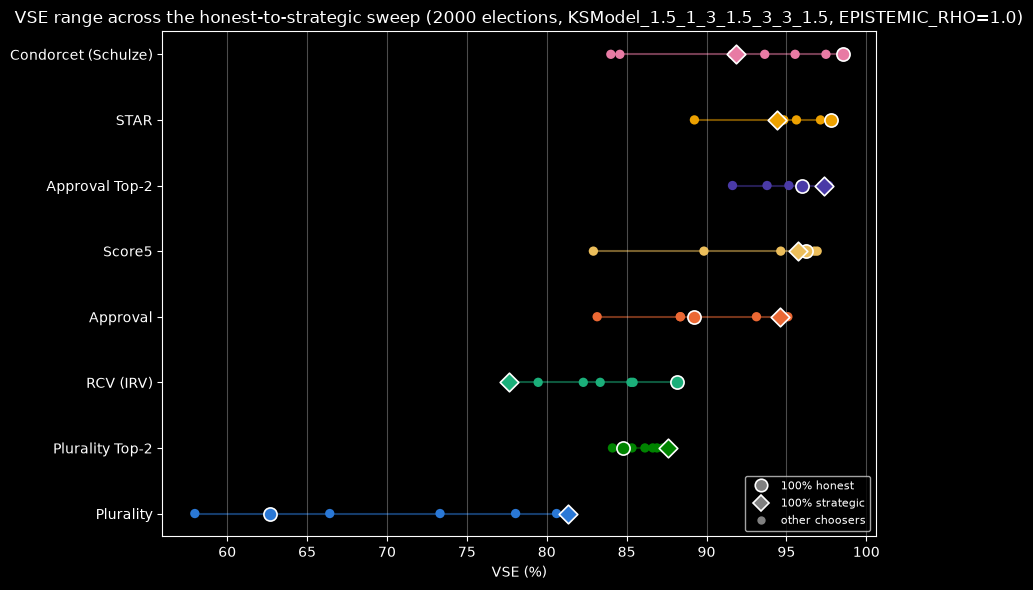

| Method | Computed | Documented |
|---|---|---|
| Condorcet (Schulze) | 84.01% - 98.57% | 86-98% |
| Approval Top-2 | 91.63% - 97.64% | (no documented range on file) |
| STAR | 89.24% - 97.78% | 91-98% |
| Score5 | 82.92% - 96.92% | 84-96% |
| Plurality Top-2 | 84.11% - 87.56% | (no documented range on file) |
| RCV (IRV) | 77.67% - 88.15% | up to 87% |
| Approval | 83.15% - 95.09% | 89-95% |
| Plurality | 57.97% - 81.35% | ~75% |

**Condorcet (Schulze)**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% honest | 98.57% | +/-0.39 |
| 25% strategic | 97.47% | +/-0.46 |
| 50% strategic | 95.55% | +/-0.62 |
| 75% strategic | 93.65% | +/-0.73 |
| 100% strategic | 91.81% | +/-0.86 |
| 50% one-sided strategic | 91.61% | +/-0.85 |
| smart one-sided strategic | 84.58% | +/-1.15 |
| 100% one-sided strategic | 84.01% | +/-1.14 |
| **range** | 84.01% - 98.57% | |

**Approval Top-2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 50% strategic | 97.64% | +/-0.42 |
| 75% strategic | 97.63% | +/-0.43 |
| 100% strategic | 97.33% | +/-0.48 |
| 25% strategic | 97.19% | +/-0.43 |
| 100% honest | 95.95% | +/-0.54 |
| 50% one-sided strategic | 95.15% | +/-0.63 |
| smart one-sided strategic | 93.79% | +/-0.72 |
| 100% one-sided strategic | 91.63% | +/-0.85 |
| **range** | 91.63% - 97.64% | |

...

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 90.0% | 81.0% | 72.9% | 65.6% | 59.0% |
| 1 | 90.0% | 81.0% | 72.9% | 65.6% | 59.0% | 53.1% |
| 2 | 81.0% | 72.9% | 65.6% | 59.0% | 53.1% | 47.8% |
| 3 | 72.9% | 65.6% | 59.0% | 53.1% | 47.8% | 43.0% |
| 4 | 65.6% | 59.0% | 53.1% | 47.8% | 43.0% | 38.7% |
| 5 | 59.0% | 53.1% | 47.8% | 43.0% | 38.7% | 34.9% |

### Probability table for moderate friction (alpha=0.8, beta=0.8)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 80.0% | 64.0% | 51.2% | 41.0% | 32.8% |
| 1 | 80.0% | 64.0% | 51.2% | 41.0% | 32.8% | 26.2% |
| 2 | 64.0% | 51.2% | 41.0% | 32.8% | 26.2% | 21.0% |
| 3 | 51.2% | 41.0% | 32.8% | 26.2% | 21.0% | 16.8% |
| 4 | 41.0% | 32.8% | 26.2% | 21.0% | 16.8% | 13.4% |
| 5 | 32.8% | 26.2% | 21.0% | 16.8% | 13.4% | 10.7% |

### Probability table for heavy friction (alpha=0.7, beta=0.7)

| Prominence rank \ Fatigue position | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| 0 | 100.0% | 70.0% | 49.0% | 34.3% | 24.0% | 16.8% |
| 1 | 70.0% | 49.0% | 34.3% | 24.0% | 16.8% | 11.8% |
| 2 | 49.0% | 34.3% | 24.0% | 16.8% | 11.8% | 8.2% |
| 3 | 34.3% | 24.0% | 16.8% | 11.8% | 8.2% | 5.8% |
| 4 | 24.0% | 16.8% | 11.8% | 8.2% | 5.8% | 4.0% |
| 5 | 16.8% | 11.8% | 8.2% | 5.8% | 4.0% | 2.8% |

In [78]:
replay("strategy-sweep-chart")
replay("vse-range-baseline")
replay("vse-tables")
replay("friction-table")

### Findings: The Approval-STAR Gap

#### Ideal: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Plurality | 62.7 | 97.8 | -35.1 | [-37.9, -32.3] | Decisive (STAR better) |
| Plurality Top-2 | 84.7 | 97.8 | -13.0 | [-14.7, -11.4] | Decisive (STAR better) |
| Approval | 89.2 | 97.8 | -8.6 | [-9.4, -7.7] | Decisive (STAR better) |
| Approval Top-2 | 96.0 | 97.8 | -1.8 | [-2.4, -1.3] | Decisive (STAR better) |

#### Mild friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Plurality | 68.0 | 83.5 | -15.5 | [-17.1, -13.9] | Decisive (STAR better) |
| Approval Top-2 (Coma) | 81.8 | 83.5 | -1.7 | [-2.2, -1.2] | Decisive (STAR better) |
| Approval | 83.3 | 83.5 | -0.3 | [-0.8, +0.3] | Indistinguishable |
| Plurality Top-2 | 88.4 | 83.5 | +4.8 | [+4.0, +5.7] | Decisive (Plurality Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | 89.2 | 83.5 | +5.7 | [+4.8, +6.5] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | 92.3 | 83.5 | +8.8 | [+8.2, +9.4] | Decisive (Approval Top-2 better) |
| Approval Top-2 (Clear-Eyed) | 93.2 | 83.5 | +9.7 | [+9.1, +10.3] | Decisive (Approval Top-2 (Clear-Eyed) better) |

#### Moderate friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Coma) | 57.1 | 65.0 | -7.8 | [-8.8, -6.9] | Decisive (STAR better) |
| Plurality | 61.5 | 65.0 | -3.5 | [-4.5, -2.5] | Decisive (STAR better) |
| Approval | 65.2 | 65.0 | +0.3 | [-0.3, +0.8] | Indistinguishable |
| Plurality Top-2 | 81.5 | 65.0 | +16.6 | [+15.6, +17.6] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | 82.1 | 65.0 | +17.1 | [+16.1, +18.1] | Decisive (Approval Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | 82.4 | 65.0 | +17.5 | [+16.4, +18.5] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | 83.3 | 65.0 | +18.4 | [+17.4, +19.4] | Decisive (Approval Top-2 (Clear-Eyed) better) |

#### Heavy friction: Approval-flavor gaps vs STAR (honest ballots)

| Method | VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Coma) | 32.4 | 45.3 | -12.9 | [-14.2, -11.6] | Decisive (STAR better) |
| Plurality | 42.8 | 45.3 | -2.5 | [-3.3, -1.7] | Decisive (STAR better) |
| Approval | 45.1 | 45.3 | -0.1 | [-0.7, +0.4] | Indistinguishable |
| Plurality Top-2 | 73.0 | 45.3 | +27.7 | [+26.2, +29.2] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | 73.2 | 45.3 | +27.9 | [+26.4, +29.4] | Decisive (Approval Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | 74.7 | 45.3 | +29.5 | [+28.0, +30.9] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | 75.4 | 45.3 | +30.1 | [+28.7, +31.5] | Decisive (Approval Top-2 (Clear-Eyed) better) |

### Method/scenario pairs where STAR's VSE is significantly higher than the method's (95% CI does NOT contain 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Plurality | Ideal | -35.1 | [-37.9, -32.3] | Decisive (STAR better) |
| Plurality Top-2 | Ideal | -13.0 | [-14.7, -11.4] | Decisive (STAR better) |
| Approval | Ideal | -8.6 | [-9.4, -7.7] | Decisive (STAR better) |
| Approval Top-2 | Ideal | -1.8 | [-2.4, -1.3] | Decisive (STAR better) |
| Plurality | Mild friction | -15.5 | [-17.1, -13.9] | Decisive (STAR better) |
| Approval Top-2 (Coma) | Mild friction | -1.7 | [-2.2, -1.2] | Decisive (STAR better) |
| Approval Top-2 (Coma) | Moderate friction | -7.8 | [-8.8, -6.9] | Decisive (STAR better) |
| Plurality | Moderate friction | -3.5 | [-4.5, -2.5] | Decisive (STAR better) |
| Approval Top-2 (Coma) | Heavy friction | -12.9 | [-14.2, -11.6] | Decisive (STAR better) |
| Plurality | Heavy friction | -2.5 | [-3.3, -1.7] | Decisive (STAR better) |

### Method/scenario pairs with STAR VSE gap that is statistically indistinguishable from 0 (95% CI contains 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Approval | Mild friction | -0.3 | [-0.8, +0.3] | Indistinguishable |
| Approval | Moderate friction | +0.3 | [-0.3, +0.8] | Indistinguishable |
| Approval | Heavy friction | -0.1 | [-0.7, +0.4] | Indistinguishable |

### Method/scenario pairs where STAR's VSE is significantly lower than the method's (95% CI does NOT contain 0)

| Method | Scenario | VSE - STAR VSE (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|
| Plurality Top-2 | Mild friction | +4.8 | [+4.0, +5.7] | Decisive (Plurality Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | Mild friction | +5.7 | [+4.8, +6.5] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | Mild friction | +8.8 | [+8.2, +9.4] | Decisive (Approval Top-2 better) |
| Approval Top-2 (Clear-Eyed) | Mild friction | +9.7 | [+9.1, +10.3] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Plurality Top-2 | Moderate friction | +16.6 | [+15.6, +17.6] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | Moderate friction | +17.1 | [+16.1, +18.1] | Decisive (Approval Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | Moderate friction | +17.5 | [+16.4, +18.5] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | Moderate friction | +18.4 | [+17.4, +19.4] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Plurality Top-2 | Heavy friction | +27.7 | [+26.2, +29.2] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | Heavy friction | +27.9 | [+26.4, +29.4] | Decisive (Approval Top-2 better) |
| Plurality Top-2 (Clear-Eyed) | Heavy friction | +29.5 | [+28.0, +30.9] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | Heavy friction | +30.1 | [+28.7, +31.5] | Decisive (Approval Top-2 (Clear-Eyed) better) |

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| Plurality Top-2 | 84.7% (+/-1.6) | 88.4% (+/-0.7) | 81.5% (+/-0.8) | 73.0% (+/-1.0) |
| Plurality Top-2 (Clear-Eyed) | 84.7% (+/-1.6) | 89.2% (+/-0.7) | 82.4% (+/-0.8) | 74.7% (+/-1.0) |
| RCV (IRV) | 88.2% (+/-1.2) | 74.4% (+/-1.1) | 50.7% (+/-1.6) | 29.8% (+/-2.1) |
| Approval | 89.2% (+/-0.8) | 83.3% (+/-0.7) | 65.2% (+/-1.2) | 45.1% (+/-1.7) |
| Approval Top-2 (Coma) | 96.0% (+/-0.5) | 81.8% (+/-0.7) | 57.1% (+/-1.4) | 32.4% (+/-2.0) |
| Approval Top-2 | 96.0% (+/-0.5) | 92.3% (+/-0.4) | 82.1% (+/-0.8) | 73.2% (+/-1.0) |
| Approval Top-2 (Clear-Eyed) | 96.0% (+/-0.5) | 93.2% (+/-0.4) | 83.3% (+/-0.8) | 75.4% (+/-1.0) |
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |
| Score5 | 96.2% (+/-0.4) | 82.3% (+/-0.7) | 64.0% (+/-1.2) | 44.6% (+/-1.7) |
| Score Top-2 (Clear-Eyed) | 98.3% (+/-0.4) | 93.1% (+/-0.4) | 83.1% (+/-0.8) | 75.4% (+/-1.0) |
| Condorcet (Schulze) | 98.6% (+/-0.4) | 76.4% (+/-1.0) | 49.8% (+/-1.7) | 29.3% (+/-2.1) |

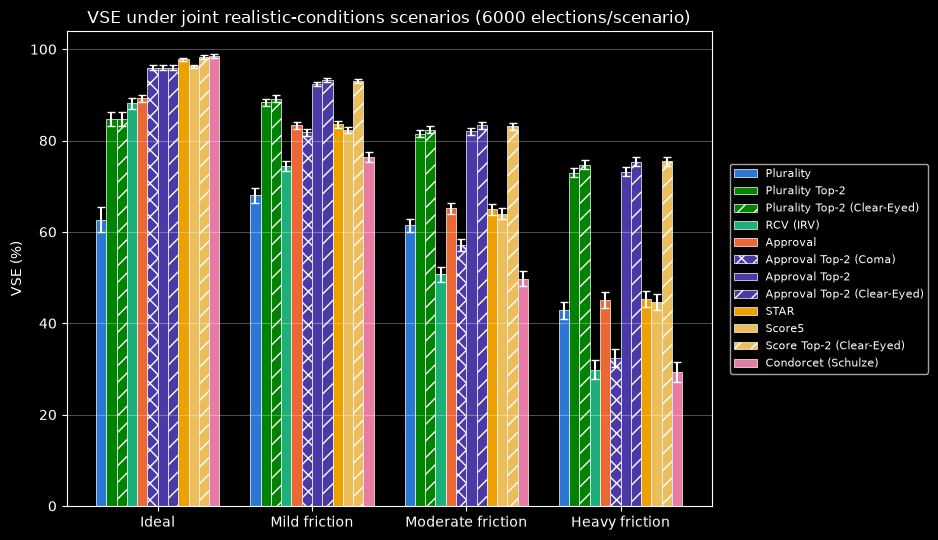

#### Epistemic noise (EPISTEMIC_RHO)

| Method | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.80 | epistemic_rho=0.90 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 69.6% (+/-2.9) | 78.8% (+/-2.7) | 73.2% (+/-3.4) | 65.8% (+/-4.2) | 60.6% (+/-4.5) | 62.7% (+/-2.8) |
| Plurality Top-2 | 75.8% (+/-2.2) | 85.5% (+/-1.6) | 90.1% (+/-1.3) | 88.6% (+/-1.8) | 87.1% (+/-2.0) | 84.7% (+/-1.6) |
| Plurality Top-2 (Clear-Eyed) | 86.8% (+/-1.8) | 92.8% (+/-1.1) | 92.5% (+/-1.3) | 90.6% (+/-1.6) | 87.2% (+/-2.3) | 84.7% (+/-1.6) |
| RCV (IRV) | 77.1% (+/-2.1) | 84.9% (+/-1.7) | 90.3% (+/-1.3) | 90.7% (+/-1.4) | 91.6% (+/-1.2) | 88.2% (+/-1.2) |
| Approval | 80.5% (+/-1.9) | 89.2% (+/-1.2) | 92.9% (+/-0.9) | 93.5% (+/-0.8) | 93.7% (+/-0.8) | 89.2% (+/-0.8) |
| Approval Top-2 | 79.9% (+/-1.9) | 87.1% (+/-1.4) | 92.9% (+/-0.9) | 94.9% (+/-0.7) | 96.2% (+/-0.6) | 96.0% (+/-0.5) |
| Approval Top-2 (Clear-Eyed) | 90.7% (+/-1.4) | 95.4% (+/-0.8) | 96.8% (+/-0.6) | 97.6% (+/-0.5) | 97.1% (+/-0.6) | 96.0% (+/-0.5) |
| STAR | 81.9% (+/-1.8) | 88.8% (+/-1.3) | 94.2% (+/-0.8) | 96.0% (+/-0.6) | 96.9% (+/-0.5) | 97.8% (+/-0.4) |
| Score5 | 81.8% (+/-1.8) | 89.5% (+/-1.2) | 93.6% (+/-0.9) | 95.2% (+/-0.7) | 95.7% (+/-0.6) | 96.2% (+/-0.4) |
| Score Top-2 (Clear-Eyed) | 93.0% (+/-1.1) | 95.9% (+/-0.7) | 97.7% (+/-0.5) | 98.3% (+/-0.4) | 98.2% (+/-0.4) | 98.3% (+/-0.4) |
| Condorcet (Schulze) | 79.0% (+/-2.0) | 87.5% (+/-1.4) | 93.6% (+/-0.8) | 95.5% (+/-0.7) | 97.0% (+/-0.5) | 98.6% (+/-0.4) |

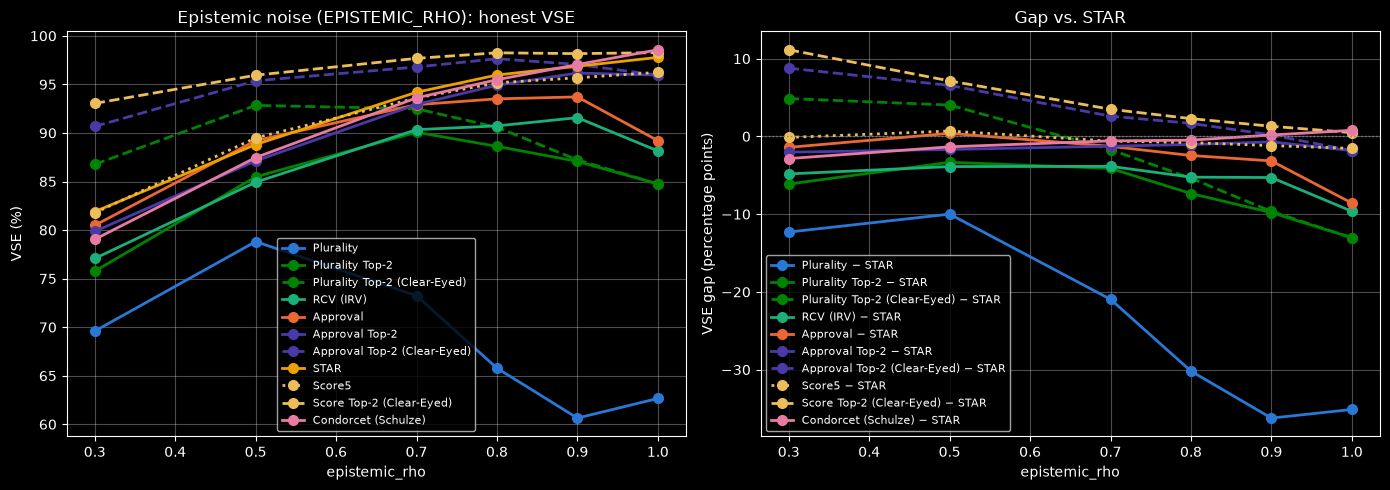

#### Unfamiliarity (AWARENESS_ALPHA)

| Method | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.80 | awareness_alpha=0.90 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Plurality | -3.0% (+/-6.8) | 2.7% (+/-6.4) | 51.9% (+/-4.2) | 64.0% (+/-3.6) | 69.0% (+/-3.6) | 62.7% (+/-2.8) |
| Plurality Top-2 | 64.7% (+/-3.0) | 68.9% (+/-2.7) | 79.5% (+/-2.2) | 84.9% (+/-1.9) | 87.5% (+/-1.9) | 84.7% (+/-1.6) |
| RCV (IRV) | -3.0% (+/-6.8) | -3.6% (+/-6.6) | 39.1% (+/-4.8) | 59.3% (+/-3.6) | 74.8% (+/-2.7) | 88.2% (+/-1.2) |
| Approval | -3.0% (+/-6.8) | 10.9% (+/-5.8) | 59.5% (+/-3.2) | 72.3% (+/-2.2) | 82.6% (+/-1.6) | 89.2% (+/-0.8) |
| Approval Top-2 (Coma) | -3.0% (+/-6.8) | -2.9% (+/-6.6) | 45.9% (+/-4.2) | 67.1% (+/-2.8) | 83.8% (+/-1.7) | 96.0% (+/-0.5) |
| Approval Top-2 | 64.7% (+/-3.0) | 69.9% (+/-2.6) | 81.1% (+/-2.0) | 86.6% (+/-1.6) | 92.6% (+/-1.1) | 96.0% (+/-0.5) |
| STAR | -3.0% (+/-6.8) | 12.5% (+/-5.8) | 60.6% (+/-3.1) | 73.6% (+/-2.3) | 84.5% (+/-1.6) | 97.8% (+/-0.4) |
| Score5 | -3.0% (+/-6.8) | 9.9% (+/-5.9) | 57.7% (+/-3.2) | 71.4% (+/-2.2) | 81.8% (+/-1.6) | 96.2% (+/-0.4) |
| Score Top-2 (Clear-Eyed) | 64.7% (+/-3.0) | 69.8% (+/-2.6) | 80.8% (+/-2.0) | 86.6% (+/-1.5) | 91.3% (+/-1.2) | 98.3% (+/-0.4) |
| Condorcet (Schulze) | -3.0% (+/-6.8) | -3.6% (+/-6.6) | 39.5% (+/-4.7) | 61.5% (+/-3.3) | 82.3% (+/-1.9) | 98.6% (+/-0.4) |

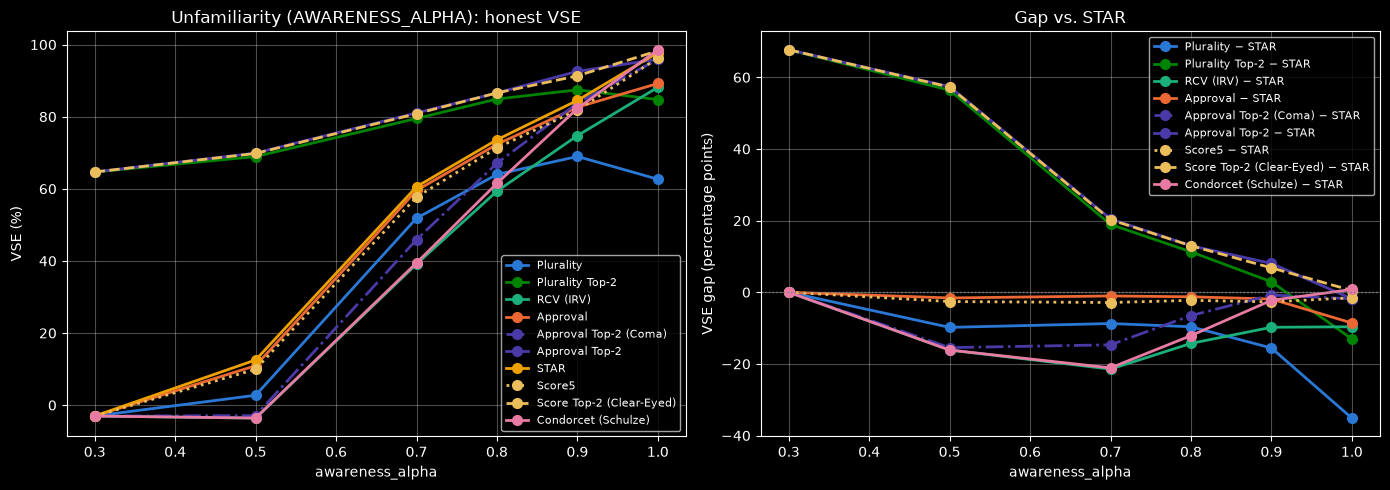

#### Ballot fatigue (FATIGUE_BETA)

| Method | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.80 | fatigue_beta=0.90 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 56.4% (+/-4.3) | 56.6% (+/-4.2) | 56.9% (+/-4.2) | 57.0% (+/-4.2) | 57.3% (+/-4.2) | 62.7% (+/-2.8) |
| Plurality Top-2 | 82.7% (+/-2.5) | 83.5% (+/-2.3) | 83.4% (+/-2.3) | 83.0% (+/-2.5) | 83.1% (+/-2.5) | 84.7% (+/-1.6) |
| RCV (IRV) | 60.1% (+/-4.1) | 67.5% (+/-3.6) | 74.1% (+/-3.1) | 79.9% (+/-2.6) | 83.5% (+/-2.2) | 88.2% (+/-1.2) |
| Approval | 62.8% (+/-4.0) | 72.2% (+/-3.4) | 85.3% (+/-2.1) | 90.5% (+/-1.5) | 92.1% (+/-1.1) | 89.2% (+/-0.8) |
| Approval Top-2 | 86.8% (+/-2.0) | 89.1% (+/-1.9) | 94.5% (+/-1.2) | 96.3% (+/-0.9) | 97.0% (+/-0.7) | 96.0% (+/-0.5) |
| STAR | 63.1% (+/-4.0) | 72.2% (+/-3.4) | 84.6% (+/-2.2) | 91.4% (+/-1.3) | 96.2% (+/-0.9) | 97.8% (+/-0.4) |
| Score5 | 62.9% (+/-4.0) | 71.0% (+/-3.5) | 84.0% (+/-2.2) | 91.1% (+/-1.5) | 95.9% (+/-0.8) | 96.2% (+/-0.4) |
| Score Top-2 (Clear-Eyed) | 87.2% (+/-2.0) | 89.2% (+/-1.9) | 94.5% (+/-1.2) | 96.7% (+/-0.8) | 97.8% (+/-0.6) | 98.3% (+/-0.4) |
| Condorcet (Schulze) | 59.9% (+/-4.1) | 66.8% (+/-3.7) | 77.7% (+/-2.9) | 86.4% (+/-2.2) | 94.4% (+/-1.1) | 98.6% (+/-0.4) |

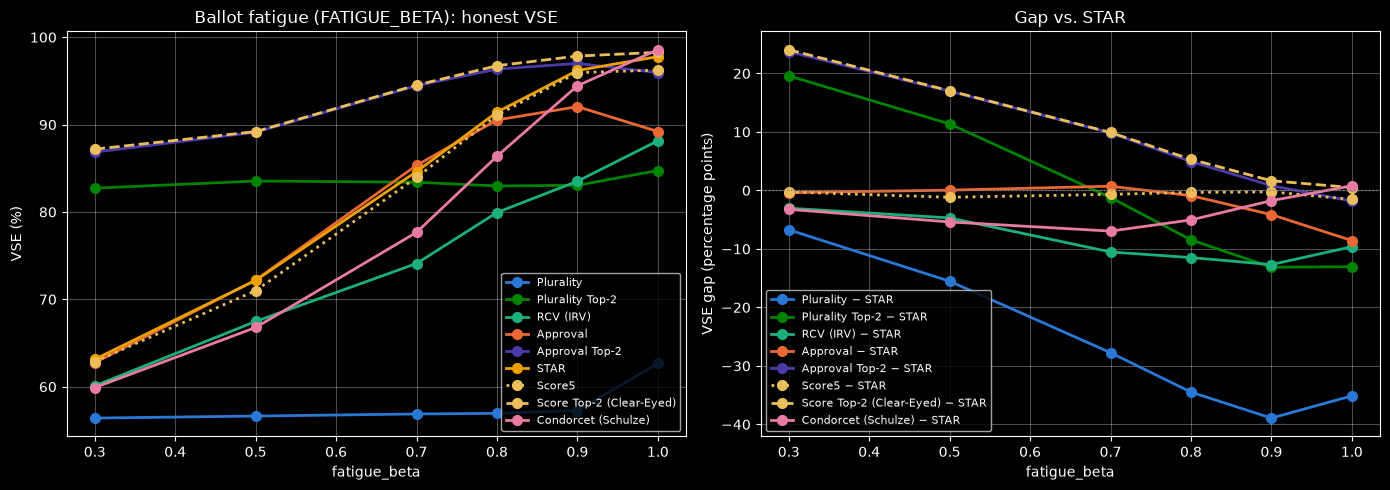

In [79]:
replay("approval-star-gap-scenarios")
replay("star-vse-gap-significant")
replay("vse-joint")
replay("runoff-help-sweep")

### Findings: How much does a delayed runoff actually help?

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |
| Approval | 89.2% (+/-0.8) | 83.3% (+/-0.7) | 65.2% (+/-1.2) | 45.1% (+/-1.7) |
| Approval Top-2 (Coma) | 96.0% (+/-0.5) | 81.8% (+/-0.7) | 57.1% (+/-1.4) | 32.4% (+/-2.0) |
| Approval Top-2 | 96.0% (+/-0.5) | 92.3% (+/-0.4) | 82.1% (+/-0.8) | 73.2% (+/-1.0) |

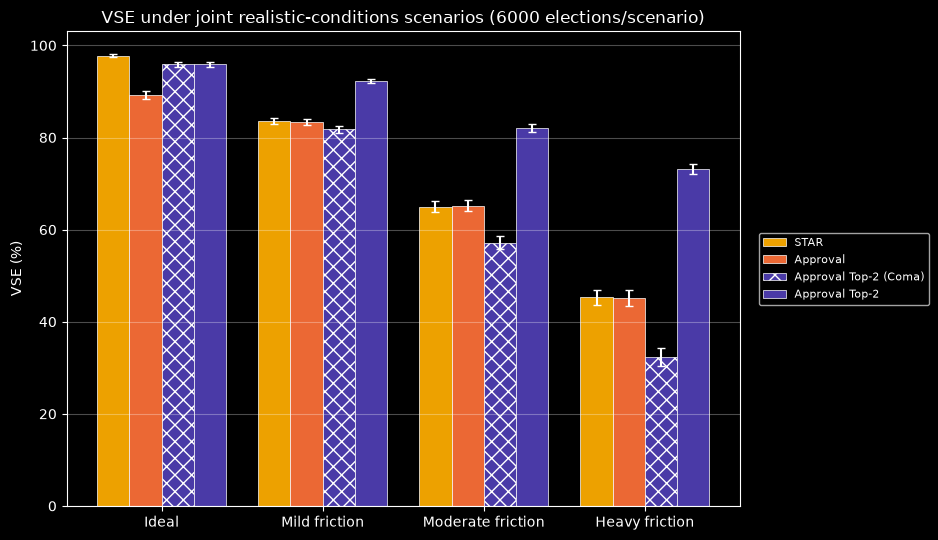

In [80]:
replay("coma-vs-approval")

In [81]:
replay("runoff-vs-baseline")
replay("coma-diagnostic")
replay("coma-vs-groggy")

### Does the runoff help or hurt Approval?

#### Ideal

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 | 89.2 | 96.0 | +6.7 | [+6.0, +7.5] | Decisive (runoff better) |

#### Mild friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | 83.3 | 93.2 | +9.9 | [+9.3, +10.5] | Decisive (runoff better) |
| Approval Top-2 | 83.3 | 92.3 | +9.0 | [+8.4, +9.7] | Decisive (runoff better) |
| Approval Top-2 (Coma) | 83.3 | 81.8 | -1.5 | [-2.1, -0.9] | Ambiguous edge (no runoff better) |

#### Moderate friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | 65.2 | 83.3 | +18.1 | [+17.1, +19.2] | Decisive (runoff better) |
| Approval Top-2 | 65.2 | 82.1 | +16.8 | [+15.8, +17.9] | Decisive (runoff better) |
| Approval Top-2 (Coma) | 65.2 | 57.1 | -8.1 | [-9.1, -7.1] | Decisive (no runoff better) |

#### Heavy friction

| Method | Approval VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | 45.1 | 75.4 | +30.2 | [+28.8, +31.7] | Decisive (runoff better) |
| Approval Top-2 | 45.1 | 73.2 | +28.0 | [+26.6, +29.5] | Decisive (runoff better) |
| Approval Top-2 (Coma) | 45.1 | 32.4 | -12.8 | [-14.1, -11.5] | Decisive (no runoff better) |


### Does the runoff help or hurt Plurality?

#### Ideal

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top-2 | 62.7 | 84.7 | +22.1 | [+19.7, +24.5] | Decisive (runoff better) |

#### Mild friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | 68.0 | 89.2 | +21.2 | [+19.7, +22.6] | Decisive (runoff better) |
| Plurality Top-2 | 68.0 | 88.4 | +20.3 | [+18.9, +21.8] | Decisive (runoff better) |

#### Moderate friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | 61.5 | 82.4 | +20.9 | [+19.7, +22.2] | Decisive (runoff better) |
| Plurality Top-2 | 61.5 | 81.5 | +20.1 | [+18.8, +21.3] | Decisive (runoff better) |

#### Heavy friction

| Method | Plurality VSE (%) | Method VSE (%) | Gap (pp) | 95% CI | Significant? |
|---|---|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | 42.8 | 74.7 | +31.9 | [+30.4, +33.5] | Decisive (runoff better) |
| Plurality Top-2 | 42.8 | 73.0 | +30.2 | [+28.6, +31.7] | Decisive (runoff better) |


#### Coma AT2: why voters end up voting against their own pairwise interest

| Scenario | Aligned | Awareness-attributable | Noise-unfixable (even if Groggy) |
|---|---|---|---|
| Ideal | 100.0% | 0.0% | 0.0% |
| Mild friction | 71.2% | 10.9% | 17.9% |
| Moderate friction | 66.3% | 14.5% | 19.2% |
| Heavy friction | 63.3% | 15.8% | 20.8% |

#### Coma AT2: detailed breakdown

| Scenario | Wrong (awareness-fixable) | Wrong (noise-unfixable) | Abstained (awareness-fixable) | Abstained (noise-unfixable) |
|---|---|---|---|---|
| Ideal | 0.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 9.8% | 17.6% | 1.1% | 0.3% |
| Moderate friction | 13.1% | 18.8% | 1.4% | 0.5% |
| Heavy friction | 15.1% | 20.5% | 0.7% | 0.3% |

#### Coma vs Groggy: election-level aggregate-sign accuracy (does the runoff decision match the true preference?)

| Scenario | Coma correct | Groggy correct | Both correct | Coma-only correct | Groggy-only correct | Both wrong |
|---|---|---|---|---|---|---|
| Ideal | 100.0% | 100.0% | 100.0% | 0.0% | 0.0% | 0.0% |
| Mild friction | 61.8% | 85.9% | 55.2% | 6.5% | 30.7% | 7.6% |
| Moderate friction | 51.5% | 85.8% | 44.3% | 7.2% | 41.4% | 7.0% |
| Heavy friction | 46.5% | 85.5% | 38.9% | 7.6% | 46.6% | 6.9% |

An election's outcome depends on the aggregate runoff decision, not per-voter accuracy. That is the metric driving the VSE gap. "Groggy-only correct" elections are ones where fixing awareness alone flips the aggregate decision from wrong to right, even though the per-voter `awareness_attributable` rate above is modest.

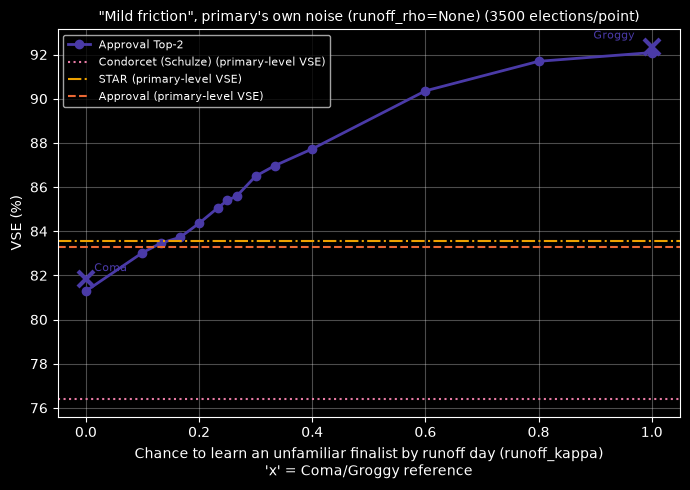

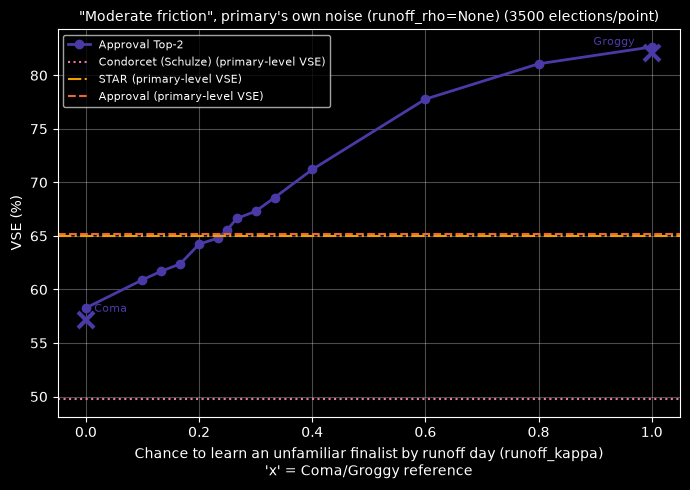

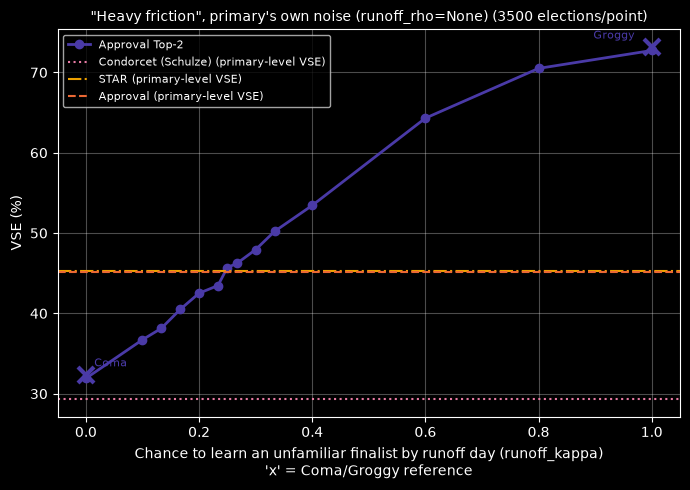

### kappa threshold for AT2 VSE > STAR VSE (95% confidence, paired)


#### Mild friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 81.3 | 84.0 (+/-0.9) | -2.7 | [-3.4, -1.9] | Decisive (STAR better) |
| 0.10 | 83.0 | 84.0 (+/-0.9) | -0.9 | [-1.6, -0.3] | Ambiguous edge (STAR better) |
| 0.13 | 83.5 | 84.0 (+/-0.9) | -0.5 | [-1.2, +0.2] | Inconclusive |
| 0.17 | 83.7 | 84.0 (+/-0.9) | -0.2 | [-1.0, +0.5] | Indistinguishable |
| 0.20 | 84.4 | 84.0 (+/-0.9) | +0.4 | [-0.3, +1.1] | Inconclusive |
| 0.23 | 85.1 | 84.0 (+/-0.9) | +1.1 | [+0.4, +1.8] | Ambiguous edge (Approval Top-2 better) |
| 0.25 | 85.4 | 84.0 (+/-0.9) | +1.4 | [+0.7, +2.1] | Ambiguous edge (Approval Top-2 better) |
| 0.27 | 85.6 | 84.0 (+/-0.9) | +1.6 | [+0.9, +2.3] | Ambiguous edge (Approval Top-2 better) |
| 0.30 | 86.5 | 84.0 (+/-0.9) | +2.5 | [+1.8, +3.2] | Decisive (Approval Top-2 better) |
| 0.33 | 87.0 | 84.0 (+/-0.9) | +3.0 | [+2.3, +3.7] | Decisive (Approval Top-2 better) |
| 0.40 | 87.7 | 84.0 (+/-0.9) | +3.8 | [+3.1, +4.5] | Decisive (Approval Top-2 better) |
| 0.60 | 90.4 | 84.0 (+/-0.9) | +6.4 | [+5.7, +7.1] | Decisive (Approval Top-2 better) |
| 0.80 | 91.7 | 84.0 (+/-0.9) | +7.7 | [+6.9, +8.5] | Decisive (Approval Top-2 better) |
| 1.00 | 92.1 | 84.0 (+/-0.9) | +8.1 | [+7.3, +8.9] | Decisive (Approval Top-2 better) |

**-> First kappa where AT2 is significantly better than STAR in Mild friction (95% CI gap > 0): `kappa ~ 0.23`**


#### Moderate friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 58.3 | 66.0 (+/-1.6) | -7.7 | [-8.8, -6.6] | Decisive (STAR better) |
| 0.10 | 60.9 | 66.0 (+/-1.6) | -5.1 | [-6.1, -4.0] | Decisive (STAR better) |
| 0.13 | 61.7 | 66.0 (+/-1.6) | -4.3 | [-5.3, -3.2] | Decisive (STAR better) |
| 0.17 | 62.4 | 66.0 (+/-1.6) | -3.6 | [-4.6, -2.5] | Decisive (STAR better) |
| 0.20 | 64.2 | 66.0 (+/-1.6) | -1.7 | [-2.8, -0.7] | Ambiguous edge (STAR better) |
| 0.23 | 64.8 | 66.0 (+/-1.6) | -1.2 | [-2.2, -0.1] | Ambiguous edge (STAR better) |
| 0.25 | 65.6 | 66.0 (+/-1.6) | -0.4 | [-1.4, +0.6] | Inconclusive |
| 0.27 | 66.6 | 66.0 (+/-1.6) | +0.7 | [-0.4, +1.7] | Inconclusive |
| 0.30 | 67.3 | 66.0 (+/-1.6) | +1.3 | [+0.3, +2.4] | Ambiguous edge (Approval Top-2 better) |
| 0.33 | 68.6 | 66.0 (+/-1.6) | +2.6 | [+1.6, +3.6] | Decisive (Approval Top-2 better) |
| 0.40 | 71.2 | 66.0 (+/-1.6) | +5.2 | [+4.1, +6.4] | Decisive (Approval Top-2 better) |
| 0.60 | 77.8 | 66.0 (+/-1.6) | +11.8 | [+10.6, +13.0] | Decisive (Approval Top-2 better) |
| 0.80 | 81.1 | 66.0 (+/-1.6) | +15.1 | [+13.8, +16.4] | Decisive (Approval Top-2 better) |
| 1.00 | 82.6 | 66.0 (+/-1.6) | +16.7 | [+15.3, +18.0] | Decisive (Approval Top-2 better) |

**-> First kappa where AT2 is significantly better than STAR in Moderate friction (95% CI gap > 0): `kappa ~ 0.30`**


#### Heavy friction

| kappa | AT2 VSE (%) | STAR VSE (%) | Gap (pp, paired) | 95% CI (paired, pp) | AT2 > STAR? |
|---|---|---|---|---|---|
| 0.00 | 31.9 | 44.9 (+/-2.2) | -13.0 | [-14.7, -11.3] | Decisive (STAR better) |
| 0.10 | 36.7 | 44.9 (+/-2.2) | -8.2 | [-9.7, -6.7] | Decisive (STAR better) |
| 0.13 | 38.1 | 44.9 (+/-2.2) | -6.8 | [-8.3, -5.3] | Decisive (STAR better) |
| 0.17 | 40.5 | 44.9 (+/-2.2) | -4.4 | [-5.7, -3.1] | Decisive (STAR better) |
| 0.20 | 42.5 | 44.9 (+/-2.2) | -2.4 | [-3.8, -1.0] | Decisive (STAR better) |
| 0.23 | 43.5 | 44.9 (+/-2.2) | -1.4 | [-2.8, -0.1] | Ambiguous edge (STAR better) |
| 0.25 | 45.7 | 44.9 (+/-2.2) | +0.8 | [-0.5, +2.1] | Inconclusive |
| 0.27 | 46.2 | 44.9 (+/-2.2) | +1.3 | [-0.0, +2.6] | Inconclusive |
| 0.30 | 47.9 | 44.9 (+/-2.2) | +3.0 | [+1.6, +4.4] | Decisive (Approval Top-2 better) |
| 0.33 | 50.2 | 44.9 (+/-2.2) | +5.3 | [+4.0, +6.6] | Decisive (Approval Top-2 better) |
| 0.40 | 53.4 | 44.9 (+/-2.2) | +8.5 | [+7.1, +10.0] | Decisive (Approval Top-2 better) |
| 0.60 | 64.3 | 44.9 (+/-2.2) | +19.4 | [+17.7, +21.1] | Decisive (Approval Top-2 better) |
| 0.80 | 70.5 | 44.9 (+/-2.2) | +25.6 | [+23.8, +27.4] | Decisive (Approval Top-2 better) |
| 1.00 | 72.7 | 44.9 (+/-2.2) | +27.8 | [+26.0, +29.7] | Decisive (Approval Top-2 better) |

**-> First kappa where AT2 is significantly better than STAR in Heavy friction (95% CI gap > 0): `kappa ~ 0.30`**


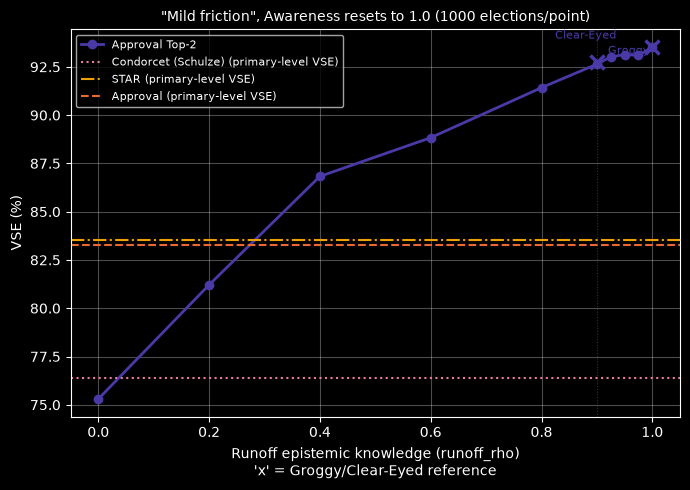

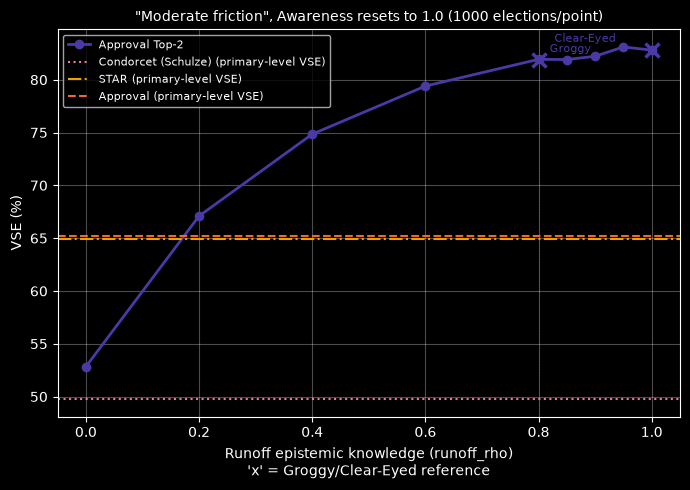

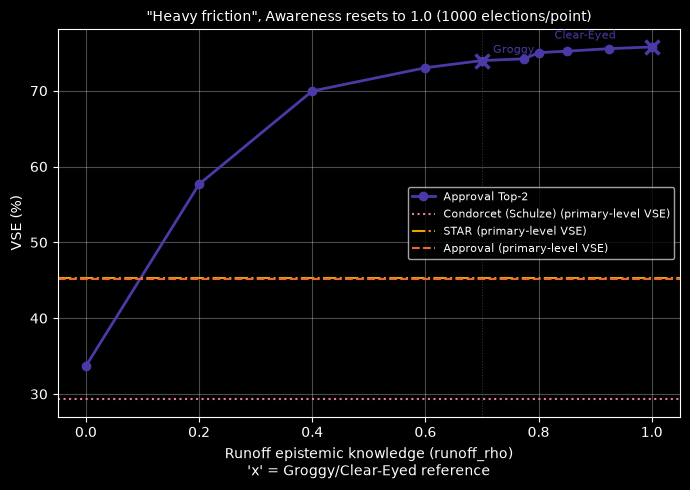

In [82]:
replay("runoff-learn-sweep")
replay("p-learn-ci-table")
replay("runoff-t-sweep")

### Findings: STAR Runoff Betrayal

In [83]:
replay("star-betrayal-tables")
replay("scoret2-vs-at2")

#### Runoff betrayal rate by joint-friction scenario

| Scenario | Betrayal rate | Voter corruption rate | VSE (STAR's actual runoff) | VSE (honest/delayed-perfect runoff) | VSE (AT2 Clear-Eyed runoff) |
|---|---|---|---|---|---|
| Ideal | 0.0% | 0.00% | 97.8% | 97.8% (+0.0 pts over actual) | 96.0% (-1.8 pts over STAR) |
| Mild friction | 33.0% | 35.80% | 83.5% | 91.0% (+7.5 pts over actual) | 93.2% (+9.7 pts over STAR) |
| Moderate friction | 39.4% | 45.16% | 65.0% | 81.0% (+16.0 pts over actual) | 83.3% (+18.4 pts over STAR) |
| Heavy friction | 43.7% | 48.85% | 45.3% | 71.4% (+26.2 pts over actual) | 75.4% (+30.1 pts over STAR) |

#### Score Top-2 (Clear-Eyed) vs Approval Top-2 (Clear-Eyed): paired VSE gap by joint-friction scenario

| Scenario | Score Top-2 VSE (%) | AT2 VSE (%) | Gap vs AT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 98.3 | 96.0 | +2.3 | [+1.8, +2.8] | Decisive (Score Top-2 better) |
| Mild friction | 93.1 | 93.2 | -0.1 | [-0.4, +0.1] | Indistinguishable |
| Moderate friction | 83.1 | 83.3 | -0.2 | [-0.6, +0.2] | Indistinguishable |
| Heavy friction | 75.4 | 75.4 | +0.1 | [-0.3, +0.4] | Indistinguishable |

### Appendix: The Plurality Bump

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| Plurality Top-2 | 84.7% (+/-1.6) | 88.4% (+/-0.7) | 81.5% (+/-0.8) | 73.0% (+/-1.0) |
| Plurality Top-2 (Clear-Eyed) | 84.7% (+/-1.6) | 89.2% (+/-0.7) | 82.4% (+/-0.8) | 74.7% (+/-1.0) |
| Approval Top-2 (Clear-Eyed) | 96.0% (+/-0.5) | 93.2% (+/-0.4) | 83.3% (+/-0.8) | 75.4% (+/-1.0) |

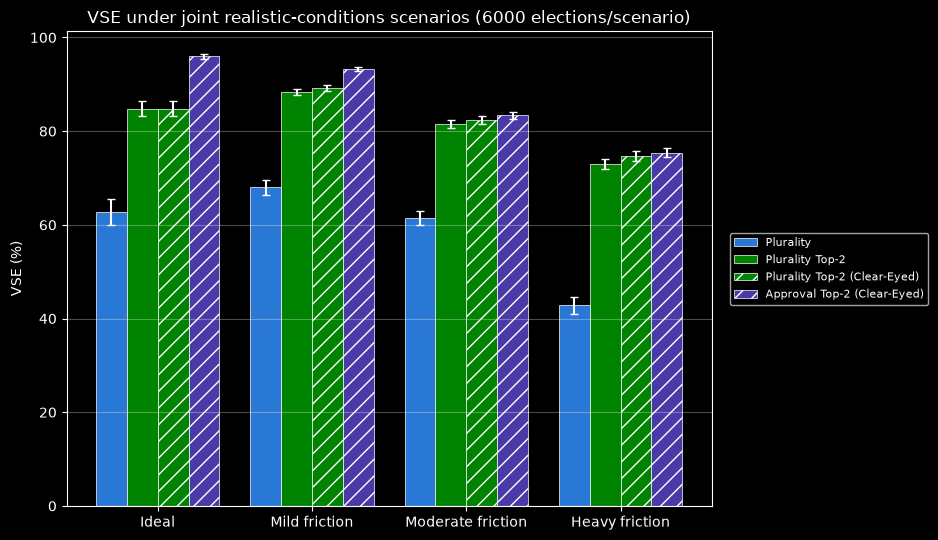

In [84]:
replay("plurality-bump")

### Appendix: Approval vs Plurality

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| Approval | 89.2% (+/-0.8) | 83.3% (+/-0.7) | 65.2% (+/-1.2) | 45.1% (+/-1.7) |

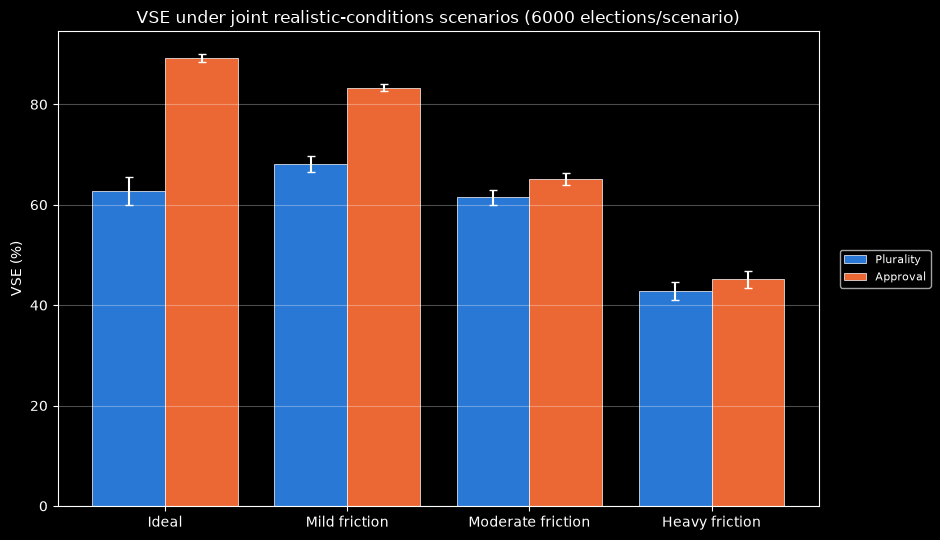

#### Approval vs Plurality: paired VSE gap by joint-friction scenario

| Scenario | Approval VSE (%) | Plurality VSE (%) | Gap vs Plurality (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 89.2 | 62.7 | +26.5 | [+23.6, +29.5] | Decisive (Approval better) |
| Mild friction | 83.3 | 68.0 | +15.3 | [+13.7, +16.8] | Decisive (Approval better) |
| Moderate friction | 65.2 | 61.5 | +3.7 | [+2.7, +4.8] | Decisive (Approval better) |
| Heavy friction | 45.1 | 42.8 | +2.3 | [+1.5, +3.2] | Decisive (Approval better) |

#### Approval Top-2 vs Plurality Top-2: paired VSE gap by joint-friction scenario

| Scenario | AT2 VSE (%) | PT2 VSE (%) | Gap vs PT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 96.0 | 84.7 | +11.2 | [+9.5, +12.9] | Decisive (AT2 better) |
| Mild friction | 92.3 | 88.4 | +4.0 | [+3.2, +4.7] | Decisive (AT2 better) |
| Moderate friction | 82.1 | 81.5 | +0.5 | [-0.1, +1.1] | Inconclusive |
| Heavy friction | 73.2 | 73.0 | +0.2 | [-0.3, +0.7] | Indistinguishable |

#### Approval Top-2 (Clear-Eyed) vs Plurality Top-2 (Clear-Eyed): paired VSE gap by joint-friction scenario

| Scenario | AT2 VSE (%) | PT2 VSE (%) | Gap vs PT2 (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 96.0 | 84.7 | +11.2 | [+9.6, +12.9] | Decisive (AT2 better) |
| Mild friction | 93.2 | 89.2 | +4.0 | [+3.3, +4.7] | Decisive (AT2 better) |
| Moderate friction | 83.3 | 82.4 | +0.9 | [+0.3, +1.5] | Ambiguous edge (AT2 better) |
| Heavy friction | 75.4 | 74.7 | +0.6 | [+0.1, +1.1] | Ambiguous edge (AT2 better) |

#### Ideal: VSE by candidate count (NCAND)

| ncand | Approval Top-2 VSE (%) | Plurality Top-2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 96.9% (+/-1.0) | 87.6% (+/-2.1) | +9.3 |
| 5 | 96.6% (+/-0.6) | 85.4% (+/-2.2) | +11.2 |
| 6 | 95.5% (+/-0.7) | 84.2% (+/-2.2) | +11.3 |
| 8 | 94.1% (+/-0.8) | 79.9% (+/-2.4) | +14.2 |
| 10 | 92.9% (+/-0.8) | 79.6% (+/-2.4) | +13.3 |
| 15 | 88.7% (+/-1.1) | 73.2% (+/-2.5) | +15.4 |

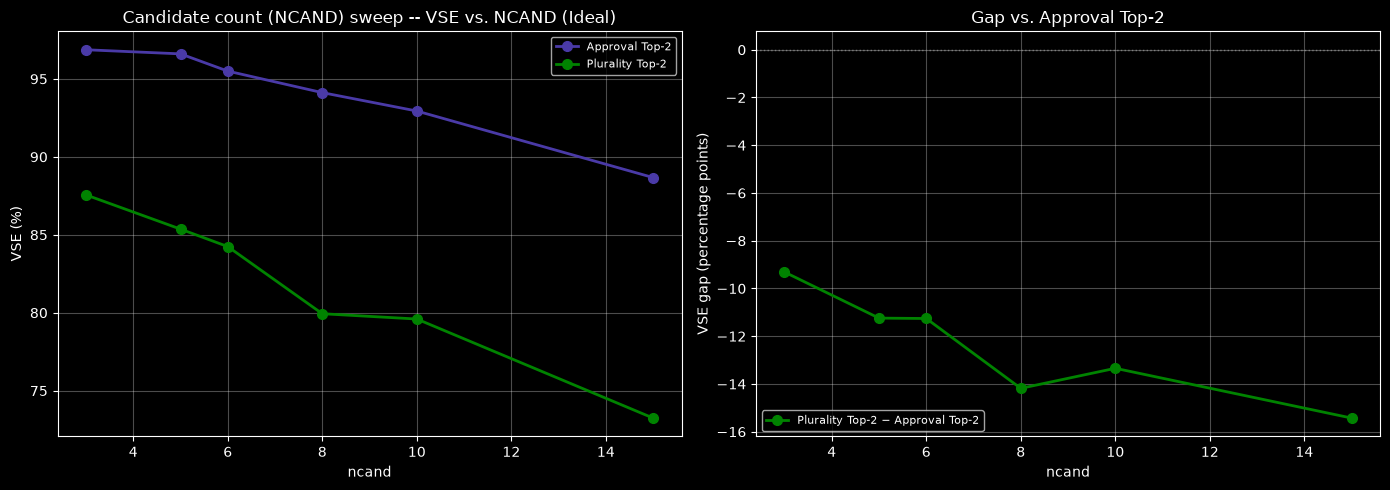

#### Mild friction: VSE by candidate count (NCAND)

| ncand | Approval Top-2 VSE (%) | Plurality Top-2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 95.1% (+/-1.3) | 90.3% (+/-1.9) | +4.8 |
| 5 | 94.1% (+/-0.8) | 90.4% (+/-1.5) | +3.7 |
| 6 | 92.3% (+/-0.9) | 89.1% (+/-1.5) | +3.2 |
| 8 | 88.3% (+/-1.1) | 84.7% (+/-1.9) | +3.6 |
| 10 | 87.9% (+/-1.1) | 84.8% (+/-1.6) | +3.1 |
| 15 | 85.0% (+/-1.2) | 81.3% (+/-1.7) | +3.7 |

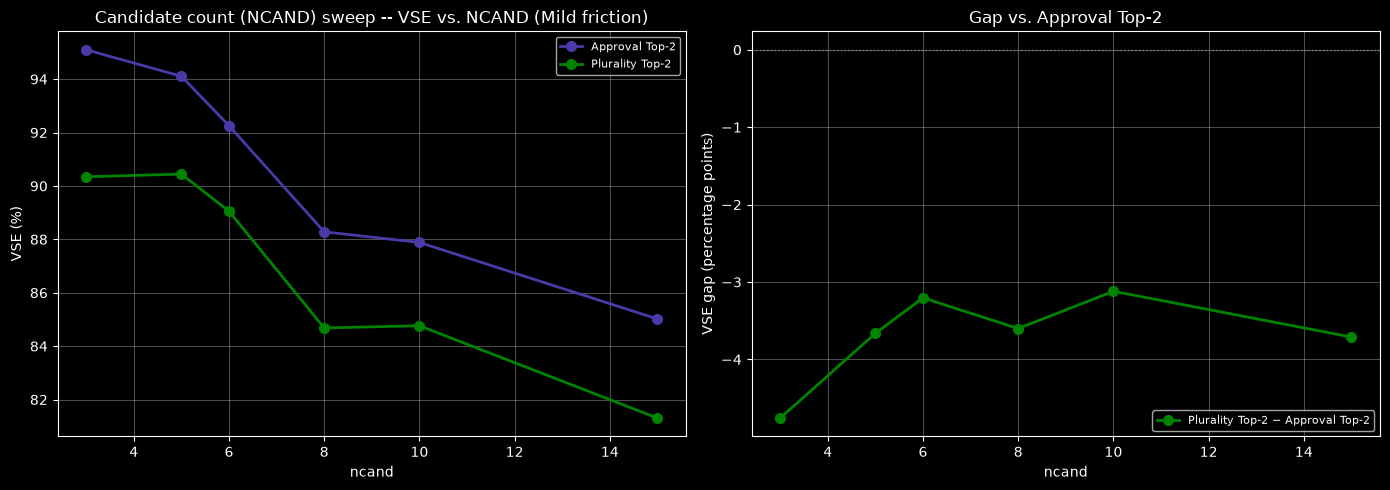

#### Moderate friction: VSE by candidate count (NCAND)

| ncand | Approval Top-2 VSE (%) | Plurality Top-2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 91.4% (+/-1.7) | 89.3% (+/-1.8) | +2.1 |
| 5 | 85.3% (+/-1.7) | 84.6% (+/-1.7) | +0.7 |
| 6 | 82.8% (+/-1.7) | 83.0% (+/-1.7) | -0.3 |
| 8 | 78.7% (+/-1.7) | 78.2% (+/-1.8) | +0.5 |
| 10 | 78.1% (+/-1.6) | 77.5% (+/-1.7) | +0.6 |
| 15 | 75.3% (+/-1.8) | 76.5% (+/-1.7) | -1.2 |

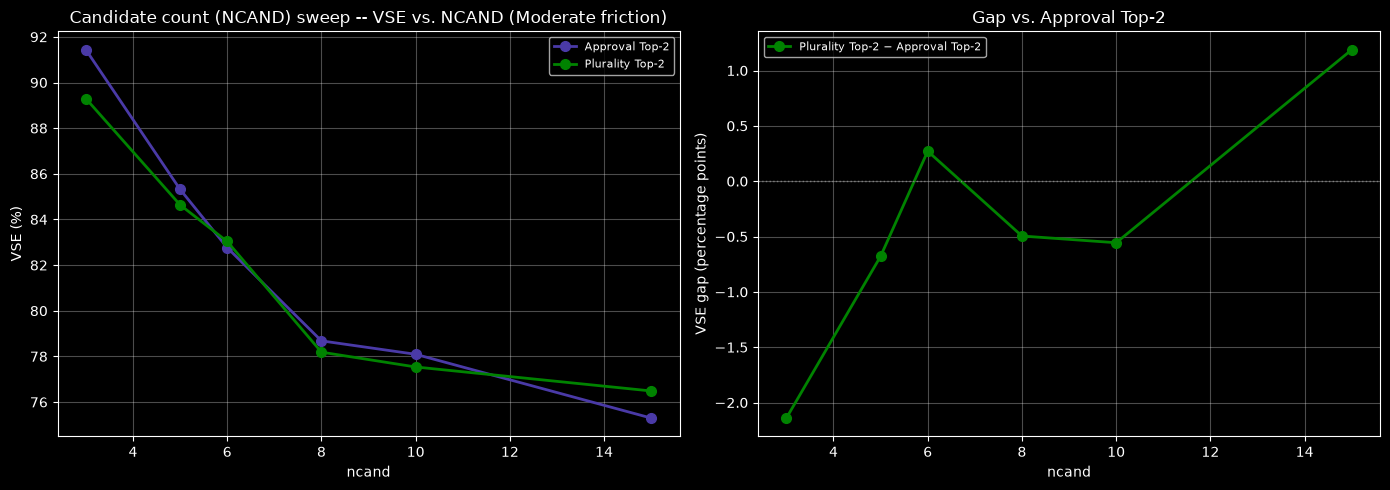

#### Heavy friction: VSE by candidate count (NCAND)

| ncand | Approval Top-2 VSE (%) | Plurality Top-2 VSE (%) | Gap (pp) |
|---|---|---|---|
| 3 | 83.4% (+/-2.4) | 83.8% (+/-2.3) | -0.5 |
| 5 | 77.6% (+/-2.2) | 78.9% (+/-2.1) | -1.3 |
| 6 | 70.7% (+/-2.4) | 70.1% (+/-2.4) | +0.6 |
| 8 | 70.2% (+/-2.3) | 70.5% (+/-2.2) | -0.3 |
| 10 | 69.2% (+/-2.2) | 68.8% (+/-2.3) | +0.5 |
| 15 | 68.4% (+/-2.2) | 68.6% (+/-2.2) | -0.1 |

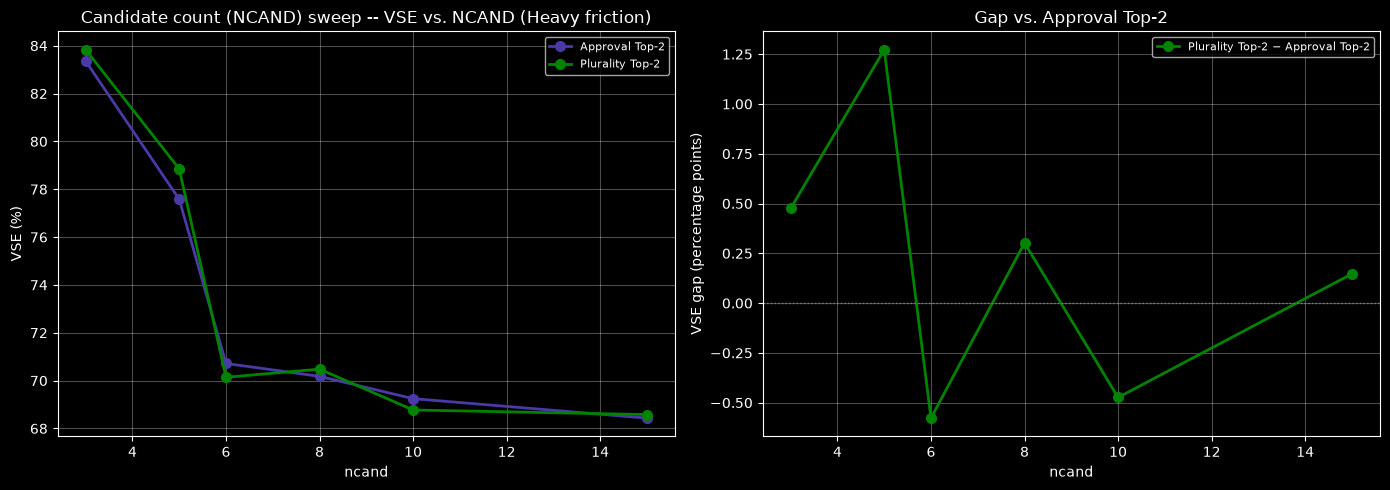

#### Ideal

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 96.87% | 87.56% | +9.31 | [+7.40, +11.23] | Decisive (Approval Top-2 better) |
| 5 | 96.61% | 85.37% | +11.24 | [+8.99, +13.50] | Decisive (Approval Top-2 better) |
| 6 | 95.50% | 84.24% | +11.26 | [+8.99, +13.52] | Decisive (Approval Top-2 better) |
| 8 | 94.12% | 79.94% | +14.18 | [+11.63, +16.73] | Decisive (Approval Top-2 better) |
| 10 | 92.94% | 79.60% | +13.34 | [+10.73, +15.96] | Decisive (Approval Top-2 better) |
| 15 | 88.67% | 73.24% | +15.43 | [+12.61, +18.25] | Decisive (Approval Top-2 better) |

#### Mild friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 95.10% | 90.34% | +4.76 | [+3.18, +6.34] | Decisive (Approval Top-2 better) |
| 5 | 94.11% | 90.45% | +3.66 | [+2.24, +5.09] | Decisive (Approval Top-2 better) |
| 6 | 92.26% | 89.05% | +3.20 | [+1.72, +4.69] | Decisive (Approval Top-2 better) |
| 8 | 88.28% | 84.68% | +3.60 | [+1.79, +5.41] | Decisive (Approval Top-2 better) |
| 10 | 87.88% | 84.77% | +3.12 | [+1.60, +4.64] | Decisive (Approval Top-2 better) |
| 15 | 85.02% | 81.31% | +3.71 | [+2.03, +5.39] | Decisive (Approval Top-2 better) |

#### Moderate friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 91.44% | 89.30% | +2.14 | [+0.76, +3.52] | Ambiguous edge (Approval Top-2 better) |
| 5 | 85.32% | 84.64% | +0.68 | [-0.85, +2.21] | Inconclusive |
| 6 | 82.76% | 83.03% | -0.27 | [-1.37, +0.82] | Inconclusive |
| 8 | 78.68% | 78.19% | +0.50 | [-0.64, +1.63] | Inconclusive |
| 10 | 78.09% | 77.54% | +0.56 | [-0.59, +1.70] | Inconclusive |
| 15 | 75.30% | 76.49% | -1.19 | [-2.13, -0.25] | Ambiguous edge (Plurality Top-2 better) |

#### Heavy friction

| NCAND | AT2 VSE | PT2 VSE | Gap (AT2 - PT2, pp) | 95% CI (paired, pp) | Significant? |
|---:|---:|---:|---:|---:|---:|
| 3 | 83.36% | 83.83% | -0.48 | [-1.76, +0.81] | Inconclusive |
| 5 | 77.58% | 78.85% | -1.27 | [-2.64, +0.09] | Inconclusive |
| 6 | 70.72% | 70.14% | +0.58 | [-0.66, +1.81] | Inconclusive |
| 8 | 70.18% | 70.48% | -0.30 | [-1.34, +0.74] | Inconclusive |
| 10 | 69.25% | 68.77% | +0.47 | [-0.67, +1.62] | Inconclusive |
| 15 | 68.43% | 68.58% | -0.15 | [-0.99, +0.70] | Indistinguishable |

In [85]:
replay("plurality-vs-approval")
replay("plurality-approval-ci")
replay("at2-pt2-ci")
replay("at2-pt2-candidate-sweep")
replay("at2-pt2-candidate-ci")

### Appendix: SCORE vs STAR

#### STAR vs. Score5 by `epistemic_rho`

| Method | epistemic_rho=0.30 | epistemic_rho=0.50 | epistemic_rho=0.70 | epistemic_rho=0.80 | epistemic_rho=0.90 | epistemic_rho=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 81.8% (+/-1.8) | 89.5% (+/-1.2) | 93.6% (+/-0.9) | 95.2% (+/-0.7) | 95.7% (+/-0.6) | 96.2% (+/-0.4) |
| STAR | 81.9% (+/-1.8) | 88.8% (+/-1.3) | 94.2% (+/-0.8) | 96.0% (+/-0.6) | 96.9% (+/-0.5) | 97.8% (+/-0.4) |

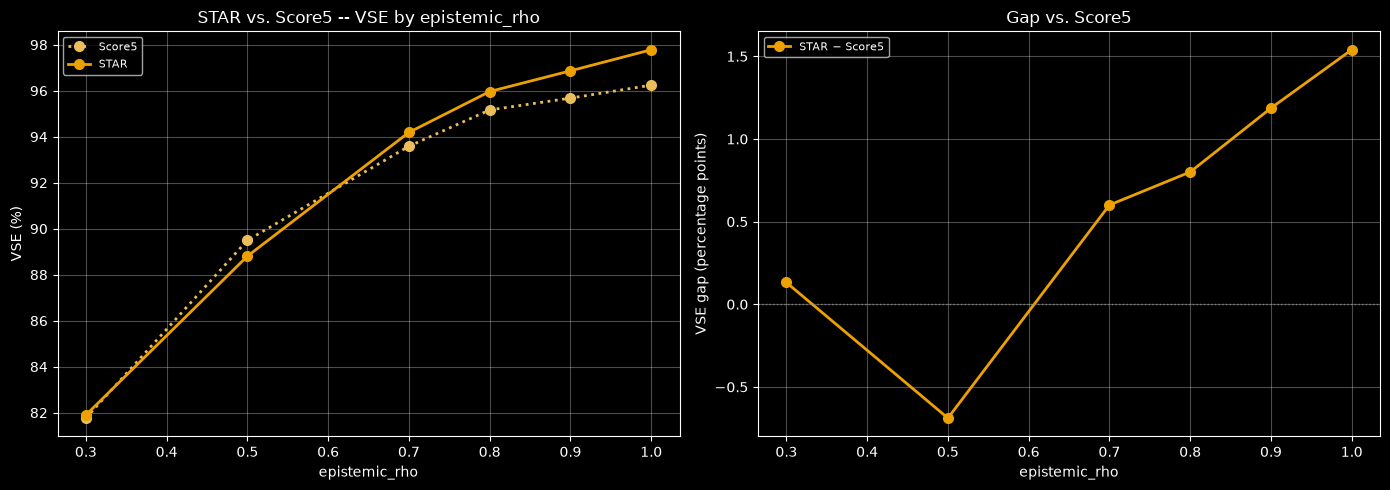

#### STAR vs. Score5 by `awareness_alpha`

| Method | awareness_alpha=0.30 | awareness_alpha=0.50 | awareness_alpha=0.70 | awareness_alpha=0.80 | awareness_alpha=0.90 | awareness_alpha=1.00 |
|---|---|---|---|---|---|---|
| Score5 | -3.0% (+/-6.8) | 9.9% (+/-5.9) | 57.7% (+/-3.2) | 71.4% (+/-2.2) | 81.8% (+/-1.6) | 96.2% (+/-0.4) |
| STAR | -3.0% (+/-6.8) | 12.5% (+/-5.8) | 60.6% (+/-3.1) | 73.6% (+/-2.3) | 84.5% (+/-1.6) | 97.8% (+/-0.4) |

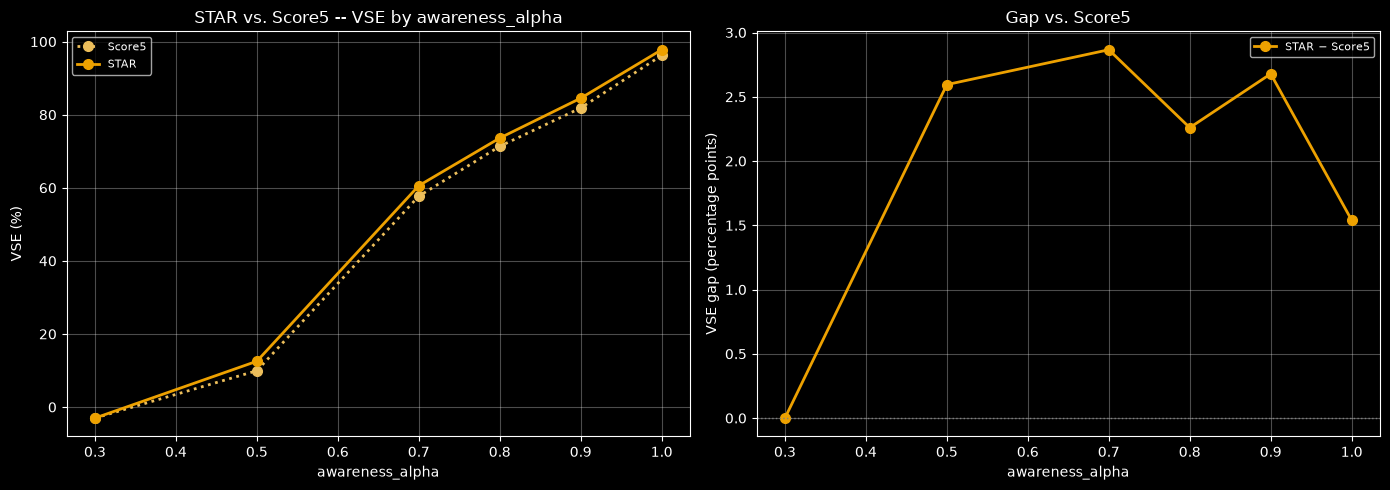

#### STAR vs. Score5 by `fatigue_beta`

| Method | fatigue_beta=0.30 | fatigue_beta=0.50 | fatigue_beta=0.70 | fatigue_beta=0.80 | fatigue_beta=0.90 | fatigue_beta=1.00 |
|---|---|---|---|---|---|---|
| Score5 | 62.9% (+/-4.0) | 71.0% (+/-3.5) | 84.0% (+/-2.2) | 91.1% (+/-1.5) | 95.9% (+/-0.8) | 96.2% (+/-0.4) |
| STAR | 63.1% (+/-4.0) | 72.2% (+/-3.4) | 84.6% (+/-2.2) | 91.4% (+/-1.3) | 96.2% (+/-0.9) | 97.8% (+/-0.4) |

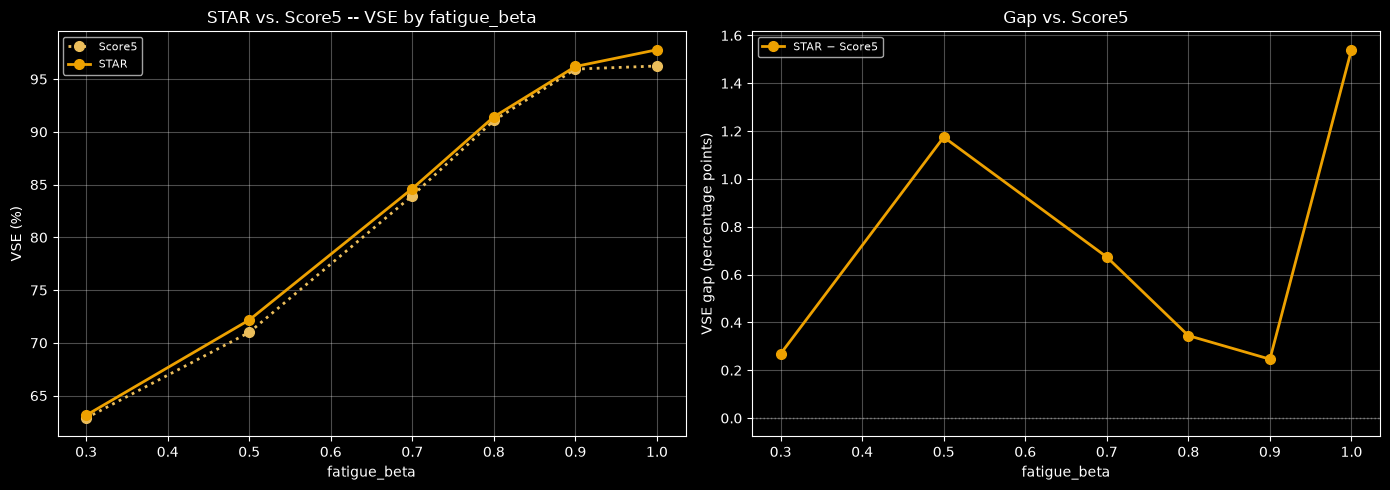

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Score5 | 96.2% (+/-0.4) | 82.3% (+/-0.7) | 64.0% (+/-1.2) | 44.6% (+/-1.7) |
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |

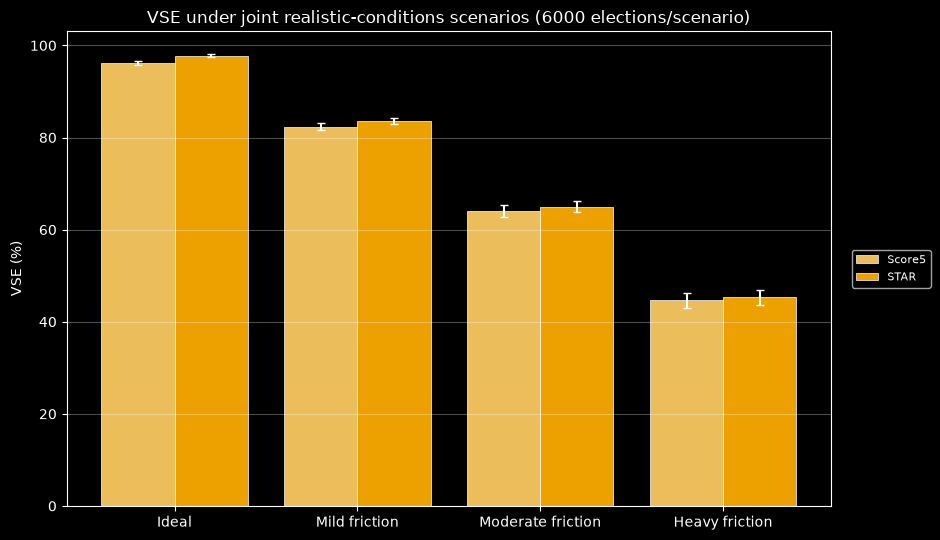

#### Score5 vs STAR: paired VSE gap by joint-friction scenario

| Scenario | Score VSE (%) | STAR VSE (%) | Gap vs STAR (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 96.2 | 97.8 | -1.5 | [-2.0, -1.1] | Decisive (STAR better) |
| Mild friction | 82.3 | 83.5 | -1.2 | [-1.6, -0.8] | Ambiguous edge (STAR better) |
| Moderate friction | 64.0 | 65.0 | -0.9 | [-1.4, -0.5] | Ambiguous edge (STAR better) |
| Heavy friction | 44.6 | 45.3 | -0.6 | [-1.1, -0.2] | Ambiguous edge (STAR better) |

In [86]:
replay("score-vs-star")
replay("score-vs-star-scenarios")

### Appendix: 99% Confidence Check

In [87]:
replay("not-sig-at-99-part1")

### 5 result(s) lose significance at 99% confidence


- **Approval Top-2 (Clear-Eyed) vs Plurality Top-2 (Clear-Eyed) / Heavy friction**: at 95% confidence, **AT2** appeared better than **PT2** by 0.6pp (Ambiguous edge, 95% CI [+0.1, +1.1]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-0.0, +1.3], which contains 0).
- **kappa threshold: Moderate friction / kappa=0.23**: at 95% confidence, **STAR** appeared better than **Approval Top-2** by 1.2pp (Ambiguous edge, 95% CI [-2.2, -0.1]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-2.5, +0.2], which contains 0).
- **kappa threshold: Moderate friction / kappa=0.30**: at 95% confidence, **Approval Top-2** appeared better than **STAR** by 1.3pp (Ambiguous edge, 95% CI [+0.3, +2.4]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-0.0, +2.7], which contains 0).
- **kappa threshold: Heavy friction / kappa=0.23**: at 95% confidence, **STAR** appeared better than **Approval Top-2** by 1.4pp (Ambiguous edge, 95% CI [-2.8, -0.1]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-3.2, +0.4], which contains 0).
- **AT2 vs PT2 by candidate count: Moderate friction / NCAND=15**: at 95% confidence, **Plurality Top-2** appeared better than **Approval Top-2** by 1.2pp (Ambiguous edge, 95% CI [-2.1, -0.2]). At 99% confidence that edge is no longer significant (Inconclusive, 99% CI [-2.4, +0.0], which contains 0).

In [88]:
replay("still-sig-at-99-part1")

### Spotlight: does each headline claim hold up at 99% confidence?


#### Approval-flavor gaps vs STAR: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 | -13.0 | Decisive (STAR better) | Decisive (STAR better) |
| Approval Top-2 | -1.8 | Decisive (STAR better) | Decisive (STAR better) |

#### Approval-flavor gaps vs STAR: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 | +4.8 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +8.8 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

#### Approval-flavor gaps vs STAR: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 | +16.6 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +17.1 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

#### Approval-flavor gaps vs STAR: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 | +27.7 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +27.9 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

...

#### Score Top-2 (Clear-Eyed) vs Approval Top-2 (Clear-Eyed)

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Ideal | +2.3 | Decisive (Score Top-2 better) | Decisive (Score Top-2 better) |
| Mild friction | -0.1 | Indistinguishable | Indistinguishable |
| Moderate friction | -0.2 | Indistinguishable | Indistinguishable |
| Heavy friction | +0.1 | Indistinguishable | Indistinguishable |

#### AT2 vs PT2 by candidate count: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +9.3 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=5 | +11.2 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=6 | +11.3 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=8 | +14.2 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=10 | +13.3 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=15 | +15.4 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

#### AT2 vs PT2 by candidate count: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +4.8 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=5 | +3.7 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=6 | +3.2 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=8 | +3.6 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=10 | +3.1 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| NCAND=15 | +3.7 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |

#### AT2 vs PT2 by candidate count: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | +2.1 | Ambiguous edge (Approval Top-2 better) | Ambiguous edge (Approval Top-2 better) |
| NCAND=5 | +0.7 | Inconclusive | Inconclusive |
| NCAND=6 | -0.3 | Inconclusive | Inconclusive |
| NCAND=8 | +0.5 | Inconclusive | Inconclusive |
| NCAND=10 | +0.6 | Inconclusive | Inconclusive |
| NCAND=15 | -1.2 | Ambiguous edge (Plurality Top-2 better) | **Inconclusive** |

#### AT2 vs PT2 by candidate count: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| NCAND=3 | -0.5 | Inconclusive | Inconclusive |
| NCAND=5 | -1.3 | Inconclusive | Inconclusive |
| NCAND=6 | +0.6 | Inconclusive | Inconclusive |
| NCAND=8 | -0.3 | Inconclusive | Inconclusive |
| NCAND=10 | +0.5 | Inconclusive | Inconclusive |
| NCAND=15 | -0.1 | Indistinguishable | **Inconclusive** |

## Part 2

Every `jupyter_cell_embed` the companion blog post's second half
(`_previews/2026-08-08-ranked-implosion.md`) embeds from this notebook, re-displayed here in one
place, in the same order the post reads them. After changing a parameter (`NITER`, a friction
value, ...) and re-running, scroll through this one section to see at a glance whether any of
the numbers/tables/charts that post relies on have moved -- instead of hunting back through each
individual section.

**Run this after a full Restart & Run All, not standalone.** Every cell below only reads globals
already computed earlier in the notebook (`joint_results`, `paired_diff_by_scenario`,
`betrayal_by_scenario`, `results_by_scenario_ncand`, ...) -- it runs no new simulation of its own.

Each group's code cell below calls `replay("tag-name")` (defined in Part 1's section above), which
re-reads this notebook's own saved `.ipynb` file, finds the cell tagged `"tag-name"`, and `exec`s
its current source in place -- so it's always the SAME code as the original tagged cell, not a
copy that can drift out of sync.


### The Ranked Methods Implosion

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| RCV (IRV) | 88.2% (+/-1.2) | 74.4% (+/-1.1) | 50.7% (+/-1.6) | 29.8% (+/-2.1) |
| Condorcet (Schulze) | 98.6% (+/-0.4) | 76.4% (+/-1.0) | 49.8% (+/-1.7) | 29.3% (+/-2.1) |
| Plurality | 62.7% (+/-2.8) | 68.0% (+/-1.6) | 61.5% (+/-1.4) | 42.8% (+/-1.8) |
| STAR | 97.8% (+/-0.4) | 83.5% (+/-0.7) | 65.0% (+/-1.2) | 45.3% (+/-1.7) |
| Approval Top-2 | 96.0% (+/-0.5) | 92.3% (+/-0.4) | 82.1% (+/-0.8) | 73.2% (+/-1.0) |

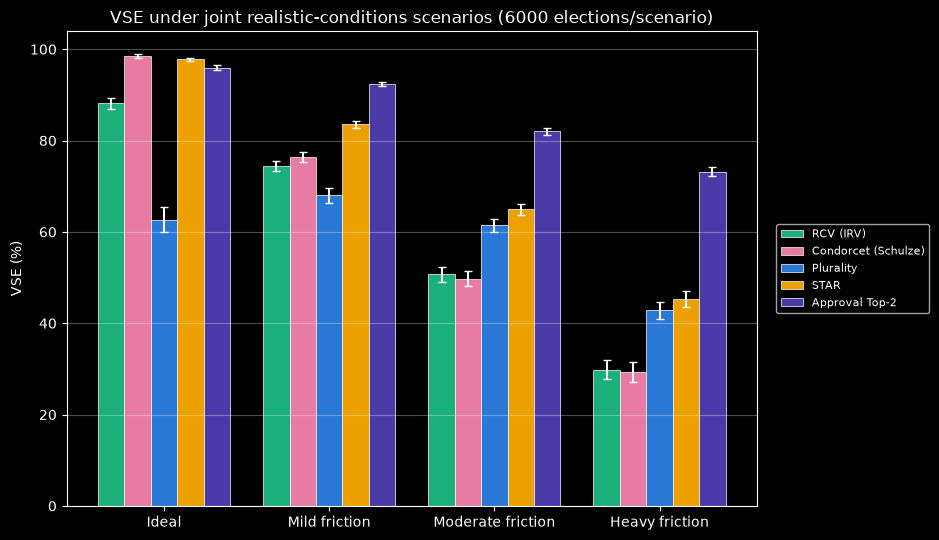

#### RCV (IRV) vs Condorcet (Schulze): paired VSE gap by joint-friction scenario

| Scenario | RCV VSE (%) | Schulze VSE (%) | Gap vs Schulze (pp) | 95% CI (paired, pp) | Significant? |
|---|---|---|---|---|---|
| Ideal | 88.2 | 98.6 | -10.4 | [-11.6, -9.2] | Decisive (Schulze better) |
| Mild friction | 74.4 | 76.4 | -2.0 | [-2.6, -1.3] | Decisive (Schulze better) |
| Moderate friction | 50.7 | 49.8 | +1.0 | [+0.4, +1.5] | Ambiguous edge (RCV better) |
| Heavy friction | 29.8 | 29.3 | +0.5 | [-0.1, +1.0] | Inconclusive |

In [89]:
replay("ranked-implosion")
replay("rcv-schulze-ci")

### Condorcet Efficiency

| Method | Raw CE (honest) | Relative to Schulze |
|---|---|---|
| Condorcet (Schulze) | 100.0% | 1.00x |
| Approval Top-2 | 83.3% | 0.83x |
| STAR | 80.7% | 0.81x |
| Score5 | 71.4% | 0.71x |
| Plurality Top-2 | 66.0% | 0.66x |
| RCV (IRV) | 63.0% | 0.63x |
| Approval | 57.9% | 0.58x |
| Plurality | 43.2% | 0.43x |

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 43.2% (0.43x Schulze) | 45.2% (1.07x Schulze) | 32.7% (1.19x Schulze) | 24.5% (1.15x Schulze) |
| Plurality Top-2 | 66.0% (0.66x Schulze) | 60.5% (1.43x Schulze) | 47.8% (1.74x Schulze) | 37.9% (1.77x Schulze) |
| Plurality Top-2 (Clear-Eyed) | 66.0% (0.66x Schulze) | 68.7% (1.62x Schulze) | 54.2% (1.98x Schulze) | 43.9% (2.05x Schulze) |
| RCV (IRV) | 63.0% (0.63x Schulze) | 42.2% (0.99x Schulze) | 27.7% (1.01x Schulze) | 21.4% (1.00x Schulze) |
| Approval | 57.9% (0.58x Schulze) | 45.5% (1.07x Schulze) | 32.3% (1.18x Schulze) | 24.6% (1.15x Schulze) |
| Approval Top-2 (Coma) | 83.3% (0.83x Schulze) | 44.8% (1.06x Schulze) | 28.6% (1.04x Schulze) | 21.0% (0.98x Schulze) |
| Approval Top-2 | 83.3% (0.83x Schulze) | 62.1% (1.46x Schulze) | 46.9% (1.71x Schulze) | 38.3% (1.79x Schulze) |
| Approval Top-2 (Clear-Eyed) | 83.3% (0.83x Schulze) | 71.9% (1.70x Schulze) | 54.0% (1.97x Schulze) | 44.6% (2.08x Schulze) |
| STAR | 80.7% (0.81x Schulze) | 47.1% (1.11x Schulze) | 32.4% (1.18x Schulze) | 24.7% (1.16x Schulze) |
| Score5 | 71.4% (0.71x Schulze) | 44.8% (1.06x Schulze) | 31.7% (1.15x Schulze) | 24.7% (1.15x Schulze) |
| Score Top-2 (Clear-Eyed) | 92.3% (0.92x Schulze) | 71.1% (1.68x Schulze) | 53.6% (1.96x Schulze) | 44.3% (2.07x Schulze) |
| Condorcet (Schulze) | 100.0% (1.00x Schulze) | 42.4% (1.00x Schulze) | 27.4% (1.00x Schulze) | 21.4% (1.00x Schulze) |

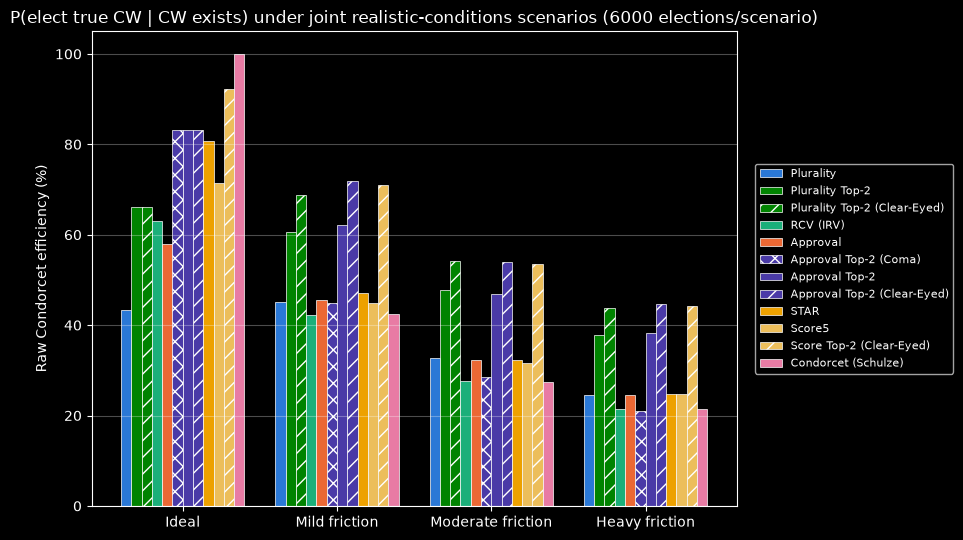

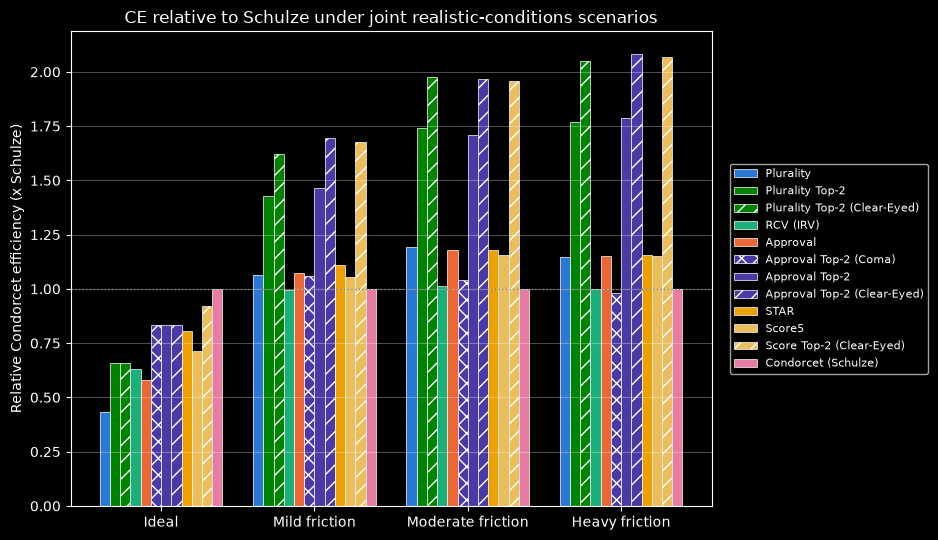

#### Ideal: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top-2 | -16.7% | [-18.4%, -15.1%] | Decisive (Condorcet (Schulze) better) |
| STAR | -19.3% | [-21.0%, -17.5%] | Decisive (Condorcet (Schulze) better) |
| Score5 | -28.6% | [-30.6%, -26.6%] | Decisive (Condorcet (Schulze) better) |
| Plurality Top-2 | -34.0% | [-36.1%, -31.9%] | Decisive (Condorcet (Schulze) better) |
| RCV (IRV) | -37.0% | [-39.1%, -34.9%] | Decisive (Condorcet (Schulze) better) |
| Approval | -42.1% | [-44.3%, -39.9%] | Decisive (Condorcet (Schulze) better) |
| Plurality | -56.8% | [-58.9%, -54.6%] | Decisive (Condorcet (Schulze) better) |

#### Mild friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | +29.5% | [+28.3%, +30.7%] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +28.6% | [+27.5%, +29.8%] | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 (Clear-Eyed) | +26.3% | [+25.0%, +27.6%] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | +19.7% | [+18.4%, +21.0%] | Decisive (Approval Top-2 better) |
| Plurality Top-2 | +18.1% | [+16.8%, +19.4%] | Decisive (Plurality Top-2 better) |
| STAR | +4.7% | [+4.0%, +5.4%] | Decisive (STAR better) |
| Approval | +3.1% | [+2.2%, +4.0%] | Decisive (Approval better) |
| Plurality | +2.8% | [+1.7%, +3.9%] | Decisive (Plurality better) |
| Approval Top-2 (Coma) | +2.4% | [+1.7%, +3.2%] | Decisive (Approval Top-2 (Coma) better) |
| Score5 | +2.4% | [+1.6%, +3.2%] | Decisive (Score5 better) |
| RCV (IRV) | -0.2% | [-0.7%, +0.3%] | Indistinguishable |

#### Moderate friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | +26.7% | [+25.6%, +27.9%] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | +26.6% | [+25.4%, +27.7%] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +26.2% | [+25.1%, +27.3%] | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 | +20.3% | [+19.1%, +21.6%] | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +19.4% | [+18.2%, +20.7%] | Decisive (Approval Top-2 better) |
| Plurality | +5.3% | [+4.6%, +6.0%] | Decisive (Plurality better) |
| STAR | +4.9% | [+4.4%, +5.5%] | Decisive (STAR better) |
| Approval | +4.9% | [+4.3%, +5.5%] | Decisive (Approval better) |
| Score5 | +4.2% | [+3.7%, +4.8%] | Decisive (Score5 better) |
| Approval Top-2 (Coma) | +1.2% | [+0.7%, +1.7%] | Ambiguous edge (Approval Top-2 (Coma) better) |
| RCV (IRV) | +0.3% | [+0.1%, +0.5%] | Narrow edge (RCV (IRV) better) |

#### Heavy friction: paired Condorcet-efficiency gap vs Schulze (pp)

| Method | CE gap vs Schulze (pp) | 95% CI | Significant? |
|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | +23.2% | [+22.1%, +24.2%] | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +22.9% | [+21.8%, +23.9%] | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 (Clear-Eyed) | +22.5% | [+21.4%, +23.5%] | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | +16.8% | [+15.7%, +18.0%] | Decisive (Approval Top-2 better) |
| Plurality Top-2 | +16.5% | [+15.4%, +17.6%] | Decisive (Plurality Top-2 better) |
| STAR | +3.3% | [+2.9%, +3.8%] | Decisive (STAR better) |
| Score5 | +3.2% | [+2.8%, +3.7%] | Decisive (Score5 better) |
| Approval | +3.2% | [+2.7%, +3.7%] | Decisive (Approval better) |
| Plurality | +3.1% | [+2.6%, +3.6%] | Decisive (Plurality better) |
| RCV (IRV) | -0.0% | [-0.2%, +0.2%] | Indistinguishable |
| Approval Top-2 (Coma) | -0.4% | [-0.7%, -0.0%] | Narrow edge (Condorcet (Schulze) better) |


In [90]:
replay("ideal-honest-ce-table")
replay("condorcet-joint")
replay("ce-ci-table")

### Robustness Rankings

In [91]:
replay("robustness-rankings")

### Ideal: robustness across strategy levels

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 | 95.8% |
| 2 | STAR | 95.2% |
| 3 | Score5 | 93.7% |
| 4 | Condorcet (Schulze) | 92.2% |
| 5 | Approval | 90.8% |
| 6 | Plurality Top-2 | 86.1% |
| 7 | RCV (IRV) | 83.7% |
| 8 | Plurality | 70.4% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 | 90.8% |
| 2 | STAR | 88.4% |
| 3 | Condorcet (Schulze) | 82.9% |
| 4 | Plurality Top-2 | 82.6% |
| 5 | Approval | 82.1% |
| 6 | Score5 | 81.9% |
| 7 | RCV (IRV) | 75.7% |
| 8 | Plurality | 54.9% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 | 0.5% |
| 2 | STAR | 1.1% |
| 3 | Score5 | 2.6% |
| 4 | Condorcet (Schulze) | 4.1% |
| 5 | Approval | 5.5% |
| 6 | Plurality Top-2 | 10.2% |
| 7 | RCV (IRV) | 12.6% |
| 8 | Plurality | 25.9% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 | 1.88 |
| 2 | STAR | 2.25 |
| 3 | Score5 | 3.12 |
| 4 | Condorcet (Schulze) | 3.75 |
| 5 | Approval | 4.50 |
| 6 | Plurality Top-2 | 6.00 |
| 7 | RCV (IRV) | 6.75 |
| 8 | Plurality | 7.75 |


### Friction only (Mild/Moderate/Heavy)

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 84.0% |
| 2 | Approval Top-2 | 82.5% |
| 3 | Plurality Top-2 (Clear-Eyed) | 82.1% |
| 4 | Plurality Top-2 | 81.0% |
| 5 | STAR | 64.6% |
| 6 | Approval | 64.5% |
| 7 | Score5 | 63.7% |
| 8 | Plurality | 57.4% |
| 9 | Approval Top-2 (Coma) | 57.1% |
| 10 | Condorcet (Schulze) | 51.8% |
| 11 | RCV (IRV) | 51.7% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 74.4% |
| 2 | Plurality Top-2 (Clear-Eyed) | 73.7% |
| 3 | Approval Top-2 | 72.2% |
| 4 | Plurality Top-2 | 72.0% |
| 5 | STAR | 43.6% |
| 6 | Approval | 43.4% |
| 7 | Score5 | 42.9% |
| 8 | Plurality | 41.0% |
| 9 | Approval Top-2 (Coma) | 30.4% |
| 10 | RCV (IRV) | 27.7% |
| 11 | Condorcet (Schulze) | 27.2% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 0.0% |
| 2 | Approval Top-2 | 1.5% |
| 3 | Plurality Top-2 (Clear-Eyed) | 1.9% |
| 4 | Plurality Top-2 | 3.0% |
| 5 | STAR | 19.4% |
| 6 | Approval | 19.4% |
| 7 | Score5 | 20.3% |
| 8 | Plurality | 26.5% |
| 9 | Approval Top-2 (Coma) | 26.9% |
| 10 | Condorcet (Schulze) | 32.1% |
| 11 | RCV (IRV) | 32.3% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 1.00 |
| 2 | Plurality Top-2 (Clear-Eyed) | 2.33 |
| 3 | Approval Top-2 | 2.67 |
| 4 | Plurality Top-2 | 4.00 |
| 5 | STAR | 5.33 |
| 6 | Approval | 5.67 |
| 7 | Score5 | 7.00 |
| 8 | Approval Top-2 (Coma) | 8.67 |
| 9 | Plurality | 9.00 |
| 10 | RCV (IRV) | 10.00 |
| 11 | Condorcet (Schulze) | 10.33 |


### Holistic (Ideal + all friction scenarios)

**1. Mean VSE across axis (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 87.0% |
| 2 | Approval Top-2 | 85.9% |
| 3 | Plurality Top-2 (Clear-Eyed) | 82.8% |
| 4 | Plurality Top-2 | 81.9% |
| 5 | STAR | 72.9% |
| 6 | Score5 | 71.8% |
| 7 | Approval | 70.7% |
| 8 | Approval Top-2 (Coma) | 66.8% |
| 9 | Condorcet (Schulze) | 63.5% |
| 10 | RCV (IRV) | 60.8% |
| 11 | Plurality | 58.7% |

**2. Worst-case VSE, CI lower bound (higher better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 74.4% |
| 2 | Plurality Top-2 (Clear-Eyed) | 73.7% |
| 3 | Approval Top-2 | 72.2% |
| 4 | Plurality Top-2 | 72.0% |
| 5 | STAR | 43.6% |
| 6 | Approval | 43.4% |
| 7 | Score5 | 42.9% |
| 8 | Plurality | 41.0% |
| 9 | Approval Top-2 (Coma) | 30.4% |
| 10 | RCV (IRV) | 27.7% |
| 11 | Condorcet (Schulze) | 27.2% |

**3. Avg. regret vs. best-at-that-point (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 0.7% |
| 2 | Approval Top-2 | 1.7% |
| 3 | Plurality Top-2 (Clear-Eyed) | 4.9% |
| 4 | Plurality Top-2 | 5.7% |
| 5 | STAR | 14.7% |
| 6 | Score5 | 15.8% |
| 7 | Approval | 16.9% |
| 8 | Approval Top-2 (Coma) | 20.8% |
| 9 | Condorcet (Schulze) | 24.1% |
| 10 | RCV (IRV) | 26.8% |
| 11 | Plurality | 28.9% |

**4. Avg. rank across axis (lower better)**

| Rank | Method | Score |
|---|---|---|
| 1 | Approval Top-2 (Clear-Eyed) | 2.25 |
| 2 | Approval Top-2 | 3.25 |
| 3 | Plurality Top-2 (Clear-Eyed) | 4.25 |
| 4 | STAR | 4.50 |
| 5 | Plurality Top-2 | 5.25 |
| 6 | Approval | 6.00 |
| 7 | Score5 | 6.00 |
| 8 | Approval Top-2 (Coma) | 7.50 |
| 9 | Condorcet (Schulze) | 8.00 |
| 10 | Plurality | 9.50 |
| 11 | RCV (IRV) | 9.50 |


### The Shape of the Data

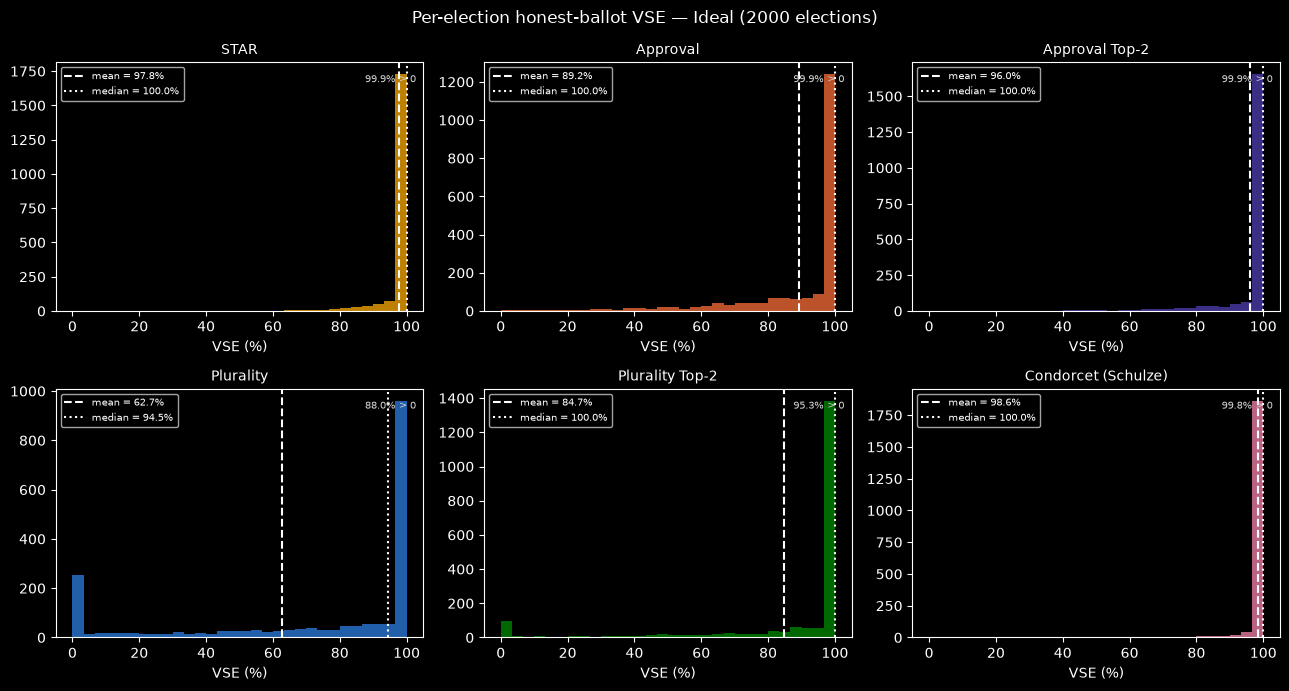

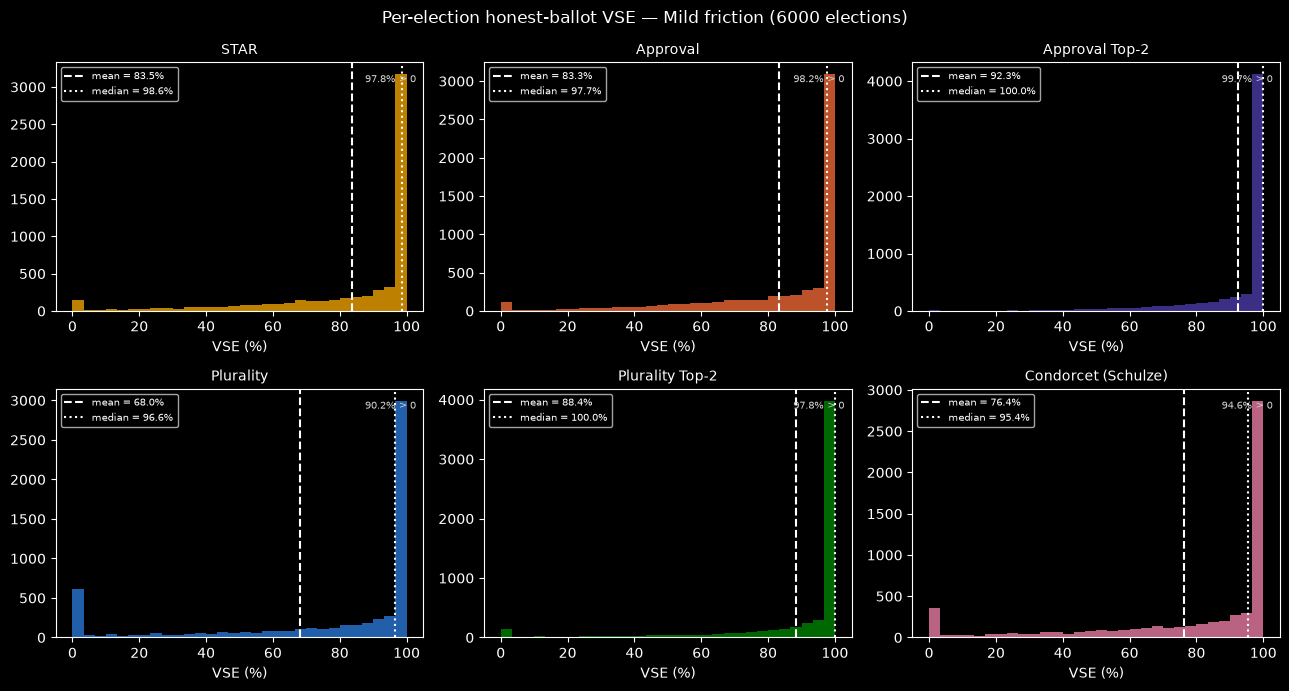

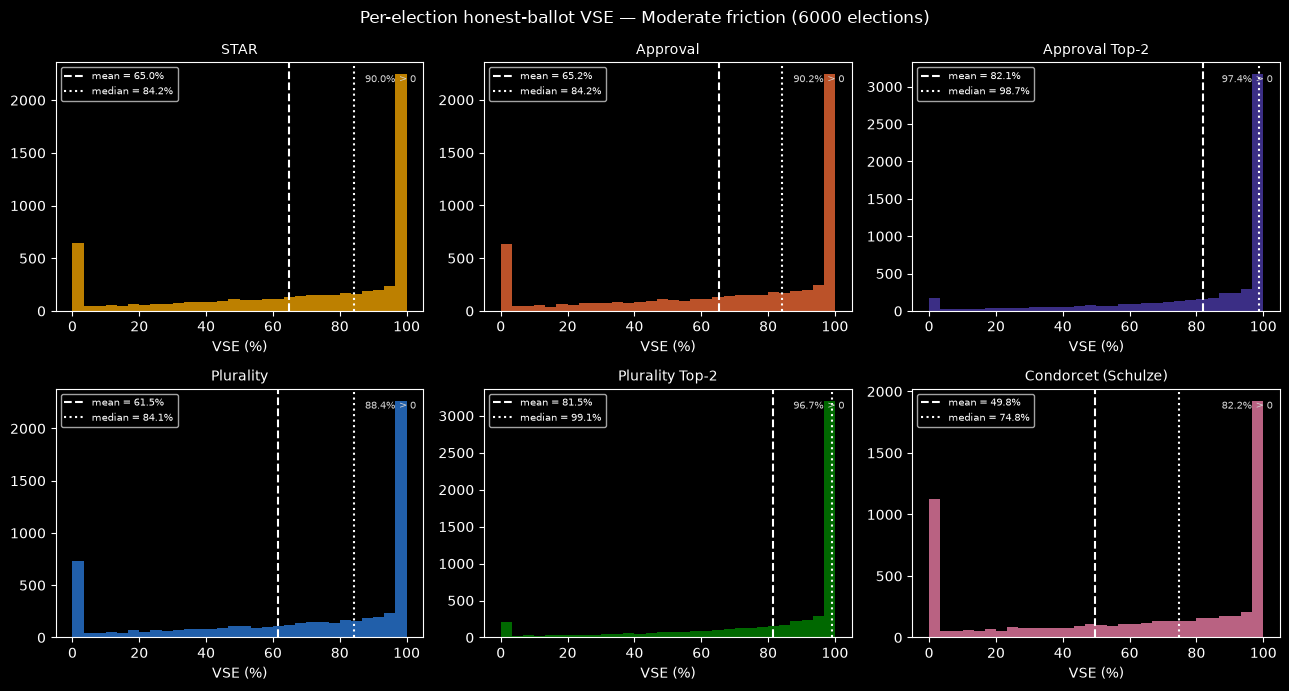

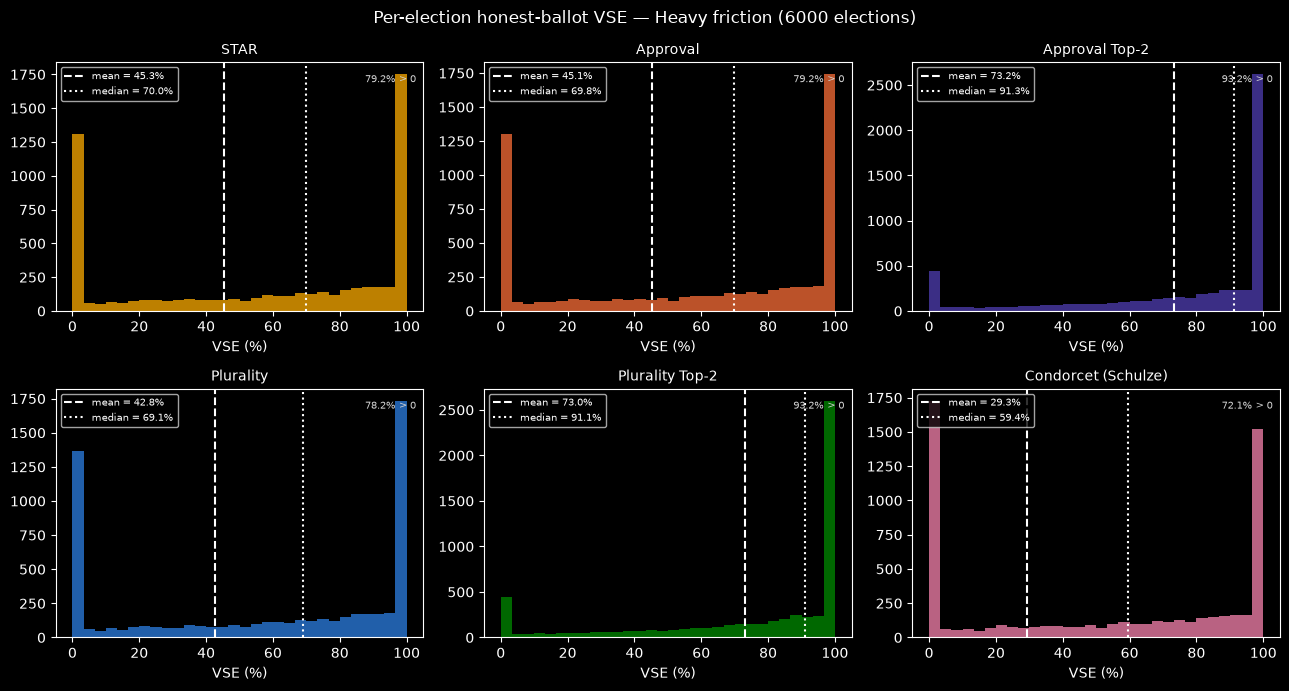

In [92]:
replay("histogram-data")

### 99% Confidence Check Part 2

In [93]:
replay("not-sig-at-99-part2")
replay("still-sig-at-99-part2")

### 2 result(s) lose significance at 99% confidence


- **CE gap vs Schulze: Moderate friction -- RCV (IRV)**: at 95% confidence, **RCV (IRV)** appeared better than **Condorcet (Schulze)** by 0.3pp (Narrow edge, 95% CI [+0.1, +0.5]) -- but at 99% confidence that edge is no longer significant (Indistinguishable, 99% CI [-0.0, +0.6], which contains 0).
- **CE gap vs Schulze: Heavy friction -- Approval Top-2 (Coma)**: at 95% confidence, **Condorcet (Schulze)** appeared better than **Approval Top-2 (Coma)** by 0.4pp (Narrow edge, 95% CI [-0.7, -0.0]) -- but at 99% confidence that edge is no longer significant (Indistinguishable, 99% CI [-0.8, +0.1], which contains 0).

### Spotlight: does each headline claim hold up at 99% confidence?


#### CE gap vs Schulze: Ideal

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top-2 | -16.7 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| STAR | -19.3 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| Score5 | -28.6 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| Plurality Top-2 | -34.0 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| RCV (IRV) | -37.0 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| Approval | -42.1 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |
| Plurality | -56.8 | Decisive (Condorcet (Schulze) better) | Decisive (Condorcet (Schulze) better) |

#### CE gap vs Schulze: Mild friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | +29.5 | Decisive (Approval Top-2 (Clear-Eyed) better) | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +28.6 | Decisive (Score Top-2 (Clear-Eyed) better) | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 (Clear-Eyed) | +26.3 | Decisive (Plurality Top-2 (Clear-Eyed) better) | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | +19.7 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| Plurality Top-2 | +18.1 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| STAR | +4.7 | Decisive (STAR better) | Decisive (STAR better) |
| Approval | +3.1 | Decisive (Approval better) | Decisive (Approval better) |
| Plurality | +2.8 | Decisive (Plurality better) | Decisive (Plurality better) |
| Approval Top-2 (Coma) | +2.4 | Decisive (Approval Top-2 (Coma) better) | Decisive (Approval Top-2 (Coma) better) |
| Score5 | +2.4 | Decisive (Score5 better) | Decisive (Score5 better) |
| RCV (IRV) | -0.2 | Indistinguishable | Indistinguishable |

#### CE gap vs Schulze: Moderate friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Plurality Top-2 (Clear-Eyed) | +26.7 | Decisive (Plurality Top-2 (Clear-Eyed) better) | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 (Clear-Eyed) | +26.6 | Decisive (Approval Top-2 (Clear-Eyed) better) | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +26.2 | Decisive (Score Top-2 (Clear-Eyed) better) | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 | +20.3 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| Approval Top-2 | +19.4 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| Plurality | +5.3 | Decisive (Plurality better) | Decisive (Plurality better) |
| STAR | +4.9 | Decisive (STAR better) | Decisive (STAR better) |
| Approval | +4.9 | Decisive (Approval better) | Decisive (Approval better) |
| Score5 | +4.2 | Decisive (Score5 better) | Decisive (Score5 better) |
| Approval Top-2 (Coma) | +1.2 | Ambiguous edge (Approval Top-2 (Coma) better) | Ambiguous edge (Approval Top-2 (Coma) better) |
| RCV (IRV) | +0.3 | Narrow edge (RCV (IRV) better) | **Indistinguishable** |

#### CE gap vs Schulze: Heavy friction

| Row | Gap (pp) | 95% verdict | 99% verdict |
|---|---|---|---|
| Approval Top-2 (Clear-Eyed) | +23.2 | Decisive (Approval Top-2 (Clear-Eyed) better) | Decisive (Approval Top-2 (Clear-Eyed) better) |
| Score Top-2 (Clear-Eyed) | +22.9 | Decisive (Score Top-2 (Clear-Eyed) better) | Decisive (Score Top-2 (Clear-Eyed) better) |
| Plurality Top-2 (Clear-Eyed) | +22.5 | Decisive (Plurality Top-2 (Clear-Eyed) better) | Decisive (Plurality Top-2 (Clear-Eyed) better) |
| Approval Top-2 | +16.8 | Decisive (Approval Top-2 better) | Decisive (Approval Top-2 better) |
| Plurality Top-2 | +16.5 | Decisive (Plurality Top-2 better) | Decisive (Plurality Top-2 better) |
| STAR | +3.3 | Decisive (STAR better) | Decisive (STAR better) |
| Score5 | +3.2 | Decisive (Score5 better) | Decisive (Score5 better) |
| Approval | +3.2 | Decisive (Approval better) | Decisive (Approval better) |
| Plurality | +3.1 | Decisive (Plurality better) | Decisive (Plurality better) |
| RCV (IRV) | -0.0 | Indistinguishable | Indistinguishable |
| Approval Top-2 (Coma) | -0.4 | Narrow edge (Condorcet (Schulze) better) | **Indistinguishable** |

## Part 3

to be continued...

# 29. How many more elections would it actually take?

Rows below are the ones the 5-way taxonomy (`_classify_gap`/`TAXONOMY_LABELS`, defined alongside
`SIGNIFICANCE_LOG` above) currently calls **Inconclusive** or **Ambiguous edge** -- the only two
buckets where more data could plausibly change the story. `Indistinguishable` rows are already
known to be small and don't matter; `Decisive`/`Narrow edge` rows already have a resolved
direction. (See Section 27 for how these buckets hold up under a stricter 99% bar.)

For each row, this projects the election count needed to reach the *next* tier up, using the
same CI-scaling fact Section 27's 99% rescaling relies on: a CI's half-width scales as
`1/sqrt(n)` for a fixed underlying variance, so `n_required = n_current * (ci_current / ci_target)^2`.
- **Inconclusive -> Ambiguous edge (or better)**: needs the CI to clear zero, so
  `ci_target = |gap|`.
- **Ambiguous edge -> Narrow edge or Decisive**: needs the CI to stop straddling
  `GAP_THRESHOLD_PP`, so `ci_target = |gap - GAP_THRESHOLD_PP|` -- whichever side of the
  threshold the observed gap already sits on is the only side it can resolve toward.

**This is a projection, not a guarantee.** It assumes the gap and CI this run already shows are
close to the true values -- a gap that's mostly noise at the current sample size can make the
projection too optimistic, and for a genuinely ~0 true effect the projected n needed is
effectively unbounded. Treat it as "if reality looks like what I'm currently seeing, here's the
number," not proof you'll actually get there.

Each comparison is also tagged with which `NITER`-style knob actually controls it (`JOINT_NITER`,
`RUNOFF_SWEEP_NITER` for the kappa-threshold sweep, `NCAND_SWEEP_NITER` for the candidate-count
sweep) via a best-effort keyword match on the comparison's own title -- correct
`_NITER_KNOB_KEYWORDS` below if a comparison gets misclassified.

In [94]:
_chase_rows = {"INCONCLUSIVE": [], "AMBIGUOUS_EDGE": []}
for _table_title, _rows in R.significance.items():
    _knob_name, _n_current = _niter_knob_for(_table_title)
    for _row_label, _gap, _ci95, _pos_name, _neg_name, _spotlight in _rows:
        _bucket = _classify_gap(_gap, _ci95)
        if _bucket not in _chase_rows:
            continue
        _ci_target = _next_tier_ci_target(_bucket, _gap)
        _n_needed = _required_n(_n_current, _ci95, _ci_target)
        _chase_rows[_bucket].append(
            (_table_title, _row_label, _knob_name, _n_current, _gap, _ci95, _n_needed)
        )

_SECTION_TITLES = {
    "INCONCLUSIVE": "Inconclusive -- need to establish direction",
    "AMBIGUOUS_EDGE": "Ambiguous edge -- need to resolve magnitude",
}
for _bucket in ("INCONCLUSIVE", "AMBIGUOUS_EDGE"):
    _rows_for_bucket = sorted(_chase_rows[_bucket], key=lambda r: r[-1])
    _lines = [
        f"#### {_SECTION_TITLES[_bucket]} ({len(_rows_for_bucket)} rows)",
        "",
        "| Comparison | Row | Knob | Gap (pp) | 95% CI (pp) | Knob n | Projected n for next tier |",
        "|---|---|---|---|---|---|---|",
    ]
    for _table_title, _row_label, _knob_name, _n_current, _gap, _ci95, _n_needed in _rows_for_bucket:
        _lines.append(
            f"| {_table_title} | {_row_label} | `{_knob_name}` | {_gap:+.2f} | "
            f"[{_gap-_ci95:+.2f}, {_gap+_ci95:+.2f}] | {_n_current:,} | {_fmt_n(_n_needed, _n_current)} |"
        )
    if not _rows_for_bucket:
        _lines.append("| *(none currently in this bucket)* | | | | | | |")
    display(Markdown("\n".join(_lines)))

#### Inconclusive -- need to establish direction (17 rows)

| Comparison | Row | Knob | Gap (pp) | 95% CI (pp) | Knob n | Projected n for next tier |
|---|---|---|---|---|---|---|
| AT2 vs PT2 by candidate count: Heavy friction | NCAND=5 | `NCAND_SWEEP_NITER` | -1.27 | [-2.64, +0.09] | 1,200 | 1,382 |
| kappa threshold: Heavy friction | kappa=0.27 | `RUNOFF_SWEEP_NITER` | +1.31 | [-0.01, +2.62] | 3,500 | 3,549 |
| AT2 vs PT2 by candidate count: Moderate friction | NCAND=10 | `NCAND_SWEEP_NITER` | +0.56 | [-0.59, +1.70] | 1,200 | 5,083 |
| AT2 vs PT2 by candidate count: Heavy friction | NCAND=6 | `NCAND_SWEEP_NITER` | +0.58 | [-0.66, +1.81] | 1,200 | 5,507 |
| AT2 vs PT2 by candidate count: Moderate friction | NCAND=5 | `NCAND_SWEEP_NITER` | +0.68 | [-0.85, +2.21] | 1,200 | 6,100 |
| AT2 vs PT2 by candidate count: Moderate friction | NCAND=8 | `NCAND_SWEEP_NITER` | +0.50 | [-0.64, +1.63] | 1,200 | 6,280 |
| AT2 vs PT2 by candidate count: Heavy friction | NCAND=10 | `NCAND_SWEEP_NITER` | +0.47 | [-0.67, +1.62] | 1,200 | 6,995 |
| kappa threshold: Mild friction | kappa=0.13 | `RUNOFF_SWEEP_NITER` | -0.50 | [-1.20, +0.21] | 3,500 | 7,055 |
| Approval Top-2 vs Plurality Top-2 | Moderate friction | `JOINT_NITER` | +0.53 | [-0.06, +1.11] | 6,000 | 7,515 |
| AT2 vs PT2 by candidate count: Heavy friction | NCAND=3 | `NCAND_SWEEP_NITER` | -0.48 | [-1.76, +0.81] | 1,200 | 8,728 |
| kappa threshold: Moderate friction | kappa=0.27 | `RUNOFF_SWEEP_NITER` | +0.67 | [-0.40, +1.73] | 3,500 | 8,983 |
| RCV (IRV) vs Condorcet (Schulze) | Heavy friction | `JOINT_NITER` | +0.47 | [-0.12, +1.05] | 6,000 | 9,391 |
| kappa threshold: Heavy friction | kappa=0.25 | `RUNOFF_SWEEP_NITER` | +0.80 | [-0.53, +2.14] | 3,500 | 9,693 |
| kappa threshold: Mild friction | kappa=0.20 | `RUNOFF_SWEEP_NITER` | +0.39 | [-0.32, +1.11] | 3,500 | 11,500 |
| AT2 vs PT2 by candidate count: Heavy friction | NCAND=8 | `NCAND_SWEEP_NITER` | -0.30 | [-1.34, +0.74] | 1,200 | 14,165 |
| AT2 vs PT2 by candidate count: Moderate friction | NCAND=6 | `NCAND_SWEEP_NITER` | -0.27 | [-1.37, +0.82] | 1,200 | 19,522 |
| kappa threshold: Moderate friction | kappa=0.25 | `RUNOFF_SWEEP_NITER` | -0.39 | [-1.41, +0.64] | 3,500 | 24,529 |

#### Ambiguous edge -- need to resolve magnitude (21 rows)

| Comparison | Row | Knob | Gap (pp) | 95% CI (pp) | Knob n | Projected n for next tier |
|---|---|---|---|---|---|---|
| AT2 vs PT2 by candidate count: Moderate friction | NCAND=3 | `NCAND_SWEEP_NITER` | +2.14 | [+0.76, +3.52] | 1,200 | 1,752 |
| kappa threshold: Mild friction | kappa=0.27 | `RUNOFF_SWEEP_NITER` | +1.63 | [+0.94, +2.31] | 3,500 | 4,170 |
| kappa threshold: Moderate friction | kappa=0.20 | `RUNOFF_SWEEP_NITER` | -1.74 | [-2.77, -0.70] | 3,500 | 6,885 |
| Approval Top-2 (Coma) vs Approval | Mild friction | `JOINT_NITER` | -1.48 | [-2.06, -0.91] | 6,000 | 8,513 |
| Does the runoff help or hurt Approval?: Mild friction | Approval Top-2 (Coma) | `JOINT_NITER` | -1.48 | [-2.06, -0.91] | 6,000 | 8,513 |
| Score Top-2 (Clear-Eyed) vs STAR (Ballot fatigue) | fatigue_beta=0.90 | `JOINT_NITER` | +1.65 | [+0.87, +2.43] | 6,000 | 8,563 |
| Score Top-2 (Clear-Eyed) vs STAR (Epistemic noise) | epistemic_rho=0.90 | `JOINT_NITER` | +1.30 | [+0.94, +1.67] | 6,000 | 8,829 |
| Score5 vs STAR | Heavy friction | `JOINT_NITER` | -0.65 | [-1.08, -0.21] | 6,000 | 9,195 |
| kappa threshold: Mild friction | kappa=0.25 | `RUNOFF_SWEEP_NITER` | +1.43 | [+0.73, +2.13] | 3,500 | 9,220 |
| Approval Top-2 (Clear-Eyed) vs Plurality Top-2 (Clear-Eyed) | Heavy friction | `JOINT_NITER` | +0.63 | [+0.12, +1.14] | 6,000 | 11,364 |
| Score5 vs STAR | Mild friction | `JOINT_NITER` | -1.21 | [-1.63, -0.80] | 6,000 | 23,291 |
| AT2 vs PT2 by candidate count: Moderate friction | NCAND=15 | `NCAND_SWEEP_NITER` | -1.19 | [-2.13, -0.25] | 1,200 | 30,062 |
| kappa threshold: Heavy friction | kappa=0.23 | `RUNOFF_SWEEP_NITER` | -1.45 | [-2.82, -0.08] | 3,500 | 32,900 |
| kappa threshold: Moderate friction | kappa=0.30 | `RUNOFF_SWEEP_NITER` | +1.34 | [+0.29, +2.38] | 3,500 | 33,601 |
| CE gap vs Schulze: Moderate friction | Approval Top-2 (Coma) | `JOINT_NITER` | +1.18 | [+0.66, +1.69] | 6,000 | 50,494 |
| kappa threshold: Moderate friction | kappa=0.23 | `RUNOFF_SWEEP_NITER` | -1.17 | [-2.20, -0.13] | 3,500 | 134,570 |
| kappa threshold: Mild friction | kappa=0.23 | `RUNOFF_SWEEP_NITER` | +1.10 | [+0.36, +1.83] | 3,500 | 205,460 |
| Score5 vs STAR | Moderate friction | `JOINT_NITER` | -0.94 | [-1.41, -0.48] | 6,000 | 394,804 |
| kappa threshold: Mild friction | kappa=0.10 | `RUNOFF_SWEEP_NITER` | -0.94 | [-1.61, -0.26] | 3,500 | 405,723 |
| Approval Top-2 (Clear-Eyed) vs Plurality Top-2 (Clear-Eyed) | Moderate friction | `JOINT_NITER` | +0.94 | [+0.34, +1.54] | 6,000 | 567,819 |
| RCV (IRV) vs Condorcet (Schulze) | Moderate friction | `JOINT_NITER` | +0.96 | [+0.40, +1.53] | 6,000 | 1,360,803 |

# Notebook End

In [95]:
# The simulation time below is what `python -m vse_sim.run --stage all` spent, read back
# from the stored results -- not the time this notebook took, which is a few seconds.
display(Markdown(
    f"**{R.total_elections:,} elections** were simulated to produce everything above, taking "
    f"**{R.total_seconds / 60:.1f} minutes** in `python -m vse_sim.run --stage all`.\n\n"
    f"Rendering them here took **{time.time() - _notebook_start:.1f} seconds**. That gap is the "
    f"point of splitting the two: changing a chart no longer costs a re-run."
))

**69,800 elections** were simulated to produce everything above, taking **19.5 minutes** in `python -m vse_sim.run --stage all`.

Rendering them here took **23.1 seconds**. That gap is the point of splitting the two: changing a chart no longer costs a re-run.